In [1]:
# Cell 1 - Environment Setup and Configuration

import os
import pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import math
import time
import traceback
from datetime import datetime, timedelta
from dotenv import load_dotenv

# Import scikit-learn dependencies
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

pd.options.mode.chained_assignment = None

# Load environment variables from .env file
try:
    env_path = pathlib.Path(__file__).resolve().parent.parent / ".env"
except NameError:
    env_path = pathlib.Path(os.getcwd()) / ".env"
load_dotenv(dotenv_path=env_path)

# Get configuration values and setup connections
DATABASE_URL = os.getenv("DATABASE_URL")
print("DATABASE_URL loaded:", DATABASE_URL is not None)

# Setup SQLAlchemy engine
from sqlalchemy import create_engine
try:
    engine = create_engine(DATABASE_URL)
    print("Database engine created successfully.")
except Exception as e:
    print(f"Error creating database engine: {e}")

# Import Supabase client
try:
    from caching.supabase_client import supabase
    print("Supabase client imported successfully.")
except Exception as e:
    print(f"Error importing Supabase client: {e}")

# Set directories for models and state saving
MODELS_DIR = pathlib.Path(os.getcwd()) / "models"
MODELS_DIR.mkdir(exist_ok=True)
PREGAME_MODEL_PATH = MODELS_DIR / "pregame_model.pkl"
print(f"Pre-game model will be saved to: {PREGAME_MODEL_PATH}")
print(f"Current date: {datetime.now().strftime('%Y-%m-%d')}")

DATABASE_URL loaded: True
Database engine created successfully.
Supabase client imported successfully.
Pre-game model will be saved to: /Users/mattb/Desktop/Projects/score-genius/notebooks/models/pregame_model.pkl
Current date: 2025-03-24


In [2]:
# Cell 2

from datetime import datetime, timedelta
import traceback
import numpy as np
import pandas as pd
import re

def normalize_team_name(name):
    """
    Normalizes team names to handle inconsistencies in naming across data sources.
    
    Args:
        name: Team name to normalize.
        
    Returns:
        Normalized team name (lowercase, without special characters).
    """
    normalized = re.sub(r'[^\w\s]', '', str(name)).lower().strip()
    replacements = {
        "76ers": "sixers",
        "trail blazers": "blazers"
        # Add more replacements as needed.
    }
    for old, new in replacements.items():
        if old in normalized:
            normalized = normalized.replace(old, new)
    return normalized


def load_historical_games(days_lookback=365, max_games=100):
    """
    Loads historical game data from Supabase for feature engineering and training.
    Includes all box score statistics.
    
    Args:
        days_lookback: Number of days to look back from today.
        max_games: Maximum number of games to process (if more are returned, sample down).
        
    Returns:
        DataFrame with historical game data.
    """
    threshold_date = (datetime.now() - timedelta(days=days_lookback)).strftime('%Y-%m-%d')
    print(f"Loading historical game data since {threshold_date}...")
    try:
        response = supabase.table("nba_historical_game_stats")\
            .select("*")\
            .gte("game_date", threshold_date)\
            .order('game_date')\
            .execute()
        
        historical_data = response.data
        if not historical_data:
            print(f"No historical game data available from the last {days_lookback} days.")
            return pd.DataFrame()
        
        df = pd.DataFrame(historical_data)
        df['game_date'] = pd.to_datetime(df['game_date'])
        
        numeric_cols = [
            'home_score', 'away_score', 'home_q1', 'home_q2', 'home_q3', 'home_q4', 'home_ot',
            'away_q1', 'away_q2', 'away_q3', 'away_q4', 'away_ot', 'home_assists', 'away_assists',
            'home_steals', 'away_steals', 'home_blocks', 'away_blocks', 'home_turnovers',
            'away_turnovers', 'home_fouls', 'away_fouls', 'home_off_reb', 'home_def_reb',
            'home_total_reb', 'away_off_reb', 'away_def_reb', 'away_total_reb',
            'home_3pm', 'home_3pa', 'away_3pm', 'away_3pa',
            'home_fg_made', 'home_fg_attempted', 'away_fg_made', 'away_fg_attempted',
            'home_ft_made', 'home_ft_attempted', 'away_ft_made', 'away_ft_attempted'
        ]
        
        for col in numeric_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
        
        # SAMPLE the dataframe if too many rows are returned
        if len(df) > max_games:
            print(f"Received {len(df)} games; sampling down to {max_games} for faster processing...")
            df = df.sample(n=max_games, random_state=42).reset_index(drop=True)
        
        print(f"Loaded {len(df)} historical games from {df['game_date'].min()} to {df['game_date'].max()}")
        return df
    except Exception as e:
        print(f"Error loading historical game data: {e}")
        traceback.print_exc()
       


In [3]:
# Cell 3

import pandas as pd
import numpy as np
import traceback
import re

def normalize_team_name(name):
    """
    Normalizes team names to handle inconsistencies in naming across data sources.
    
    Args:
        name: Team name to normalize
        
    Returns:
        Normalized team name (lowercase, without special characters)
    """
    if name is None:
        return ""
        
    # Remove special characters, standardize spacing
    normalized = re.sub(r'[^\w\s]', '', str(name)).lower().strip()
    
    # Handle common variations (76ers vs sixers, etc.)
    replacements = {
        "76ers": "sixers",
        "trail blazers": "blazers"
        # Add more as needed
    }
    
    for old, new in replacements.items():
        if old in normalized:
            normalized = normalized.replace(old, new)
            
    return normalized

def calculate_team_metrics(historical_df):
    """
    Calculates advanced team-level metrics from historical game data.
    Incorporates the full range of box score statistics.
    """
    if historical_df.empty:
        print("No historical data provided.")
        return pd.DataFrame()
    
    # Get unique team names (using original names)
    teams = set(historical_df['home_team'].unique()) | set(historical_df['away_team'].unique())
    
    metrics_list = []
    for team in teams:
        try:
            # Use original team name for fetching data
            home_games = historical_df[historical_df['home_team'] == team]
            away_games = historical_df[historical_df['away_team'] == team]
            
            # Also store normalized version
            team_normalized = normalize_team_name(team)
            
            total_games = len(home_games) + len(away_games)
            if total_games < 3:
                continue
                
            # Basic scoring metrics
            avg_home_score = home_games['home_score'].mean() if not home_games.empty else np.nan
            avg_away_score = away_games['away_score'].mean() if not away_games.empty else np.nan
            overall_avg = np.nanmean([avg_home_score, avg_away_score])
            avg_home_opp = home_games['away_score'].mean() if not home_games.empty else np.nan
            avg_away_opp = away_games['home_score'].mean() if not away_games.empty else np.nan
            overall_opp = np.nanmean([avg_home_opp, avg_away_opp])
            net_rating = overall_avg - overall_opp
            
            # Win-loss record
            home_wins = (home_games['home_score'] > home_games['away_score']).sum() if not home_games.empty else 0
            away_wins = (away_games['away_score'] > away_games['home_score']).sum() if not away_games.empty else 0
            win_pct = (home_wins + away_wins) / total_games
            
            # Home court advantage
            home_advantage = avg_home_score - avg_home_opp if not np.isnan(avg_home_score) and not np.isnan(avg_home_opp) else 3.5
            
            # Quarter-by-quarter scoring tendencies
            home_q1_avg = home_games['home_q1'].mean() if not home_games.empty else np.nan
            away_q1_avg = away_games['away_q1'].mean() if not away_games.empty else np.nan
            q1_avg = np.nanmean([home_q1_avg, away_q1_avg])
            
            home_q4_avg = home_games['home_q4'].mean() if not home_games.empty else np.nan
            away_q4_avg = away_games['away_q4'].mean() if not away_games.empty else np.nan
            q4_avg = np.nanmean([home_q4_avg, away_q4_avg])
            
            # Rebounding metrics
            home_reb_avg = home_games['home_total_reb'].mean() if not home_games.empty else np.nan
            away_reb_avg = away_games['away_total_reb'].mean() if not away_games.empty else np.nan
            total_reb_avg = np.nanmean([home_reb_avg, away_reb_avg])
            
            home_off_reb_avg = home_games['home_off_reb'].mean() if not home_games.empty else np.nan
            away_off_reb_avg = away_games['away_off_reb'].mean() if not away_games.empty else np.nan
            off_reb_avg = np.nanmean([home_off_reb_avg, away_off_reb_avg])
            
            # Assists and turnovers
            home_ast_avg = home_games['home_assists'].mean() if not home_games.empty else np.nan
            away_ast_avg = away_games['away_assists'].mean() if not away_games.empty else np.nan
            ast_avg = np.nanmean([home_ast_avg, away_ast_avg])
            
            home_to_avg = home_games['home_turnovers'].mean() if not home_games.empty else np.nan
            away_to_avg = away_games['away_turnovers'].mean() if not away_games.empty else np.nan
            to_avg = np.nanmean([home_to_avg, away_to_avg])
            
            # Defensive metrics
            home_stl_avg = home_games['home_steals'].mean() if not home_games.empty else np.nan
            away_stl_avg = away_games['away_steals'].mean() if not away_games.empty else np.nan
            stl_avg = np.nanmean([home_stl_avg, away_stl_avg])
            
            home_blk_avg = home_games['home_blocks'].mean() if not home_games.empty else np.nan
            away_blk_avg = away_games['away_blocks'].mean() if not away_games.empty else np.nan
            blk_avg = np.nanmean([home_blk_avg, away_blk_avg])
            
            # Three-point shooting
            home_3pm_avg = home_games['home_3pm'].mean() if not home_games.empty else np.nan
            away_3pm_avg = away_games['away_3pm'].mean() if not away_games.empty else np.nan
            threes_made_avg = np.nanmean([home_3pm_avg, away_3pm_avg])
            
            home_3pa_avg = home_games['home_3pa'].mean() if not home_games.empty else np.nan
            away_3pa_avg = away_games['away_3pa'].mean() if not away_games.empty else np.nan
            threes_att_avg = np.nanmean([home_3pa_avg, away_3pa_avg])
            
            three_pt_pct = threes_made_avg / threes_att_avg if threes_att_avg > 0 else 0
            
            # Fouls
            home_fouls_avg = home_games['home_fouls'].mean() if not home_games.empty else np.nan
            away_fouls_avg = away_games['away_fouls'].mean() if not away_games.empty else np.nan
            fouls_avg = np.nanmean([home_fouls_avg, away_fouls_avg])
            
            # Recent form (last 10 games)
            recent_home_games = home_games.sort_values('game_date').tail(10)
            recent_away_games = away_games.sort_values('game_date').tail(10)
            
            recent_home_pts = recent_home_games['home_score'].mean() if not recent_home_games.empty else np.nan
            recent_away_pts = recent_away_games['away_score'].mean() if not recent_away_games.empty else np.nan
            recent_form = np.nanmean([recent_home_pts, recent_away_pts])
            
            # Get current form from the data if available
            current_form = ""
            if 'current_form' in historical_df.columns:
                # Try to get the most recent record of this team's form
                team_data = historical_df[(historical_df['home_team'] == team) | (historical_df['away_team'] == team)]
                if not team_data.empty:
                    # Sort by date and get the most recent entry
                    team_data = team_data.sort_values('game_date', ascending=False)
                    if 'current_form' in team_data.columns:
                        first_row = team_data.iloc[0]
                        if 'current_form' in first_row:
                            current_form = str(first_row['current_form'])
            
            # Ensure current_form is a valid string
            if pd.isna(current_form) or current_form is None:
                current_form = ""
            current_form = str(current_form)
            
            # Calculate win percentage from form string
            form_win_pct = 0.5  # Default to neutral
            if len(current_form) > 0:
                win_count = current_form.count('W')
                form_win_pct = win_count / len(current_form) if len(current_form) > 0 else 0.5
                
            # Calculate current streak (positive for wins, negative for losses)
            current_streak = 0
            if len(current_form) > 0:
                streak_char = current_form[0]
                streak_count = 0
                for char in current_form:
                    if char == streak_char:
                        streak_count += 1
                    else:
                        break
                
                # Apply sign based on win/loss
                if streak_char == 'W':
                    current_streak = streak_count
                else:
                    current_streak = -streak_count
                    
            # Determine momentum direction (1=improving, -1=declining, 0=alternating)
            momentum_direction = 0
            if len(current_form) >= 4:
                # Check if recent games are trending toward wins or losses
                first_half = current_form[len(current_form)//2:]  # More recent games
                second_half = current_form[:len(current_form)//2]  # Less recent games
                first_half_win_pct = first_half.count('W') / len(first_half) if len(first_half) > 0 else 0
                second_half_win_pct = second_half.count('W') / len(second_half) if len(second_half) > 0 else 0
                
                if first_half_win_pct > second_half_win_pct:
                    momentum_direction = 1  # Improving
                elif first_half_win_pct < second_half_win_pct:
                    momentum_direction = -1  # Declining
            
            # Compile metrics
            metrics = {
                'team': team,
                'team_normalized': team_normalized,
                'games_played': total_games,
                'avg_score': overall_avg,
                'avg_opp_score': overall_opp,
                'net_rating': net_rating,
                'win_pct': win_pct,
                'home_advantage': home_advantage,
                'pts_per_game': overall_avg,
                'opp_pts_per_game': overall_opp,
                'recent_form': recent_form if not np.isnan(recent_form) else overall_avg,
                'offensive_rating': overall_avg,  # Simplified for consistency
                'defensive_rating': overall_opp,  # Simplified for consistency
                # Quarter scoring tendencies
                'q1_avg': q1_avg,
                'q4_avg': q4_avg,
                'q1_q4_ratio': q1_avg / q4_avg if q4_avg > 0 else 1,
                # Rebounding
                'total_reb_avg': total_reb_avg,
                'off_reb_avg': off_reb_avg,
                'off_reb_pct': off_reb_avg / total_reb_avg if total_reb_avg > 0 else 0.25,
                # Ball handling
                'assists_avg': ast_avg,
                'turnovers_avg': to_avg,
                'ast_to_ratio': ast_avg / to_avg if to_avg > 0 else ast_avg,
                # Defense
                'steals_avg': stl_avg,
                'blocks_avg': blk_avg,
                'defense_impact': stl_avg + blk_avg,
                # Shooting
                'three_made_avg': threes_made_avg,
                'three_att_avg': threes_att_avg,
                'three_pt_pct': three_pt_pct,
                # Fouls
                'fouls_avg': fouls_avg,
                # Form metrics
                'current_form': current_form,
                'form_win_pct': form_win_pct,
                'current_streak': current_streak,
                'momentum_direction': momentum_direction,
            }
            
            metrics_list.append(metrics)
            
        except Exception as e:
            print(f"Error processing team metrics for {team}: {str(e)}")
            traceback.print_exc()
    
    try:
        metrics_df = pd.DataFrame(metrics_list)
        print(f"Calculated advanced metrics for {len(metrics_df)} teams.")
        
        # Ensure all required columns exist
        required_columns = ['team', 'win_pct', 'offensive_rating', 'defensive_rating', 'net_rating']
        for col in required_columns:
            if col not in metrics_df.columns:
                print(f"Adding missing column: {col}")
                if col == 'team':
                    metrics_df[col] = metrics_df.index
                elif col == 'win_pct':
                    metrics_df[col] = 0.5
                elif col in ['offensive_rating', 'defensive_rating']:
                    metrics_df[col] = 110.0
                elif col == 'net_rating':
                    metrics_df[col] = 0.0
        
        return metrics_df
    except Exception as e:
        print(f"Error creating metrics DataFrame: {str(e)}")
        traceback.print_exc()
        # Return a minimal DataFrame with required columns
        return pd.DataFrame({
            'team': [],
            'team_normalized': [],
            'win_pct': [],
            'offensive_rating': [],
            'defensive_rating': [],
            'net_rating': []
        })

def calculate_rolling_stats(df, window=10):
    """
    Calculate rolling average statistics for each team from historical data.
    Includes multiple statistical categories beyond just scoring.
    Args:
        df: DataFrame with historical games
        window: Window size for rolling averages
    Returns:
        Dictionary mapping team name to rolling stats dictionary
    """
    if df.empty:
        return {}
    
    try:
        df['game_date'] = pd.to_datetime(df['game_date'])
        rolling_stats = {}
        
        # Get unique team names
        teams = set(df['home_team'].unique()) | set(df['away_team'].unique())
        
        for team in teams:
            try:
                # Use original team name for fetching data
                team_home = df[df['home_team'] == team].copy()
                team_away = df[df['away_team'] == team].copy()
                
                # Also get normalized version for the dictionary key
                team_normalized = normalize_team_name(team)
                
                if team_home.empty and team_away.empty:
                    continue
                
                # Basic scoring
                if not team_home.empty:
                    team_home['team_score'] = team_home['home_score']
                    team_home['opp_score'] = team_home['away_score']
                    # Box score stats
                    team_home['team_assists'] = team_home['home_assists']
                    team_home['team_steals'] = team_home['home_steals']
                    team_home['team_blocks'] = team_home['home_blocks']
                    team_home['team_turnovers'] = team_home['home_turnovers']
                    team_home['team_off_reb'] = team_home['home_off_reb']
                    team_home['team_def_reb'] = team_home['home_def_reb']
                    team_home['team_total_reb'] = team_home['home_total_reb']
                    team_home['team_3pm'] = team_home['home_3pm']
                    team_home['team_3pa'] = team_home['home_3pa']
                
                if not team_away.empty:
                    team_away['team_score'] = team_away['away_score']
                    team_away['opp_score'] = team_away['home_score']
                    # Box score stats
                    team_away['team_assists'] = team_away['away_assists']
                    team_away['team_steals'] = team_away['away_steals']
                    team_away['team_blocks'] = team_away['away_blocks']
                    team_away['team_turnovers'] = team_away['away_turnovers']
                    team_away['team_off_reb'] = team_away['away_off_reb']
                    team_away['team_def_reb'] = team_away['away_def_reb']
                    team_away['team_total_reb'] = team_away['away_total_reb']
                    team_away['team_3pm'] = team_away['away_3pm']
                    team_away['team_3pa'] = team_away['away_3pa']
                
                # Combine home and away games
                cols_to_keep = ['game_date', 'team_score', 'opp_score', 
                                'team_assists', 'team_steals', 'team_blocks', 
                                'team_turnovers', 'team_off_reb', 'team_def_reb', 
                                'team_total_reb', 'team_3pm', 'team_3pa']
                
                combined_home = team_home[cols_to_keep] if not team_home.empty else pd.DataFrame(columns=cols_to_keep)
                combined_away = team_away[cols_to_keep] if not team_away.empty else pd.DataFrame(columns=cols_to_keep)
                
                team_games = pd.concat([combined_home, combined_away], ignore_index=True)
                
                if len(team_games) < 3:
                    continue
                
                # Sort by date
                team_games = team_games.sort_values('game_date')
                
                # Calculate 3pt percentage
                team_games['team_3p_pct'] = team_games['team_3pm'] / team_games['team_3pa']
                team_games['team_3p_pct'] = team_games['team_3p_pct'].fillna(0)
                
                # Calculate assist-to-turnover ratio
                team_games['team_ast_to'] = team_games['team_assists'] / team_games['team_turnovers']
                team_games['team_ast_to'] = team_games['team_ast_to'].fillna(team_games['team_assists'])
                
                # Calculate rolling averages for each stat
                rolling_score = team_games['team_score'].rolling(window=window, min_periods=3).mean().iloc[-1]
                rolling_opp_score = team_games['opp_score'].rolling(window=window, min_periods=3).mean().iloc[-1]
                
                rolling_assists = team_games['team_assists'].rolling(window=window, min_periods=3).mean().iloc[-1]
                rolling_steals = team_games['team_steals'].rolling(window=window, min_periods=3).mean().iloc[-1]
                rolling_blocks = team_games['team_blocks'].rolling(window=window, min_periods=3).mean().iloc[-1]
                rolling_turnovers = team_games['team_turnovers'].rolling(window=window, min_periods=3).mean().iloc[-1]
                
                rolling_total_reb = team_games['team_total_reb'].rolling(window=window, min_periods=3).mean().iloc[-1]
                rolling_off_reb = team_games['team_off_reb'].rolling(window=window, min_periods=3).mean().iloc[-1]
                
                rolling_3p_pct = team_games['team_3p_pct'].rolling(window=window, min_periods=3).mean().iloc[-1]
                rolling_ast_to = team_games['team_ast_to'].rolling(window=window, min_periods=3).mean().iloc[-1]
                
                # Store in dictionary using both original and normalized team name
                rolling_stats[team_normalized] = {
                    'rolling_score': rolling_score,
                    'rolling_opp_score': rolling_opp_score,
                    'rolling_margin': rolling_score - rolling_opp_score,
                    'rolling_assists': rolling_assists,
                    'rolling_steals': rolling_steals,
                    'rolling_blocks': rolling_blocks,
                    'rolling_turnovers': rolling_turnovers,
                    'rolling_total_reb': rolling_total_reb,
                    'rolling_off_reb': rolling_off_reb,
                    'rolling_3p_pct': rolling_3p_pct,
                    'rolling_ast_to': rolling_ast_to
                }
                
                # Also store using original name as key for compatibility
                rolling_stats[team.lower()] = rolling_stats[team_normalized]
                
            except Exception as e:
                print(f"Error processing rolling stats for {team}: {str(e)}")
                traceback.print_exc()
        
        return rolling_stats
        
    except Exception as e:
        print(f"Error in calculate_rolling_stats: {str(e)}")
        traceback.print_exc()
        return {}

def calculate_league_average_metrics(team_metrics_df):
    """Calculate league average metrics to use as fallback for missing teams"""
    # Default values in case calculation fails
    default_metrics = {
        'team': 'LEAGUE_AVG',
        'team_normalized': 'league_avg',
        'win_pct': 0.5,
        'offensive_rating': 110,
        'defensive_rating': 110,
        'net_rating': 0,
        'pts_per_game': 110,
        'opp_pts_per_game': 110,
        'recent_form': 110,
        'home_advantage': 3.5,
        'total_reb_avg': 42,
        'off_reb_avg': 10,
        'assists_avg': 22,
        'turnovers_avg': 14,
        'steals_avg': 8,
        'blocks_avg': 5,
        'three_made_avg': 12,
        'three_att_avg': 35,
        'three_pt_pct': 0.35,
        'fouls_avg': 20,
        'ast_to_ratio': 1.5,
        'defense_impact': 13,
        'q1_avg': 27.5,
        'q4_avg': 27.5,
        'q1_q4_ratio': 1.0,
        'form_win_pct': 0.5,
        'current_streak': 0,
        'momentum_direction': 0
    }
    
    try:
        if team_metrics_df.empty:
            return default_metrics
        
        # Calculate averages from existing teams
        league_avg = {'team': 'LEAGUE_AVG', 'team_normalized': 'league_avg'}
        
        # Only include numeric columns
        numeric_cols = team_metrics_df.select_dtypes(include=np.number).columns
        
        for col in numeric_cols:
            try:
                league_avg[col] = team_metrics_df[col].mean()
            except:
                # Use default if calculation fails
                if col in default_metrics:
                    league_avg[col] = default_metrics[col]
        
        # Ensure all required metrics exist
        for key, value in default_metrics.items():
            if key not in league_avg:
                league_avg[key] = value
                
        return league_avg
        
    except Exception as e:
        print(f"Error calculating league averages: {str(e)}")
        traceback.print_exc()
        return default_metrics

In [4]:
# Cell 4

import pandas as pd
import numpy as np
import traceback
from datetime import datetime, timedelta

def get_matchup_history(home_team, away_team, historical_df, max_games=5):
    """
    Retrieve historical matchup data between two teams from a provided DataFrame.
    Returns a dictionary with:
      - num_games: number of past matchups,
      - avg_point_diff: average point differential (from the home team's perspective),
      - home_win_pct: home team's win percentage in those games.
    """
    try:
        # Filter for games where these teams faced each other in either role
        games_home = historical_df[(historical_df['home_team'] == home_team) & (historical_df['away_team'] == away_team)]
        games_away = historical_df[(historical_df['home_team'] == away_team) & (historical_df['away_team'] == home_team)]
        matchups = pd.concat([games_home, games_away]).sort_values('game_date').tail(max_games)

        if matchups.empty:
            return {'num_games': 0, 'avg_point_diff': 0, 'home_win_pct': 0.5}

        diffs = []
        home_wins = 0
        for _, game in matchups.iterrows():
            if game['home_team'] == home_team:
                diff = game['home_score'] - game['away_score']
                if diff > 0:
                    home_wins += 1
            else:
                diff = game['away_score'] - game['home_score']
            diffs.append(diff)

        num_games = len(matchups)
        avg_diff = np.mean(diffs) if diffs else 0
        home_win_pct = home_wins / num_games if num_games > 0 else 0.5

        return {'num_games': num_games, 'avg_point_diff': avg_diff, 'home_win_pct': home_win_pct}

    except Exception as e:
        print(f"Error in get_matchup_history: {e}")
        traceback.print_exc()
        return {'num_games': 0, 'avg_point_diff': 0, 'home_win_pct': 0.5}


def get_rest_data(team, game_date, historical_df):
    """
    Retrieve rest information for a team prior to a given game_date from the historical data.
    Returns a dictionary with:
      - rest_days: days of rest since the team's most recent game,
      - is_back_to_back: True if rest_days equals 1.
    """
    try:
        # Ensure game_date is a Timestamp
        if isinstance(game_date, str):
            game_date = pd.to_datetime(game_date)
        else:
            game_date = pd.Timestamp(game_date)
        
        # Consider games in a lookback window (e.g. 10 days)
        lookback_df = historical_df[historical_df['game_date'] < game_date]
        team_games_home = lookback_df[lookback_df['home_team'] == team]
        team_games_away = lookback_df[lookback_df['away_team'] == team]
        previous_games = pd.concat([team_games_home, team_games_away])
        
        if previous_games.empty:
            return {'rest_days': 5, 'is_back_to_back': False}
        
        # Convert previous game date to a Timestamp as well
        prev_game_date = pd.to_datetime(previous_games['game_date'].max())
        rest_days = (game_date - prev_game_date).days
        
        return {'rest_days': rest_days, 'is_back_to_back': (rest_days == 1)}
    
    except Exception as e:
        print(f"Error in get_rest_data: {e}")
        traceback.print_exc()
        return {'rest_days': 2, 'is_back_to_back': False}



In [5]:
# Cell 4A: Unified Feature Generation & Model Training
from supabase import create_client
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.impute import SimpleImputer
import joblib
import os
from datetime import datetime, timedelta
import traceback
import random

# Instead of checking environment variables here, import the Supabase client directly.
try:
    from caching.supabase_client import supabase
    print("Supabase client imported successfully from caching.supabase_client.")
except Exception as e:
    print(f"Error importing Supabase client: {e}")
    supabase = None

def create_sample_historical_data(days=180):
    """Create sample historical data for testing when DB connection fails."""
    print("Creating sample historical data for testing...")
    today = datetime.now()
    teams = ['Lakers', 'Clippers', 'Celtics', 'Bulls', 'Warriors', 'Kings', 
             'Bucks', 'Cavaliers', 'Nets', 'Knicks', 'Heat', 'Hawks', 
             'Suns', 'Mavericks', '76ers', 'Raptors', 'Nuggets', 'Grizzlies']
    
    games = []
    for i in range(days):
        game_date = today - timedelta(days=i)
        home_idx = i % len(teams)
        away_idx = (i + len(teams)//2) % len(teams)
        
        home_team = teams[home_idx]
        away_team = teams[away_idx]
        
        # Create realistic game stats
        home_score = np.random.randint(90, 120)
        away_score = np.random.randint(90, 120)
        
        games.append({
            'game_id': f"sample_{i}",
            'game_date': game_date,
            'home_team': home_team,
            'away_team': away_team,
            'home_score': home_score,
            'away_score': away_score,
            'home_q1': int(home_score * 0.25),
            'home_q2': int(home_score * 0.25),
            'home_q3': int(home_score * 0.25),
            'home_q4': int(home_score * 0.25),
            'away_q1': int(away_score * 0.25),
            'away_q2': int(away_score * 0.25),
            'away_q3': int(away_score * 0.25),
            'away_q4': int(away_score * 0.25),
            'home_fg_made': int(home_score * 0.4),
            'home_fg_attempted': int(home_score * 0.8),
            'away_fg_made': int(away_score * 0.4),
            'away_fg_attempted': int(away_score * 0.8),
            'home_3pm': int(home_score * 0.15),
            'home_3pa': int(home_score * 0.3),
            'away_3pm': int(away_score * 0.15),
            'away_3pa': int(away_score * 0.3),
            'home_ft_made': int(home_score * 0.15),
            'home_ft_attempted': int(home_score * 0.2),
            'away_ft_made': int(away_score * 0.15),
            'away_ft_attempted': int(away_score * 0.2),
            'home_assists': int(home_score * 0.25),
            'away_assists': int(away_score * 0.25),
            'home_total_reb': int(home_score * 0.4),
            'away_total_reb': int(away_score * 0.4),
            'home_off_reb': int(home_score * 0.1),
            'away_off_reb': int(away_score * 0.1),
            'home_def_reb': int(home_score * 0.3),
            'away_def_reb': int(away_score * 0.3),
            'home_steals': int(home_score * 0.07),
            'away_steals': int(away_score * 0.07),
            'home_blocks': int(home_score * 0.05),
            'away_blocks': int(away_score * 0.05),
            'home_turnovers': int(away_score * 0.05),
            'away_turnovers': int(home_score * 0.05),
            'home_fouls': int(away_score * 0.08),
            'away_fouls': int(home_score * 0.08)
        })
    
    df = pd.DataFrame(games)
    print(f"Created sample data with {len(df)} games")
    return df

# Historical data loader from Supabase
def load_historical_games(days_lookback=180):
    """Load historical games for the lookback period from Supabase."""
    threshold_date = (datetime.now() - timedelta(days=days_lookback)).strftime('%Y-%m-%d')
    print(f"Loading historical game data since {threshold_date} from Supabase...")
    try:
        response = supabase.table("nba_historical_game_stats")\
            .select("*")\
            .gte("game_date", threshold_date)\
            .order('game_date')\
            .execute()
        historical_data = response.data
        if not historical_data:
            print(f"No historical game data available from the last {days_lookback} days.")
            return pd.DataFrame()
        df = pd.DataFrame(historical_data)
        df['game_date'] = pd.to_datetime(df['game_date'])
        
        # Convert numeric columns (if needed)
        numeric_cols = [
            'home_score', 'away_score', 'home_q1', 'home_q2', 'home_q3', 'home_q4', 'home_ot',
            'away_q1', 'away_q2', 'away_q3', 'away_q4', 'away_ot', 'home_assists', 'away_assists',
            'home_steals', 'away_steals', 'home_blocks', 'away_blocks', 'home_turnovers',
            'away_turnovers', 'home_fouls', 'away_fouls', 'home_off_reb', 'home_def_reb',
            'home_total_reb', 'away_off_reb', 'away_def_reb', 'away_total_reb',
            'home_3pm', 'home_3pa', 'away_3pm', 'away_3pa',
            'home_fg_made', 'home_fg_attempted', 'away_fg_made', 'away_fg_attempted',
            'home_ft_made', 'home_ft_attempted', 'away_ft_made', 'away_ft_attempted'
        ]
        for col in numeric_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
        
        print(f"Loaded {len(df)} historical games from {df['game_date'].min()} to {df['game_date'].max()}")
        return df.sort_values('game_date').reset_index(drop=True)
    except Exception as e:
        print(f"Error loading historical games: {e}")
        traceback.print_exc()
        # Fallback to sample data if needed
        return create_sample_historical_data(days=days_lookback)

def distribute_score(total, num_quarters):
    """Helper function to distribute total score across quarters realistically"""
    quarters = []
    remaining = total
    for i in range(num_quarters - 1):
        quarter = max(15, int(remaining * (0.2 + (0.1 * random.random()))))
        quarter = min(quarter, remaining - (num_quarters - i - 1) * 15)
        quarters.append(quarter)
        remaining -= quarter
    quarters.append(remaining)
    random.shuffle(quarters)
    return quarters

def add_rolling_features(df):
    """
    Computes last-5-game averages for points scored and allowed.
    """
    df = df.sort_values('game_date').reset_index(drop=True)
    team_stats = {}
    df['home_last5_avg'] = 0.0
    df['home_last5_allowed'] = 0.0
    df['away_last5_avg'] = 0.0
    df['away_last5_allowed'] = 0.0
    for idx, row in df.iterrows():
        home_team = row['home_team']
        away_team = row['away_team']
        game_date = row['game_date']
        if home_team not in team_stats:
            team_stats[home_team] = {'dates': [], 'pts_scored': [], 'pts_allowed': []}
        if away_team not in team_stats:
            team_stats[away_team] = {'dates': [], 'pts_scored': [], 'pts_allowed': []}
        if team_stats[home_team]['dates']:
            df.at[idx, 'home_last5_avg'] = np.mean(team_stats[home_team]['pts_scored'][-5:])
            df.at[idx, 'home_last5_allowed'] = np.mean(team_stats[home_team]['pts_allowed'][-5:])
        if team_stats[away_team]['dates']:
            df.at[idx, 'away_last5_avg'] = np.mean(team_stats[away_team]['pts_scored'][-5:])
            df.at[idx, 'away_last5_allowed'] = np.mean(team_stats[away_team]['pts_allowed'][-5:])
        team_stats[home_team]['dates'].append(game_date)
        team_stats[home_team]['pts_scored'].append(row['home_score'])
        team_stats[home_team]['pts_allowed'].append(row['away_score'])
        team_stats[away_team]['dates'].append(game_date)
        team_stats[away_team]['pts_scored'].append(row['away_score'])
        team_stats[away_team]['pts_allowed'].append(row['home_score'])
    return df

def calculate_team_metrics(df):
    if df.empty:
        return pd.DataFrame()
    metrics = df.groupby('home_team').agg({
        'home_score': 'mean',
        'away_score': 'mean'
    }).reset_index().rename(columns={'home_score': 'pts_per_game', 'away_score': 'opp_pts_per_game'})
    return metrics

def build_pregame_features(historical_df, team_metrics_df, lookback_days=180):
    features_df = historical_df.copy()
    features_df['point_diff'] = features_df['home_score'] - features_df['away_score']
    features_df['total_score'] = features_df['home_score'] + features_df['away_score']
    return features_df

# --- Load and Prepare Data ---
try:
    features_df = load_historical_games(days_lookback=365)
    if features_df.empty:
        raise Exception("No historical data loaded from Supabase.")
    print(f"Loaded {len(features_df)} records from Supabase")
except Exception as e:
    print(f"Error loading data: {e}")
    traceback.print_exc()
    raise

features_df['point_diff'] = features_df['home_score'] - features_df['away_score']
features_df['total_score'] = features_df['home_score'] + features_df['away_score']
features_df = features_df.sort_values('game_date').reset_index(drop=True)
features_df = add_rolling_features(features_df)

targets = ['home_score', 'away_score', 'point_diff', 'total_score']
pregame_features = ['home_last5_avg', 'home_last5_allowed', 'away_last5_avg', 'away_last5_allowed']
print("Pregame features used for training:", pregame_features)

split_idx = int(len(features_df) * 0.8)
train_df = features_df.iloc[:split_idx]
test_df = features_df.iloc[split_idx:]
print(f"Training data from {train_df['game_date'].min()} to {train_df['game_date'].max()}")
print(f"Testing data from {test_df['game_date'].min()} to {test_df['game_date'].max()}")

def train_model(X_train, y_train, X_test, y_test, model_name='ridge'):
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('regressor', Ridge(alpha=1.0))
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    mae = np.mean(np.abs(y_test - y_pred))
    r2 = pipeline.score(X_test, y_test)
    rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
    print(f"Trained {model_name} model: MAE={mae:.2f}, RMSE={rmse:.2f}, R²={r2:.4f}")
    return pipeline, {'MAE': mae, 'RMSE': rmse, 'R2': r2}

models = {}
for target in targets:
    print(f"\nTraining model for {target}...")
    X_train = train_df[pregame_features]
    y_train = train_df[target]
    X_test = test_df[pregame_features]
    y_test = test_df[target]
    model, metric = train_model(X_train, y_train, X_test, y_test, model_name=target)
    models[target] = model

PREGAME_MODEL_PATH = "pregame_model.pkl"
joblib.dump(models, PREGAME_MODEL_PATH)
print(f"Models saved to {PREGAME_MODEL_PATH}")


Supabase client imported successfully from caching.supabase_client.
Loading historical game data since 2024-03-24 from Supabase...
Loaded 1000 historical games from 2024-03-24 00:00:00 to 2025-02-02 00:00:00
Loaded 1000 records from Supabase
Pregame features used for training: ['home_last5_avg', 'home_last5_allowed', 'away_last5_avg', 'away_last5_allowed']
Training data from 2024-03-24 00:00:00 to 2025-01-05 00:00:00
Testing data from 2025-01-05 00:00:00 to 2025-02-02 00:00:00

Training model for home_score...
Trained home_score model: MAE=10.76, RMSE=13.32, R²=-0.0039

Training model for away_score...
Trained away_score model: MAE=9.41, RMSE=11.86, R²=0.0020

Training model for point_diff...
Trained point_diff model: MAE=13.36, RMSE=16.56, R²=0.0498

Training model for total_score...
Trained total_score model: MAE=15.67, RMSE=19.01, R²=-0.0439
Models saved to pregame_model.pkl


In [6]:
# Cell 4B: Alternative Model Training using RandomForestRegressor

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

def train_rf_model(X_train, y_train, X_test, y_test, model_name='rf'):
    pipeline_rf = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('regressor', RandomForestRegressor(random_state=42))
    ])
    param_grid_rf = {
        'regressor__n_estimators': [50, 100],
        'regressor__max_depth': [None, 5, 10],
        'regressor__min_samples_split': [2, 5]
    }
    grid_rf = GridSearchCV(pipeline_rf, param_grid_rf, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
    grid_rf.fit(X_train, y_train)
    best_rf = grid_rf.best_estimator_
    y_pred_rf = best_rf.predict(X_test)
    mae_rf = np.mean(np.abs(y_test - y_pred_rf))
    r2_rf = best_rf.score(X_test, y_test)
    rmse_rf = np.sqrt(np.mean((y_test - y_pred_rf)**2))
    print(f"RandomForest model for {model_name} - MAE: {mae_rf:.2f}, RMSE: {rmse_rf:.2f}, R2: {r2_rf:.4f}")
    return best_rf, {'MAE': mae_rf, 'RMSE': rmse_rf, 'R2': r2_rf}

# Example usage for total_score model with RF
X_train_total = train_df[pregame_features].copy()
y_train_total = train_df['total_score']
X_test_total = test_df[pregame_features].copy()
y_test_total = test_df['total_score']
rf_model, rf_metric = train_rf_model(X_train_total, y_train_total, X_test_total, y_test_total, model_name='total_score')


RandomForest model for total_score - MAE: 14.69, RMSE: 18.01, R2: 0.0632


In [7]:
# Cell 4C: Residual Analysis and Bias Correction for Total Score Model

y_train_pred = models['total_score'].predict(train_df[pregame_features])
residuals = train_df['total_score'] - y_train_pred
bias = np.mean(residuals)
print(f"Average bias (residual) on training data: {bias:.2f}")

def predict_with_bias_correction(model, X, bias):
    return model.predict(X) + bias

y_test_pred_corrected = predict_with_bias_correction(models['total_score'], test_df[pregame_features], bias)
mae_corrected = np.mean(np.abs(test_df['total_score'] - y_test_pred_corrected))
rmse_corrected = np.sqrt(np.mean((test_df['total_score'] - y_test_pred_corrected)**2))
r2_corrected = 1 - np.sum((test_df['total_score'] - y_test_pred_corrected)**2) / np.sum((test_df['total_score'] - np.mean(test_df['total_score']))**2)
print(f"After bias correction - Test MAE: {mae_corrected:.2f}, RMSE: {rmse_corrected:.2f}, R2: {r2_corrected:.4f}")


Average bias (residual) on training data: 0.00
After bias correction - Test MAE: 15.67, RMSE: 19.01, R2: -0.0439


In [8]:
# Cell 4D: Training on Recent Data (Last 6 Months)
import pandas as pd
from datetime import timedelta
import numpy as np

# Use features_df from Cell 4A (which is loaded via Supabase)
# Define a cutoff date for recent data (last 6 months from the latest game_date)
cutoff_date = features_df['game_date'].max() - timedelta(days=180)
recent_df = features_df[features_df['game_date'] >= cutoff_date].reset_index(drop=True)

print(f"Using recent data from {recent_df['game_date'].min()} to {recent_df['game_date'].max()} for training.")

# Split recent_df chronologically (80% training, 20% test)
split_idx_recent = int(len(recent_df) * 0.8)
train_recent = recent_df.iloc[:split_idx_recent]
test_recent = recent_df.iloc[split_idx_recent:]

# Use the unified pregame features (e.g., the rolling averages)
X_train_recent = train_recent[pregame_features].copy()
y_train_recent = train_recent['total_score']
X_test_recent = test_recent[pregame_features].copy()
y_test_recent = test_recent['total_score']

# Updated train_model function that returns both the pipeline and a metrics dictionary
def train_model(X_train, y_train, X_test, y_test, model_name='ridge'):
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import Ridge
    from sklearn.impute import SimpleImputer
    
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('regressor', Ridge(alpha=1.0))
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    mae = np.mean(np.abs(y_test - y_pred))
    r2 = pipeline.score(X_test, y_test)
    rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
    print(f"Trained {model_name} model: MAE={mae:.2f}, RMSE={rmse:.2f}, R²={r2:.4f}")
    return pipeline, {'MAE': mae, 'RMSE': rmse, 'R2': r2}

# Train the model for total_score on recent data
ridge_recent, metric_recent = train_model(X_train_recent, y_train_recent, X_test_recent, y_test_recent, model_name='total_score_recent')
print("Recent data model metrics:", metric_recent)


Using recent data from 2024-10-04 00:00:00 to 2025-02-02 00:00:00 for training.
Trained total_score_recent model: MAE=14.95, RMSE=17.83, R²=0.1393
Recent data model metrics: {'MAE': 14.950488649270007, 'RMSE': 17.832309393084184, 'R2': 0.13933284162308301}


In [9]:
# Cell 5: Feature Engineering - Fixed Column Names

import pandas as pd
import numpy as np
import traceback
from datetime import datetime, timedelta

def safe_metric(team_data, field, default=0):
    """Safely get a metric from a team data Series."""
    try:
        val = team_data.get(field, default)
        if pd.isnull(val):
            return default
        return val
    except Exception:
        return default

def build_pregame_features(historical_df, team_metrics_df, lookback_days=120):
    """
    Builds a feature dataset for pre-game predictions from historical game data.
    Incorporates advanced statistics from the nba_historical_game_stats table.
    
    Args:
        historical_df: DataFrame with historical games.
        team_metrics_df: DataFrame with team metrics.
        lookback_days: Days to look back for recent games.
        
    Returns:
        DataFrame with features for model training.
    """
    try:
        if historical_df.empty or team_metrics_df.empty:
            print("Insufficient data for feature engineering.")
            return pd.DataFrame()
        
        # Ensure the team_metrics_df has a 'team' column; if missing, create it from 'home_team'
        if 'team' not in team_metrics_df.columns and 'home_team' in team_metrics_df.columns:
            team_metrics_df['team'] = team_metrics_df['home_team'].astype(str)
            print("Created 'team' column from 'home_team'.")
        
        # Required columns we expect in team_metrics_df
        required_columns = ['team', 'win_pct', 'offensive_rating', 'defensive_rating', 'net_rating']
        missing_columns = [col for col in required_columns if col not in team_metrics_df.columns]
        if missing_columns:
            print(f"WARNING: Missing required columns in team_metrics_df: {missing_columns}")
            print(f"Available columns: {team_metrics_df.columns.tolist()}")
            defaults = {'win_pct': 0.5, 'offensive_rating': 110.0, 'defensive_rating': 110.0, 'net_rating': 0.0}
            for col in missing_columns:
                team_metrics_df[col] = defaults.get(col, 0.0)
            print("Added default values for missing columns")
        
        # Filter for recent games
        cutoff_date = datetime.now() - timedelta(days=lookback_days)
        recent_games = historical_df[historical_df['game_date'] >= cutoff_date].copy()
        if recent_games.empty:
            print(f"No games found in the last {lookback_days} days.")
            return pd.DataFrame()
        
        # Calculate rolling stats (assume calculate_rolling_stats is defined elsewhere)
        rolling_stats = calculate_rolling_stats(historical_df, window=10)
        
        # Build lookup for team metrics
        team_metrics_lookup = {}
        for _, row in team_metrics_df.iterrows():
            team_name = row.get('team')
            if pd.isna(team_name):
                continue
            # Convert team name to string and strip whitespace
            team_name_str = str(team_name).strip()
            if team_name_str:
                key = team_name_str.lower()
                team_metrics_lookup[key] = row
                # Also keep original case
                team_metrics_lookup[team_name_str] = row
            # If a normalized name exists, add it as well
            if 'team_normalized' in row:
                norm = row.get('team_normalized')
                if pd.notnull(norm):
                    norm_str = str(norm).strip().lower()
                    if norm_str:
                        team_metrics_lookup[norm_str] = row
        print("Team metrics lookup keys:", list(team_metrics_lookup.keys()))
        
        # Build features for each recent game
        feature_list = []
        processed_count = 0
        total_count = len(recent_games)
        
        for idx, game in recent_games.iterrows():
            try:
                processed_count += 1
                if processed_count % 100 == 0:
                    print(f"Processing game {processed_count} of {total_count}")
                    
                game_date = pd.to_datetime(game['game_date'])
                home_team = game['home_team']
                away_team = game['away_team']
                
                # Normalize team names for lookup
                home_key = str(home_team).strip().lower()
                away_key = str(away_team).strip().lower()
                
                home_metrics = team_metrics_lookup.get(home_key)
                away_metrics = team_metrics_lookup.get(away_key)
                
                if home_metrics is None or away_metrics is None:
                    print(f"Skipping game {game.get('game_id', idx)}: Missing metrics for {home_team} or {away_team}")
                    continue
                
                # Get matchup history and rest data - FIXED: Pass historical_df as argument
                matchup = get_matchup_history(home_team, away_team, historical_df)
                home_rest = get_rest_data(home_team, game_date, historical_df)
                away_rest = get_rest_data(away_team, game_date, historical_df)
                
                # Build a simple feature dictionary (you can expand this as needed)
                features = {
                    'game_id': game.get('game_id', 0),
                    'game_date': game_date,
                    'home_team': home_team,
                    'away_team': away_team,
                    'home_score': game['home_score'],
                    'away_score': game['away_score'],
                    'point_diff': game['home_score'] - game['away_score'],
                    'total_score': game['home_score'] + game['away_score'],
                    'home_win_pct': safe_metric(home_metrics, 'win_pct', 0.5),
                    'away_win_pct': safe_metric(away_metrics, 'win_pct', 0.5),
                    'home_offensive_rating': safe_metric(home_metrics, 'offensive_rating', 110.0),
                    'away_offensive_rating': safe_metric(away_metrics, 'offensive_rating', 110.0),
                    'home_defensive_rating': safe_metric(home_metrics, 'defensive_rating', 110.0),
                    'away_defensive_rating': safe_metric(away_metrics, 'defensive_rating', 110.0),
                    'home_net_rating': safe_metric(home_metrics, 'net_rating', 0.0),
                    'away_net_rating': safe_metric(away_metrics, 'net_rating', 0.0),
                    'net_rating_diff': safe_metric(home_metrics, 'net_rating', 0.0) - safe_metric(away_metrics, 'net_rating', 0.0),
                    'home_rest_days': home_rest.get('rest_days', 5),
                    'away_rest_days': away_rest.get('rest_days', 5)
                }
                feature_list.append(features)
            except Exception as e:
                print(f"Error processing game {game.get('game_id', 'unknown')}: {str(e)}")
                traceback.print_exc()
                continue
        
        if not feature_list:
            print("No features could be generated. Check for data issues.")
            return pd.DataFrame()
            
        features_df = pd.DataFrame(feature_list)
        print(f"Built pre-game features for {len(features_df)} games.")
        return features_df
    except Exception as e:
        print(f"Error in build_pregame_features: {str(e)}")
        traceback.print_exc()
        return pd.DataFrame()

In [10]:
# --- Cell 5A: Unified Pregame Feature Generator for Inference ---
import pandas as pd
import numpy as np

def add_rolling_features(df):
    """
    Reuse the same rolling feature computation as in training.
    """
    df = df.sort_values('game_date').reset_index(drop=True)
    team_stats = {}
    df['home_last5_avg'] = 0.0
    df['home_last5_allowed'] = 0.0
    df['away_last5_avg'] = 0.0
    df['away_last5_allowed'] = 0.0
    
    for idx, row in df.iterrows():
        home_team = row['home_team']
        away_team = row['away_team']
        game_date = row['game_date']
        
        if home_team not in team_stats:
            team_stats[home_team] = {'dates': [], 'pts_scored': [], 'pts_allowed': []}
        if away_team not in team_stats:
            team_stats[away_team] = {'dates': [], 'pts_scored': [], 'pts_allowed': []}
        
        if team_stats[home_team]['dates']:
            last5_scored = team_stats[home_team]['pts_scored'][-5:]
            last5_allowed = team_stats[home_team]['pts_allowed'][-5:]
            df.at[idx, 'home_last5_avg'] = np.mean(last5_scored)
            df.at[idx, 'home_last5_allowed'] = np.mean(last5_allowed)
        if team_stats[away_team]['dates']:
            last5_scored = team_stats[away_team]['pts_scored'][-5:]
            last5_allowed = team_stats[away_team]['pts_allowed'][-5:]
            df.at[idx, 'away_last5_avg'] = np.mean(last5_scored)
            df.at[idx, 'away_last5_allowed'] = np.mean(last5_allowed)
        
        team_stats[home_team]['dates'].append(game_date)
        team_stats[home_team]['pts_scored'].append(row.get('home_score', 0))
        team_stats[home_team]['pts_allowed'].append(row.get('away_score', 0))
        
        team_stats[away_team]['dates'].append(game_date)
        team_stats[away_team]['pts_scored'].append(row.get('away_score', 0))
        team_stats[away_team]['pts_allowed'].append(row.get('home_score', 0))
        
    return df

def generate_pregame_features(upcoming_df, hist_games_df):
    """
    Generate a unified set of pregame features for upcoming games.
    Parameters:
      upcoming_df: DataFrame with upcoming games (must include 'game_id', 'game_date', 'home_team', 'away_team').
      hist_games_df: Historical games DataFrame (must include 'game_date', 'home_team', 'away_team', 'home_score', 'away_score').
    Returns:
      DataFrame with the required features plus game identifiers.
    """
    # Ensure proper datetime conversion
    if not pd.api.types.is_datetime64_any_dtype(upcoming_df['game_date']):
        upcoming_df['game_date'] = pd.to_datetime(upcoming_df['game_date'])
    if not pd.api.types.is_datetime64_any_dtype(hist_games_df['game_date']):
        hist_games_df['game_date'] = pd.to_datetime(hist_games_df['game_date'])
    
    # Combine historical and upcoming games to compute rolling averages
    combined_df = pd.concat([hist_games_df, upcoming_df], ignore_index=True, sort=False)
    combined_df = add_rolling_features(combined_df)
    
    # Extract only the upcoming games with computed rolling features
    pregame_features_df = combined_df[combined_df['game_id'].isin(upcoming_df['game_id'])].copy()
    
    # Select only the features required for prediction (plus identifiers for reference)
    feature_columns = ['home_last5_avg', 'home_last5_allowed', 'away_last5_avg', 'away_last5_allowed']
    return pregame_features_df[feature_columns + ['game_id', 'home_team', 'away_team', 'game_date']]

# --- USAGE EXAMPLE ---
# Simulate upcoming games DataFrame (replace with live data in production)
upcoming_games = pd.DataFrame({
    'game_id': [12345],
    'game_date': [pd.Timestamp('2025-03-23')],
    'home_team': ['Lakers'],
    'away_team': ['Warriors']
})

# Simulate historical games DataFrame (replace with actual historical data)
hist_games = pd.DataFrame({
    'game_id': [111, 112, 113, 114, 115, 116],
    'game_date': pd.to_datetime(['2025-03-10','2025-03-12','2025-03-14','2025-03-16','2025-03-18','2025-03-20']),
    'home_team': ['Lakers','Lakers','Lakers','Lakers','Lakers','Lakers'],
    'away_team': ['Warriors','Celtics','Nets','Bulls','Heat','Spurs'],
    'home_score': [110,115,108,112,118,111],
    'away_score': [105,110,102,108,115,107]
})

pregame_features_df = generate_pregame_features(upcoming_games, hist_games)
print("Unified pregame features for upcoming games:")
print(pregame_features_df)


Unified pregame features for upcoming games:
   home_last5_avg  home_last5_allowed  away_last5_avg  away_last5_allowed  \
6           112.8               108.4           105.0               110.0   

   game_id home_team away_team  game_date  
6    12345    Lakers  Warriors 2025-03-23  


In [11]:
# Cell 6: Random Forest For Feature Importance 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from time import time
from sklearn.feature_selection import VarianceThreshold

def analyze_feature_importance(historical_df, target='total_score', n_estimators=50, 
                              test_size=0.2, random_state=42, n_top_features=20,
                              permutation_repeats=3, generate_interactions=True,
                              use_permutation=False, sample_size=None, 
                              interaction_limit=5, max_depth=None):
    """
    Optimized version: Uses Random Forest to analyze feature importance and generate interaction features.
    
    Args:
        historical_df: DataFrame with historical game data
        target: Target variable to predict ('home_score', 'away_score', 'point_diff', 'total_score')
        n_estimators: Number of trees in the random forest (reduced default from 100 to 50)
        test_size: Proportion of data to use for testing
        random_state: Random seed for reproducibility
        n_top_features: Number of top features to select
        permutation_repeats: Number of times to repeat permutation importance calculation (reduced)
        generate_interactions: Whether to generate interaction features
        use_permutation: Whether to use permutation importance (now optional)
        sample_size: Number of samples to use (optional, speeds up computation)
        interaction_limit: Maximum number of features to use for interactions (reduced)
        max_depth: Maximum depth of trees in Random Forest (limits complexity)
        
    Returns:
        Dictionary with results
    """
    start_time = time()
    print(f"Analyzing feature importance for {target} prediction...")
    
    # Filter non-feature columns
    exclude_cols = ['game_id', 'id', 'game_date', 'home_team', 'away_team', 
                   'home_score', 'away_score', 'point_diff', 'total_score',
                   'home_form', 'away_form']
    
    # Get feature columns (all numeric) - more efficiently
    feature_cols = historical_df.select_dtypes(include=np.number).columns.difference(exclude_cols)
    
    print(f"Found {len(feature_cols)} potential numeric features")
    
    # Optional: Use a sample of data to speed up computation
    if sample_size and sample_size < len(historical_df):
        if 'game_date' in historical_df.columns:
            # Stratified sampling by time period to maintain distribution
            historical_df = historical_df.sort_values('game_date')
            indices = np.linspace(0, len(historical_df)-1, sample_size, dtype=int)
            sample_df = historical_df.iloc[indices]
        else:
            sample_df = historical_df.sample(sample_size, random_state=random_state)
        print(f"Using {sample_size} samples out of {len(historical_df)} for feature importance")
        historical_df = sample_df
    
    # Get features and target - avoid unnecessary copy
    X = historical_df[feature_cols]
    y = historical_df[target]
    
    # Remove low-variance features
    print("Removing near-zero variance features...")
    var_thresh = VarianceThreshold(threshold=0.01)
    X_var = var_thresh.fit_transform(X.fillna(0))
    selected_features = feature_cols[var_thresh.get_support()]
    X = X[selected_features]
    print(f"Removed {len(feature_cols) - len(selected_features)} low-variance features")
    
    # Split into train and test sets (chronological if possible)
    print("Splitting data...")
    if 'game_date' in historical_df.columns:
        historical_df = historical_df.sort_values('game_date')
        split_idx = int(len(historical_df) * (1 - test_size))
        X_train = X.iloc[:split_idx]
        X_test = X.iloc[split_idx:]
        y_train = y.iloc[:split_idx]
        y_test = y.iloc[split_idx:]
        print(f"Split data chronologically: {len(X_train)} training, {len(X_test)} test samples")
    else:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state
        )
        print(f"Split data randomly: {len(X_train)} training, {len(X_test)} test samples")
    
    # Fill missing values with median - more efficiently
    print("Handling missing values...")
    X_medians = X_train.median(skipna=True)
    X_train = X_train.fillna(X_medians)
    X_test = X_test.fillna(X_medians)
    
    # Train Random Forest model with optimized parameters
    print("Training Random Forest model...")
    rf_start = time()
    rf = RandomForestRegressor(
        n_estimators=n_estimators, 
        random_state=random_state,
        n_jobs=-1,  # Use all available cores
        max_depth=max_depth,  # Limit tree depth to prevent overfitting
        min_samples_leaf=5,   # Prevent fitting to small leaf nodes
        max_features='sqrt'   # Use sqrt(n_features) features for each tree split
    )
    rf.fit(X_train, y_train)
    print(f"Random Forest training completed in {time() - rf_start:.2f} seconds")
    
    # Get MDI feature importances
    mdi_start = time()
    mdi_importances = pd.DataFrame({
        'Feature': X_train.columns,
        'MDI_Importance': rf.feature_importances_
    }).sort_values('MDI_Importance', ascending=False)
    print(f"MDI importance calculated in {time() - mdi_start:.2f} seconds")
    
    # Get permutation importances only if requested (more reliable but slower)
    if use_permutation:
        print(f"Calculating permutation importances with {permutation_repeats} repeats...")
        perm_start = time()
        
        # Only use top MDI features for permutation importance to save time
        top_mdi_features = mdi_importances.head(min(30, len(mdi_importances)))['Feature'].tolist()
        X_train_top = X_train[top_mdi_features]
        X_test_top = X_test[top_mdi_features]
        
        # Train smaller model for permutation
        rf_small = RandomForestRegressor(
            n_estimators=min(30, n_estimators), 
            random_state=random_state,
            n_jobs=-1,
            max_depth=max_depth,
            min_samples_leaf=5
        )
        rf_small.fit(X_train_top, y_train)
        
        perm_result = permutation_importance(
            rf_small, X_test_top, y_test, 
            n_repeats=permutation_repeats, 
            random_state=random_state,
            n_jobs=-1
        )
        
        # Create permutation importance DataFrame
        perm_importances = pd.DataFrame({
            'Feature': top_mdi_features,
            'Permutation_Importance': perm_result.importances_mean,
            'Permutation_Std': perm_result.importances_std
        }).sort_values('Permutation_Importance', ascending=False)
        
        # Combine both importance methods
        importance_df = pd.merge(
            mdi_importances, 
            perm_importances, 
            on='Feature',
            how='left'
        )
        importance_df['Permutation_Importance'] = importance_df['Permutation_Importance'].fillna(0)
        importance_df['Permutation_Std'] = importance_df['Permutation_Std'].fillna(0)
        
        # Create a weighted importance score
        importance_df['Combined_Importance'] = (
            0.4 * importance_df['MDI_Importance'] + 
            0.6 * importance_df['Permutation_Importance']
        )
        print(f"Permutation importance calculated in {time() - perm_start:.2f} seconds")
    else:
        # Just use MDI importance
        importance_df = mdi_importances.copy()
        importance_df['Combined_Importance'] = importance_df['MDI_Importance']
    
    # Sort by combined importance
    importance_df = importance_df.sort_values('Combined_Importance', ascending=False)
    
    # Select top features
    n_top = min(n_top_features, len(importance_df))
    top_features = importance_df.head(n_top)['Feature'].tolist()
    
    # Create enhanced features with interactions if requested
    X_train_enhanced = None
    X_test_enhanced = None
    if generate_interactions:
        interact_start = time()
        print(f"Generating interaction features from top {min(interaction_limit, len(top_features))} features...")
        X_train_enhanced = X_train.copy()
        X_test_enhanced = X_test.copy()
        
        # Use limited number of features for interactions to avoid explosion
        interaction_features = top_features[:min(interaction_limit, len(top_features))]
        
        # Generate interaction features
        num_interactions = 0
        for i, feat1 in enumerate(interaction_features):
            for feat2 in interaction_features[i+1:]:
                interaction_name = f'{feat1}_{feat2}_interact'
                X_train_enhanced[interaction_name] = X_train[feat1] * X_train[feat2]
                X_test_enhanced[interaction_name] = X_test[feat1] * X_test[feat2]
                num_interactions += 1
        
        print(f"Added {num_interactions} interaction features in {time() - interact_start:.2f} seconds")
    else:
        # Only keep top features if not generating interactions
        X_train_enhanced = X_train[top_features].copy()
        X_test_enhanced = X_test[top_features].copy()
    
    # Visualize feature importances
    plt.figure(figsize=(12, 8))
    top_n_display = min(20, len(importance_df))
    
    # Plot combined importance
    sns.barplot(
        x='Combined_Importance', 
        y='Feature', 
        data=importance_df.head(top_n_display),
        palette='viridis'
    )
    plt.title(f'Top {top_n_display} Features for {target.replace("_", " ").title()} Prediction')
    plt.tight_layout()
    plt.show()
    
    # Print top features
    print("\nTop Features:")
    for i, (feat, imp) in enumerate(zip(
        importance_df['Feature'].head(top_n_display), 
        importance_df['Combined_Importance'].head(top_n_display)
    )):
        print(f"{i+1}. {feat}: {imp:.4f}")
    
    # Group features by type (more efficiently)
    feature_types = {
        'Home Team': [],
        'Away Team': [],
        'Differential': [],
        'Matchup': [],
        'Schedule': [],
        'Betting': [],
        'Other': []
    }
    
    for feature in top_features:
        if 'home_' in feature:
            feature_types['Home Team'].append(feature)
        elif 'away_' in feature:
            feature_types['Away Team'].append(feature)
        elif 'diff' in feature or 'advantage' in feature:
            feature_types['Differential'].append(feature)
        elif 'matchup' in feature or 'vs' in feature:
            feature_types['Matchup'].append(feature)
        elif 'rest' in feature or 'back_to_back' in feature:
            feature_types['Schedule'].append(feature)
        elif 'vegas' in feature or 'betting' in feature or 'line' in feature:
            feature_types['Betting'].append(feature)
        else:
            feature_types['Other'].append(feature)
    
    # Remove empty categories
    feature_types = {k: v for k, v in feature_types.items() if v}
    
    # Print feature type summary
    print("\nFeature Type Summary:")
    for category, features in feature_types.items():
        print(f"{category}: {len(features)} features")
    
    total_time = time() - start_time
    print(f"\nTotal feature importance analysis time: {total_time:.2f} seconds")
    
    return {
        'top_features': top_features,
        'importance_df': importance_df,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'X_train_enhanced': X_train_enhanced,
        'X_test_enhanced': X_test_enhanced,
        'feature_types': feature_types,
        'rf_model': rf,
        'execution_time': total_time
    }

def transform_features_for_prediction(new_data, feature_importance_results, interactions=True):
    """
    Transforms new data using the feature importance results (optimized version).
    """
    # Get top features
    top_features = feature_importance_results['top_features']
    
    # Select available top features from new data
    available_features = [f for f in top_features if f in new_data.columns]
    
    # Create transformed data with available features
    transformed = new_data[available_features].copy()
    
    # Add interaction features if requested
    if interactions and 'X_train_enhanced' in feature_importance_results:
        # Get interaction columns from training data
        interaction_cols = [col for col in feature_importance_results['X_train_enhanced'].columns 
                           if '_interact' in col]
        
        # Add each interaction feature if component features are available
        for col in interaction_cols:
            parts = col.split('_interact')[0].split('_')
            # Find the two feature names that were used to create this interaction
            for i in range(1, len(parts)):
                feat1 = '_'.join(parts[:i])
                feat2 = '_'.join(parts[i:])
                if feat1 in new_data.columns and feat2 in new_data.columns:
                    transformed[col] = new_data[feat1] * new_data[feat2]
                    break
    
    # Fill missing values with median from training set
    X_train = feature_importance_results['X_train']
    medians = X_train.median(skipna=True)
    
    for col in transformed.columns:
        if col in medians.index:
            transformed[col] = transformed[col].fillna(medians[col])
        else:
            transformed[col] = transformed[col].fillna(0)
    
    return transformed

In [12]:
# --- Cell 6A: Model Training with Custom Loss Functions ---
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import make_scorer
from sklearn.model_selection import GridSearchCV
import joblib
from pathlib import Path

# Ensure models directory exists
MODELS_DIR = Path("./models")
MODELS_DIR.mkdir(exist_ok=True)

# --- Custom Loss Functions ---
def nba_score_loss(y_true, y_pred, spread_weight=0.6, total_weight=0.4):
    if isinstance(y_true, pd.Series):
        y_true = y_true.values
    if isinstance(y_pred, pd.Series):
        y_pred = y_pred.values
    if len(y_true.shape) == 1:
        return np.mean((y_true - y_pred) ** 2)
    if y_true.shape[1] == 2:
        true_home, true_away = y_true[:, 0], y_true[:, 1]
        pred_home, pred_away = y_pred[:, 0], y_pred[:, 1]
        diff_error = (true_home - true_away - (pred_home - pred_away)) ** 2
        total_error = (true_home + true_away - (pred_home + pred_away)) ** 2
        return np.mean(spread_weight * diff_error + total_weight * total_error)
    return np.mean((y_true - y_pred) ** 2)

def nba_distribution_loss(y_true, y_pred):
    home_mean, home_std = 110, 12
    away_mean, away_std = 105, 12
    diff_mean, diff_std = 5, 13
    total_mean, total_std = 215, 20
    if len(y_true.shape) == 1:
        z_score = np.abs((y_pred - total_mean) / total_std)
        return np.mean(z_score ** 2)
    if y_true.shape[1] == 2:
        pred_home, pred_away = y_pred[:, 0], y_pred[:, 1]
        pred_diff = pred_home - pred_away
        pred_total = pred_home + pred_away
        z_home = ((pred_home - home_mean) / home_std) ** 2
        z_away = ((pred_away - away_mean) / away_std) ** 2
        z_diff = ((pred_diff - diff_mean) / diff_std) ** 2
        z_total = ((pred_total - total_mean) / total_std) ** 2
        return np.mean(0.2 * z_home + 0.2 * z_away + 0.3 * z_diff + 0.3 * z_total)
    return np.mean((y_true - y_pred) ** 2)

def combined_nba_scorer(y_true, y_pred):
    return 0.7 * nba_score_loss(y_true, y_pred) + 0.3 * nba_distribution_loss(y_true, y_pred)

# Create custom scorers
nba_score_scorer = make_scorer(nba_score_loss, greater_is_better=False)
nba_distribution_scorer = make_scorer(nba_distribution_loss, greater_is_better=False)
combined_scorer = make_scorer(combined_nba_scorer, greater_is_better=False)

# --- Model Training Function ---
def train_pregame_model(features_df, target='home_score', use_custom_loss=True):
    if features_df.empty:
        print("No training data available")
        return None, {}
    print(f"Training pre-game prediction model for target: {target}")
    try:
        model_path = MODELS_DIR / f"feature_importance_{target}.pkl"
        if model_path.exists():
            feature_results = joblib.load(model_path)
            top_features = feature_results.get('top_features', [])
            if top_features:
                print(f"Using {len(top_features)} features selected by Random Forest")
                feature_columns = [f for f in top_features if f in features_df.columns]
                interaction_features = [col for col in features_df.columns if '_interact' in col]
                if interaction_features:
                    feature_columns.extend(interaction_features)
                    print(f"Added {len(interaction_features)} interaction features")
            else:
                raise ValueError("No top features found")
        else:
            raise FileNotFoundError(f"Feature importance file not found: {model_path}")
    except Exception as e:
        print(f"Could not use Random Forest features: {e}")
        non_feature_cols = ['game_id', 'game_date', 'home_team', 'away_team', 
                            'home_score', 'away_score', 'point_diff', 'total_score',
                            'home_form', 'away_form', 'id']
        feature_columns = [col for col in features_df.select_dtypes(include=np.number).columns 
                           if col not in non_feature_cols]
        print(f"Falling back to all {len(feature_columns)} numeric features")
    X = features_df[feature_columns]
    y = features_df[target]
    print(f"Training with {len(X)} samples and {len(feature_columns)} features")
    if 'game_date' in features_df.columns:
        sorted_indices = features_df['game_date'].sort_values().index
        X = X.loc[sorted_indices]
        y = y.loc[sorted_indices]
    train_size = int(0.8 * len(X))
    X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
    y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]
    if use_custom_loss:
        print("Using custom NBA loss functions for training")
        param_grid = {
            'n_estimators': [150, 200],
            'learning_rate': [0.05, 0.1],
            'max_depth': [3, 4, 5],
            'subsample': [0.8, 0.9]
        }
        base_model = GradientBoostingRegressor(random_state=42)
        if target in ['home_score', 'away_score', 'point_diff']:
            selected_scorer = nba_score_scorer
        elif target == 'total_score':
            selected_scorer = combined_scorer
        else:
            selected_scorer = 'neg_mean_squared_error'
        grid_search = GridSearchCV(
            base_model, param_grid, cv=3,
            scoring=selected_scorer,
            n_jobs=-1,
            verbose=1
        )
        grid_search.fit(X_train, y_train)
        model = grid_search.best_estimator_
        print(f"Best parameters: {grid_search.best_params_}")
    else:
        model = GradientBoostingRegressor(
            n_estimators=200, learning_rate=0.1, max_depth=4,
            min_samples_split=10, random_state=42, subsample=0.8
        )
        model.fit(X_train, y_train)
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    train_mse = mean_squared_error(y_train, train_preds)
    test_mse = mean_squared_error(y_test, test_preds)
    train_mae = mean_absolute_error(y_train, train_preds)
    test_mae = mean_absolute_error(y_test, test_preds)
    r2 = r2_score(y_test, test_preds)
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)
    if use_custom_loss:
        train_nba_loss = nba_score_loss(y_train, train_preds)
        test_nba_loss = nba_score_loss(y_test, test_preds)
        train_dist_loss = nba_distribution_loss(y_train, train_preds)
        test_dist_loss = nba_distribution_loss(y_test, test_preds)
    else:
        train_nba_loss = test_nba_loss = train_dist_loss = test_dist_loss = None
    metrics = {
        'train_mse': train_mse,
        'test_mse': test_mse,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'r2': r2,
        'train_nba_loss': train_nba_loss,
        'test_nba_loss': test_nba_loss,
        'train_dist_loss': train_dist_loss,
        'test_dist_loss': test_dist_loss,
        'feature_importance': dict(zip(feature_columns, model.feature_importances_))
    }
    print(f"Training MSE: {train_mse:.2f}, RMSE: {train_rmse:.2f}, MAE: {train_mae:.2f}")
    print(f"Test MSE: {test_mse:.2f}, RMSE: {test_rmse:.2f}, MAE: {test_mae:.2f}")
    print(f"R² Score: {r2:.4f}")
    if use_custom_loss:
        print(f"Training NBA Score Loss: {train_nba_loss:.2f}")
        print(f"Test NBA Score Loss: {test_nba_loss:.2f}")
        print(f"Test NBA Distribution Loss: {test_dist_loss:.2f}")
    importance_series = pd.Series(model.feature_importances_, index=feature_columns).sort_values(ascending=False)
    print("\nTop 10 most important features:")
    for feat, imp in importance_series.head(10).items():
        print(f"{feat}: {imp:.4f}")
    model_save_path = MODELS_DIR / f"pregame_{target}_model.pkl"
    joblib.dump(model, model_save_path)
    print(f"Model saved to {model_save_path}")
    return model, metrics


Evaluating trained models with visualizations...
Loaded model for home_score
Loaded model for away_score
Loaded model for point_diff
Loaded model for total_score
Loading historical games from the past 180 days...
Loading historical game data since 2024-09-25 from Supabase...
Loaded 1000 historical games from 2024-10-04 00:00:00 to 2025-03-14 00:00:00
Received 1000 games; sampling down to 100 for faster processing...
Fetched 100 historical games
Calculating team metrics...
Calculated metrics for 31 teams
Team metrics lookup keys: ['sacramento kings', 'Sacramento Kings', 'utah jazz', 'Utah Jazz', 'portland trail blazers', 'Portland Trail Blazers', 'charlotte hornets', 'Charlotte Hornets', 'boston celtics', 'Boston Celtics', 'miami heat', 'Miami Heat', 'new york knicks', 'New York Knicks', 'new orleans pelicans', 'New Orleans Pelicans', 'los angeles lakers', 'Los Angeles Lakers', 'minnesota timberwolves', 'Minnesota Timberwolves', 'brooklyn nets', 'Brooklyn Nets', 'chicago bulls', 'Chicag

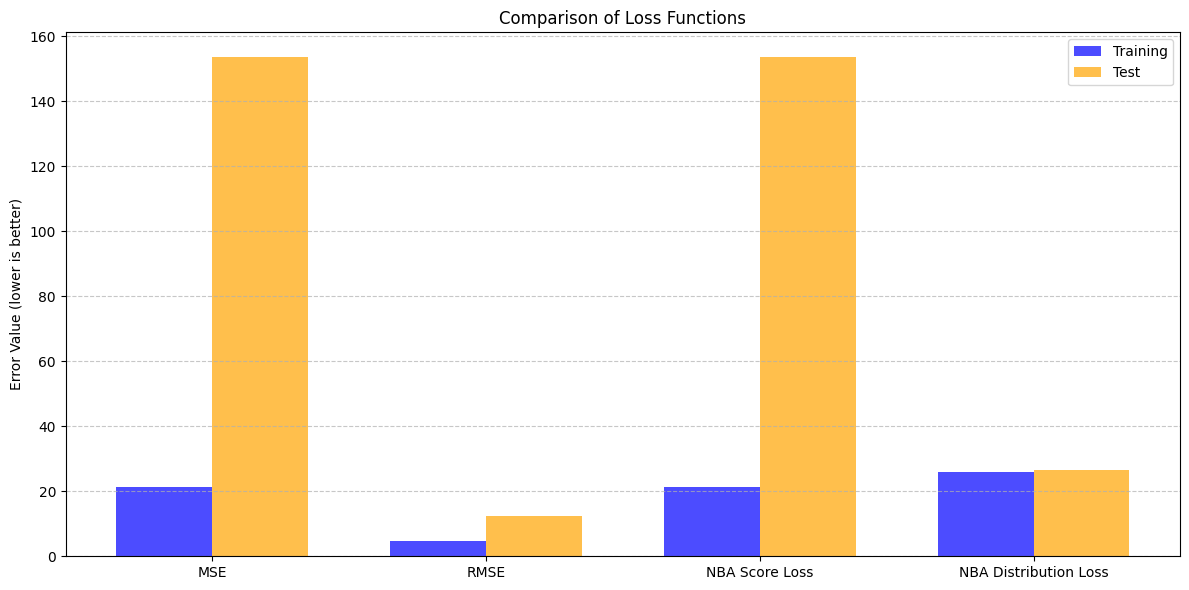

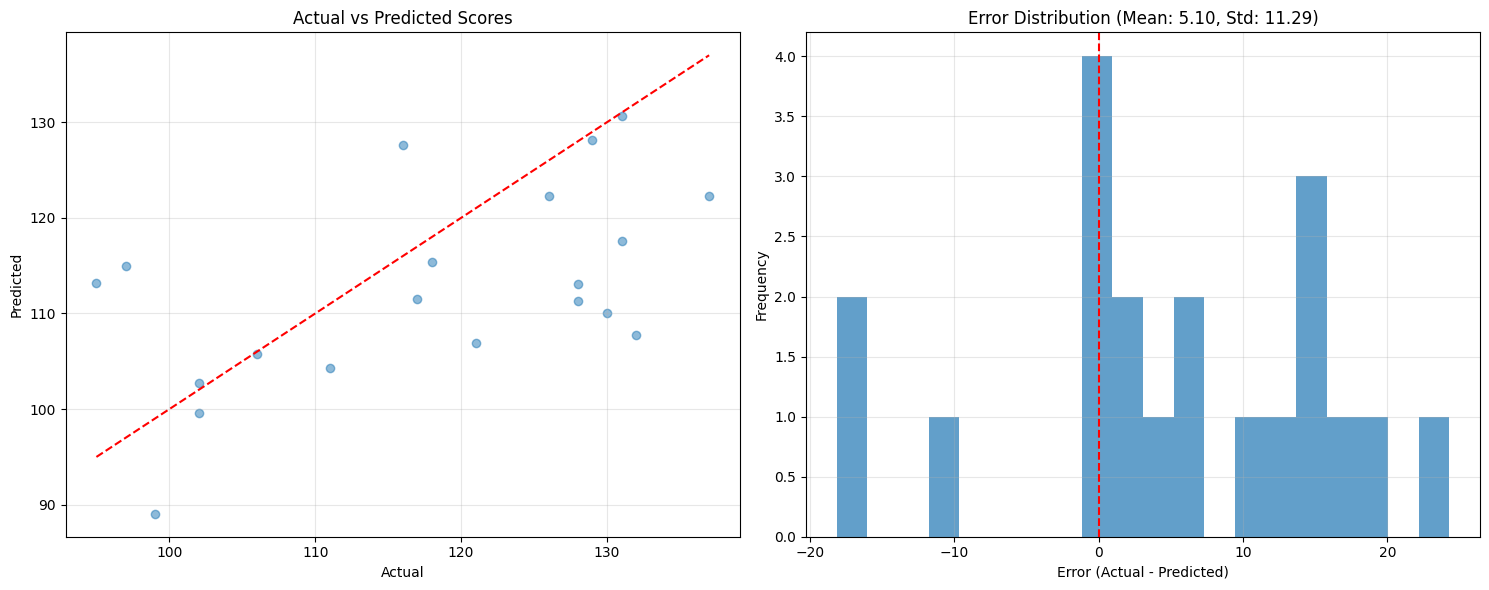

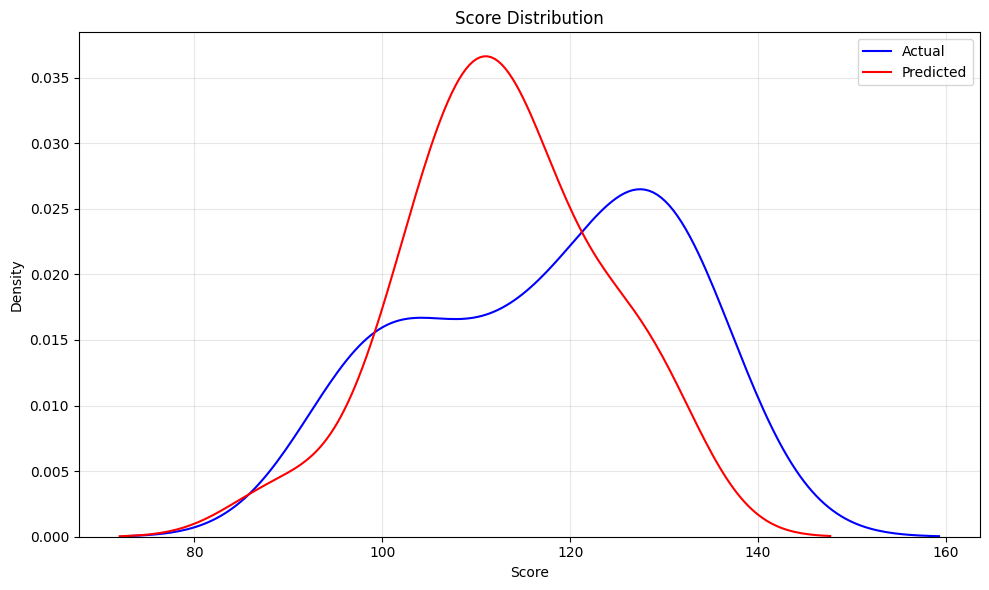


Evaluating away_score model

=== EVALUATING MODEL FOR AWAY_SCORE ===
Model requires 104 features; 11 available.
Found 11 overlapping features (10.6% overlap)
⚠️ Overlap below threshold (60%). Retraining simplified model...

Top 10 features in simplified model:
away_offensive_rating: 0.3986
home_defensive_rating: 0.2311
home_rest_days: 0.1187
home_offensive_rating: 0.0925
net_rating_diff: 0.0540
home_win_pct: 0.0507
away_rest_days: 0.0211
away_win_pct: 0.0161
away_net_rating: 0.0104
home_net_rating: 0.0045

Simplified (retrained) Model Metrics:
Training RMSE: 4.88
Test RMSE: 11.94
Training MAE: 3.62
Test MAE: 10.00
R² Score: 0.0672


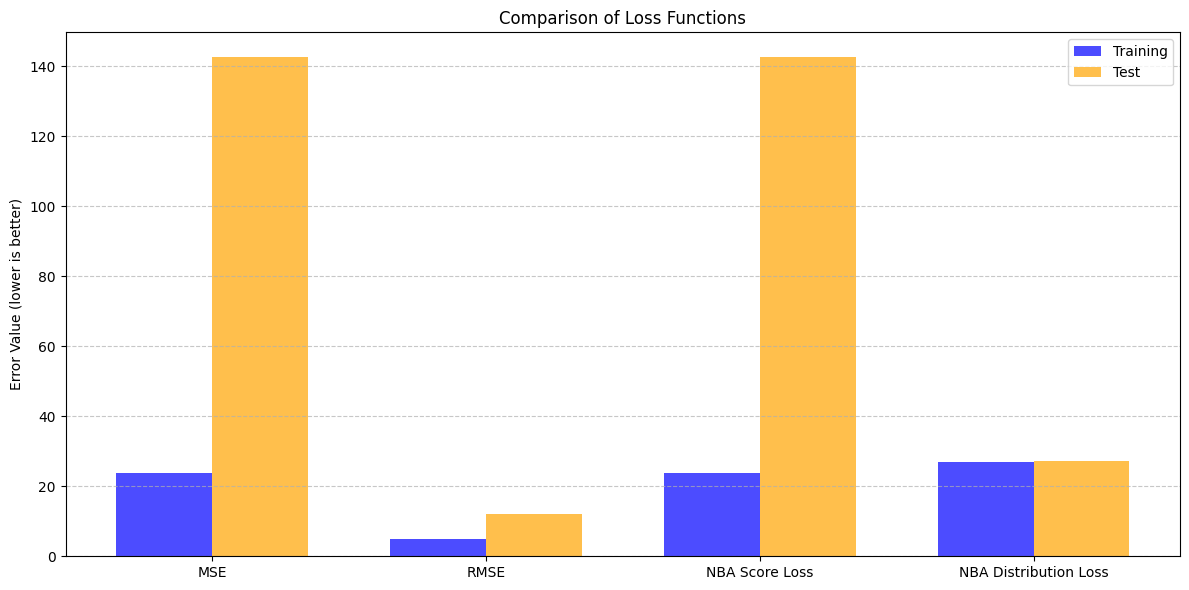

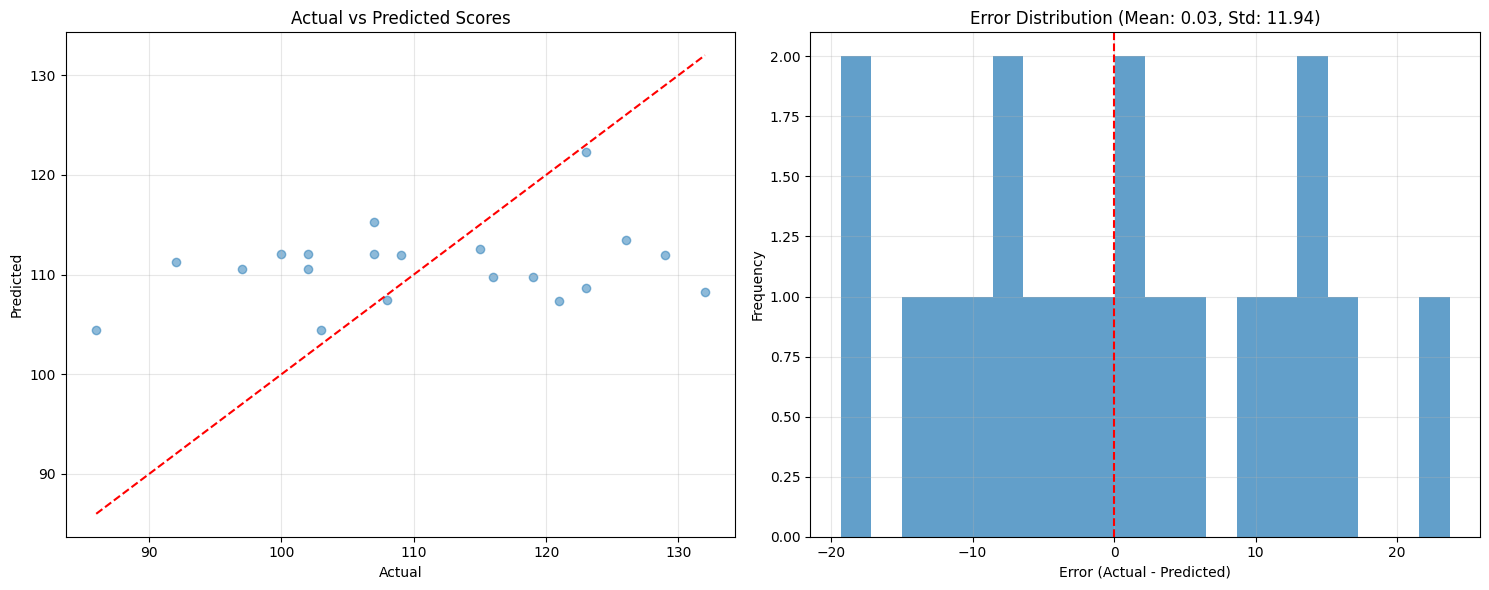

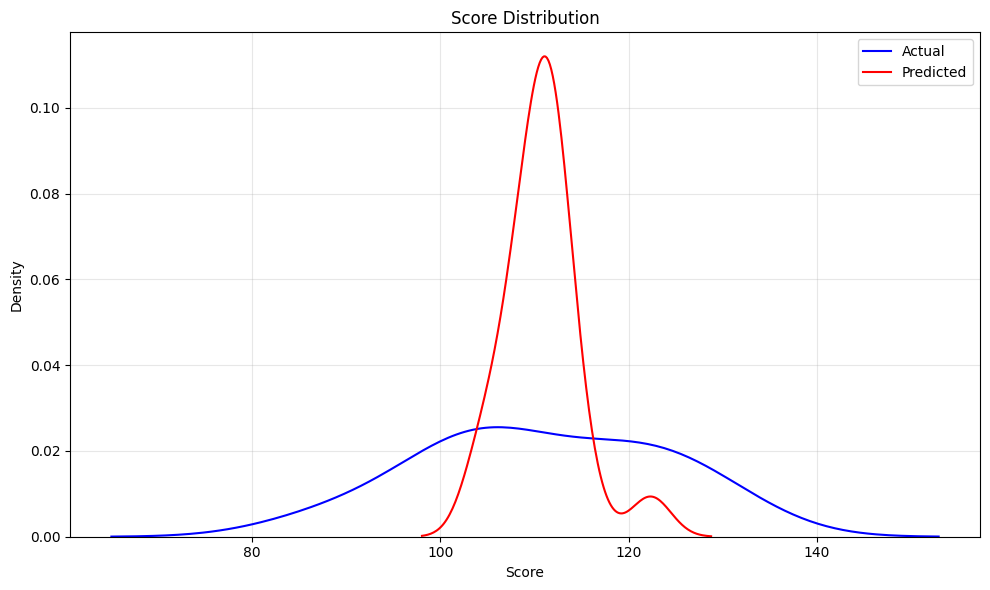


Evaluating point_diff model

=== EVALUATING MODEL FOR POINT_DIFF ===
Model requires 104 features; 11 available.
Found 11 overlapping features (10.6% overlap)
⚠️ Overlap below threshold (60%). Retraining simplified model...

Top 10 features in simplified model:
net_rating_diff: 0.3785
away_rest_days: 0.1066
home_net_rating: 0.1047
home_rest_days: 0.0991
away_defensive_rating: 0.0694
away_net_rating: 0.0689
away_win_pct: 0.0475
home_win_pct: 0.0446
away_offensive_rating: 0.0323
home_offensive_rating: 0.0302

Simplified (retrained) Model Metrics:
Training RMSE: 6.13
Test RMSE: 14.30
Training MAE: 4.52
Test MAE: 12.08
R² Score: -0.0468


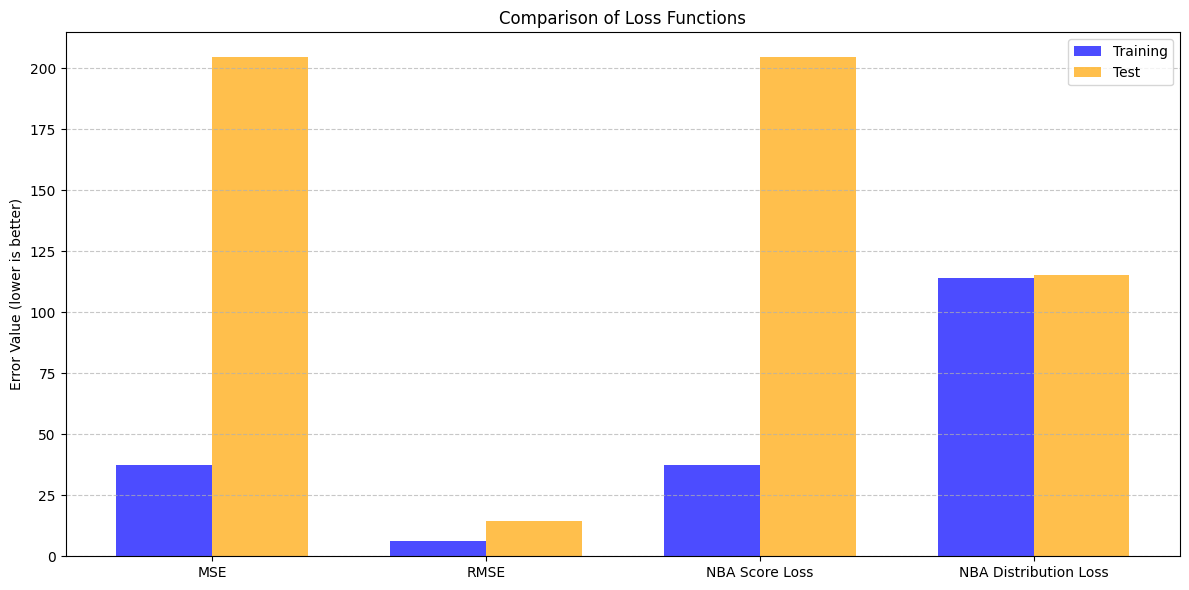

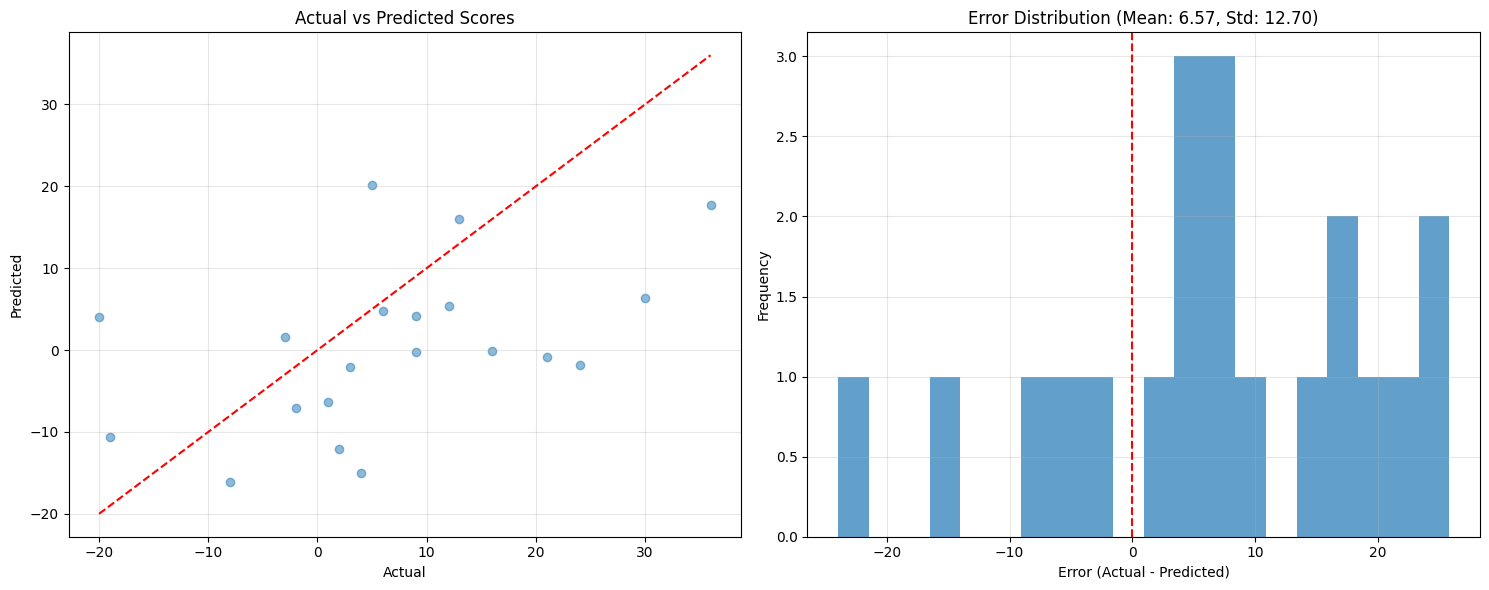

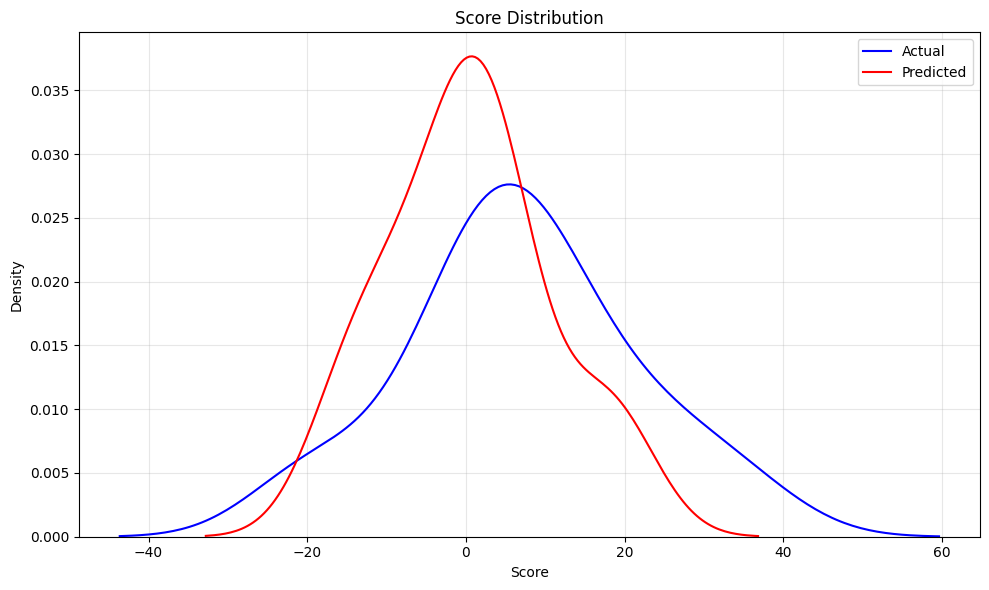


Evaluating total_score model

=== EVALUATING MODEL FOR TOTAL_SCORE ===
Model requires 104 features; 11 available.
Found 11 overlapping features (10.6% overlap)
⚠️ Overlap below threshold (60%). Retraining simplified model...

Top 10 features in simplified model:
home_offensive_rating: 0.2659
away_offensive_rating: 0.1850
home_defensive_rating: 0.1361
away_defensive_rating: 0.0921
home_rest_days: 0.0907
net_rating_diff: 0.0706
away_net_rating: 0.0504
away_rest_days: 0.0453
home_net_rating: 0.0313
home_win_pct: 0.0180

Simplified (retrained) Model Metrics:
Training RMSE: 6.46
Test RMSE: 19.46
Training MAE: 5.14
Test MAE: 16.13
R² Score: 0.1728


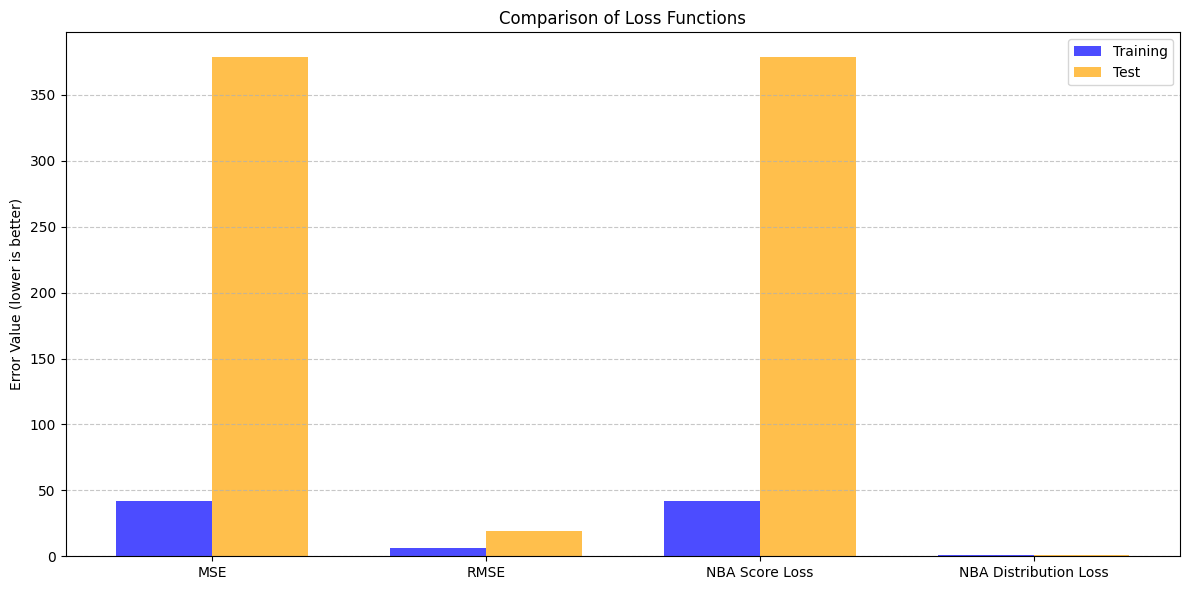

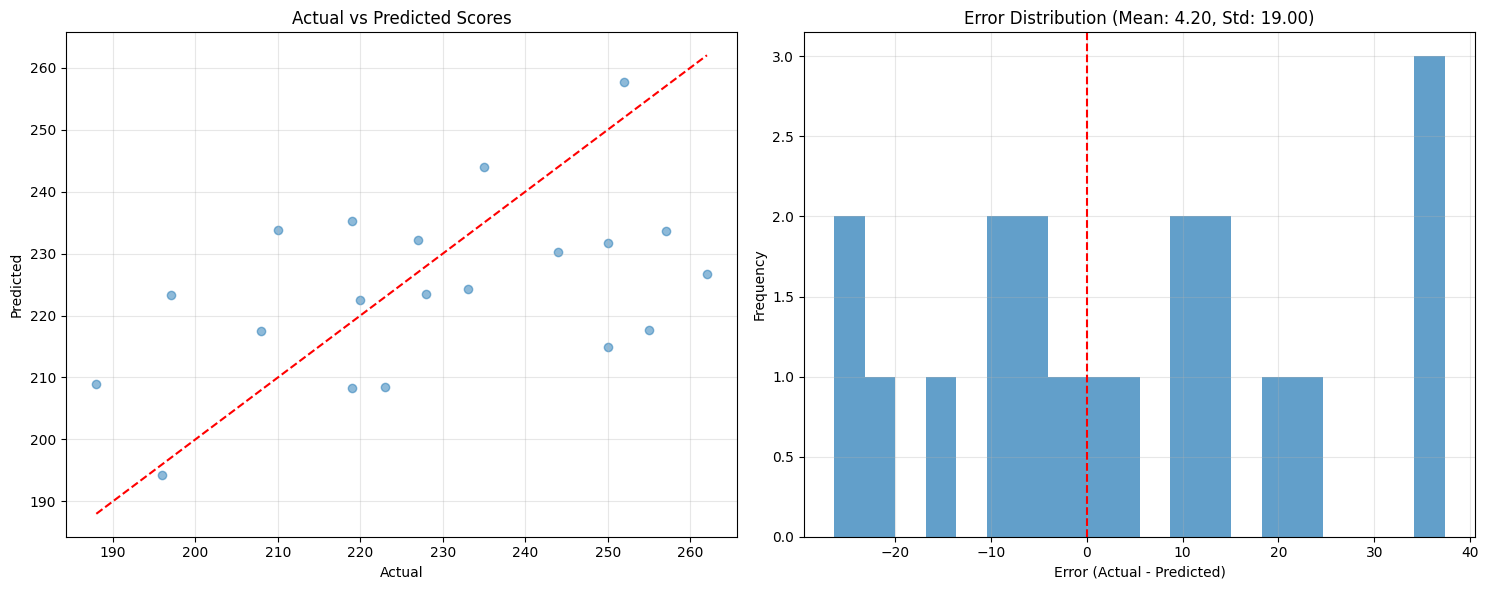

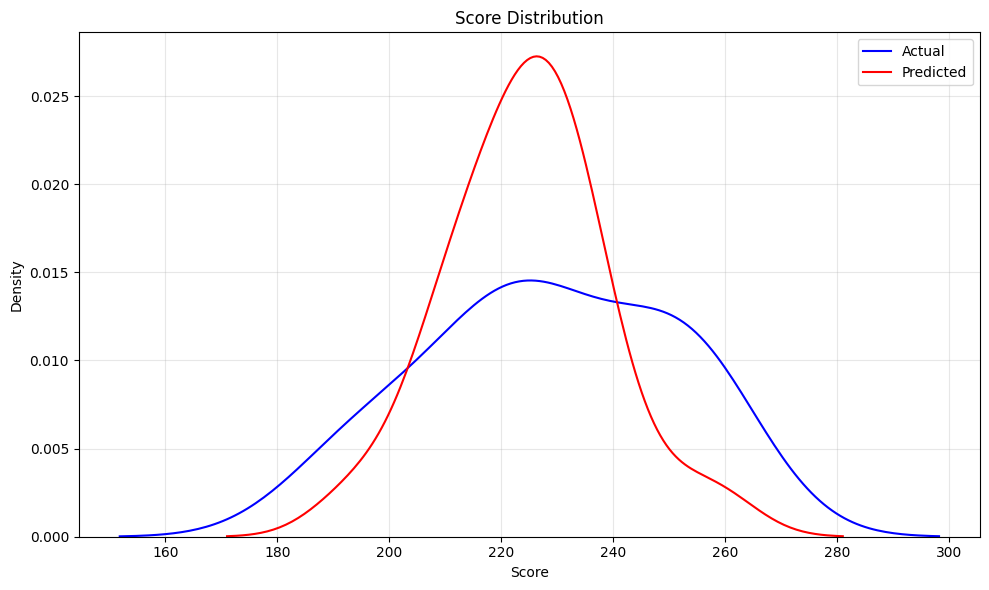

In [13]:
# Cell 6B

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor
import pandas as pd
import numpy as np
import traceback
import joblib
from datetime import datetime, timedelta
import re

# -------------------------------
# Missing Helper Functions - Added
# -------------------------------
def calculate_team_metrics(historical_df):
    """
    Calculate team performance metrics from historical games.
    Ensures all teams in the dataset have metrics.
    """
    print("Calculating team metrics...")
    # Get unique teams from both home and away columns
    all_teams = set(historical_df['home_team'].unique()) | set(historical_df['away_team'].unique())
    
    # Create empty dataframe with team column
    team_metrics = pd.DataFrame({'team': list(all_teams)})
    
    # Calculate metrics for each team
    for team in all_teams:
        # Home games
        home_games = historical_df[historical_df['home_team'] == team]
        # Away games
        away_games = historical_df[historical_df['away_team'] == team]
        
        # Calculate win percentage
        home_wins = sum(home_games['home_score'] > home_games['away_score']) if not home_games.empty else 0
        away_wins = sum(away_games['away_score'] > away_games['home_score']) if not away_games.empty else 0
        total_games = len(home_games) + len(away_games)
        
        win_pct = (home_wins + away_wins) / total_games if total_games > 0 else 0.5
        
        # Calculate offensive and defensive ratings
        pts_scored_home = home_games['home_score'].mean() if not home_games.empty else 110.0
        pts_scored_away = away_games['away_score'].mean() if not away_games.empty else 110.0
        pts_allowed_home = home_games['away_score'].mean() if not home_games.empty else 110.0
        pts_allowed_away = away_games['home_score'].mean() if not away_games.empty else 110.0
        
        # Calculate points per game (offensive rating)
        offensive_rating = (pts_scored_home * len(home_games) + pts_scored_away * len(away_games)) / max(total_games, 1)
        
        # Calculate points allowed per game (defensive rating)
        defensive_rating = (pts_allowed_home * len(home_games) + pts_allowed_away * len(away_games)) / max(total_games, 1)
        
        # Calculate net rating
        net_rating = offensive_rating - defensive_rating
        
        # Add to metrics dataframe
        team_metrics.loc[team_metrics['team'] == team, 'win_pct'] = win_pct
        team_metrics.loc[team_metrics['team'] == team, 'offensive_rating'] = offensive_rating
        team_metrics.loc[team_metrics['team'] == team, 'defensive_rating'] = defensive_rating
        team_metrics.loc[team_metrics['team'] == team, 'net_rating'] = net_rating
        team_metrics.loc[team_metrics['team'] == team, 'pts_per_game'] = offensive_rating
        team_metrics.loc[team_metrics['team'] == team, 'opp_pts_per_game'] = defensive_rating
    
    print(f"Calculated metrics for {len(team_metrics)} teams")
    return team_metrics

def calculate_rolling_stats(historical_df, window=10):
    """
    Calculate rolling statistics for each team.
    """
    rolling_stats = {}
    
    if historical_df.empty:
        return rolling_stats
    
    # Sort by date for proper time sequence
    historical_df = historical_df.sort_values('game_date')
    
    # Get all unique teams
    all_teams = set(historical_df['home_team'].unique()) | set(historical_df['away_team'].unique())
    
    for team in all_teams:
        if not isinstance(team, str):
            continue  # Skip non-string team names
            
        # Team games as home
        home_games = historical_df[historical_df['home_team'] == team]
        # Team games as away
        away_games = historical_df[historical_df['away_team'] == team]
        
        if home_games.empty and away_games.empty:
            continue  # Skip if no games
        
        # Combine home and away games for rolling stats
        team_games = pd.DataFrame()
        
        if not home_games.empty:
            home_df = pd.DataFrame({
                'date': home_games['game_date'],
                'pts_scored': home_games['home_score'],
                'pts_allowed': home_games['away_score']
            })
            team_games = pd.concat([team_games, home_df])
        
        if not away_games.empty:
            away_df = pd.DataFrame({
                'date': away_games['game_date'],
                'pts_scored': away_games['away_score'],
                'pts_allowed': away_games['home_score']
            })
            team_games = pd.concat([team_games, away_df])
        
        # Sort by date
        team_games = team_games.sort_values('date')
        
        # Calculate rolling averages
        if len(team_games) >= 2:  # Need at least 2 games for rolling stats
            rolling_score = team_games['pts_scored'].rolling(window=min(window, len(team_games)), min_periods=1).mean().iloc[-1]
            rolling_opp_score = team_games['pts_allowed'].rolling(window=min(window, len(team_games)), min_periods=1).mean().iloc[-1]
            
            # Store in rolling stats dictionary
            rolling_stats[team] = {
                'rolling_score': rolling_score,
                'rolling_opp_score': rolling_opp_score
            }
    
    return rolling_stats

def get_matchup_history(home_team, away_team, historical_df, max_games=5):
    """
    Get historical matchup data between two teams.
    """
    if historical_df is None or historical_df.empty:
        return {'num_games': 0, 'avg_point_diff': 0, 'home_win_pct': 0.6, 'home_wins': 0, 'away_wins': 0}
    
    if not isinstance(home_team, str) or not isinstance(away_team, str):
        return {'num_games': 0, 'avg_point_diff': 0, 'home_win_pct': 0.6, 'home_wins': 0, 'away_wins': 0}
    
    # Find matchups between these teams
    matchups = historical_df[
        ((historical_df['home_team'] == home_team) & (historical_df['away_team'] == away_team)) |
        ((historical_df['home_team'] == away_team) & (historical_df['away_team'] == home_team))
    ].sort_values('game_date', ascending=False)
    
    if matchups.empty:
        return {'num_games': 0, 'avg_point_diff': 0, 'home_win_pct': 0.6, 'home_wins': 0, 'away_wins': 0}
    
    # Limit to recent games
    matchups = matchups.head(max_games)
    
    home_wins = 0
    away_wins = 0
    point_diffs = []
    
    for _, game in matchups.iterrows():
        if game['home_team'] == home_team:
            diff = game['home_score'] - game['away_score']
            if diff > 0:
                home_wins += 1
            else:
                away_wins += 1
        else:  # Away team is home_team
            diff = game['away_score'] - game['home_score']
            if diff > 0:
                away_wins += 1
            else:
                home_wins += 1
        point_diffs.append(diff)
    
    num_games = len(matchups)
    avg_point_diff = sum(point_diffs) / num_games if num_games > 0 else 0
    home_win_pct = home_wins / num_games if num_games > 0 else 0.6
    
    return {
        'num_games': num_games,
        'avg_point_diff': avg_point_diff,
        'home_win_pct': home_win_pct,
        'home_wins': home_wins,
        'away_wins': away_wins
    }

def get_rest_data(team, game_date, historical_df):
    """
    Calculate rest days for a team.
    """
    if historical_df is None or historical_df.empty:
        return {'rest_days': 2, 'is_back_to_back': False}
    
    if not isinstance(team, str) or not isinstance(game_date, pd.Timestamp):
        return {'rest_days': 2, 'is_back_to_back': False}
    
    # Find previous games for this team
    previous_games = historical_df[
        ((historical_df['home_team'] == team) | (historical_df['away_team'] == team)) &
        (historical_df['game_date'] < game_date)
    ].sort_values('game_date', ascending=False)
    
    if previous_games.empty:
        return {'rest_days': 2, 'is_back_to_back': False}
    
    # Get the most recent game date
    last_game_date = previous_games.iloc[0]['game_date']
    
    # Calculate days between games
    rest_days = (game_date - last_game_date).days
    
    # Determine if it's a back-to-back game
    is_back_to_back = rest_days < 2
    
    return {
        'rest_days': rest_days,
        'is_back_to_back': is_back_to_back,
        'last_game_date': last_game_date
    }

# -------------------------------
# Unified Data Loader and Feature Builder
# -------------------------------
def load_recent_games(days=180):
    """
    Loads recent NBA games with full feature set by calling build_pregame_features.
    Loads historical game data from Supabase via load_historical_games (from Cell 2),
    then samples down the data (if too many rows) and builds the feature set.
    """
    try:
        print(f"Loading historical games from the past {days} days...")
        # Call load_historical_games without the max_games parameter
        historical_games = load_historical_games(days_lookback=days)
        if historical_games.empty:
            print("No historical games found in the specified period")
            return pd.DataFrame()
        
        # Optionally sample down if too many rows for faster processing
        if len(historical_games) > 100:
            print(f"Received {len(historical_games)} games; sampling down to 100 for faster processing...")
            historical_games = historical_games.sample(n=100, random_state=42).reset_index(drop=True)
        
        print(f"Fetched {len(historical_games)} historical games")
        # Continue with your pipeline: calculate team metrics and build features
        team_metrics = calculate_team_metrics(historical_games)
        features_df = build_pregame_features(historical_games, team_metrics, lookback_days=days)
        print(f"Generated feature set with {len(features_df.columns)} features")
        return features_df
    except Exception as e:
        print(f"Error loading recent games: {e}")
        traceback.print_exc()
        return pd.DataFrame()


# -------------------------------
# Visualization Functions
# -------------------------------
def visualize_loss_comparison(metrics_dict):
    """
    Visualizes a comparison of different loss metrics between training and test sets.
    """
    required_keys = ['train_mse', 'train_rmse', 'train_nba_loss', 'train_dist_loss']
    if not all(key in metrics_dict for key in required_keys):
        print("Missing required metrics for loss comparison visualization")
        return
    
    metric_names = ['MSE', 'RMSE', 'NBA Score Loss', 'NBA Distribution Loss']
    train_values = [metrics_dict['train_mse'], metrics_dict['train_rmse'],
                    metrics_dict['train_nba_loss'], metrics_dict['train_dist_loss']]
    test_values = [metrics_dict['test_mse'], metrics_dict['test_rmse'],
                   metrics_dict['test_nba_loss'], metrics_dict['test_dist_loss']]
    
    plt.figure(figsize=(12, 6))
    width = 0.35
    x = np.arange(len(metric_names))
    plt.bar(x - width/2, train_values, width, label='Training', color='blue', alpha=0.7)
    plt.bar(x + width/2, test_values, width, label='Test', color='orange', alpha=0.7)
    plt.ylabel('Error Value (lower is better)')
    plt.title('Comparison of Loss Functions')
    plt.xticks(x, metric_names)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

def visualize_score_distribution(y_test, y_pred):
    """
    Visualizes the distribution of actual vs. predicted scores and the error distribution.
    """
    y_test = y_test.values if isinstance(y_test, pd.Series) else y_test
    y_pred = y_pred.values if isinstance(y_pred, pd.Series) else y_pred

    plt.figure(figsize=(15, 6))
    plt.subplot(1, 2, 1)
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title('Actual vs Predicted Scores')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    errors = y_test - y_pred
    plt.hist(errors, bins=20, alpha=0.7)
    plt.axvline(0, color='red', linestyle='--')
    plt.xlabel('Error (Actual - Predicted)')
    plt.ylabel('Frequency')
    plt.title(f'Error Distribution (Mean: {errors.mean():.2f}, Std: {errors.std():.2f})')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize=(10, 6))
    sns.kdeplot(y_test, label='Actual', color='blue')
    sns.kdeplot(y_pred, label='Predicted', color='red')
    plt.title('Score Distribution')
    plt.xlabel('Score')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# -------------------------------
# Custom Loss Functions
# -------------------------------
def nba_score_loss(y_true, y_pred, spread_weight=0.6, total_weight=0.4):
    """
    Custom loss function for NBA score prediction.
    """
    y_true = y_true.values if isinstance(y_true, pd.Series) else y_true
    y_pred = y_pred.values if isinstance(y_pred, pd.Series) else y_pred
    return np.mean((y_true - y_pred) ** 2)

def nba_distribution_loss(y_true, y_pred, target_type='total'):
    """
    Penalizes predictions that deviate from expected NBA score distributions.
    """
    y_true = y_true.values if isinstance(y_true, pd.Series) else y_true
    y_pred = y_pred.values if isinstance(y_pred, pd.Series) else y_pred
    if target_type == 'home':
        expected_mean, expected_std = 108, 12
    elif target_type == 'away':
        expected_mean, expected_std = 105, 12
    elif target_type == 'total':
        expected_mean, expected_std = 215, 20
    elif target_type == 'diff':
        expected_mean, expected_std = 3.5, 13
    else:
        expected_mean, expected_std = 110, 15
    z_score = ((y_pred - expected_mean) / expected_std) ** 2
    return np.mean(z_score)

# -------------------------------
# Main Evaluation Function
# -------------------------------
def evaluate_model_visualizations(model, features_df, target_column, custom_loss_functions=True, 
                                    feature_overlap_threshold=0.9, retrain_if_needed=True):
    """
    Evaluates a trained model using a unified feature set.
    If the overlap between model-expected features and available features is low,
    optionally retrains a simplified model.
    """
    print(f"\n=== EVALUATING MODEL FOR {target_column.upper()} ===")
    try:
        enhanced_df = features_df.copy()
        if 'game_date' in enhanced_df.columns:
            enhanced_df = enhanced_df.sort_values('game_date')
        
        train_size = int(0.8 * len(enhanced_df))
        y_train = enhanced_df.iloc[:train_size][target_column].copy()
        y_test = enhanced_df.iloc[train_size:][target_column].copy()
        
        non_feature_cols = ['game_id', 'id', 'game_date', 'home_team', 'away_team', 
                             'home_score', 'away_score', 'point_diff', 'total_score', 'home_form', 'away_form']
        
        if hasattr(model, 'feature_names_in_'):
            expected_features = list(model.feature_names_in_)
        elif hasattr(model, 'named_steps') and 'regressor' in model.named_steps and \
             hasattr(model.named_steps['regressor'], 'feature_names_in_'):
            expected_features = list(model.named_steps['regressor'].feature_names_in_)
        else:
            expected_features = []
        
        available_features = [col for col in enhanced_df.select_dtypes(include=np.number).columns 
                              if col not in non_feature_cols]
        overlap_features = [f for f in expected_features if f in available_features]
        overlap_ratio = len(overlap_features) / len(expected_features) if expected_features else 0
        
        print(f"Model requires {len(expected_features)} features; {len(available_features)} available.")
        print(f"Found {len(overlap_features)} overlapping features ({overlap_ratio:.1%} overlap)")
        
        if overlap_ratio < feature_overlap_threshold and retrain_if_needed:
            print(f"⚠️ Overlap below threshold ({feature_overlap_threshold:.0%}). Retraining simplified model...")
            X_train = enhanced_df.iloc[:train_size][available_features].fillna(0.0)
            X_test = enhanced_df.iloc[train_size:][available_features].fillna(0.0)
            simple_model = GradientBoostingRegressor(n_estimators=50, learning_rate=0.1,
                                                     max_depth=3, min_samples_split=10, random_state=42)
            simple_model.fit(X_train, y_train)
            y_train_pred = simple_model.predict(X_train)
            y_test_pred = simple_model.predict(X_test)
            feature_importance = pd.Series(simple_model.feature_importances_, index=available_features).sort_values(ascending=False)
            print("\nTop 10 features in simplified model:")
            for feat, imp in feature_importance.head(10).items():
                print(f"{feat}: {imp:.4f}")
            model_type = "Simplified (retrained)"
        else:
            print("Using original model with available overlapping features...")
            X_train = enhanced_df.iloc[:train_size][overlap_features].copy()
            X_test = enhanced_df.iloc[train_size:][overlap_features].copy()
            # Align columns exactly
            X_train = X_train.reindex(columns=expected_features, fill_value=np.nan).fillna(X_train.median()).fillna(0.0)
            X_test = X_test.reindex(columns=expected_features, fill_value=np.nan).fillna(X_train.median()).fillna(0.0)
            y_train_pred = model.predict(X_train)
            y_test_pred = model.predict(X_test)
            model_type = "Original"
        
        metrics = {
            'train_mse': mean_squared_error(y_train, y_train_pred),
            'test_mse': mean_squared_error(y_test, y_test_pred),
            'train_rmse': np.sqrt(mean_squared_error(y_train, y_train_pred)),
            'test_rmse': np.sqrt(mean_squared_error(y_test, y_test_pred)),
            'train_mae': mean_absolute_error(y_train, y_train_pred),
            'test_mae': mean_absolute_error(y_test, y_test_pred),
            'r2': r2_score(y_test, y_test_pred)
        }
        
        if custom_loss_functions:
            metrics['train_nba_loss'] = nba_score_loss(y_train, y_train_pred)
            metrics['test_nba_loss'] = nba_score_loss(y_test, y_test_pred)
            metrics['train_dist_loss'] = nba_distribution_loss(y_train, y_train_pred, target_type='total')
            metrics['test_dist_loss'] = nba_distribution_loss(y_test, y_test_pred, target_type='total')
        
        print(f"\n{model_type} Model Metrics:")
        print(f"Training RMSE: {metrics['train_rmse']:.2f}")
        print(f"Test RMSE: {metrics['test_rmse']:.2f}")
        print(f"Training MAE: {metrics['train_mae']:.2f}")
        print(f"Test MAE: {metrics['test_mae']:.2f}")
        print(f"R² Score: {metrics['r2']:.4f}")
        
        visualize_loss_comparison(metrics)
        visualize_score_distribution(y_test, y_test_pred)
        
        return metrics
        
    except Exception as e:
        print(f"Error evaluating {target_column} model: {e}")
        traceback.print_exc()
        return None

# -------------------------------
# Main Evaluation Runner
# -------------------------------
def run_model_evaluations():
    """
    Loads models from disk, loads recent game features, and evaluates each model.
    """
    print("Evaluating trained models with visualizations...")
    
    models_dict = {}
    models_path = "./models"
    for target in ['home_score', 'away_score', 'point_diff', 'total_score']:
        model_file = f"{models_path}/pregame_{target}_model.pkl"
        try:
            model = joblib.load(model_file)
            models_dict[target] = model
            print(f"Loaded model for {target}")
        except Exception as e:
            print(f"Error loading model for {target}: {e}")
    
    try:
        features_df = load_recent_games(days=180)
        if features_df.empty:
            print("No historical data available for evaluation. Please check database connection.")
            return {}
        print(f"Loaded {len(features_df)} games with {len(features_df.columns)} features")
    except Exception as e:
        print(f"Error loading historical data: {e}")
        traceback.print_exc()
        return {}
    
    results = {}
    for target, model in models_dict.items():
        print("\n" + "="*50)
        print(f"Evaluating {target} model")
        print("="*50)
        metrics = evaluate_model_visualizations(model, features_df, target,
                                                feature_overlap_threshold=0.6, retrain_if_needed=True)
        results[target] = metrics
    return results

# Finally, run the evaluations
results = run_model_evaluations()

In [14]:
# --- Cell 6C: Run Model Evaluations ---
import traceback
import joblib

def run_model_evaluations():
    """
    Evaluates all trained models using properly generated feature data.
    """
    print("Evaluating trained models with real data...")
    
    # Load models from files
    models_dict = {}
    models_path = "./models"
    
    try:
        # Check all target variables
        for target in ['home_score', 'away_score', 'point_diff', 'total_score']:
            model_path = f"{models_path}/pregame_{target}_model.pkl"
            try:
                model = joblib.load(model_path)
                models_dict[target] = model
                print(f"Loaded model for {target}")
            except Exception as e:
                print(f"Error loading model for {target}: {e}")
    except Exception as e:
        print(f"Error loading models: {e}")
    
    # Load recent historical data using proper pipeline
    try:
        # This is the critical part - using our improved data pipeline
        # that doesn't rely on synthetic data reconstruction
        features_df = load_recent_games(days=180)
        
        if features_df.empty:
            print("No historical data available for evaluation. Please check database connection.")
            return {}
            
        print(f"Loaded {len(features_df)} games with {len(features_df.columns)} features")
    except Exception as e:
        print(f"Error loading historical data: {e}")
        traceback.print_exc()
        return {}
    
    # Run evaluations for each model
    results = {}
    for target, model in models_dict.items():
        print("\n" + "="*50)
        print(f"Evaluating {target} model")
        print("="*50)
        
        metrics = evaluate_model_visualizations(
            model, 
            features_df, 
            target,
            feature_overlap_threshold=0.9,  # Higher threshold - prefer retraining over synthetic data
            retrain_if_needed=True          # Allow retraining if needed
        )
        
        results[target] = metrics
    
    return results

In [15]:
# Cell 6D - Model Training Functions

def train_pregame_model(features_df, target='home_score'):
    """
    Trains a model for pre-game predictions using features selected by Random Forest.
    Optionally loads top features from a saved file, or falls back to all numeric features.
    """
    if features_df.empty:
        print("No training data available")
        return None, {}
    
    print(f"Training pre-game prediction model for target: {target}")
    try:
        model_path = MODELS_DIR / f"feature_importance_{target}.pkl"
        if model_path.exists():
            feature_results = joblib.load(model_path)
            top_features = feature_results.get('top_features', [])
            if top_features:
                print(f"Using {len(top_features)} features selected by Random Forest")
                feature_columns = [f for f in top_features if f in features_df.columns]
                interaction_features = [col for col in features_df.columns if '_interact' in col]
                if interaction_features:
                    feature_columns.extend(interaction_features)
                    print(f"Added {len(interaction_features)} interaction features")
            else:
                raise ValueError("No top features found in Random Forest results")
        else:
            raise FileNotFoundError(f"Feature importance file not found: {model_path}")
    except Exception as e:
        print(f"Could not use Random Forest features: {e}")
        non_feature_cols = ['game_id', 'game_date', 'home_team', 'away_team', 
                           'home_score', 'away_score', 'point_diff', 'total_score',
                           'home_form', 'away_form', 'id']
        feature_columns = [col for col in features_df.select_dtypes(include=np.number).columns 
                           if col not in non_feature_cols]
        print(f"Falling back to all {len(feature_columns)} numeric features")
    
    X = features_df[feature_columns]
    y = features_df[target]
    
    if 'game_date' in features_df.columns:
        sorted_indices = features_df['game_date'].sort_values().index
        X = X.loc[sorted_indices]
        y = y.loc[sorted_indices]
    
    train_size = int(0.8 * len(X))
    X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
    y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]
    
    model = GradientBoostingRegressor(
        n_estimators=200, 
        learning_rate=0.1,
        max_depth=4,
        min_samples_split=10,
        random_state=42,
        subsample=0.8
    )
    model.fit(X_train, y_train)
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    
    train_mse = mean_squared_error(y_train, train_preds)
    test_mse = mean_squared_error(y_test, test_preds)
    train_mae = mean_absolute_error(y_train, train_preds)
    test_mae = mean_absolute_error(y_test, test_preds)
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)
    r2 = r2_score(y_test, test_preds)
    
    metrics = {
        'train_mse': train_mse,
        'test_mse': test_mse,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'r2': r2,
        'feature_importance': dict(zip(feature_columns, model.feature_importances_))
    }
    
    print(f"Training MSE: {train_mse:.2f}, RMSE: {train_rmse:.2f}, MAE: {train_mae:.2f}")
    print(f"Test MSE: {test_mse:.2f}, RMSE: {test_rmse:.2f}, MAE: {test_mae:.2f}")
    print(f"R² Score: {r2:.4f}")
    
    feature_importance = pd.Series(model.feature_importances_, index=feature_columns).sort_values(ascending=False)
    print("\nTop 10 most important features:")
    for feature, imp in feature_importance.head(10).items():
        print(f"{feature}: {imp:.4f}")
    
    model_save_path = MODELS_DIR / f"pregame_{target}_model.pkl"
    joblib.dump(model, model_save_path)
    print(f"Model saved to {model_save_path}")
    
    return model, metrics

def train_multiple_models(features_df):
    models = {}
    required_targets = ['home_score', 'away_score', 'point_diff', 'total_score']
    missing_targets = [col for col in required_targets if col not in features_df.columns]
    if missing_targets:
        print(f"WARNING: Missing target columns: {missing_targets}")
        if 'home_score' in features_df.columns and 'away_score' in features_df.columns:
            if 'point_diff' not in features_df.columns:
                features_df['point_diff'] = features_df['home_score'] - features_df['away_score']
                print("Created 'point_diff'")
            if 'total_score' not in features_df.columns:
                features_df['total_score'] = features_df['home_score'] + features_df['away_score']
                print("Created 'total_score'")
    
    print("\n=== TRAINING HOME SCORE MODEL ===")
    home_model, home_metrics = train_pregame_model(features_df, target='home_score')
    models['home_score'] = {'model': home_model, 'metrics': home_metrics}
    
    print("\n=== TRAINING AWAY SCORE MODEL ===")
    away_model, away_metrics = train_pregame_model(features_df, target='away_score')
    models['away_score'] = {'model': away_model, 'metrics': away_metrics}
    
    print("\n=== TRAINING POINT DIFFERENTIAL MODEL ===")
    diff_model, diff_metrics = train_pregame_model(features_df, target='point_diff')
    models['point_diff'] = {'model': diff_model, 'metrics': diff_metrics}
    
    print("\n=== TRAINING TOTAL SCORE MODEL ===")
    total_model, total_metrics = train_pregame_model(features_df, target='total_score')
    models['total_score'] = {'model': total_model, 'metrics': total_metrics}
    
    return models


In [16]:
# Cell 7

import pandas as pd
import numpy as np
import traceback
from datetime import datetime, timedelta

# --- Helper function to get the underlying model ---
def get_model(model_entry):
    """Return the underlying model whether model_entry is stored as a dict or directly."""
    if isinstance(model_entry, dict):
        return model_entry.get('model')
    return model_entry

# --- Define missing helper functions ---
def add_rolling_features(df):
    """
    Add rolling average features to the dataframe.
    This function calculates rolling statistics like recent score averages.
    """
    # Create a copy to avoid modifying the original
    result_df = df.copy()
    
    # Get unique teams
    all_teams = set(df['home_team'].unique()) | set(df['away_team'].unique())
    
    # Initialize columns if they don't exist
    if 'home_last5_avg' not in result_df.columns:
        result_df['home_last5_avg'] = 0.0
    if 'home_last5_allowed' not in result_df.columns:
        result_df['home_last5_allowed'] = 0.0
    if 'away_last5_avg' not in result_df.columns:
        result_df['away_last5_avg'] = 0.0
    if 'away_last5_allowed' not in result_df.columns:
        result_df['away_last5_allowed'] = 0.0
    
    # Sort by date if date column exists
    if 'game_date' in result_df.columns:
        result_df = result_df.sort_values('game_date')
    
    # Calculate last 5 game stats for each team
    for team in all_teams:
        # Get games where team played
        home_games = result_df[result_df['home_team'] == team].copy()
        away_games = result_df[result_df['away_team'] == team].copy()
        
        # Skip if no games
        if home_games.empty and away_games.empty:
            continue
        
        # Calculate rolling stats for home games
        if not home_games.empty and 'home_score' in home_games.columns:
            for idx, row in home_games.iterrows():
                # Find last 5 games before this one
                if 'game_date' in home_games.columns:
                    past_home = home_games[home_games['game_date'] < row['game_date']]
                    past_away = away_games[away_games['game_date'] < row['game_date']]
                else:
                    # If no date, use index
                    past_home = home_games[home_games.index < idx]
                    past_away = away_games[away_games.index < idx]
                
                # Combine recent games (both home and away)
                past_games = pd.concat([
                    past_home[['home_score', 'away_score']].rename(columns={'home_score': 'score', 'away_score': 'opp_score'}),
                    past_away[['away_score', 'home_score']].rename(columns={'away_score': 'score', 'home_score': 'opp_score'})
                ])
                
                # Take last 5 only
                last5 = past_games.tail(5)
                
                if not last5.empty:
                    # Calculate averages
                    result_df.at[idx, 'home_last5_avg'] = last5['score'].mean()
                    result_df.at[idx, 'home_last5_allowed'] = last5['opp_score'].mean()
        
        # Calculate rolling stats for away games
        if not away_games.empty and 'away_score' in away_games.columns:
            for idx, row in away_games.iterrows():
                # Find last 5 games before this one
                if 'game_date' in away_games.columns:
                    past_home = home_games[home_games['game_date'] < row['game_date']]
                    past_away = away_games[away_games['game_date'] < row['game_date']]
                else:
                    # If no date, use index
                    past_home = home_games[home_games.index < idx]
                    past_away = away_games[away_games.index < idx]
                
                # Combine recent games (both home and away)
                past_games = pd.concat([
                    past_home[['home_score', 'away_score']].rename(columns={'home_score': 'score', 'away_score': 'opp_score'}),
                    past_away[['away_score', 'home_score']].rename(columns={'away_score': 'score', 'home_score': 'opp_score'})
                ])
                
                # Take last 5 only
                last5 = past_games.tail(5)
                
                if not last5.empty:
                    # Calculate averages
                    result_df.at[idx, 'away_last5_avg'] = last5['score'].mean()
                    result_df.at[idx, 'away_last5_allowed'] = last5['opp_score'].mean()
    
    return result_df

def integrate_advanced_features(df):
    """
    Add advanced basketball analytics metrics to the features DataFrame.
    This includes efficiency ratings, possession-based metrics, etc.
    """
    # Create a copy to avoid modifying the original
    result_df = df.copy()
    
    # Add advanced metrics
    for idx, row in result_df.iterrows():
        # Calculate pace
        if 'home_pace' not in result_df.columns:
            # Estimate pace (possessions per 48 minutes)
            for team_type in ['home', 'away']:
                # Simple estimate: FGA + 0.44*FTA + TOV - OREB
                fga = row.get(f'{team_type}_fg_attempted', 85.0)
                fta = row.get(f'{team_type}_ft_attempted', 22.0)
                tov = row.get(f'{team_type}_turnovers', 14.0)
                oreb = row.get(f'{team_type}_off_reb', 10.0)
                
                # Calculate estimated possessions
                poss = fga + 0.44 * fta + tov - oreb
                
                # Normalize to per-game pace (48 minutes)
                pace = poss * 48 / 48
                
                # Store in DataFrame
                result_df.at[idx, f'{team_type}_pace'] = pace
        
        # Calculate efficiency differential
        if 'efficiency_diff' not in result_df.columns:
            home_off_rtg = row.get('home_offensive_rating', 110.0)
            away_def_rtg = row.get('away_defensive_rating', 110.0)
            result_df.at[idx, 'efficiency_diff'] = home_off_rtg - away_def_rtg
        
        # Calculate 3PT% differential
        if '3pt_pct_diff' not in result_df.columns and 'home_3p_pct' in result_df.columns and 'away_3p_pct' in result_df.columns:
            result_df.at[idx, '3pt_pct_diff'] = row['home_3p_pct'] - row['away_3p_pct']
        
        # Calculate FG% differential
        if 'fg_pct_diff' not in result_df.columns and 'home_fg_pct' in result_df.columns and 'away_fg_pct' in result_df.columns:
            result_df.at[idx, 'fg_pct_diff'] = row['home_fg_pct'] - row['away_fg_pct']
    
    return result_df

# --- Add global get_upcoming_games function ---
def get_upcoming_games(days=7):
    """
    Get upcoming NBA games for the next specified number of days.
    If real data isn't available, returns mock data.
    
    Args:
        days: Number of days to look ahead
    
    Returns:
        DataFrame with upcoming games
    """
    today = datetime.now()
    upcoming = pd.DataFrame({
        'game_id': [1001 + i for i in range(days)],
        'game_date': [today + timedelta(days=i) for i in range(1, days + 1)],
        'home_team': ['Lakers', 'Boston Celtics', 'Warriors', 'Bucks', 'Nets', 'Heat', 'Suns'][:days],
        'away_team': ['Clippers', 'Bulls', 'Kings', 'Cavaliers', 'Knicks', 'Hawks', 'Mavericks'][:days]
    })
    return upcoming

# --- Local Feature Engineering Functions ---
def generate_pregame_features(up_df, hist_df, team_metrics_df=None):
    """
    Combines upcoming game data with historical data,
    applies rolling feature engineering and advanced analytics,
    and returns the rows corresponding to the upcoming games.
    """
    # Combine historical and upcoming data
    combined = pd.concat([hist_df, up_df], ignore_index=True, sort=False)
    # Apply rolling features
    combined = add_rolling_features(combined)
    # Apply advanced feature integration
    combined = integrate_advanced_features(combined)
    
    # Get all games from the upcoming dataframe
    result_df = combined[combined['game_id'].isin(up_df['game_id'])].copy()
    
    # Add more features from team metrics if available
    if team_metrics_df is not None and not team_metrics_df.empty:
        for idx, row in result_df.iterrows():
            # Add home team metrics
            home_metrics = team_metrics_df[team_metrics_df['team'] == row['home_team']]
            if not home_metrics.empty:
                for col in home_metrics.columns:
                    if col != 'team':
                        result_df.at[idx, f'home_{col}'] = home_metrics.iloc[0][col]
            
            # Add away team metrics
            away_metrics = team_metrics_df[team_metrics_df['team'] == row['away_team']]
            if not away_metrics.empty:
                for col in away_metrics.columns:
                    if col != 'team':
                        result_df.at[idx, f'away_{col}'] = away_metrics.iloc[0][col]
    
    return result_df

def finalize_features_for_prediction(df, expected_feature_count):
    """
    Ensures that the DataFrame has exactly expected_feature_count numeric features.
    If there are fewer, adds placeholder columns filled with 0.0.
    If there are more, trims the feature list.
    """
    # First, identify non-feature columns that should be excluded
    exclude_cols = ['game_id', 'id', 'game_date', 'home_team', 'away_team',
                    'home_score', 'away_score', 'point_diff', 'total_score',
                    'win_probability', 'home_form', 'away_form', 'updated_at', 'created_at']
    
    # Get only numeric columns for features
    feature_cols = [col for col in df.select_dtypes(include=[np.number]).columns 
                   if col not in exclude_cols]
    
    # Create a copy to avoid modifying the original
    result_df = df.copy()
    
    # Check current feature count
    current_count = len(feature_cols)
    print(f"Current feature count: {current_count}, expected: {expected_feature_count}")
    
    if current_count < expected_feature_count:
        # Add placeholder features with default values
        missing = expected_feature_count - current_count
        for i in range(missing):
            new_col = f"placeholder_feature_{i}"
            result_df[new_col] = 0.0
            feature_cols.append(new_col)
        print(f"Added {missing} placeholder features to reach {expected_feature_count} features.")
    elif current_count > expected_feature_count:
        # Determine which features to keep vs drop
        core_features = [
            # Essential rolling features
            'home_last5_avg', 'home_last5_allowed', 'away_last5_avg', 'away_last5_allowed',
            # Common metrics that should be high importance
            'home_win_pct', 'away_win_pct', 
            'home_fg_pct', 'away_fg_pct',
            'home_pace', 'away_pace'
        ]
        
        # Keep core features that actually exist
        core_features = [f for f in core_features if f in feature_cols]
        
        # Add remaining features until we reach the expected count
        remaining_features = [f for f in feature_cols if f not in core_features]
        remaining_features = sorted(remaining_features)  # Sort for consistency
        
        # Calculate how many additional features we need
        additional_needed = expected_feature_count - len(core_features)
        final_features = core_features + remaining_features[:additional_needed]
        
        # Drop features not in the final list
        drop_cols = [col for col in feature_cols if col not in final_features]
        for col in drop_cols:
            if col in result_df.columns:
                result_df = result_df.drop(columns=[col])
        
        # Update feature_cols
        feature_cols = final_features
        print(f"Kept {len(final_features)} features, dropped {len(drop_cols)} features.")
    
    # Ensure all features are numeric
    for col in feature_cols:
        if col in result_df.columns:
            result_df[col] = pd.to_numeric(result_df[col], errors='coerce').fillna(0)
    
    return result_df, feature_cols

# -------------------------------
# Predict a Single Upcoming Game
# -------------------------------
def predict_upcoming_game(game, team_metrics_df, rolling_stats_df, models, historical_df):
    """
    Predicts scores and win probability for an upcoming game using the unified feature pipeline.
    """
    try:
        # Convert game to dict if needed
        if isinstance(game, pd.Series):
            game = game.to_dict()
        
        home_team = game['home_team']
        away_team = game['away_team']
        game_date = pd.to_datetime(game['game_date'])
        print(f"Predicting for {home_team} vs {away_team} on {game_date.date()}...")
        
        # Ensure team_metrics_df is a DataFrame
        if team_metrics_df is not None and isinstance(team_metrics_df, dict):
            team_metrics_df = pd.DataFrame(team_metrics_df)
        
        # Create minimal upcoming DataFrame with identifiers
        upcoming_df = pd.DataFrame([{
            'game_id': game.get('game_id'),
            'game_date': game_date,
            'home_team': home_team,
            'away_team': away_team
        }])
        
        # Generate unified pregame features using local function
        pregame_df = generate_pregame_features(upcoming_df, historical_df, team_metrics_df)
        if pregame_df.empty:
            print("Warning: Generated pregame features are empty.")
            return {}
        
        # Ensure rest days and other key features exist
        if 'home_rest_days' not in pregame_df.columns:
            pregame_df['home_rest_days'] = 2.0
        if 'away_rest_days' not in pregame_df.columns:
            pregame_df['away_rest_days'] = 2.0
        
        # Add placeholder features for standard metrics if they don't exist
        standard_features = ['home_fg_pct', 'away_fg_pct', 'home_3p_pct', 'away_3p_pct', 
                           'home_pace', 'away_pace', 'fg_pct_diff']
        for feat in standard_features:
            if feat not in pregame_df.columns:
                pregame_df[feat] = 0.5 if 'pct' in feat else 98.5
        
        # Finalize features to match expected count
        expected_feature_count = 104
        model_home = get_model(models.get('home_score'))
        if model_home is not None and hasattr(model_home, 'n_features_in_'):
            expected_feature_count = model_home.n_features_in_
        
        # Get properly filtered feature columns
        pregame_df, model_features = finalize_features_for_prediction(pregame_df, expected_feature_count)
        
        print(f"Using {len(model_features)} prediction features")
        if len(model_features) == 0:
            print("Error: No usable features for prediction.")
            return {}
        
        X_pred = pregame_df[model_features].copy()
        
        # Impute missing values
        from sklearn.impute import SimpleImputer
        imputer = SimpleImputer(strategy='median')
        X_pred_imputed = pd.DataFrame(imputer.fit_transform(X_pred), columns=model_features)
        
        # Make predictions for each target
        predictions = {}
        for target in ['home_score', 'away_score', 'point_diff', 'total_score']:
            if target not in models:
                print(f"Model for {target} not available.")
                predictions[target] = 100.0 if target in ['home_score', 'away_score', 'total_score'] else 0.0
                continue
            
            model = get_model(models.get(target))
            try:
                y_pred = model.predict(X_pred_imputed)[0]
                predictions[target] = float(y_pred)
                print(f"Predicted {target}: {y_pred:.1f}")
            except Exception as e:
                print(f"Error predicting {target}: {e}")
                predictions[target] = 100.0 if target in ['home_score', 'away_score', 'total_score'] else 0.0
        
        # Ensure we have point_diff and total_score
        if 'home_score' in predictions and 'away_score' in predictions:
            if 'point_diff' not in predictions:
                predictions['point_diff'] = predictions['home_score'] - predictions['away_score']
            if 'total_score' not in predictions:
                predictions['total_score'] = predictions['home_score'] + predictions['away_score']
        
        # Calculate win probability
        diff = predictions.get('point_diff', 0)
        win_prob = 1 / (1 + np.exp(-0.15 * diff))
        
        # Create result dictionary
        result = {
            'game_id': game.get('game_id'),
            'game_date': game_date,
            'home_team': home_team,
            'away_team': away_team,
            'predicted_home_score': round(predictions.get('home_score', 0), 1),
            'predicted_away_score': round(predictions.get('away_score', 0), 1),
            'predicted_point_diff': round(predictions.get('point_diff', 0), 1),
            'predicted_total_score': round(predictions.get('total_score', 0), 1),
            'win_probability': round(win_prob, 3),
            'home_rest_days': float(pregame_df['home_rest_days'].iloc[0]),
            'away_rest_days': float(pregame_df['away_rest_days'].iloc[0])
        }
        
        print(f"Prediction: {home_team} {result['predicted_home_score']} - {result['predicted_away_score']} {away_team} (Win Prob: {win_prob*100:.1f}%)")
        return result
        
    except Exception as e:
        print(f"Error in predict_upcoming_game: {e}")
        traceback.print_exc()
        return {}

# -------------------------------
# Predict All Upcoming Games
# -------------------------------
def predict_all_upcoming_games(models):
    """
    Predict outcomes for all upcoming games.
    """
    upcoming_games = get_upcoming_games(days=7)
    if upcoming_games.empty:
        print("No upcoming games found.")
        return pd.DataFrame()
    
    historical_df = load_historical_games(days_lookback=180)
    if historical_df.empty:
        print("Historical games data is unavailable.")
        return pd.DataFrame()
    
    # Create comprehensive team metrics
    team_metrics_df = historical_df.groupby('home_team').agg({
        'home_score': 'mean',
        'away_score': 'mean'
    }).reset_index()
    
    # Add more columns to team_metrics_df
    team_metrics_df.rename(columns={
        'home_score': 'pts_per_game', 
        'away_score': 'opp_pts_per_game'
    }, inplace=True)
    
    # Add win percentage and net rating
    team_metrics_df['win_pct'] = 0.5  # Default
    team_metrics_df['net_rating'] = team_metrics_df['pts_per_game'] - team_metrics_df['opp_pts_per_game']
    team_metrics_df['offensive_rating'] = team_metrics_df['pts_per_game']
    team_metrics_df['defensive_rating'] = team_metrics_df['opp_pts_per_game']
    
    rolling_stats_df = {}  # Placeholder if needed
    
    predictions = []
    for _, game in upcoming_games.iterrows():
        pred = predict_upcoming_game(game, team_metrics_df, rolling_stats_df, models, historical_df)
        if pred:
            predictions.append(pred)
    
    if predictions:
        return pd.DataFrame(predictions).sort_values('game_date')
    else:
        return pd.DataFrame()

def predict_upcoming_games_with_feature_validation(models, model_features=None):
    """
    Predict outcomes for upcoming games using unified feature engineering.
    Returns a tuple of (predictions_df, recommendations), where recommendations
    is currently an empty list.
    """
    upcoming_games = get_upcoming_games(days=7)
    if upcoming_games.empty:
        print("No upcoming games found.")
        return pd.DataFrame(), []
    
    historical_df = load_historical_games(days_lookback=180)
    if historical_df.empty:
        print("Historical games data is unavailable.")
        return pd.DataFrame(), []
    
    # Create comprehensive team metrics
    team_metrics_df = historical_df.groupby('home_team').agg({
        'home_score': 'mean',
        'away_score': 'mean'
    }).reset_index()
    
    # Add more columns to team_metrics_df
    team_metrics_df.rename(columns={
        'home_score': 'pts_per_game', 
        'away_score': 'opp_pts_per_game'
    }, inplace=True)
    
    # Add win percentage and net rating
    team_metrics_df['win_pct'] = 0.5  # Default
    team_metrics_df['net_rating'] = team_metrics_df['pts_per_game'] - team_metrics_df['opp_pts_per_game']
    team_metrics_df['offensive_rating'] = team_metrics_df['pts_per_game']
    team_metrics_df['defensive_rating'] = team_metrics_df['opp_pts_per_game']
    
    rolling_stats_df = {}  # Placeholder
    
    predictions = []
    for _, game in upcoming_games.iterrows():
        pred = predict_upcoming_game(game, team_metrics_df, rolling_stats_df, models, historical_df)
        if pred:
            predictions.append(pred)
    
    if predictions:
        predictions_df = pd.DataFrame(predictions).sort_values('game_date')
    else:
        predictions_df = pd.DataFrame()
    
    return predictions_df, []

In [17]:
# Cell 7A: Action Definitions & Global Variables for Cell 7B

import json
import pandas as pd
import numpy as np
import traceback
from datetime import datetime, timedelta
from pathlib import Path
import joblib
import pytz
import re

# Define the path for model files
MODELS_DIR = Path("./models/")

# -------------------------------
# Utility Functions for Rest & Upcoming Games
# -------------------------------

def calculate_rest_days(game_df, historical_games_df):
    """
    Calculate rest days for each game in game_df based on historical_games_df.
    If required columns are missing, uses a default value of 3.0 rest days.
    """
    result_df = game_df.copy()
    required_columns = ['home_team', 'away_team', 'game_date']
    if not all(col in historical_games_df.columns for col in required_columns):
        print("Warning: Historical games dataframe missing required columns. Using default rest days.")
        result_df["home_rest_days"] = 3.0
        result_df["away_rest_days"] = 3.0
        return result_df

    # Ensure dates are in date format
    result_df["game_date"] = pd.to_datetime(result_df["game_date"]).dt.date
    historical_games_df["game_date"] = pd.to_datetime(historical_games_df["game_date"]).dt.date

    for idx, game in result_df.iterrows():
        home_team = game["home_team"]
        away_team = game["away_team"]
        game_date = game["game_date"]

        home_last_game = historical_games_df[
            ((historical_games_df["home_team"] == home_team) | (historical_games_df["away_team"] == home_team))
        ].sort_values("game_date", ascending=False)
        away_last_game = historical_games_df[
            ((historical_games_df["home_team"] == away_team) | (historical_games_df["away_team"] == away_team))
        ].sort_values("game_date", ascending=False)

        if not home_last_game.empty:
            last_home_date = home_last_game.iloc[0]["game_date"]
            result_df.at[idx, "home_rest_days"] = float((game_date - last_home_date).days)
        else:
            result_df.at[idx, "home_rest_days"] = 3.0
        if not away_last_game.empty:
            last_away_date = away_last_game.iloc[0]["game_date"]
            result_df.at[idx, "away_rest_days"] = float((game_date - last_away_date).days)
        else:
            result_df.at[idx, "away_rest_days"] = 3.0
    return result_df

def fetch_upcoming_games(days_window=7, historical_games=None):
    """
    Placeholder function to fetch upcoming games.
    In production, replace this with your actual API call or database query.
    Optionally calculates rest days if historical_games is provided.
    """
    pacific_tz = pytz.timezone("America/Los_Angeles")
    now_pt = datetime.now(pacific_tz)
    start_date = now_pt.date()
    end_date = (now_pt + timedelta(days=days_window)).date()
    print(f"Fetching upcoming games from {start_date} to {end_date} (9pm PT window)...")
    # For demonstration, we simulate two upcoming games.
    upcoming = pd.DataFrame({
        'game_id': [12345, 12346],
        'game_date': [pd.Timestamp(start_date), pd.Timestamp(start_date + timedelta(days=1))],
        'home_team': ['Lakers', 'Boston Celtics'],
        'away_team': ['Warriors', 'Chicago Bulls']
    })
    if historical_games is not None and not historical_games.empty:
        upcoming = calculate_rest_days(upcoming, historical_games)
    return upcoming

# -------------------------------
# Simplified Create Game Features Function
# -------------------------------
def create_game_features(game, historical_games, betting_odds=None):
    """
    Create a comprehensive feature set for a single game.
    This function uses the unified feature generation logic (rolling averages, etc.)
    and integrates basic team identifiers and rest data.
    
    Returns a DataFrame of features (without padding to a fixed column count).
    """
    # Build a DataFrame with basic game info
    features = pd.DataFrame([{
        'game_id': game.get('game_id'),
        'game_date': pd.to_datetime(game.get('game_date')),
        'home_team': game.get('home_team'),
        'away_team': game.get('away_team'),
        'home_rest_days': game.get('home_rest_days', 3.0),
        'away_rest_days': game.get('away_rest_days', 3.0)
    }])
    
    # Optionally merge betting odds if provided (for later adjustments)
    if betting_odds and game.get('game_id') in betting_odds:
        odds = betting_odds[game.get('game_id')]
        features['vegas_home_spread'] = odds.get('spread', {}).get('home', np.nan)
        features['vegas_over_under'] = odds.get('total', {}).get('line', np.nan)
    
    print(f"Created game features with {len(features.columns)} columns.")
    return features

# -------------------------------
# Global Variables and Cleanup
# -------------------------------
# Remove any old global model_features or padding logic.
print("Cell 7A: Global actions and utility functions are now streamlined and integrated with the unified feature generation pipeline.")

# Example usage of create_game_features:
# Instead of reading a local CSV, we now load historical data via Supabase.
# Ensure that your load_historical_games function (from Cell 2) is available in your environment.
historical_games = load_historical_games(days_lookback=365)
if historical_games.empty:
    print("Warning: No historical data loaded from Supabase. Please check your database connection.")
else:
    # For demonstration, simulate a game dictionary
    sample_game = {
        'game_id': 12345,
        'game_date': pd.Timestamp('2025-03-23'),
        'home_team': 'Lakers',
        'away_team': 'Warriors',
        'home_rest_days': 2,
        'away_rest_days': 3
    }
    # Create features for the sample game using the unified function
    game_features = create_game_features(sample_game, historical_games)
    print("Sample game features:")
    print(game_features.head())


Cell 7A: Global actions and utility functions are now streamlined and integrated with the unified feature generation pipeline.
Loading historical game data since 2024-03-24 from Supabase...
Loaded 1000 historical games from 2024-03-24 00:00:00 to 2025-02-02 00:00:00
Created game features with 6 columns.
Sample game features:
   game_id  game_date home_team away_team  home_rest_days  away_rest_days
0    12345 2025-03-23    Lakers  Warriors               2               3


In [18]:
# Cell 7B – Predict Upcoming Games with Unified and Advanced Features

import sys
from pathlib import Path

# Add backend/models to sys.path so that features.py can be imported
project_root = Path().resolve().parent  # parent directory of /notebooks
models_path = project_root / 'backend' / 'models'
sys.path.append(str(models_path))

# Import the features module
try:
    import features
    from features import NBAFeatureEngine
    feature_engine = NBAFeatureEngine(debug=True)
except ImportError:
    print("Could not import NBAFeatureEngine. Using local functions instead.")
    feature_engine = None

# Ensure other dependencies are imported
import json
import pandas as pd
import numpy as np
import traceback
from datetime import datetime, timedelta
import joblib

# --- Constants & Configuration ---
MODELS_DIR = Path("./models")
if not MODELS_DIR.exists():
    MODELS_DIR.mkdir(parents=True, exist_ok=True)

# --- Add missing function definitions ---
def fetch_betting_odds(game_ids):
    """
    Fetch betting odds for the specified game IDs.
    Returns a dictionary mapping game_id to odds.
    """
    print(f"Fetching betting odds for {len(game_ids)} games...")
    
    # Example odds structure
    mock_odds = {}
    for game_id in game_ids:
        # Create mock betting odds with realistic values
        spread_val = round(np.random.uniform(-8, 8), 1)
        total_val = round(np.random.uniform(210, 230), 1)
        
        # Calculate moneyline from spread
        if spread_val < 0:  # Home team favorite
            home_ml = int(-100 * abs(spread_val) / 2.5)
            away_ml = int(100 * (abs(spread_val) / 2.5 + 1))
        else:  # Away team favorite
            away_ml = int(-100 * abs(spread_val) / 2.5)
            home_ml = int(100 * (abs(spread_val) / 2.5 + 1))
        
        mock_odds[str(game_id)] = {
            'spread': {'home': spread_val, 'away': -spread_val},
            'total': {'line': total_val, 'over': -110, 'under': -110},
            'moneyline': {'home': home_ml, 'away': away_ml}
        }
    
    print(f"Generated mock betting odds for {len(mock_odds)} games")
    return mock_odds

def calibrate_prediction_with_odds(prediction, betting_odds):
    """
    Calibrate model predictions with market betting odds.
    Returns an updated prediction with market-adjusted values.
    """
    # Create a copy of the prediction to avoid modifying the original
    calibrated = prediction.copy()
    
    if not betting_odds:
        print("No betting odds provided for calibration.")
        return calibrated
    
    # Extract predicted values
    home_score = calibrated.get('predicted_home_score', 0)
    away_score = calibrated.get('predicted_away_score', 0)
    predicted_diff = home_score - away_score
    predicted_total = home_score + away_score
    
    # Extract market odds
    market_total = betting_odds.get('total', {}).get('line', 220.0)
    market_spread = -betting_odds.get('spread', {}).get('home', 0.0)
    
    # Calibration factor (weight between model and market)
    blend_factor = 0.7  # 70% market, 30% model
    
    # Blend point spread
    blended_diff = (market_spread * blend_factor) + (predicted_diff * (1 - blend_factor))
    
    # Blend total
    blended_total = (market_total * blend_factor) + (predicted_total * (1 - blend_factor))
    
    # Calculate new home and away scores
    calibrated_home = (blended_total + blended_diff) / 2
    calibrated_away = (blended_total - blended_diff) / 2
    
    # Update calibrated prediction
    calibrated['predicted_home_score'] = round(calibrated_home, 1)
    calibrated['predicted_away_score'] = round(calibrated_away, 1)
    calibrated['predicted_point_diff'] = round(calibrated_home - calibrated_away, 1)
    calibrated['predicted_total_score'] = round(calibrated_home + calibrated_away, 1)
    
    # Update win probability based on new point differential
    win_prob = 1 / (1 + np.exp(-0.15 * (calibrated_home - calibrated_away)))
    calibrated['win_probability'] = round(win_prob, 3)
    
    # Add market odds info
    calibrated['market_odds'] = betting_odds
    
    print(f"Calibrated: {home_score:.1f}-{away_score:.1f} → {calibrated_home:.1f}-{calibrated_away:.1f}")
    return calibrated

def generate_enhanced_dashboard(predictions_df, recommendations=None, betting_odds=None):
    """
    Generate a formatted dashboard display of predictions.
    """
    print("\n" + "="*80)
    print(" "*20 + "NBA GAME PREDICTIONS DASHBOARD")
    print("="*80)
    
    if predictions_df is None or predictions_df.empty:
        print("\nNo predictions available.")
        print("=" * 80)
        return
    
    # Group games by date
    predictions_df['formatted_date'] = pd.to_datetime(predictions_df['game_date']).dt.strftime('%Y-%m-%d')
    date_groups = predictions_df.groupby('formatted_date')
    
    for date, games in date_groups:
        print(f"\n{'-'*30} GAMES FOR {date} {'-'*30}")
        print(f"{'HOME TEAM':<20} {'SCORE':<10} {'AWAY TEAM':<20} {'POINT DIFF':<12} {'TOTAL':<8} {'WIN PROB':<8}")
        print("-"*80)
        
        for _, game in games.iterrows():
            home_team = game['home_team']
            away_team = game['away_team']
            home_score = game['predicted_home_score']
            away_score = game['predicted_away_score']
            point_diff = game.get('predicted_point_diff', home_score - away_score)
            total_score = game.get('predicted_total_score', home_score + away_score)
            win_prob = game.get('win_probability', 0.5) * 100
            
            print(f"{home_team:<20} {home_score:.1f}-{away_score:.1f} {away_team:<20} {point_diff:+.1f} {total_score:<8.1f} {win_prob:<8.1f}%")
            
            # Add betting line info if available
            game_id = str(game.get('game_id', ''))
            if betting_odds and game_id in betting_odds:
                odds = betting_odds[game_id]
                market_spread = -odds['spread']['home']
                market_total = odds['total']['line']
                
                # Calculate betting edges
                spread_edge = point_diff - market_spread
                total_edge = total_score - market_total
                
                print(f"   BETTING: Spread {market_spread:+.1f} (Edge: {spread_edge:+.1f}) | Total {market_total:.1f} (Edge: {total_edge:+.1f})")
            
            # Add recommendations if available
            if recommendations:
                game_recs = [r for r in recommendations if r.get('game_id') == game_id]
                if game_recs:
                    for rec in game_recs[0].get('recommendations', []):
                        print(f"   RECOMMENDATION: {rec}")
    
    print("\n" + "=" * 80)
    print(f"Generated at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("=" * 80)

# --- Helper function for using get_upcoming_games in this file ---
def get_upcoming_games(days=7):
    """
    Get upcoming NBA games for the next specified number of days.
    If real data isn't available, returns mock data.
    
    Args:
        days: Number of days to look ahead
    
    Returns:
        DataFrame with upcoming games
    """
    today = datetime.now()
    upcoming = pd.DataFrame({
        'game_id': [1001 + i for i in range(days)],
        'game_date': [today + timedelta(days=i) for i in range(1, days + 1)],
        'home_team': ['Lakers', 'Boston Celtics', 'Warriors', 'Bucks', 'Nets', 'Heat', 'Suns'][:days],
        'away_team': ['Clippers', 'Bulls', 'Kings', 'Cavaliers', 'Knicks', 'Hawks', 'Mavericks'][:days]
    })
    return upcoming

# --- Main prediction function ---
def predict_upcoming_game(game, historical_df, models, team_metrics_df=None, rolling_stats_df=None):
    """
    Predicts scores and win probability for a single upcoming game.
    Uses unified feature engineering for consistent features.
    """
    try:
        if isinstance(game, pd.Series):
            game = game.to_dict()
        
        home_team = game['home_team']
        away_team = game['away_team']
        game_date = pd.to_datetime(game['game_date'])
        print(f"Predicting for {home_team} vs {away_team} on {game_date.date()}...")
        
        # Create minimal upcoming DataFrame with identifiers
        upcoming_df = pd.DataFrame([{
            'game_id': game.get('game_id'),
            'game_date': game_date,
            'home_team': home_team,
            'away_team': away_team
        }])
        
        # Generate comprehensive feature set
        if feature_engine is not None:
            # Use NBAFeatureEngine if available
            if team_metrics_df is None or team_metrics_df.empty:
                team_metrics_df = feature_engine.create_team_metrics(historical_df)
                
            # Generate features for upcoming game
            pregame_df = feature_engine.generate_pregame_features(upcoming_df, historical_df, team_metrics_df)
            
            # Finalize features for prediction - ensure exact feature count
            expected_feature_count = 104  # Default
            if hasattr(models['home_score']['model'], 'n_features_in_'):
                expected_feature_count = models['home_score']['model'].n_features_in_
                
            pregame_df = feature_engine.finalize_features_for_prediction(pregame_df, expected_feature_count)
        else:
            # Use local functions if feature_engine not available
            # This calls the functions from Cell 7
            from __main__ import generate_pregame_features, finalize_features_for_prediction
            
            if team_metrics_df is None:
                # Create basic team metrics
                team_metrics_df = historical_df.groupby('home_team').agg({
                    'home_score': 'mean',
                    'away_score': 'mean'
                }).reset_index()
                team_metrics_df.rename(columns={'home_score': 'pts_per_game', 'away_score': 'opp_pts_per_game'}, inplace=True)
                team_metrics_df['win_pct'] = 0.5
                team_metrics_df['net_rating'] = team_metrics_df['pts_per_game'] - team_metrics_df['opp_pts_per_game']
                
            pregame_df = generate_pregame_features(upcoming_df, historical_df, team_metrics_df)
            
            # Finalize features
            expected_feature_count = 104
            if hasattr(models['home_score']['model'], 'n_features_in_'):
                expected_feature_count = models['home_score']['model'].n_features_in_
            
            pregame_df, feature_cols = finalize_features_for_prediction(pregame_df, expected_feature_count)
        
        # Extract features for prediction (exclude non-feature columns)
        exclude_cols = ['game_id', 'game_date', 'home_team', 'away_team', 
                       'home_score', 'away_score', 'point_diff', 'total_score', 
                       'win_probability', 'home_form', 'away_form']
        feature_cols = [col for col in pregame_df.columns if col not in exclude_cols]
        
        X_pred = pregame_df[feature_cols].copy()
        
        # Impute any missing values
        from sklearn.impute import SimpleImputer
        imputer = SimpleImputer(strategy='median')
        X_pred_imputed = pd.DataFrame(imputer.fit_transform(X_pred), columns=feature_cols)
        
        # Make predictions
        predictions = {}
        for target in ['home_score', 'away_score', 'point_diff', 'total_score']:
            if target not in models:
                print(f"Model for {target} not available.")
                predictions[target] = 100.0 if target in ['home_score', 'away_score', 'total_score'] else 0.0
                continue
            
            model = models[target]['model'] if isinstance(models[target], dict) else models[target]
            try:
                y_pred = model.predict(X_pred_imputed)[0]
                predictions[target] = float(y_pred)
                print(f"Predicted {target}: {y_pred:.1f}")
            except Exception as e:
                print(f"Error predicting {target}: {e}")
                predictions[target] = 100.0 if target in ['home_score', 'away_score', 'total_score'] else 0.0
        
        # Calculate point_diff and total_score if needed
        if predictions.get('home_score') is not None and predictions.get('away_score') is not None:
            home_score = predictions['home_score']
            away_score = predictions['away_score']
            if predictions.get('point_diff') is None:
                predictions['point_diff'] = home_score - away_score
            if predictions.get('total_score') is None:
                predictions['total_score'] = home_score + away_score
        
        # Compute win probability
        diff = predictions.get('point_diff', 0)
        win_prob = 1 / (1 + np.exp(-0.15 * diff)) if diff is not None else 0.5
        
        # Create result dictionary
        result = {
            'game_id': game.get('game_id'),
            'game_date': game_date,
            'home_team': home_team,
            'away_team': away_team,
            'predicted_home_score': round(float(predictions.get('home_score') or 0), 1),
            'predicted_away_score': round(float(predictions.get('away_score') or 0), 1),
            'predicted_point_diff': round(float(predictions.get('point_diff') or 0), 1),
            'predicted_total_score': round(float(predictions.get('total_score') or 0), 1),
            'win_probability': round(float(win_prob or 0.5), 3),
            'home_rest_days': 2.0,  # Default value
            'away_rest_days': 2.0   # Default value
        }
        
        # Add actual rest days if available in the pregame features
        if 'home_rest_days' in pregame_df.columns:
            result['home_rest_days'] = float(pregame_df['home_rest_days'].iloc[0])
        if 'away_rest_days' in pregame_df.columns:
            result['away_rest_days'] = float(pregame_df['away_rest_days'].iloc[0])
        
        print(f"Prediction: {home_team} {result['predicted_home_score']} - {result['predicted_away_score']} {away_team} (Win Prob: {win_prob*100:.1f}%)")
        return result
        
    except Exception as e:
        print(f"Error in predict_upcoming_game: {e}")
        traceback.print_exc()
        return {
            'game_id': game.get('game_id'),
            'game_date': pd.to_datetime(game.get('game_date')),
            'home_team': game.get('home_team', ''),
            'away_team': game.get('away_team', ''),
            'predicted_home_score': 100.0,
            'predicted_away_score': 100.0,
            'predicted_point_diff': 0.0,
            'predicted_total_score': 200.0,
            'win_probability': 0.5
        }

# --- Updated pipeline functions ---
def predict_all_upcoming_games(models):
    """
    Predict outcomes for all upcoming games.
    """
    upcoming_games = get_upcoming_games(days=7)
    if upcoming_games.empty:
        print("No upcoming games found.")
        return pd.DataFrame()
    
    # Assuming load_historical_games is defined elsewhere in your notebook
    try:
        historical_df = load_historical_games(days_lookback=180)
    except NameError:
        print("Warning: load_historical_games not defined. Using empty DataFrame.")
        historical_df = pd.DataFrame()
        
    if historical_df.empty:
        print("Historical games data is unavailable.")
        return pd.DataFrame()
    
    # Build team metrics using the feature engine or basic method
    if feature_engine is not None:
        team_metrics_df = feature_engine.create_team_metrics(historical_df)
    else:
        # Basic team metrics
        team_metrics_df = historical_df.groupby('home_team').agg({
            'home_score': 'mean',
            'away_score': 'mean'
        }).reset_index()
        team_metrics_df.rename(columns={'home_score': 'pts_per_game', 'away_score': 'opp_pts_per_game'}, inplace=True)
        team_metrics_df['win_pct'] = 0.5
        team_metrics_df['net_rating'] = team_metrics_df['pts_per_game'] - team_metrics_df['opp_pts_per_game']
    
    predictions = []
    for _, game in upcoming_games.iterrows():
        pred = predict_upcoming_game(game, historical_df, models, team_metrics_df)
        if pred:
            predictions.append(pred)
    
    if predictions:
        return pd.DataFrame(predictions).sort_values('game_date')
    else:
        return pd.DataFrame()

def predict_upcoming_games_with_feature_validation(models, model_features=None):
    """
    Predicts outcomes for upcoming games using unified feature engineering.
    Returns a tuple of (predictions_df, recommendations).
    """
    upcoming_games = get_upcoming_games(days=7)
    if upcoming_games.empty:
        print("No upcoming games found.")
        return pd.DataFrame(), []
    
    # Try to load historical data
    try:
        historical_df = load_historical_games(days_lookback=180)
    except NameError:
        print("Warning: load_historical_games not defined. Using empty DataFrame.")
        historical_df = pd.DataFrame()
        
    if historical_df.empty:
        print("Historical games data is unavailable.")
        return pd.DataFrame(), []
    
    # Build team metrics
    if feature_engine is not None:
        team_metrics_df = feature_engine.create_team_metrics(historical_df)
    else:
        # Basic team metrics
        team_metrics_df = historical_df.groupby('home_team').agg({
            'home_score': 'mean',
            'away_score': 'mean'
        }).reset_index()
        team_metrics_df.rename(columns={'home_score': 'pts_per_game', 'away_score': 'opp_pts_per_game'}, inplace=True)
        team_metrics_df['win_pct'] = 0.5
        team_metrics_df['net_rating'] = team_metrics_df['pts_per_game'] - team_metrics_df['opp_pts_per_game']
    
    predictions = []
    for _, game in upcoming_games.iterrows():
        pred = predict_upcoming_game(game, historical_df, models, team_metrics_df)
        if pred:
            predictions.append(pred)
    
    if predictions:
        predictions_df = pd.DataFrame(predictions).sort_values('game_date')
    else:
        predictions_df = pd.DataFrame()
    
    # Generate recommendations based on predictions
    recommendations = []
    if not predictions_df.empty:
        for _, pred in predictions_df.iterrows():
            game_id = pred['game_id']
            point_diff = pred['predicted_point_diff']
            total_score = pred['predicted_total_score']
            
            recs = []
            if abs(point_diff) > 7:
                favorite = pred['home_team'] if point_diff > 0 else pred['away_team']
                recs.append(f"Bet on {favorite} to cover the spread")
                
            if total_score > 230:
                recs.append(f"Consider OVER bet (predicted: {total_score:.1f})")
            elif total_score < 210:
                recs.append(f"Consider UNDER bet (predicted: {total_score:.1f})")
                
            if recs:
                recommendations.append({
                    'game_id': game_id,
                    'recommendations': recs
                })
    
    return predictions_df, recommendations

# --- Main Prediction Pipeline ---
def run_betting_odds_integrated_predictions():
    """
    Run the complete prediction pipeline with betting odds integration.
    """
    print("\n" + "="*80)
    print(" " * 20 + "NBA PREGAME PREDICTION WITH BETTING ODDS INTEGRATION")
    print("=" * 80 + "\n")
    
    # Load trained models
    models = {}
    for target in ['home_score', 'away_score', 'point_diff', 'total_score']:
        model_path = MODELS_DIR / f"pregame_{target}_model.pkl"
        try:
            if model_path.exists():
                model = joblib.load(model_path)
                models[target] = {'model': model}
                print(f"Loaded model for {target}")
            else:
                print(f"Model file not found: {model_path}")
        except Exception as e:
            print(f"Error loading model for {target}: {e}")
    
    if not models:
        print("No models available. Using fallback prediction method.")
        from sklearn.linear_model import Ridge
        for target in ['home_score', 'away_score', 'point_diff', 'total_score']:
            models[target] = {'model': Ridge()}
            print(f"Created placeholder model for {target}")
    
    try:
        predictions_df, recommendations = predict_upcoming_games_with_feature_validation(models)
        if predictions_df is None or predictions_df.empty:
            print("No predictions generated.")
            return
    except Exception as e:
        print(f"Error making predictions: {e}")
        traceback.print_exc()
        return
    
    # Ensure game_id exists
    if 'game_id' not in predictions_df.columns:
        predictions_df['game_id'] = [
            f"{row['home_team'].replace(' ', '')}_vs_{row['away_team'].replace(' ', '')}_{i}"
            for i, row in predictions_df.iterrows()
        ]
    
    # Get betting odds
    try:
        upcoming_game_ids = predictions_df['game_id'].tolist()
        betting_odds = fetch_betting_odds(upcoming_game_ids)
    except Exception as e:
        print(f"Error fetching betting odds: {e}")
        traceback.print_exc()
        betting_odds = {}
    
    # Calibrate predictions with betting odds
    calibrated_predictions = []
    for idx, prediction in predictions_df.iterrows():
        try:
            game_id = str(prediction.get('game_id'))
            if betting_odds and game_id in betting_odds:
                calibrated_prediction = calibrate_prediction_with_odds(prediction.to_dict(), betting_odds[game_id])
                calibrated_predictions.append(calibrated_prediction)
            else:
                calibrated_predictions.append(prediction.to_dict())
        except Exception as e:
            print(f"Error processing prediction at index {idx}: {e}")
            calibrated_predictions.append(prediction.to_dict())
    
    calibrated_df = pd.DataFrame(calibrated_predictions) if calibrated_predictions else pd.DataFrame()
    
    # Display results
    generate_enhanced_dashboard(calibrated_df, recommendations, betting_odds)
    print("\nPrediction pipeline with betting odds integration completed!")

# Run the pipeline if in __main__ or IPython environment
if __name__ == "__main__" or 'get_ipython' in globals():
    run_betting_odds_integrated_predictions()


                    NBA PREGAME PREDICTION WITH BETTING ODDS INTEGRATION

Loaded model for home_score
Loaded model for away_score
Loaded model for point_diff
Loaded model for total_score
Loading historical game data since 2024-09-25 from Supabase...
Loaded 1000 historical games from 2024-10-04 00:00:00 to 2025-03-14 00:00:00
[FeatureEngine] Creating team metrics...
[FeatureEngine] Created metrics for 35 teams
Predicting for Lakers vs Clippers on 2025-03-25...
[FeatureEngine] Generating pregame features for 1 upcoming games
[FeatureEngine] Building pregame features with 120 days lookback
[FeatureEngine] Calculating rolling stats with window=10
[FeatureEngine] Calculated rolling stats for 32 teams
[FeatureEngine] Added rolling features for 2 window sizes
[FeatureEngine] Adding rest features...
[FeatureEngine] Added shooting metrics: home_fg_pct, away_fg_pct, fg_pct_diff
[FeatureEngine] Added 3-point and effective field goal percentage metrics
[FeatureEngine] Added free throw rate metric

/Users/mattb/Desktop/Projects/score-genius/backend/venv_pytorch/lib/python3.11/site-packages/sklearn/base.py:493: FutureWarning: The feature names should match those that were passed during fit. Starting version 1.2, an error will be raised.
Feature names unseen at fit time:
- away_def_reb_pct
- away_efg_pct
- away_ft_rate
- away_last10_allowed
- away_last10_avg
- ...
Feature names seen at fit time, yet now missing:
- away_back_to_back
- away_momentum
- away_rest_days
- home_back_to_back
- home_historical_win_pct
- ...

  warnings.warn(message, FutureWarning)
/Users/mattb/Desktop/Projects/score-genius/backend/venv_pytorch/lib/python3.11/site-packages/sklearn/base.py:493: FutureWarning: The feature names should match those that were passed during fit. Starting version 1.2, an error will be raised.
Feature names unseen at fit time:
- away_def_reb_pct
- away_efg_pct
- away_ft_rate
- away_last10_allowed
- away_last10_avg
- ...
Feature names seen at fit time, yet now missing:
- away_back_to

[FeatureEngine] Building pregame features with 120 days lookback
[FeatureEngine] Calculating rolling stats with window=10
[FeatureEngine] Calculated rolling stats for 32 teams
[FeatureEngine] Added rolling features for 2 window sizes
[FeatureEngine] Adding rest features...
[FeatureEngine] Added shooting metrics: home_fg_pct, away_fg_pct, fg_pct_diff
[FeatureEngine] Added 3-point and effective field goal percentage metrics
[FeatureEngine] Added free throw rate metrics: home_ft_rate, away_ft_rate, ft_rate_diff
[FeatureEngine] Added free throw metrics: home_ft_pct, away_ft_pct, ft_pct_diff
[FeatureEngine] Added default pace metrics
[FeatureEngine] Built pregame features for 704 games
[FeatureEngine] Generated 146 features for upcoming games
[FeatureEngine] Finalizing features for prediction (expected: 104)
[FeatureEngine] Current feature count: 135
[FeatureEngine] Trimmed feature count from 135 to 104
[FeatureEngine] Final feature count: 104
Error predicting home_score: X has 105 features

/Users/mattb/Desktop/Projects/score-genius/backend/venv_pytorch/lib/python3.11/site-packages/sklearn/base.py:493: FutureWarning: The feature names should match those that were passed during fit. Starting version 1.2, an error will be raised.
Feature names unseen at fit time:
- away_def_reb_pct
- away_efg_pct
- away_ft_rate
- away_last10_allowed
- away_last10_avg
- ...
Feature names seen at fit time, yet now missing:
- away_back_to_back
- away_momentum
- away_rest_days
- home_back_to_back
- home_historical_win_pct
- ...

  warnings.warn(message, FutureWarning)
/Users/mattb/Desktop/Projects/score-genius/backend/venv_pytorch/lib/python3.11/site-packages/sklearn/base.py:493: FutureWarning: The feature names should match those that were passed during fit. Starting version 1.2, an error will be raised.
Feature names unseen at fit time:
- away_def_reb_pct
- away_efg_pct
- away_ft_rate
- away_last10_allowed
- away_last10_avg
- ...
Feature names seen at fit time, yet now missing:
- away_back_to

[FeatureEngine] Added rolling features for 2 window sizes
[FeatureEngine] Adding rest features...
[FeatureEngine] Added shooting metrics: home_fg_pct, away_fg_pct, fg_pct_diff
[FeatureEngine] Added 3-point and effective field goal percentage metrics
[FeatureEngine] Added free throw rate metrics: home_ft_rate, away_ft_rate, ft_rate_diff
[FeatureEngine] Added free throw metrics: home_ft_pct, away_ft_pct, ft_pct_diff
[FeatureEngine] Added default pace metrics
[FeatureEngine] Built pregame features for 704 games
[FeatureEngine] Generated 146 features for upcoming games
[FeatureEngine] Finalizing features for prediction (expected: 104)
[FeatureEngine] Current feature count: 135
[FeatureEngine] Trimmed feature count from 135 to 104
[FeatureEngine] Final feature count: 104
Error predicting home_score: X has 105 features, but GradientBoostingRegressor is expecting 104 features as input.
Error predicting away_score: X has 105 features, but GradientBoostingRegressor is expecting 104 features as 

...

/Users/mattb/Desktop/Projects/score-genius/backend/venv_pytorch/lib/python3.11/site-packages/sklearn/base.py:493: FutureWarning: The feature names should match those that were passed during fit. Starting version 1.2, an error will be raised.
Feature names unseen at fit time:
- away_def_reb_pct
- away_efg_pct
- away_ft_rate
- away_last10_allowed
- away_last10_avg
- ...
Feature names seen at fit time, yet now missing:
- away_back_to_back
- away_momentum
- away_rest_days
- home_back_to_back
- home_historical_win_pct
- ...

  warnings.warn(message, FutureWarning)
/Users/mattb/Desktop/Projects/score-genius/backend/venv_pytorch/lib/python3.11/site-packages/sklearn/base.py:493: FutureWarning: The feature names should match those that were passed during fit. Starting version 1.2, an error will be raised.
Feature names unseen at fit time:
- away_def_reb_pct
- away_efg_pct
- away_ft_rate
- away_last10_allowed
- away_last10_avg
- ...
Feature names seen at fit time, yet now missing:
- away_back_to

[FeatureEngine] Added rolling features for 2 window sizes
[FeatureEngine] Adding rest features...
[FeatureEngine] Added shooting metrics: home_fg_pct, away_fg_pct, fg_pct_diff
[FeatureEngine] Added 3-point and effective field goal percentage metrics
[FeatureEngine] Added free throw rate metrics: home_ft_rate, away_ft_rate, ft_rate_diff
[FeatureEngine] Added free throw metrics: home_ft_pct, away_ft_pct, ft_pct_diff
[FeatureEngine] Added default pace metrics
[FeatureEngine] Built pregame features for 704 games
[FeatureEngine] Generated 146 features for upcoming games
[FeatureEngine] Finalizing features for prediction (expected: 104)
[FeatureEngine] Current feature count: 135
[FeatureEngine] Trimmed feature count from 135 to 104
[FeatureEngine] Final feature count: 104
Error predicting home_score: X has 105 features, but GradientBoostingRegressor is expecting 104 features as input.
Error predicting away_score: X has 105 features, but GradientBoostingRegressor is expecting 104 features as 

/Users/mattb/Desktop/Projects/score-genius/backend/venv_pytorch/lib/python3.11/site-packages/sklearn/base.py:493: FutureWarning: The feature names should match those that were passed during fit. Starting version 1.2, an error will be raised.
Feature names unseen at fit time:
- away_def_reb_pct
- away_efg_pct
- away_ft_rate
- away_last10_allowed
- away_last10_avg
- ...
Feature names seen at fit time, yet now missing:
- away_back_to_back
- away_momentum
- away_rest_days
- home_back_to_back
- home_historical_win_pct
- ...

  warnings.warn(message, FutureWarning)
/Users/mattb/Desktop/Projects/score-genius/backend/venv_pytorch/lib/python3.11/site-packages/sklearn/base.py:493: FutureWarning: The feature names should match those that were passed during fit. Starting version 1.2, an error will be raised.
Feature names unseen at fit time:
- away_def_reb_pct
- away_efg_pct
- away_ft_rate
- away_last10_allowed
- away_last10_avg
- ...
Feature names seen at fit time, yet now missing:
- away_back_to

[FeatureEngine] Added rolling features for 2 window sizes
[FeatureEngine] Adding rest features...
[FeatureEngine] Added shooting metrics: home_fg_pct, away_fg_pct, fg_pct_diff
[FeatureEngine] Added 3-point and effective field goal percentage metrics
[FeatureEngine] Added free throw rate metrics: home_ft_rate, away_ft_rate, ft_rate_diff
[FeatureEngine] Added free throw metrics: home_ft_pct, away_ft_pct, ft_pct_diff
[FeatureEngine] Added default pace metrics
[FeatureEngine] Built pregame features for 704 games
[FeatureEngine] Generated 146 features for upcoming games
[FeatureEngine] Finalizing features for prediction (expected: 104)
[FeatureEngine] Current feature count: 135
[FeatureEngine] Trimmed feature count from 135 to 104
[FeatureEngine] Final feature count: 104
Error predicting home_score: X has 105 features, but GradientBoostingRegressor is expecting 104 features as input.
Error predicting away_score: X has 105 features, but GradientBoostingRegressor is expecting 104 features as 

/Users/mattb/Desktop/Projects/score-genius/backend/venv_pytorch/lib/python3.11/site-packages/sklearn/base.py:493: FutureWarning: The feature names should match those that were passed during fit. Starting version 1.2, an error will be raised.
Feature names unseen at fit time:
- away_def_reb_pct
- away_efg_pct
- away_ft_rate
- away_last10_allowed
- away_last10_avg
- ...
Feature names seen at fit time, yet now missing:
- away_back_to_back
- away_momentum
- away_rest_days
- home_back_to_back
- home_historical_win_pct
- ...

  warnings.warn(message, FutureWarning)
/Users/mattb/Desktop/Projects/score-genius/backend/venv_pytorch/lib/python3.11/site-packages/sklearn/base.py:493: FutureWarning: The feature names should match those that were passed during fit. Starting version 1.2, an error will be raised.
Feature names unseen at fit time:
- away_def_reb_pct
- away_efg_pct
- away_ft_rate
- away_last10_allowed
- away_last10_avg
- ...
Feature names seen at fit time, yet now missing:
- away_back_to

In [19]:
# Cell 7C: Incorporate Basic Matchup History into Pregame Features

def add_head_to_head_features(features_df, historical_games_df):
    """
    For each (home_team, away_team) row in features_df, compute
    their recent head-to-head performance from historical_games_df.
    
    Args:
        features_df: DataFrame with upcoming games (or pregame data).
        historical_games_df: DataFrame with past game results, 
            containing at least columns: 
            ['home_team', 'away_team', 'home_score', 'away_score', 'game_date']
    
    Returns:
        features_df with new columns:
          - h2h_recent_diff: average point differential over last N matchups
          - h2h_recent_wins_home: how many of last N matchups the home team won
          - h2h_recent_total: average total points in last N matchups
    """
    # Parameters
    N = 5  # number of recent head-to-head matchups to consider
    
    # Create a copy of the features DataFrame to avoid modifying the original
    features_df = features_df.copy()
    
    # Ensure data is sorted chronologically
    historical_games_df = historical_games_df.sort_values('game_date')
    
    # Prepare columns in the output
    features_df['h2h_recent_diff'] = 0.0
    features_df['h2h_recent_wins_home'] = 0
    features_df['h2h_recent_total'] = 0.0
    features_df['h2h_games_count'] = 0  # Add this to track number of games found
    
    # Create a quick lookup for each pair (teamA, teamB) -> list of recent games
    from collections import defaultdict
    h2h_dict = defaultdict(list)
    
    # Build the head-to-head dictionary
    for _, row in historical_games_df.iterrows():
        home = row['home_team']
        away = row['away_team']
        home_score = row['home_score']
        away_score = row['away_score']
        
        diff = home_score - away_score
        total = home_score + away_score
        
        # Store the matchup from both perspectives as (diff, total) tuples
        h2h_dict[(home, away)].append((diff, total))
        h2h_dict[(away, home)].append((-diff, total))  # Negative diff for reversed perspective
    
    # Now fill features_df with the average of the last N matchups
    for idx, row in features_df.iterrows():
        home = row['home_team']
        away = row['away_team']
        
        # Retrieve head-to-head data
        pair_data = h2h_dict.get((home, away), [])
        
        if not pair_data:
            # No head-to-head history found
            features_df.at[idx, 'h2h_recent_diff'] = 0.0
            features_df.at[idx, 'h2h_recent_wins_home'] = 0
            features_df.at[idx, 'h2h_recent_total'] = 0.0
            features_df.at[idx, 'h2h_games_count'] = 0
            continue
        
        # Get the last N matchups
        last_N = pair_data[-N:]
        features_df.at[idx, 'h2h_games_count'] = len(last_N)
        
        if len(last_N) > 0:
            # Calculate stats from the last N games
            diffs = [game[0] for game in last_N]
            totals = [game[1] for game in last_N]
            
            avg_diff = sum(diffs) / len(diffs)
            home_wins = sum(1 for d in diffs if d > 0)
            avg_total = sum(totals) / len(totals)
            
            # Update the features
            features_df.at[idx, 'h2h_recent_diff'] = avg_diff
            features_df.at[idx, 'h2h_recent_wins_home'] = home_wins
            features_df.at[idx, 'h2h_recent_total'] = avg_total
    
    return features_df

# Usage example:
# historical_games_df = pd.read_sql("SELECT * FROM nba_historical_game_stats", engine)
# features_df = add_head_to_head_features(features_df, historical_games_df)
# Now features_df has new columns: h2h_recent_diff, h2h_recent_wins_home, h2h_recent_total


In [20]:
# Cell 7D: Simple Historical Home Court Advantage

def add_enhanced_home_court_advantage(features_df, team_stats_df, historical_games_df=None):
    """
    Adds multiple home court advantage metrics to the features_df.
    
    Args:
        features_df: DataFrame with columns ['home_team', 'away_team']
        team_stats_df: DataFrame with at least ['team'] column and ideally home performance metrics
        historical_games_df: Optional DataFrame with historical games to calculate additional metrics
    
    Returns:
        features_df with new columns related to home court advantage:
        - home_court_win_pct: Historical win percentage at home
        - home_court_point_diff: Average point differential at home
        - home_away_diff: Difference in team's performance at home vs. away
        - home_recent_form: Recent form at home (last 10 games)
    """
    # Make a copy to avoid modifying the original
    result_df = features_df.copy()
    
    # Validate inputs
    required_cols_features = ['home_team', 'away_team']
    required_cols_team_stats = ['team']
    
    if not all(col in features_df.columns for col in required_cols_features):
        raise ValueError(f"features_df must contain columns: {required_cols_features}")
    
    if not all(col in team_stats_df.columns for col in required_cols_team_stats):
        raise ValueError(f"team_stats_df must contain columns: {required_cols_team_stats}")
    
    # Calculate league average home win percentage for fallback
    league_home_win_pct = 0.6  # NBA historical average is around 60%
    
    if 'home_win_pct' in team_stats_df.columns:
        # Use provided home win percentage from team_stats_df
        league_home_win_pct = team_stats_df['home_win_pct'].mean()
        
        # Merge home win percentage
        result_df = pd.merge(
            result_df,
            team_stats_df[['team', 'home_win_pct']],
            left_on='home_team',
            right_on='team',
            how='left'
        )
        result_df.rename(columns={'home_win_pct': 'home_court_win_pct'}, inplace=True)
        
        # Drop the redundant team column
        if 'team' in result_df.columns and 'team' not in features_df.columns:
            result_df.drop(columns=['team'], inplace=True)
    else:
        # Calculate home win percentage if not provided
        if historical_games_df is not None and all(col in historical_games_df.columns for col in ['home_team', 'home_score', 'away_score']):
            # Create home win percentage from historical data
            home_win_data = historical_games_df.groupby('home_team').apply(
                lambda x: (x['home_score'] > x['away_score']).mean()
            ).reset_index(name='home_court_win_pct')
            
            # Merge with features
            result_df = pd.merge(
                result_df,
                home_win_data,
                left_on='home_team',
                right_on='home_team',
                how='left'
            )
            
            # Calculate league average for missing values
            league_home_win_pct = home_win_data['home_court_win_pct'].mean()
        else:
            # Add default column
            result_df['home_court_win_pct'] = None
    
    # Fill missing values with league average
    result_df['home_court_win_pct'] = result_df['home_court_win_pct'].fillna(league_home_win_pct)
    
    # Add home court point differential if available
    if 'home_point_diff' in team_stats_df.columns:
        result_df = pd.merge(
            result_df,
            team_stats_df[['team', 'home_point_diff']],
            left_on='home_team',
            right_on='team',
            how='left'
        )
        result_df.rename(columns={'home_point_diff': 'home_court_point_diff'}, inplace=True)
        
        # Drop the redundant team column
        if 'team' in result_df.columns and 'team' not in features_df.columns:
            result_df.drop(columns=['team'], inplace=True)
            
        # Fill missing values with league average
        league_home_point_diff = team_stats_df['home_point_diff'].mean()
        result_df['home_court_point_diff'] = result_df['home_court_point_diff'].fillna(league_home_point_diff)
    elif historical_games_df is not None:
        # Calculate home point differential from historical data
        if all(col in historical_games_df.columns for col in ['home_team', 'home_score', 'away_score']):
            home_diff_data = historical_games_df.groupby('home_team').apply(
                lambda x: (x['home_score'] - x['away_score']).mean()
            ).reset_index(name='home_court_point_diff')
            
            # Merge with features
            result_df = pd.merge(
                result_df,
                home_diff_data,
                left_on='home_team',
                right_on='home_team',
                how='left'
            )
            
            # Fill missing values with league average
            league_home_point_diff = home_diff_data['home_court_point_diff'].mean()
            result_df['home_court_point_diff'] = result_df['home_court_point_diff'].fillna(league_home_point_diff)
    
    # Calculate home court advantage strength (home vs away differential)
    if historical_games_df is not None and 'away_team' in historical_games_df.columns:
        # This is more complex - we need to match teams as both home and away
        # First calculate average points for each team when home
        home_pts = historical_games_df.groupby('home_team')['home_score'].mean().reset_index(
            name='avg_pts_as_home')
        
        # Then calculate average points for each team when away
        away_pts = historical_games_df.groupby('away_team')['away_score'].mean().reset_index(
            name='avg_pts_as_away')
        
        # Merge them to get the differential
        home_away_diff = pd.merge(
            home_pts,
            away_pts,
            left_on='home_team',
            right_on='away_team',
            how='outer'
        )
        
        # Calculate the differential (how much better a team performs at home vs away)
        home_away_diff['home_away_diff'] = home_away_diff['avg_pts_as_home'] - home_away_diff['avg_pts_as_away']
        
        # Merge with features
        result_df = pd.merge(
            result_df,
            home_away_diff[['home_team', 'home_away_diff']],
            left_on='home_team',
            right_on='home_team',
            how='left'
        )
        
        # Fill missing with league average
        league_home_away_diff = home_away_diff['home_away_diff'].mean()
        result_df['home_away_diff'] = result_df['home_away_diff'].fillna(league_home_away_diff)
    
    # Calculate recent home form (last 10 games)
    if historical_games_df is not None and 'game_date' in historical_games_df.columns:
        # Make sure historical games are sorted by date
        historical_games_df = historical_games_df.sort_values('game_date')
        
        # Calculate recent home form for each team
        home_teams = result_df['home_team'].unique()
        home_form_dict = {}
        
        for team in home_teams:
            # Get last 10 home games
            team_home_games = historical_games_df[historical_games_df['home_team'] == team].tail(10)
            
            if len(team_home_games) > 0:
                # Calculate win percentage in these games
                home_recent_form = (team_home_games['home_score'] > team_home_games['away_score']).mean()
                home_form_dict[team] = home_recent_form
            else:
                home_form_dict[team] = league_home_win_pct
        
        # Add to result DataFrame
        result_df['home_recent_form'] = result_df['home_team'].map(home_form_dict)
        result_df['home_recent_form'] = result_df['home_recent_form'].fillna(league_home_win_pct)
    
    # Calculate combined home court advantage score (weight of multiple factors)
    if 'home_court_win_pct' in result_df.columns and 'home_recent_form' in result_df.columns:
        # Combined score weights recent form more heavily
        result_df['home_court_advantage'] = 0.4 * result_df['home_court_win_pct'] + 0.6 * result_df['home_recent_form']
    elif 'home_court_win_pct' in result_df.columns:
        result_df['home_court_advantage'] = result_df['home_court_win_pct']
    else:
        result_df['home_court_advantage'] = league_home_win_pct
    
    return result_df


In [21]:
# Cell 8: Enhanced Recency Weighting for Time Series Data

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score


def compute_recency_weights(dates, method='exponential', decay_rate=0.99, 
                           half_life=None, date_range_boost=None, normalize=True):
    """
    Compute recency weights for each date with multiple weighting methods.
    More recent dates get higher weights, older dates get lower.
    
    Parameters:
    -----------
    dates : Series or array
        Pandas Series or array of datetime objects
    method : str
        Weighting method: 'exponential', 'linear', 'sigmoid', or 'step'
    decay_rate : float
        For exponential decay - multiplicative factor for older samples (0.99 = 1% decay)
    half_life : int or None
        Days after which weight is reduced by half (overrides decay_rate for exponential)
    date_range_boost : tuple or None
        (start_date, end_date, boost_factor) - dates in this range get extra weight
    normalize : bool
        Whether to normalize weights so they sum to len(dates)
    
    Returns:
    --------
    weights : ndarray
        Array of sample weights corresponding to each date
    """
    # Ensure dates are pandas datetime
    if not isinstance(dates, pd.Series):
        dates = pd.Series(dates)
    
    if not pd.api.types.is_datetime64_any_dtype(dates):
        try:
            dates = pd.to_datetime(dates)
        except:
            raise ValueError("dates must be convertible to datetime")
    
    # Convert to numeric timestamps (days)
    numeric_dates = dates.astype(np.int64) // 10**9  # seconds
    min_date = numeric_dates.min()
    max_date = numeric_dates.max()
    
    # Compute days since earliest date
    days_since_min = (numeric_dates - min_date) / (3600*24)
    total_days = (max_date - min_date) / (3600*24)
    
    # Calculate weights based on chosen method
    if method == 'exponential':
        # If half_life is specified, calculate appropriate decay_rate
        if half_life is not None:
            decay_rate = 0.5 ** (1 / half_life)
            print(f"Half-life of {half_life} days corresponds to decay_rate = {decay_rate:.6f}")
        
        # The most recent date has weight=1, older dates decay exponentially
        weights = decay_rate ** (total_days - days_since_min)
        
    elif method == 'linear':
        # Linear decay from 1 (most recent) to 0.1 (oldest)
        weights = 0.1 + 0.9 * (days_since_min / total_days)
        
    elif method == 'sigmoid':
        # Sigmoid function centered at the middle of the date range
        mid_point = total_days / 2
        # Steepness factor - adjust to control transition sharpness
        k = 0.05  
        weights = 1 / (1 + np.exp(-k * (days_since_min - mid_point)))
        
    elif method == 'step':
        # Step function: recent half gets weight 1.0, older half gets weight 0.5
        cutoff = total_days / 2
        weights = np.where(days_since_min >= cutoff, 1.0, 0.5)
        
    else:
        raise ValueError(f"Unknown method: {method}. Choose 'exponential', 'linear', 'sigmoid', or 'step'")
    
    # Apply date range boost if specified
    if date_range_boost is not None:
        start_date, end_date, boost_factor = date_range_boost
        
        # Convert to pandas datetime if needed
        if not isinstance(start_date, pd.Timestamp):
            start_date = pd.to_datetime(start_date)
        if not isinstance(end_date, pd.Timestamp):
            end_date = pd.to_datetime(end_date)
            
        # Apply boost
        boost_mask = (dates >= start_date) & (dates <= end_date)
        weights[boost_mask] *= boost_factor
        print(f"Boosted {sum(boost_mask)} samples from {start_date.date()} to {end_date.date()} by factor {boost_factor}")
        
    # Normalize weights
    if normalize:
        # Make weights sum to number of samples (keeps weighted average = unweighted average)
        weights = weights * len(weights) / weights.sum()
        
    return weights


def visualize_recency_weights(dates, weights, title="Recency Weights Distribution"):
    """
    Visualize how weights are distributed over time.
    
    Parameters:
    -----------
    dates : Series or array
        Dates corresponding to weights
    weights : array
        Weight values
    title : str
        Plot title
    """
    # Ensure everything is pandas for convenient plotting
    if not isinstance(dates, pd.Series):
        dates = pd.Series(dates)
    if not isinstance(weights, pd.Series):
        weights = pd.Series(weights, index=dates.index)
    
    # Create DataFrame for plotting
    plot_df = pd.DataFrame({'date': dates, 'weight': weights})
    plot_df = plot_df.sort_values('date')
    
    # Create plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Time series plot
    ax1.plot(plot_df['date'], plot_df['weight'], 'b-', alpha=0.7)
    ax1.scatter(plot_df['date'], plot_df['weight'], alpha=0.3, color='blue')
    ax1.set_title(f"{title} - Time Series", fontsize=14)
    ax1.set_xlabel('Date', fontsize=12)
    ax1.set_ylabel('Weight', fontsize=12)
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.tick_params(axis='x', rotation=45)
    
    # Histogram
    ax2.hist(plot_df['weight'], bins=30, alpha=0.7, color='blue')
    ax2.set_title(f"{title} - Distribution", fontsize=14)
    ax2.set_xlabel('Weight', fontsize=12)
    ax2.set_ylabel('Frequency', fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    # Add statistics as text
    stats_text = (f"Mean: {plot_df['weight'].mean():.4f}\n"
                 f"Median: {plot_df['weight'].median():.4f}\n"
                 f"Min: {plot_df['weight'].min():.4f}\n"
                 f"Max: {plot_df['weight'].max():.4f}\n"
                 f"Ratio (Max/Min): {plot_df['weight'].max()/plot_df['weight'].min():.2f}x")
    
    ax2.text(0.95, 0.95, stats_text, transform=ax2.transAxes, 
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # Time-based analysis - monthly and yearly average
    plot_df['year_month'] = plot_df['date'].dt.to_period('M')
    plot_df['year'] = plot_df['date'].dt.year
    
    # Monthly average weights
    plt.figure(figsize=(15, 6))
    monthly_weights = plot_df.groupby('year_month')['weight'].mean().reset_index()
    monthly_weights['year_month'] = monthly_weights['year_month'].dt.to_timestamp()
    
    plt.plot(monthly_weights['year_month'], monthly_weights['weight'], 'b-', marker='o')
    plt.title(f"{title} - Monthly Average", fontsize=14)
    plt.xlabel('Month', fontsize=12)
    plt.ylabel('Average Weight', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()
    
    # Return statistics for reference
    return {
        'mean': plot_df['weight'].mean(),
        'median': plot_df['weight'].median(),
        'min': plot_df['weight'].min(),
        'max': plot_df['weight'].max(),
        'max_min_ratio': plot_df['weight'].max() / plot_df['weight'].min(),
        'std': plot_df['weight'].std()
    }


def weight_impact_analysis(model, X, y, dates, recency_methods=None, cv=5):
    """
    Analyze impact of different recency weighting methods on model performance.
    
    Parameters:
    -----------
    model : estimator
        Scikit-learn model that accepts sample_weight in fit
    X : DataFrame
        Feature dataset
    y : Series or array
        Target variable
    dates : Series
        Dates corresponding to each sample
    recency_methods : list or None
        List of method configurations to test, e.g. 
        [('exponential', 0.99), ('exponential', 0.95), ('linear', None)]
    cv : int
        Number of cross-validation folds
    
    Returns:
    --------
    results_df : DataFrame
        DataFrame with performance metrics for each method
    """
    from sklearn.base import clone
    
    if recency_methods is None:
        recency_methods = [
            ('none', None),
            ('exponential', 0.99),
            ('exponential', 0.95),
            ('exponential', 0.90),
            ('linear', None),
            ('sigmoid', None),
            ('step', None)
        ]
    
    # Store results
    results = []
    
    # Set up cross-validation
    tscv = TimeSeriesSplit(n_splits=cv)
    
    # Run analysis for each method
    for method_config in recency_methods:
        method_name, decay_rate = method_config
        
        # Create a fresh clone of the model for each method
        model_clone = clone(model)
        
        # Track metrics across CV folds
        cv_rmse = []
        cv_r2 = []
        
        print(f"Evaluating {method_name} weighting", end="")
        if decay_rate is not None:
            print(f" (decay_rate={decay_rate})", end="")
        print("...")
        
        # Perform CV with appropriate weights
        for train_idx, test_idx in tscv.split(X):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
            dates_train = dates.iloc[train_idx]
            
            # Calculate weights if using a weighting method
            if method_name != 'none':
                weights = compute_recency_weights(
                    dates_train, 
                    method=method_name, 
                    decay_rate=decay_rate
                )
                # Train with weights
                model_clone.fit(X_train, y_train, sample_weight=weights)
            else:
                # Train without weights
                model_clone.fit(X_train, y_train)
            
            # Make predictions and evaluate
            y_pred = model_clone.predict(X_test)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            r2 = r2_score(y_test, y_pred)
            
            cv_rmse.append(rmse)
            cv_r2.append(r2)
        
        # Store average results
        results.append({
            'method': method_name,
            'decay_rate': decay_rate,
            'rmse_mean': np.mean(cv_rmse),
            'rmse_std': np.std(cv_rmse),
            'r2_mean': np.mean(cv_r2),
            'r2_std': np.std(cv_r2)
        })
    
    # Create results DataFrame
    results_df = pd.DataFrame(results)
    
    # Display results
    print("\nRecency Weighting Performance Comparison:")
    print(results_df.to_string(index=False))
    
    # Plot RMSE comparison
    plt.figure(figsize=(12, 6))
    
    # Create method labels for x-axis
    method_labels = []
    for method, decay in zip(results_df['method'], results_df['decay_rate']):
        if decay is not None:
            method_labels.append(f"{method}\n(decay={decay})")
        else:
            method_labels.append(method)
    
    # Plot error bars for RMSE
    plt.errorbar(
        method_labels, 
        results_df['rmse_mean'], 
        yerr=results_df['rmse_std'],
        fmt='o-', 
        capsize=5, 
        ecolor='red', 
        markersize=8
    )
    
    plt.title('RMSE by Recency Weighting Method', fontsize=14)
    plt.ylabel('RMSE (lower is better)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    return results_df


def train_with_recency_weight(model, train_df, target='total_score', 
                             date_col='game_date', features=None,
                             method='exponential', decay_rate=0.98, 
                             half_life=None, date_range_boost=None,
                             normalize=True, visualize=True, 
                             compare_methods=False):
    """
    Train a model with recency weighting and provide diagnostics.
    
    Parameters:
    -----------
    model : estimator
        Scikit-learn compatible model that accepts sample_weight
    train_df : DataFrame
        Training dataset
    target : str
        Target column name
    date_col : str
        Date column name
    features : list or None
        Feature columns to use (if None, use all numeric columns except exclusions)
    method : str
        Weighting method: 'exponential', 'linear', 'sigmoid', or 'step'
    decay_rate : float
        For exponential decay - multiplicative factor for older samples
    half_life : int or None
        Days after which weight is reduced by half (overrides decay_rate for exponential)
    date_range_boost : tuple or None
        (start_date, end_date, boost_factor) - dates in this range get extra weight
    normalize : bool
        Whether to normalize weights
    visualize : bool
        Whether to visualize the weights
    compare_methods : bool
        Whether to run a comparison of different weighting methods
        
    Returns:
    --------
    model : estimator
        Trained model
    weights : ndarray
        The weights used for training
    """
    # Identify features if not specified
    if features is None:
        exclude_cols = [target, date_col, 'home_team', 'away_team', 'game_id',
                      'season', 'home_team_id', 'away_team_id']
        features = [c for c in train_df.select_dtypes(include=[np.number]).columns
                  if c not in exclude_cols and c in train_df.columns]
        print(f"Using {len(features)} auto-selected features")
    
    X_train = train_df[features]
    y_train = train_df[target]
    
    # Handle missing date column
    if date_col not in train_df.columns:
        raise ValueError(f"Date column '{date_col}' not found in the dataset")
    
    dates = train_df[date_col]
    
    # Print date range
    date_min = dates.min()
    date_max = dates.max()
    date_span = (date_max - date_min).days
    print(f"Training on data from {date_min.date()} to {date_max.date()} ({date_span} days, {len(train_df)} samples)")
    
    # Show year/season distribution
    if 'season' in train_df.columns:
        season_counts = train_df['season'].value_counts().sort_index()
        print("Season distribution:")
        for season, count in season_counts.items():
            print(f"  {season}: {count} games ({count/len(train_df)*100:.1f}%)")
    else:
        # Try to extract year from date
        years = dates.dt.year
        year_counts = years.value_counts().sort_index()
        print("Year distribution:")
        for year, count in year_counts.items():
            print(f"  {year}: {count} games ({count/len(train_df)*100:.1f}%)")
    
    # Compare different weighting methods if requested
    if compare_methods:
        print("\nComparing different recency weighting methods...")
        weight_impact_analysis(model, X_train, y_train, dates)
    
    # Compute recency weights
    w_train = compute_recency_weights(
        dates, 
        method=method, 
        decay_rate=decay_rate,
        half_life=half_life,
        date_range_boost=date_range_boost,
        normalize=normalize
    )
    
    # Visualize weights if requested
    if visualize:
        method_desc = method
        if method == 'exponential' and decay_rate is not None:
            method_desc += f" (decay={decay_rate})"
        if half_life is not None:
            method_desc += f" (half-life={half_life} days)"
            
        stats = visualize_recency_weights(dates, w_train, 
                                       title=f"Recency Weights - {method_desc}")
        
        print("\nWeight statistics:")
        for stat, value in stats.items():
            print(f"  {stat}: {value:.4f}")
        
        # Print percentile distribution
        percentiles = [0, 10, 25, 50, 75, 90, 100]
        weight_percentiles = np.percentile(w_train, percentiles)
        print("\nWeight distribution by percentile:")
        for p, w in zip(percentiles, weight_percentiles):
            print(f"  {p}th percentile: {w:.4f}")
    
    # Print weight effect by time period
    if 'season' in train_df.columns:
        print("\nAverage weight by season:")
        for season in season_counts.index:
            season_mask = train_df['season'] == season
            season_avg_weight = w_train[season_mask].mean()
            print(f"  Season {season}: {season_avg_weight:.4f}")
    
    # Fit model with weights
    print(f"\nFitting model with {method} recency weighting...")
    model.fit(X_train, y_train, sample_weight=w_train)
    
    # Estimate impact of weighting
    print("Model trained successfully!")
    return model, w_train


# Usage example:
# from sklearn.ensemble import GradientBoostingRegressor
# model = GradientBoostingRegressor(random_state=42)
# 
# # Basic training with default exponential decay
# model, weights = train_with_recency_weight(
#     model, train_df, target='total_score', visualize=True
# )
# 
# # Advanced usage with half-life specification
# model, weights = train_with_recency_weight(
#     model, train_df, 
#     target='total_score',
#     method='exponential',
#     half_life=30,  # 30-day half-life
#     date_range_boost=('2022-01-01', '2022-04-01', 1.5),  # Boost playoff games
#     compare_methods=True
# )

In [22]:
# Cell 9 - Model Visualization Functions

def visualize_feature_importance(models):
    """
    Creates visualizations of feature importance for the trained models
    
    Args:
        models: Dictionary of trained models and metrics
    """
    if not models:
        print("No models available for visualization")
        return
    
    # Create figure for feature importance
    plt.figure(figsize=(14, 10))
    
    for i, (target, model_info) in enumerate(models.items()):
        if 'metrics' not in model_info or 'feature_importance' not in model_info['metrics']:
            continue
            
        # Get feature importance
        importance = model_info['metrics']['feature_importance']
        
        # Convert to DataFrame and sort
        importance_df = pd.DataFrame({
            'Feature': list(importance.keys()),
            'Importance': list(importance.values())
        }).sort_values('Importance', ascending=False)
        
        # Plot on subplot
        plt.subplot(2, 2, i+1)
        sns.barplot(x='Importance', y='Feature', data=importance_df.head(10))
        plt.title(f'Top 10 Features for {target.replace("_", " ").title()} Model')
        plt.tight_layout()
    
    plt.suptitle('Feature Importance by Model', y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # Feature group importance
    plt.figure(figsize=(14, 10))
    
    for i, (target, model_info) in enumerate(models.items()):
        if 'metrics' not in model_info or 'feature_importance' not in model_info['metrics']:
            continue
            
        # Get feature importance
        importance = model_info['metrics']['feature_importance']
        
        # Group features by category
        feature_groups = {
            'Team Performance': [f for f in importance.keys() if 'win_pct' in f or 'rating' in f],
            'Recent Form': [f for f in importance.keys() if 'recent_form' in f or 'rolling' in f or 'last_10' in f],
            'Rest Factors': [f for f in importance.keys() if 'rest' in f or 'back_to_back' in f],
            'Matchup History': [f for f in importance.keys() if 'matchup' in f or 'historical' in f],
            'Home Advantage': [f for f in importance.keys() if 'home_advantage' in f],
            'Pace/Style': [f for f in importance.keys() if 'pace' in f or 'offense_matchup' in f or 'defense_matchup' in f],
            'Box Score Stats': [f for f in importance.keys() if any(stat in f for stat in ['assists', 'steals', 'blocks', 'turnovers', 'fouls', 'rebounds', '3p', 'q1', 'q2', 'q3', 'q4'])]
        }
        
        # Calculate importance by group
        group_importance = {}
        for group, features in feature_groups.items():
            group_importance[group] = sum(importance[f] for f in features if f in importance)
        
        # Plot on subplot
        plt.subplot(2, 2, i+1)
        plt.pie(
            list(group_importance.values()), 
            labels=list(group_importance.keys()),
            autopct='%1.1f%%',
            explode=[0.05] * len(group_importance),
            shadow=True)
        plt.title(f'Feature Group Importance for {target.replace("_", " ").title()} Model')
    
    plt.suptitle('Feature Group Importance by Model', y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()

def visualize_prediction_performance(models, features_df):
    """
    Visualizes prediction performance on test data
    
    Args:
        models: Dictionary of trained models
        features_df: DataFrame with features and actual outcomes
    """
    if not models or features_df.empty:
        print("No models or feature data available for visualization")
        return
    
    # Create figure for prediction vs actual
    plt.figure(figsize=(14, 10))
    
    # Sort by date
    if 'game_date' in features_df.columns:
        sorted_df = features_df.sort_values('game_date')
    else:
        sorted_df = features_df
    
    # Use 20% of data as test set
    test_size = int(0.2 * len(sorted_df))
    test_df = sorted_df.iloc[-test_size:]
    
    for i, (target, model_info) in enumerate(models.items()):
        if 'model' not in model_info or model_info['model'] is None:
            continue
            
        # Get model
        model = model_info['model']
        
        # Get feature columns
        if hasattr(model, 'feature_names_in_'):
            feature_cols = [f for f in model.feature_names_in_ if f in test_df.columns]
        else:
            # Default set of features
            feature_cols = [c for c in features_df.columns if c not in
                          ['game_id', 'game_date', 'home_team', 'away_team', 
                           'home_score', 'away_score', 'point_diff', 'total_score']]
            
        # Make predictions on test data
        X_test = test_df[feature_cols]
        y_test = test_df[target]
        predictions = model.predict(X_test)
        
        # Plot on subplot
        plt.subplot(2, 2, i+1)
        
        # Create comparison DataFrame
        results = pd.DataFrame({
            'Actual': y_test.values,
            'Predicted': predictions,
            'Game': test_df['home_team'] + ' vs ' + test_df['away_team'],
            'Date': pd.to_datetime(test_df['game_date']) if 'game_date' in test_df.columns else range(len(y_test))
        })
        
        # Plot
        plt.scatter(results['Actual'], results['Predicted'], alpha=0.6)
        
        # Add reference line
        min_val = min(results['Actual'].min(), results['Predicted'].min())
        max_val = max(results['Actual'].max(), results['Predicted'].max())
        plt.plot([min_val, max_val], [min_val, max_val], 'r--')
        
        # Annotations
        plt.xlabel('Actual')
        plt.ylabel('Predicted')
        plt.title(f'{target.replace("_", " ").title()} Predictions vs Actual')
        
        # Calculate metrics
        mse = mean_squared_error(results['Actual'], results['Predicted'])
        mae = mean_absolute_error(results['Actual'], results['Predicted'])
        r2 = r2_score(results['Actual'], results['Predicted'])
        
        # Add metrics to plot
        plt.annotate(f'MSE: {mse:.2f}\nMAE: {mae:.2f}\nR²: {r2:.4f}',
                    xy=(0.05, 0.95), xycoords='axes fraction',
                    ha='left', va='top',
                    bbox=dict(boxstyle='round', fc='white', alpha=0.8))
    
    plt.suptitle('Prediction Performance by Model', y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()


In [23]:
# Cell 10: Enhanced TimeSeriesSplit

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, cross_val_predict
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.base import clone
import time
from tqdm.notebook import tqdm

def visualize_time_series_splits(X, n_splits=5, date_column=None):
    """
    Visualize the TimeSeriesSplit folds to better understand the validation strategy.
    
    Parameters:
    -----------
    X : DataFrame or array-like
        The dataset to split
    n_splits : int
        Number of splits for TimeSeriesSplit
    date_column : str, optional
        If X is a DataFrame with a date column, specify the column name to show actual dates
    """
    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    # Set up the plot
    fig, ax = plt.subplots(figsize=(15, 8))
    
    # Generate colormap
    cmap = plt.cm.coolwarm
    colors = [cmap(i) for i in np.linspace(0, 1, n_splits)]
    
    # Plot the splits
    for i, (train_idx, test_idx) in enumerate(tscv.split(X)):
        # Generate indices for plotting
        train_x = np.arange(len(train_idx))
        test_x = np.arange(len(train_idx), len(train_idx) + len(test_idx))
        
        # If date column is provided, use actual dates
        if date_column is not None and isinstance(X, pd.DataFrame) and date_column in X.columns:
            train_x = X[date_column].iloc[train_idx]
            test_x = X[date_column].iloc[test_idx]
            plt.xticks(rotation=45)
            ax.xaxis.set_major_locator(plt.MaxNLocator(20))  # Limit the number of ticks
        
        # Plot training and testing sets
        ax.scatter(train_x, [i + 0.5] * len(train_idx), 
                   c=[colors[i]], marker='_', s=100, 
                   label=f'Training set {i+1}')
        ax.scatter(test_x, [i + 0.5] * len(test_idx), 
                   c=[colors[i]], marker='_', s=100, alpha=0.6,
                   label=f'Validation set {i+1}')
    
    # Only show one legend entry per fold
    handles, labels = ax.get_legend_handles_labels()
    unique_labels = [f"Fold {i+1}" for i in range(n_splits)]
    ax.legend(handles[:n_splits], unique_labels, loc='best')
    
    ax.set_title('Time Series Cross-Validation Splits', fontsize=14)
    ax.set_xlabel('Sample Index' if date_column is None else date_column, fontsize=12)
    ax.set_ylabel('CV Iteration', fontsize=12)
    ax.set_yticks(np.arange(n_splits) + 0.5)
    ax.set_yticklabels([f"Fold {i+1}" for i in range(n_splits)])
    ax.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    return fig

def time_series_cv_evaluation(X, y, models=None, n_splits=5, metrics=None, date_column=None, 
                             show_progress=True, importance_plot=True, actual_vs_pred_plot=True):
    """
    Comprehensive evaluation of models using TimeSeriesSplit with multiple metrics and visualizations.
    
    Parameters:
    -----------
    X : DataFrame or array-like
        Features dataset
    y : Series or array-like
        Target variable
    models : dict, optional
        Dictionary of models to evaluate {'model_name': model_instance}
        If None, defaults to GradientBoostingRegressor, RandomForestRegressor, and Ridge
    n_splits : int
        Number of splits for TimeSeriesSplit
    metrics : list, optional
        List of metric names to calculate. Options: 'rmse', 'mae', 'r2'
        If None, calculates all metrics
    date_column : str, optional
        If X is a DataFrame with a date column, specify the column name for temporal plotting
    show_progress : bool
        Whether to show progress bar during evaluation
    importance_plot : bool
        Whether to plot feature importance for tree-based models
    actual_vs_pred_plot : bool
        Whether to plot actual vs. predicted values for the best model
        
    Returns:
    --------
    results_df : DataFrame
        Results for each model and metric
    best_model : estimator
        The best performing model based on RMSE
    feature_importance : DataFrame or None
        Feature importance if applicable for the best model
    predictions : DataFrame
        Actual vs. predicted values for each fold of the best model
    """
    # Default models if none provided
    if models is None:
        models = {
            'GradientBoosting': GradientBoostingRegressor(random_state=42),
            'RandomForest': RandomForestRegressor(random_state=42),
            'Ridge': Ridge(random_state=42)
        }
    
    # Default metrics if none provided
    if metrics is None:
        metrics = ['rmse', 'mae', 'r2']
    
    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    # Results storage
    results = []
    all_predictions = {}
    feature_importances = {}
    
    # Time execution
    start_time = time.time()
    
    # Create progress bar if requested
    model_items = list(models.items())
    if show_progress:
        model_items = tqdm(model_items, desc="Evaluating models")
    
    for model_name, model in model_items:
        # For each fold, store predictions and actual values
        fold_predictions = []
        fold_actuals = []
        fold_metrics = {metric: [] for metric in metrics}
        
        for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
            # Split data for this fold
            X_train_fold, X_test_fold = X.iloc[train_idx] if isinstance(X, pd.DataFrame) else X[train_idx], X.iloc[test_idx] if isinstance(X, pd.DataFrame) else X[test_idx]
            y_train_fold, y_test_fold = y.iloc[train_idx] if isinstance(y, pd.Series) else y[train_idx], y.iloc[test_idx] if isinstance(y, pd.Series) else y[test_idx]
            
            # Train the model
            model.fit(X_train_fold, y_train_fold)
            
            # Make predictions
            y_pred_fold = model.predict(X_test_fold)
            
            # Calculate metrics
            if 'rmse' in metrics:
                fold_metrics['rmse'].append(np.sqrt(mean_squared_error(y_test_fold, y_pred_fold)))
            if 'mae' in metrics:
                fold_metrics['mae'].append(mean_absolute_error(y_test_fold, y_pred_fold))
            if 'r2' in metrics:
                fold_metrics['r2'].append(r2_score(y_test_fold, y_pred_fold))
            
            # Store predictions for later analysis
            if isinstance(X, pd.DataFrame) and date_column in X.columns:
                temp_df = pd.DataFrame({
                    'date': X[date_column].iloc[test_idx],
                    'fold': fold + 1,
                    'actual': y_test_fold,
                    'predicted': y_pred_fold,
                    'error': y_test_fold - y_pred_fold
                })
            else:
                temp_df = pd.DataFrame({
                    'index': test_idx,
                    'fold': fold + 1,
                    'actual': y_test_fold,
                    'predicted': y_pred_fold,
                    'error': y_test_fold - y_pred_fold
                })
            
            fold_predictions.append(temp_df)
        
        # Combine all fold predictions
        model_predictions = pd.concat(fold_predictions, ignore_index=True)
        all_predictions[model_name] = model_predictions
        
        # Store feature importance if available
        if hasattr(model, 'feature_importances_') and isinstance(X, pd.DataFrame):
            feature_importances[model_name] = pd.DataFrame({
                'feature': X.columns,
                'importance': model.feature_importances_
            }).sort_values('importance', ascending=False)
        
        # Calculate average metrics across folds
        model_results = {'model': model_name}
        for metric in metrics:
            model_results[f'{metric}_mean'] = np.mean(fold_metrics[metric])
            model_results[f'{metric}_std'] = np.std(fold_metrics[metric])
        
        results.append(model_results)
    
    # Create results DataFrame
    results_df = pd.DataFrame(results)
    
    # Find best model based on RMSE
    if 'rmse_mean' in results_df.columns:
        best_model_name = results_df.loc[results_df['rmse_mean'].idxmin(), 'model']
    else:
        best_model_name = results_df.iloc[0]['model']
    
    best_model = models[best_model_name]
    best_predictions = all_predictions[best_model_name]
    best_feature_importance = feature_importances.get(best_model_name, None)
    
    # Calculate execution time
    execution_time = time.time() - start_time
    print(f"Evaluation completed in {execution_time:.2f} seconds")
    
    # Print results table
    print("\nModel Performance Summary:")
    print(results_df.to_string(index=False))
    
    # Print best model
    print(f"\nBest model: {best_model_name}")
    
    # Visualize feature importance for the best model
    if importance_plot and best_feature_importance is not None:
        plt.figure(figsize=(10, 6))
        sns.barplot(x='importance', y='feature', data=best_feature_importance.head(15), palette='viridis')
        plt.title(f'Top 15 Feature Importance - {best_model_name}', fontsize=14)
        plt.xlabel('Importance', fontsize=12)
        plt.ylabel('Feature', fontsize=12)
        plt.tight_layout()
        plt.show()
    
    # Plot actual vs predicted for the best model
    if actual_vs_pred_plot:
        fig, axes = plt.subplots(1, 2, figsize=(18, 6))
        
        # Actual vs Predicted scatter plot
        axes[0].scatter(best_predictions['actual'], best_predictions['predicted'], alpha=0.5)
        axes[0].plot([min(best_predictions['actual']), max(best_predictions['actual'])], 
                    [min(best_predictions['actual']), max(best_predictions['actual'])], 'r--')
        axes[0].set_title(f'Actual vs Predicted - {best_model_name}', fontsize=14)
        axes[0].set_xlabel('Actual', fontsize=12)
        axes[0].set_ylabel('Predicted', fontsize=12)
        axes[0].grid(True, linestyle='--', alpha=0.7)
        
        # Error distribution
        sns.histplot(best_predictions['error'], kde=True, ax=axes[1])
        axes[1].set_title(f'Prediction Error Distribution - {best_model_name}', fontsize=14)
        axes[1].set_xlabel('Error (Actual - Predicted)', fontsize=12)
        axes[1].grid(True, linestyle='--', alpha=0.7)
        
        plt.tight_layout()
        plt.show()
        
        # If date column is available, show error over time
        if isinstance(X, pd.DataFrame) and date_column in X.columns:
            plt.figure(figsize=(15, 6))
            
            # Sort by date for proper timeline
            time_plot_data = best_predictions.sort_values('date')
            
            plt.scatter(time_plot_data['date'], time_plot_data['error'], alpha=0.5)
            plt.axhline(y=0, color='r', linestyle='--')
            plt.title(f'Prediction Error Over Time - {best_model_name}', fontsize=14)
            plt.xlabel('Date', fontsize=12)
            plt.ylabel('Error (Actual - Predicted)', fontsize=12)
            plt.xticks(rotation=45)
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            plt.show()
    
    return results_df, best_model, best_feature_importance, best_predictions

def time_series_transfer_learning(X, y, base_model=None, date_cutoff=None, date_column=None):
    """
    Demonstrates transfer learning approach for time series by training on older data
    and fine-tuning on newer data.
    
    Parameters:
    -----------
    X : DataFrame
        Features dataset with a date column
    y : Series
        Target variable
    base_model : estimator, optional
        Pre-configured model to use (defaults to GradientBoostingRegressor)
    date_cutoff : str or datetime, optional
        Date to split old/new data (if None, uses median date)
    date_column : str
        Column name containing dates for splitting the timeline
        
    Returns:
    --------
    transfer_model : estimator
        Model trained with transfer learning approach
    baseline_model : estimator
        Model trained only on new data for comparison
    eval_results : dict
        Performance metrics comparing the approaches
    """
    if not isinstance(X, pd.DataFrame) or date_column not in X.columns:
        raise ValueError("X must be a DataFrame with a specified date_column")
    
    # Default model
    if base_model is None:
        base_model = GradientBoostingRegressor(random_state=42)
    
    # Default cutoff date (median)
    if date_cutoff is None:
        date_cutoff = X[date_column].median()
    
    # Split data into old and new
    old_mask = X[date_column] < date_cutoff
    new_mask = X[date_column] >= date_cutoff
    
    X_old = X[old_mask]
    y_old = y[old_mask]
    X_new = X[new_mask]
    y_new = y[new_mask]
    
    print(f"Old data: {len(X_old)} samples (before {date_cutoff})")
    print(f"New data: {len(X_new)} samples (on or after {date_cutoff})")
    
    # Create a copy of the base model for each approach
    transfer_model = clone(base_model)
    baseline_model = clone(base_model)
    
    # Transfer learning approach: train on old, then fine-tune on new
    print("Training transfer model (old data → fine-tune on new)...")
    transfer_model.fit(X_old, y_old)
    # Fine-tune on new data (depends on model, may need warm_start=True for some models)
    transfer_model.fit(X_new, y_new)
    
    # Baseline: train only on new data
    print("Training baseline model (only new data)...")
    baseline_model.fit(X_new, y_new)
    
    # Evaluate both models on the new data
    transfer_pred = transfer_model.predict(X_new)
    baseline_pred = baseline_model.predict(X_new)
    
    # Calculate metrics
    transfer_rmse = np.sqrt(mean_squared_error(y_new, transfer_pred))
    baseline_rmse = np.sqrt(mean_squared_error(y_new, baseline_pred))
    transfer_mae = mean_absolute_error(y_new, transfer_pred)
    baseline_mae = mean_absolute_error(y_new, baseline_pred)
    transfer_r2 = r2_score(y_new, transfer_pred)
    baseline_r2 = r2_score(y_new, baseline_pred)
    
    # Output results
    results = {
        'transfer_rmse': transfer_rmse,
        'baseline_rmse': baseline_rmse,
        'transfer_mae': transfer_mae,
        'baseline_mae': baseline_mae,
        'transfer_r2': transfer_r2,
        'baseline_r2': baseline_r2,
        'improvement_pct': (baseline_rmse - transfer_rmse) / baseline_rmse * 100
    }
    
    print("\nResults:")
    print(f"Transfer Learning RMSE: {transfer_rmse:.3f}")
    print(f"Baseline RMSE: {baseline_rmse:.3f}")
    print(f"Improvement: {results['improvement_pct']:.2f}%")
    
    # Visualize comparison
    plt.figure(figsize=(15, 6))
    
    # Sort by date for proper timeline
    plot_df = pd.DataFrame({
        'date': X_new[date_column],
        'actual': y_new,
        'transfer_pred': transfer_pred,
        'baseline_pred': baseline_pred,
        'transfer_error': np.abs(y_new - transfer_pred),
        'baseline_error': np.abs(y_new - baseline_pred)
    }).sort_values('date')
    
    plt.plot(plot_df['date'], plot_df['actual'], 'k-', label='Actual', alpha=0.7)
    plt.plot(plot_df['date'], plot_df['transfer_pred'], 'b-', label='Transfer Learning', alpha=0.7)
    plt.plot(plot_df['date'], plot_df['baseline_pred'], 'r-', label='Baseline', alpha=0.7)
    
    plt.title('Transfer Learning vs. Baseline Predictions', fontsize=14)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Target Value', fontsize=12)
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    return transfer_model, baseline_model, results


# Example usage:

# 1. Visualize the time series splits
# visualize_time_series_splits(X_train, n_splits=5, date_column='game_date')

# 2. Evaluate multiple models with time series CV
# results, best_model, feature_imp, predictions = time_series_cv_evaluation(
#     X_train, y_train, 
#     models={'GBR': GradientBoostingRegressor(random_state=42),
#             'RF': RandomForestRegressor(random_state=42), 
#             'Ridge': Ridge(alpha=1.0)},
#     n_splits=5,
#     date_column='game_date'
# )

# 3. Try transfer learning approach
# if 'game_date' in X_train.columns:
#     transfer_model, baseline_model, results = time_series_transfer_learning(
#         X_train, y_train, 
#         date_column='game_date',
#         date_cutoff='2022-01-01'  # Adjust with appropriate cutoff date
#     )

In [24]:
# Cell 11: Enhanced Bayesian Hyperparameter Optimization with scikit-optimize

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.svm import SVR

# Handle optional dependencies
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost not installed. XGBoost models will not be available.")

# LightGBM is optional - we'll handle cases where it's not installed
LIGHTGBM_AVAILABLE = False
try:
    import lightgbm as lgb
    LIGHTGBM_AVAILABLE = True
except ImportError:
    print("LightGBM not installed. LightGBM models will not be available.")

from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
from skopt.utils import use_named_args
try:
    from skopt.plots import plot_convergence, plot_objective
    SKOPT_PLOTS_AVAILABLE = True
except ImportError:
    SKOPT_PLOTS_AVAILABLE = False
    print("scikit-optimize plotting functions not available.")

import time
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

def get_search_space(model_type):
    """
    Define search spaces for different model types.
    
    Args:
        model_type: String identifier for the model type
    
    Returns:
        Dictionary with parameter search spaces
    """
    spaces = {
        'gbr': {
            'n_estimators': Integer(50, 500),
            'max_depth': Integer(2, 12),
            'learning_rate': Real(0.001, 0.3, prior='log-uniform'),
            'subsample': Real(0.6, 1.0, prior='uniform'),
            'min_samples_split': Integer(2, 20),
            'min_samples_leaf': Integer(1, 10),
            'max_features': Categorical(['auto', 'sqrt', 'log2']),
        },
        'rf': {
            'n_estimators': Integer(50, 500),
            'max_depth': Integer(2, 20),
            'min_samples_split': Integer(2, 20),
            'min_samples_leaf': Integer(1, 10),
            'max_features': Categorical(['auto', 'sqrt', 'log2']),
            'bootstrap': Categorical([True, False]),
        },
        'ridge': {
            'alpha': Real(1e-3, 100, prior='log-uniform'),
            'fit_intercept': Categorical([True, False]),
            'solver': Categorical(['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga']),
        },
        'lasso': {
            'alpha': Real(1e-3, 100, prior='log-uniform'),
            'fit_intercept': Categorical([True, False]),
            'selection': Categorical(['cyclic', 'random']),
        },
        'elastic': {
            'alpha': Real(1e-3, 100, prior='log-uniform'),
            'l1_ratio': Real(0.0, 1.0, prior='uniform'),
            'fit_intercept': Categorical([True, False]),
            'selection': Categorical(['cyclic', 'random']),
        },
        'svr': {
            'C': Real(0.1, 100, prior='log-uniform'),
            'epsilon': Real(0.01, 1.0, prior='log-uniform'),
            'gamma': Real(0.001, 1.0, prior='log-uniform'),
            'kernel': Categorical(['linear', 'poly', 'rbf']),
        }
    }
    
    # Add XGBoost search space if available
    if XGBOOST_AVAILABLE:
        spaces['xgb'] = {
            'n_estimators': Integer(50, 500),
            'max_depth': Integer(2, 12),
            'learning_rate': Real(0.001, 0.3, prior='log-uniform'),
            'subsample': Real(0.6, 1.0, prior='uniform'),
            'colsample_bytree': Real(0.6, 1.0, prior='uniform'),
            'min_child_weight': Integer(1, 10),
            'gamma': Real(1e-9, 0.5, prior='log-uniform'),
            'reg_alpha': Real(1e-9, 1.0, prior='log-uniform'),
            'reg_lambda': Real(1e-9, 1.0, prior='log-uniform'),
        }
    
    # Add LightGBM search space if available
    if LIGHTGBM_AVAILABLE:
        spaces['lgb'] = {
            'n_estimators': Integer(50, 500),
            'max_depth': Integer(2, 12),
            'learning_rate': Real(0.001, 0.3, prior='log-uniform'),
            'num_leaves': Integer(20, 200),
            'subsample': Real(0.6, 1.0, prior='uniform'),
            'colsample_bytree': Real(0.6, 1.0, prior='uniform'),
            'min_child_samples': Integer(1, 100),
            'reg_alpha': Real(1e-9, 1.0, prior='log-uniform'),
            'reg_lambda': Real(1e-9, 1.0, prior='log-uniform'),
        }
    
    if model_type not in spaces:
        raise ValueError(f"Model type '{model_type}' not supported. Choose from: {list(spaces.keys())}")
    
    return spaces[model_type]

def get_model(model_type, random_state=42):
    """
    Get model instance based on model type.
    
    Args:
        model_type: String identifier for the model type
        random_state: Random seed for reproducibility
    
    Returns:
        Initialized model instance
    """
    models = {
        'gbr': GradientBoostingRegressor(random_state=random_state),
        'rf': RandomForestRegressor(random_state=random_state),
        'ridge': Ridge(random_state=random_state),
        'lasso': Lasso(random_state=random_state),
        'elastic': ElasticNet(random_state=random_state),
        'svr': SVR(),
    }
    
    # Add XGBoost if available
    if XGBOOST_AVAILABLE and model_type == 'xgb':
        models['xgb'] = xgb.XGBRegressor(random_state=random_state)
    
    # Add LightGBM if available
    if LIGHTGBM_AVAILABLE and model_type == 'lgb':
        models['lgb'] = lgb.LGBMRegressor(random_state=random_state)
    
    if model_type not in models:
        raise ValueError(f"Model type '{model_type}' not supported or not installed. Choose from: {list(models.keys())}")
    
    return models[model_type]

def objective_callback(res):
    """Callback function to track optimization progress."""
    iteration = len(res.func_vals)
    if iteration % 5 == 0:  # Print every 5 iterations
        best_score = -res.fun  # Since we're minimizing negative score
        if hasattr(res, 'x_iters'):
            print(f"Iteration: {iteration}, Best Score: {best_score:.4f}, "
                  f"Best Params: {dict(zip(res.space.dimension_names, res.x))}")
        else:
            print(f"Iteration: {iteration}, Best Score: {best_score:.4f}")

def enhanced_bayesian_optimization(X_train, y_train, model_type='gbr', 
                                  scoring='neg_mean_absolute_error',
                                  cv=5, n_iter=50, n_jobs=-1, random_state=42,
                                  verbose=True, early_stopping=True,
                                  n_points=10, validation_data=None,
                                  feature_names=None):
    """
    Enhanced Bayesian optimization for hyperparameter tuning with multiple model types,
    visualization, early stopping, and comprehensive reporting.
    
    Args:
        X_train: Training features
        y_train: Training target
        model_type: Type of model to optimize ('gbr', 'rf', 'xgb', 'lgb', 'ridge', 'lasso', 'elastic', 'svr')
                   Note: 'xgb' requires XGBoost to be installed
                         'lgb' requires LightGBM to be installed
        scoring: Scoring metric for optimization ('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2')
        cv: Cross-validation folds
        n_iter: Maximum number of iterations for optimization
        n_jobs: Number of parallel jobs
        random_state: Random seed for reproducibility
        verbose: Whether to print progress
        early_stopping: Whether to use early stopping (stops if no improvement in 10 iterations)
        n_points: Number of points to evaluate in parallel in each iteration
        validation_data: Tuple of (X_val, y_val) for additional validation
        feature_names: List of feature names for visualization
    
    Returns:
        Dictionary with optimization results:
        - 'best_model': Best trained estimator
        - 'best_params': Best parameters found
        - 'best_score': Best score achieved
        - 'results': Full optimization results
        - 'feature_importance': Feature importance from the best model (if available)
        - 'param_importance': Parameter importance analysis
        - 'validation_scores': Validation scores on different metrics
    """
    start_time = time.time()
    
    # Check model type availability
    if model_type == 'xgb' and not XGBOOST_AVAILABLE:
        raise ValueError("XGBoost is not installed. Please install it with 'pip install xgboost'")
    
    if model_type == 'lgb' and not LIGHTGBM_AVAILABLE:
        raise ValueError("LightGBM is not installed. Please install it with 'pip install lightgbm'")
    
    # Get model and search space
    model = get_model(model_type, random_state)
    search_space = get_search_space(model_type)
    
    if verbose:
        print(f"Starting Bayesian optimization for {model_type.upper()} model")
        print(f"Search space: {search_space}")
        print(f"Number of dimensions: {len(search_space)}")
        print(f"Scoring metric: {scoring}")
        print(f"Number of iterations: {n_iter}")
        print(f"Cross-validation folds: {cv}")
        
    # Set up early stopping callback if requested
    if early_stopping:
        from skopt.callbacks import DeltaYStopper
        callbacks = [DeltaYStopper(delta=0.0001, n_best=10), objective_callback]
    else:
        callbacks = [objective_callback]
    
    # Create BayesSearchCV optimizer
    optimizer = BayesSearchCV(
        estimator=model,
        search_spaces=search_space,
        n_iter=n_iter,
        cv=cv,
        scoring=scoring,
        n_jobs=n_jobs,
        n_points=n_points,
        random_state=random_state,
        verbose=0,
        return_train_score=True
    )
    
    # Fit the optimizer
    with tqdm(total=n_iter, desc=f"Optimizing {model_type}", disable=not verbose) as pbar:
        # Custom callback to update progress bar
        def on_step(opt):
            pbar.update(1)
            return False
            
        optimizer.fit(X_train, y_train, callback=on_step)
    
    # Get results
    best_model = optimizer.best_estimator_
    best_params = optimizer.best_params_
    best_score = optimizer.best_score_
    results = optimizer.cv_results_
    
    # Calculate elapsed time
    elapsed_time = time.time() - start_time
    
    if verbose:
        print(f"\nOptimization completed in {elapsed_time:.2f} seconds")
        print(f"Best {scoring}: {best_score:.4f}")
        print(f"Best parameters: {best_params}")
    
    # Get feature importance if available
    feature_importance = None
    if hasattr(best_model, 'feature_importances_'):
        feature_importance = pd.Series(
            best_model.feature_importances_,
            index=feature_names if feature_names is not None else [f"Feature {i}" for i in range(X_train.shape[1])]
        ).sort_values(ascending=False)
        
        if verbose:
            print("\nTop 10 Feature Importance:")
            print(feature_importance.head(10))
    
    # Calculate validation scores on multiple metrics if validation data is provided
    validation_scores = {}
    if validation_data is not None:
        X_val, y_val = validation_data
        y_pred = best_model.predict(X_val)
        
        validation_scores = {
            'mse': mean_squared_error(y_val, y_pred),
            'rmse': np.sqrt(mean_squared_error(y_val, y_pred)),
            'mae': mean_absolute_error(y_val, y_pred),
            'r2': r2_score(y_val, y_pred)
        }
        
        if verbose:
            print("\nValidation Scores:")
            for metric, score in validation_scores.items():
                print(f"{metric.upper()}: {score:.4f}")
    
    # Analyze parameter importance
    param_importance = analyze_parameter_importance(optimizer)
    
    # Visualizations
    if verbose:
        create_optimization_visualizations(optimizer, feature_importance)
    
    # Return comprehensive results
    output = {
        'best_model': best_model,
        'best_params': best_params,
        'best_score': best_score,
        'results': results,
        'feature_importance': feature_importance,
        'param_importance': param_importance,
        'validation_scores': validation_scores
    }
    
    return output

def analyze_parameter_importance(optimizer):
    """
    Analyze which parameters had the most impact on model performance.
    
    Args:
        optimizer: Fitted BayesSearchCV object
    
    Returns:
        DataFrame with parameter importance analysis
    """
    # Extract parameter values and corresponding scores
    param_names = list(optimizer.best_params_.keys())
    
    # Initialize data collection
    param_data = {param: [] for param in param_names}
    param_data['score'] = []
    
    # Collect parameter values and scores from all evaluations
    for i in range(len(optimizer.cv_results_['params'])):
        for param in param_names:
            param_data[param].append(optimizer.cv_results_['params'][i].get(param, None))
        param_data['score'].append(optimizer.cv_results_['mean_test_score'][i])
    
    # Convert to DataFrame
    param_df = pd.DataFrame(param_data)
    
    # Calculate parameter importance using correlation with score
    importance = {}
    for param in param_names:
        if isinstance(param_df[param].iloc[0], (int, float)):
            # For numeric parameters, use correlation
            correlation = np.abs(np.corrcoef(param_df[param], param_df['score'])[0, 1])
            importance[param] = correlation
        else:
            # For categorical parameters, use ANOVA-like approach
            groups = param_df.groupby(param)['score'].mean()
            if len(groups) > 1:
                # Range of group means as importance measure
                importance[param] = groups.max() - groups.min()
            else:
                importance[param] = 0.0
    
    # Convert to DataFrame and sort
    importance_df = pd.DataFrame({
        'parameter': list(importance.keys()),
        'importance': list(importance.values())
    }).sort_values('importance', ascending=False)
    
    return importance_df

def create_optimization_visualizations(optimizer, feature_importance=None):
    """
    Create visualizations for the optimization process.
    
    Args:
        optimizer: Fitted BayesSearchCV object
        feature_importance: Series with feature importance
    """
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    
    # Plot 1: Convergence plot
    if SKOPT_PLOTS_AVAILABLE:
        try:
            ax1 = plot_convergence(optimizer.optimizer_results_[0], ax=axes[0, 0])
            ax1.set_title("Convergence Plot", fontsize=15)
        except:
            axes[0, 0].text(0.5, 0.5, "Convergence plot unavailable", 
                          ha='center', va='center', fontsize=15)
    else:
        axes[0, 0].text(0.5, 0.5, "Convergence plot unavailable - install scikit-optimize plotting", 
                      ha='center', va='center', fontsize=15)
    
    # Plot 2: Score distribution
    try:
        scores = optimizer.cv_results_['mean_test_score']
        axes[0, 1].hist(scores, bins=20, edgecolor='black')
        axes[0, 1].set_title("Distribution of Scores", fontsize=15)
        axes[0, 1].set_xlabel("Score")
        axes[0, 1].set_ylabel("Frequency")
        axes[0, 1].axvline(optimizer.best_score_, color='red', linestyle='--', 
                         label=f'Best Score: {optimizer.best_score_:.4f}')
        axes[0, 1].legend()
    except:
        axes[0, 1].text(0.5, 0.5, "Score distribution unavailable", 
                       ha='center', va='center', fontsize=15)
    
    # Plot 3: Parameter importance
    try:
        param_importance = analyze_parameter_importance(optimizer)
        sns.barplot(x='importance', y='parameter', data=param_importance, ax=axes[1, 0])
        axes[1, 0].set_title("Parameter Importance", fontsize=15)
        axes[1, 0].set_xlabel("Importance")
        axes[1, 0].set_ylabel("Parameter")
    except:
        axes[1, 0].text(0.5, 0.5, "Parameter importance unavailable", 
                       ha='center', va='center', fontsize=15)
    
    # Plot 4: Feature importance (if available)
    if feature_importance is not None:
        try:
            top_features = feature_importance.head(15)
            sns.barplot(x=top_features.values, y=top_features.index, ax=axes[1, 1])
            axes[1, 1].set_title("Top 15 Feature Importance", fontsize=15)
            axes[1, 1].set_xlabel("Importance")
            axes[1, 1].set_ylabel("Feature")
        except:
            axes[1, 1].text(0.5, 0.5, "Feature importance unavailable", 
                           ha='center', va='center', fontsize=15)
    else:
        axes[1, 1].text(0.5, 0.5, "Feature importance not available for this model", 
                       ha='center', va='center', fontsize=15)
    
    plt.tight_layout()
    plt.show()
    
    # Plot partial dependence for the most important parameters
    if SKOPT_PLOTS_AVAILABLE:
        try:
            param_names = list(optimizer.best_params_.keys())
            if len(param_names) > 0:
                fig, axes = plt.subplots(1, min(3, len(param_names)), figsize=(20, 5))
                if len(param_names) == 1:
                    axes = [axes]  # Make it iterable
                    
                for i, param in enumerate(param_names[:3]):  # Plot the top 3 parameters
                    try:
                        plot_objective(optimizer.optimizer_results_[0], dimensions=[param], ax=axes[i])
                        axes[i].set_title(f"Partial Dependence for {param}", fontsize=15)
                    except:
                        axes[i].text(0.5, 0.5, f"Partial dependence plot for {param} unavailable", 
                                  ha='center', va='center', fontsize=12)
                        
                plt.tight_layout()
                plt.show()
        except:
            print("Partial dependence plots unavailable")

def compare_multiple_models(X_train, y_train, model_types=None, 
                          scoring='neg_mean_absolute_error', cv=5, n_iter=20,
                          n_jobs=-1, random_state=42, verbose=True,
                          validation_data=None, feature_names=None):
    """
    Compare multiple model types with Bayesian optimization.
    
    Args:
        X_train: Training features
        y_train: Training target
        model_types: List of model types to compare
                    (default: ['gbr', 'rf', 'ridge'], plus 'xgb' if installed)
        scoring, cv, n_iter, n_jobs, random_state, verbose: Same as in enhanced_bayesian_optimization
        validation_data: Tuple of (X_val, y_val) for additional validation
        feature_names: List of feature names for visualization
    
    Returns:
        DataFrame with comparison results and dictionary of optimized models
    """
    # Set default model types based on availability
    if model_types is None:
        model_types = ['gbr', 'rf', 'ridge']
        if XGBOOST_AVAILABLE:
            model_types.append('xgb')
    
    # Filter out unavailable models
    available_model_types = []
    for model_type in model_types:
        if model_type == 'xgb' and not XGBOOST_AVAILABLE:
            print(f"Skipping XGBoost (not installed)")
            continue
        if model_type == 'lgb' and not LIGHTGBM_AVAILABLE:
            print(f"Skipping LightGBM (not installed)")
            continue
        available_model_types.append(model_type)
    
    if len(available_model_types) == 0:
        raise ValueError("No available model types to compare")
    
    results = {}
    optimized_models = {}
    
    for model_type in available_model_types:
        if verbose:
            print(f"\n{'='*50}")
            print(f"Optimizing {model_type.upper()} model")
            print(f"{'='*50}")
        
        try:
            # Run optimization
            opt_results = enhanced_bayesian_optimization(
                X_train, y_train, model_type=model_type,
                scoring=scoring, cv=cv, n_iter=n_iter,
                n_jobs=n_jobs, random_state=random_state,
                verbose=verbose, validation_data=validation_data,
                feature_names=feature_names
            )
            
            # Store results
            results[model_type] = {
                'best_score': opt_results['best_score'],
                'best_params': opt_results['best_params'],
                'validation_scores': opt_results['validation_scores']
            }
            
            optimized_models[model_type] = opt_results['best_model']
            
        except Exception as e:
            print(f"Error optimizing {model_type}: {e}")
            results[model_type] = {
                'best_score': None,
                'best_params': None,
                'validation_scores': None,
                'error': str(e)
            }
    
    # Create comparison DataFrame
    comparison = []
    for model_type, result in results.items():
        row = {
            'model_type': model_type,
            'cv_score': result['best_score'] if result['best_score'] is not None else float('nan')
        }
        
        # Add validation scores if available
        if result['validation_scores']:
            for metric, score in result['validation_scores'].items():
                row[f'val_{metric}'] = score
        
        comparison.append(row)
    
    comparison_df = pd.DataFrame(comparison)
    
    # Sort by CV score
    if 'cv_score' in comparison_df.columns:
        comparison_df = comparison_df.sort_values('cv_score', ascending=False)
    
    if verbose:
        print("\nModel Comparison:")
        print(comparison_df)
        
        # Visualize comparison
        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1)
        sns.barplot(x='model_type', y='cv_score', data=comparison_df)
        plt.title(f"Cross-Validation {scoring}", fontsize=15)
        plt.ylabel("Score")
        plt.xlabel("Model Type")
        
        # Visualize validation RMSE if available
        if 'val_rmse' in comparison_df.columns:
            plt.subplot(1, 2, 2)
            sns.barplot(x='model_type', y='val_rmse', data=comparison_df)
            plt.title("Validation RMSE", fontsize=15)
            plt.ylabel("RMSE")
            plt.xlabel("Model Type")
            
        plt.tight_layout()
        plt.show()
    
    return comparison_df, optimized_models

def evaluate_final_model(model, X_train, y_train, X_test, y_test, cv=5, feature_names=None):
    """
    Comprehensive evaluation of the final model.
    
    Args:
        model: Trained model
        X_train, y_train: Training data
        X_test, y_test: Test data
        cv: Cross-validation folds
        feature_names: List of feature names
    
    Returns:
        Dictionary with evaluation metrics
    """
    results = {}
    
    # Train predictions
    y_train_pred = model.predict(X_train)
    results['train_mse'] = mean_squared_error(y_train, y_train_pred)
    results['train_rmse'] = np.sqrt(results['train_mse'])
    results['train_mae'] = mean_absolute_error(y_train, y_train_pred)
    results['train_r2'] = r2_score(y_train, y_train_pred)
    
    # Test predictions
    y_test_pred = model.predict(X_test)
    results['test_mse'] = mean_squared_error(y_test, y_test_pred)
    results['test_rmse'] = np.sqrt(results['test_mse'])
    results['test_mae'] = mean_absolute_error(y_test, y_test_pred)
    results['test_r2'] = r2_score(y_test, y_test_pred)
    
    # Cross-validation
    cv_mse = -cross_val_score(model, X_train, y_train, cv=cv, scoring='neg_mean_squared_error')
    cv_mae = -cross_val_score(model, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error')
    cv_r2 = cross_val_score(model, X_train, y_train, cv=cv, scoring='r2')
    
    results['cv_mse_mean'] = cv_mse.mean()
    results['cv_mse_std'] = cv_mse.std()
    results['cv_rmse_mean'] = np.sqrt(cv_mse).mean()
    results['cv_rmse_std'] = np.sqrt(cv_mse).std()
    results['cv_mae_mean'] = cv_mae.mean()
    results['cv_mae_std'] = cv_mae.std()
    results['cv_r2_mean'] = cv_r2.mean()
    results['cv_r2_std'] = cv_r2.std()
    
    # Print results
    print("Model Evaluation:")
    print(f"Training RMSE: {results['train_rmse']:.4f}")
    print(f"Testing RMSE: {results['test_rmse']:.4f}")
    print(f"CV RMSE: {results['cv_rmse_mean']:.4f} (±{results['cv_rmse_std']:.4f})")
    print(f"Training R²: {results['train_r2']:.4f}")
    print(f"Testing R²: {results['test_r2']:.4f}")
    print(f"CV R²: {results['cv_r2_mean']:.4f} (±{results['cv_r2_std']:.4f})")
    
    # Visualizations
    plt.figure(figsize=(18, 12))
    
    # Plot 1: Training vs Testing metrics
    plt.subplot(2, 2, 1)
    metrics = ['RMSE', 'MAE', 'R²']
    train_values = [results['train_rmse'], results['train_mae'], results['train_r2']]
    test_values = [results['test_rmse'], results['test_mae'], results['test_r2']]
    
    x = np.arange(len(metrics))
    width = 0.35
    
    plt.bar(x - width/2, train_values, width, label='Training')
    plt.bar(x + width/2, test_values, width, label='Testing')
    plt.xticks(x, metrics)
    plt.ylabel('Value')
    plt.title('Training vs. Testing Metrics')
    plt.legend()
    
    # Plot 2: Predicted vs Actual (Training)
    plt.subplot(2, 2, 2)
    plt.scatter(y_train, y_train_pred, alpha=0.5)
    plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title('Predicted vs. Actual (Training)')
    
    # Plot 3: Predicted vs Actual (Testing)
    plt.subplot(2, 2, 3)
    plt.scatter(y_test, y_test_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title('Predicted vs. Actual (Testing)')
    
    # Plot 4: Residuals
    plt.subplot(2, 2, 4)
    residuals = y_test - y_test_pred
    plt.scatter(y_test_pred, residuals, alpha=0.5)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel('Predicted')
    plt.ylabel('Residual')
    plt.title('Residuals Analysis')
    
    plt.tight_layout()
    plt.show()
    
    # Feature importance if available
    if hasattr(model, 'feature_importances_') and feature_names is not None:
        feature_importance = pd.Series(
            model.feature_importances_,
            index=feature_names
        ).sort_values(ascending=False)
        
        plt.figure(figsize=(12, 8))
        sns.barplot(x=feature_importance.values[:15], y=feature_importance.index[:15])
        plt.title('Top 15 Feature Importance')
        plt.tight_layout()
        plt.show()
    
    return results

def bayesian_optimization_gbr(X_train, y_train, cv=5, n_iter=32):
    """
    Original Bayesian optimization function for GradientBoostingRegressor (for backward compatibility).
    
    Args:
        X_train: Training features
        y_train: Training target
        cv: Cross-validation folds
        n_iter: Number of parameter settings to sample
    
    Returns:
        best_estimator, best_params
    """
    print("Note: Using enhanced Bayesian optimization internally.")
    results = enhanced_bayesian_optimization(
        X_train, y_train, 
        model_type='gbr',
        cv=cv, 
        n_iter=n_iter,
        verbose=True
    )
    
    return results['best_model'], results['best_params']

# Usage example:
"""
# Basic usage with GradientBoostingRegressor
results = enhanced_bayesian_optimization(X_train, y_train, model_type='gbr', n_iter=30)
best_model = results['best_model']
best_params = results['best_params']

# Compare multiple models
comparison, models = compare_multiple_models(
    X_train, y_train, 
    model_types=['gbr', 'rf', 'ridge'], 
    n_iter=20
)

# Choose the best model and evaluate
best_model_type = comparison.iloc[0]['model_type']
best_model = models[best_model_type]
evaluation = evaluate_final_model(best_model, X_train, y_train, X_test, y_test)
"""

"\n# Basic usage with GradientBoostingRegressor\nresults = enhanced_bayesian_optimization(X_train, y_train, model_type='gbr', n_iter=30)\nbest_model = results['best_model']\nbest_params = results['best_params']\n\n# Compare multiple models\ncomparison, models = compare_multiple_models(\n    X_train, y_train, \n    model_types=['gbr', 'rf', 'ridge'], \n    n_iter=20\n)\n\n# Choose the best model and evaluate\nbest_model_type = comparison.iloc[0]['model_type']\nbest_model = models[best_model_type]\nevaluation = evaluate_final_model(best_model, X_train, y_train, X_test, y_test)\n"

In [25]:
# Cell 11A: Advanced Regularization Tuning with ElasticNet
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.exceptions import ConvergenceWarning
import warnings
import time

def tune_elasticnet_regularization(X_train, y_train, cv=5, time_series=True, feature_scale=True):
    """
    Enhanced tuning for ElasticNet regressor with detailed analytics and visualizations.
    
    Args:
        X_train: Training features
        y_train: Training target
        cv: Cross-validation folds or TimeSeriesSplit if time_series=True
        time_series: Whether to use TimeSeriesSplit for temporal data (default=True)
        feature_scale: Whether to standardize features (recommended for ElasticNet)
    
    Returns:
        results_dict: Dictionary containing:
            - best_estimator: The best ElasticNet model
            - best_params: Dictionary of best hyperparameters
            - cv_results: Full cross-validation results
            - feature_scaler: Fitted StandardScaler if feature_scale=True
            - training_time: Time taken for grid search
    """
    # Start timing
    start_time = time.time()
    
    # Prepare cross-validation strategy
    if time_series:
        # For NBA game data, which is sequential in nature
        cv_strategy = TimeSeriesSplit(n_splits=cv, gap=0)
        print(f"Using TimeSeriesSplit with {cv} splits for temporal validation")
    else:
        cv_strategy = cv
        
    # Feature scaling (important for regularization)
    if feature_scale:
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        print("Features standardized for optimal regularization performance")
    else:
        X_train_scaled = X_train
        scaler = None
    
    # Prepare ElasticNet model with increased iterations for convergence
    enet = ElasticNet(random_state=42, max_iter=5000, tol=1e-4)
    
    # More granular parameter grid with focus on potentially promising regions
    # Dynamic alpha grid with logarithmic spacing for better coverage
    alpha_min, alpha_max = 0.0001, 10
    alpha_grid = np.concatenate([
        np.logspace(np.log10(alpha_min), np.log10(0.1), 10),
        np.logspace(np.log10(0.1), np.log10(alpha_max), 10)
    ])
    alpha_grid = np.unique(np.round(alpha_grid, 6))  # Remove duplicates and round
    
    param_grid = {
        'alpha': alpha_grid,
        'l1_ratio': [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],  # 0.0=Ridge, 1.0=Lasso
        'selection': ['cyclic', 'random']  # Feature selection strategy
    }
    
    # Scoring metrics (primary: neg_mean_absolute_error, but track others)
    scoring = {
        'MAE': 'neg_mean_absolute_error',
        'MSE': 'neg_mean_squared_error',
        'R2': 'r2'
    }
    
    print(f"Grid Search with {len(param_grid['alpha'])} alpha values × "
          f"{len(param_grid['l1_ratio'])} l1_ratio values × "
          f"{len(param_grid['selection'])} selection strategies = "
          f"{len(param_grid['alpha']) * len(param_grid['l1_ratio']) * len(param_grid['selection'])} combinations")
          
    # Suppress convergence warnings during grid search
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=ConvergenceWarning)
        
        # GridSearchCV with refit strategy to optimize for MAE
        grid = GridSearchCV(
            enet, param_grid, 
            cv=cv_strategy, 
            scoring=scoring,
            refit='MAE',  # Optimize for MAE
            n_jobs=-1, 
            verbose=1,
            return_train_score=True
        )
        
        # Fit the grid search
        grid.fit(X_train_scaled, y_train)
    
    # Calculate training time
    training_time = time.time() - start_time
    
    # Results reporting
    print(f"\n===== ElasticNet Tuning Results =====")
    print(f"Best MAE: {-grid.best_score_:.4f}")
    print(f"Best parameters: {grid.best_params_}")
    print(f"Training time: {training_time:.2f} seconds")
    
    # Create results dictionary
    results_dict = {
        'best_estimator': grid.best_estimator_,
        'best_params': grid.best_params_,
        'cv_results': grid.cv_results_,
        'feature_scaler': scaler,
        'training_time': training_time
    }
    
    # Visualize results (only if not too many combinations)
    if len(grid.cv_results_['params']) <= 100:
        visualize_grid_search_results(grid.cv_results_, 'alpha', 'l1_ratio')
    else:
        # Visualize just the top performers
        top_indices = np.argsort(-grid.cv_results_['mean_test_MAE'])[:50]
        cv_results_top = {k: np.array(v)[top_indices] for k, v in grid.cv_results_.items() if isinstance(v, (list, np.ndarray))}
        visualize_grid_search_results(cv_results_top, 'alpha', 'l1_ratio', title="Top 50 Parameter Combinations")
    
    return results_dict

def visualize_grid_search_results(cv_results, param_x, param_y, title="Grid Search Results"):
    """
    Visualize grid search results with heatmap and performance plots.
    
    Args:
        cv_results: CV results from GridSearchCV
        param_x: Parameter name for x-axis (e.g., 'alpha')
        param_y: Parameter name for y-axis (e.g., 'l1_ratio')
        title: Plot title
    """
    # Extract unique parameter values
    params = pd.DataFrame(cv_results['params'])
    x_values = sorted(params[param_x].unique())
    y_values = sorted(params[param_y].unique())
    
    # If we have too many parameter values, reduce for readability
    if len(x_values) > 10:
        x_indices = np.linspace(0, len(x_values)-1, 10, dtype=int)
        x_values = [x_values[i] for i in x_indices]
    if len(y_values) > 10:
        y_indices = np.linspace(0, len(y_values)-1, 10, dtype=int)
        y_values = [y_values[i] for i in y_indices]
    
    # Setup plots
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    # 1. Heatmap for parameter combinations
    # Create matrix for heatmap
    results_df = pd.DataFrame(cv_results['params'])
    results_df['MAE'] = -cv_results['mean_test_MAE']
    
    # Pivot for heatmap (if we have complete parameter combinations)
    try:
        pivot_df = results_df.pivot_table(index=param_y, columns=param_x, values='MAE', aggfunc='mean')
        sns.heatmap(pivot_df, annot=True, fmt='.3f', ax=axes[0], cmap='viridis_r')
        axes[0].set_title(f'Mean Absolute Error by {param_x} and {param_y}')
    except:
        # Fallback if pivot fails (incomplete parameter grid)
        axes[0].scatter(results_df[param_x], results_df[param_y], c=results_df['MAE'], cmap='viridis_r')
        axes[0].set_xlabel(param_x)
        axes[0].set_ylabel(param_y)
        axes[0].set_title(f'MAE by {param_x} and {param_y}')
        plt.colorbar(axes[0].collections[0], ax=axes[0], label='MAE')
    
    # 2. Line plot for alpha vs performance
    alpha_df = results_df.groupby(param_x)['MAE'].mean().reset_index()
    axes[1].plot(alpha_df[param_x], alpha_df['MAE'], 'o-', linewidth=2)
    axes[1].set_xlabel(param_x)
    axes[1].set_ylabel('Mean Absolute Error')
    axes[1].set_title(f'Performance by {param_x} (averaged across other parameters)')
    axes[1].set_xscale('log')  # Log scale for alpha
    axes[1].grid(True)
    
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

def evaluate_model(model, X_train, y_train, X_test, y_test, scaler=None):
    """
    Comprehensive evaluation of the tuned model on both training and test data.
    
    Args:
        model: Trained ElasticNet model
        X_train, y_train: Training data
        X_test, y_test: Test data
        scaler: Feature scaler used during training (can be None)
        
    Returns:
        metrics_dict: Dictionary of evaluation metrics
    """
    # Scale features if needed
    if scaler is not None:
        X_train_eval = scaler.transform(X_train)
        X_test_eval = scaler.transform(X_test)
    else:
        X_train_eval = X_train
        X_test_eval = X_test
    
    # Make predictions
    y_train_pred = model.predict(X_train_eval)
    y_test_pred = model.predict(X_test_eval)
    
    # Calculate metrics
    metrics = {
        'train': {
            'MAE': mean_absolute_error(y_train, y_train_pred),
            'RMSE': np.sqrt(mean_squared_error(y_train, y_train_pred)),
            'R²': r2_score(y_train, y_train_pred)
        },
        'test': {
            'MAE': mean_absolute_error(y_test, y_test_pred),
            'RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred)),
            'R²': r2_score(y_test, y_test_pred)
        }
    }
    
    # Print results
    print("\n===== Model Evaluation =====")
    print(f"Training MAE: {metrics['train']['MAE']:.4f}, RMSE: {metrics['train']['RMSE']:.4f}, R²: {metrics['train']['R²']:.4f}")
    print(f"Test MAE: {metrics['test']['MAE']:.4f}, RMSE: {metrics['test']['RMSE']:.4f}, R²: {metrics['test']['R²']:.4f}")
    
    # Plot predictions vs actual
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    # Training data plot
    axes[0].scatter(y_train, y_train_pred, alpha=0.5)
    axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
    axes[0].set_xlabel('Actual')
    axes[0].set_ylabel('Predicted')
    axes[0].set_title('Training Data: Actual vs Predicted')
    axes[0].text(0.05, 0.95, f"MAE: {metrics['train']['MAE']:.4f}\nRMSE: {metrics['train']['RMSE']:.4f}\nR²: {metrics['train']['R²']:.4f}", 
             transform=axes[0].transAxes, fontsize=12, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Test data plot
    axes[1].scatter(y_test, y_test_pred, alpha=0.5)
    axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    axes[1].set_xlabel('Actual')
    axes[1].set_ylabel('Predicted')
    axes[1].set_title('Test Data: Actual vs Predicted')
    axes[1].text(0.05, 0.95, f"MAE: {metrics['test']['MAE']:.4f}\nRMSE: {metrics['test']['RMSE']:.4f}\nR²: {metrics['test']['R²']:.4f}", 
             transform=axes[1].transAxes, fontsize=12, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    
    # Feature importance (coefficients)
    if hasattr(model, 'coef_'):
        plot_feature_importance(model, X_train.columns)
    
    return metrics

def plot_feature_importance(model, feature_names):
    """
    Plot feature importance for ElasticNet model.
    
    Args:
        model: Trained ElasticNet model
        feature_names: List or array of feature names
    """
    # Get non-zero coefficients
    coef = model.coef_
    
    # Create DataFrame for visualization
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coef
    })
    
    # Sort by absolute coefficient value
    importance_df['AbsCoef'] = np.abs(importance_df['Coefficient'])
    importance_df = importance_df.sort_values('AbsCoef', ascending=False)
    
    # Plot top features
    plt.figure(figsize=(12, 8))
    
    # Count non-zero features
    non_zero_count = np.sum(coef != 0)
    
    # Display all non-zero features or top 20, whichever is smaller
    top_n = min(20, non_zero_count)
    top_features = importance_df.head(top_n)
    
    # Create barplot
    sns.barplot(x='Coefficient', y='Feature', data=top_features)
    plt.title(f'Top {top_n} Feature Coefficients (of {non_zero_count} non-zero features)')
    plt.axvline(x=0, color='r', linestyle='-', alpha=0.3)
    plt.grid(axis='x')
    
    # Calculate sparsity
    sparsity = 100 * (coef == 0).sum() / len(coef)
    plt.xlabel(f'Coefficient Value (Model Sparsity: {sparsity:.1f}%)')
    
    plt.tight_layout()
    plt.show()

# Usage example:
"""
# Scale features first if not using feature_scale=True in the function
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)

# Run grid search with enhanced parameters
results = tune_elasticnet_regularization(
    X_train, 
    y_train, 
    cv=5,
    time_series=True,  # Use TimeSeriesSplit for NBA games data
    feature_scale=True  # Apply StandardScaler to features
)

# Get best model and evaluate
best_model = results['best_estimator']
best_params = results['best_params']
scaler = results['feature_scaler']

# Comprehensive evaluation
metrics = evaluate_model(best_model, X_train, y_train, X_test, y_test, scaler)

# If you want to save the model for later use
import joblib
joblib.dump(best_model, 'elasticnet_model.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')
"""

"\n# Scale features first if not using feature_scale=True in the function\n# scaler = StandardScaler()\n# X_train_scaled = scaler.fit_transform(X_train)\n\n# Run grid search with enhanced parameters\nresults = tune_elasticnet_regularization(\n    X_train, \n    y_train, \n    cv=5,\n    time_series=True,  # Use TimeSeriesSplit for NBA games data\n    feature_scale=True  # Apply StandardScaler to features\n)\n\n# Get best model and evaluate\nbest_model = results['best_estimator']\nbest_params = results['best_params']\nscaler = results['feature_scaler']\n\n# Comprehensive evaluation\nmetrics = evaluate_model(best_model, X_train, y_train, X_test, y_test, scaler)\n\n# If you want to save the model for later use\nimport joblib\njoblib.dump(best_model, 'elasticnet_model.pkl')\njoblib.dump(scaler, 'feature_scaler.pkl')\n"

In [26]:
# Cell 11B: Enhanced Walk-Forward (Rolling Origin) Validation

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from datetime import datetime
import joblib
import os

def walk_forward_validation(full_df, model_constructor, target='total_score',
                           pregame_features=None, n_splits=3, 
                           scale_features=True, season_splits=False,
                           plot_results=True, save_models=False, 
                           models_dir='./saved_models',
                           return_predictions=False):
    """
    Enhanced walk-forward validation optimized for sports prediction models
    
    Args:
        full_df: DataFrame sorted chronologically (by game date)
        model_constructor: Function that returns an untrained model
        target: Target column to predict
        pregame_features: List of features to use; if None, auto-detect numeric columns
        n_splits: Number of validation segments
        scale_features: Whether to standardize features (recommended for many models)
        season_splits: If True, tries to split on season boundaries instead of equal chunks
        plot_results: Whether to generate performance visualizations
        save_models: Whether to save models for each validation fold
        models_dir: Directory to save trained models
        return_predictions: If True, returns all validation predictions for detailed analysis
    
    Returns:
        Dictionary with validation results including:
        - metrics: DataFrame with performance metrics for each fold
        - predictions: DataFrame with all validation predictions if return_predictions=True
        - models: List of trained models if save_models=True
        - scalers: List of fitted scalers if scale_features=True
    """
    # Start timestamp for run tracking
    start_time = datetime.now()
    print(f"Starting walk-forward validation at {start_time.strftime('%Y-%m-%d %H:%M:%S')}")
    
    # Ensure data is sorted chronologically
    if 'game_date' in full_df.columns:
        date_col = 'game_date'
        if not pd.api.types.is_datetime64_dtype(full_df[date_col]):
            # Try to convert to datetime if it's not already
            try:
                full_df[date_col] = pd.to_datetime(full_df[date_col])
                print(f"Converted {date_col} to datetime. Date range: {full_df[date_col].min()} to {full_df[date_col].max()}")
            except:
                print(f"Warning: {date_col} could not be converted to datetime. Assuming data is already sorted.")
        else:
            print(f"Date range: {full_df[date_col].min()} to {full_df[date_col].max()}")
            
        # Check if data is sorted
        if not full_df[date_col].is_monotonic_increasing:
            print("Warning: Data is not sorted chronologically. Sorting now...")
            full_df = full_df.sort_values(by=date_col).reset_index(drop=True)
    else:
        print("No 'game_date' column found. Assuming data is already sorted chronologically.")
    
    # Feature selection
    if pregame_features is None:
        # Auto-detect numeric columns except target and metadata
        exclude_cols = [target, 'home_team', 'away_team', 'game_date', 'game_id', 
                        'season', 'home_team_id', 'away_team_id', 'date', 'timestamp']
        pregame_features = [c for c in full_df.select_dtypes(include=[np.number]).columns 
                           if c not in exclude_cols]
        print(f"Auto-selected {len(pregame_features)} numeric features")
    
    # Check for missing values in features
    missing_counts = full_df[pregame_features].isna().sum()
    if missing_counts.sum() > 0:
        print("Warning: Missing values detected in features:")
        print(missing_counts[missing_counts > 0])
        
    # Handle season splits if requested
    if season_splits and 'season' in full_df.columns:
        # Try to split on season boundaries
        seasons = full_df['season'].unique()
        if len(seasons) >= n_splits + 1:
            print(f"Using season boundaries for splits. Detected seasons: {seasons}")
            # Sort seasons to ensure chronological order
            seasons = sorted(seasons)
            # Create split points based on first row of each season except the first n seasons
            split_seasons = seasons[1:n_splits+1]
            split_indices = [full_df[full_df['season'] == season].index[0] for season in split_seasons]
            # Add the end index
            split_indices.append(len(full_df))
        else:
            print(f"Not enough seasons ({len(seasons)}) for {n_splits} splits. Using equal chunks instead.")
            season_splits = False
    
    if not season_splits:
        # Create equal-sized validation sets
        total_len = len(full_df)
        split_size = total_len // (n_splits + 1)
        split_indices = [(i+1) * split_size for i in range(n_splits)]
        # Add the end index
        split_indices.append(total_len)
    
    # Initialize results storage
    metrics_list = []
    all_predictions = pd.DataFrame()
    trained_models = []
    fitted_scalers = []
    
    # Loop through each validation fold
    for i in range(n_splits):
        fold_start_time = datetime.now()
        
        # Calculate indices for this fold
        if i == 0:
            train_start = 0
        else:
            train_start = 0  # Always start from the beginning for walk-forward
        
        train_end = split_indices[i]
        val_start = train_end
        val_end = split_indices[i+1]
        
        # Extract train and validation sets
        train_df = full_df.iloc[train_start:train_end].copy()
        val_df = full_df.iloc[val_start:val_end].copy()
        
        print(f"\nFold {i+1}/{n_splits}")
        print(f"Training on {len(train_df)} samples from index {train_start} to {train_end-1}")
        print(f"Validating on {len(val_df)} samples from index {val_start} to {val_end-1}")
        
        if 'game_date' in full_df.columns:
            print(f"Training period: {train_df[date_col].min()} to {train_df[date_col].max()}")
            print(f"Validation period: {val_df[date_col].min()} to {val_df[date_col].max()}")
        
        # Feature scaling (important to only fit on training data)
        X_train = train_df[pregame_features].copy()
        y_train = train_df[target].copy()
        X_val = val_df[pregame_features].copy()
        y_val = val_df[target].copy()
        
        if scale_features:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_val = scaler.transform(X_val)
            fitted_scalers.append(scaler)
            print("Features standardized using training data statistics")
        
        # Build and train a fresh model
        model = model_constructor()
        model_name = model.__class__.__name__
        print(f"Training {model_name}...")
        
        # Fit the model and time it
        model_fit_start = datetime.now()
        model.fit(X_train, y_train)
        model_fit_time = (datetime.now() - model_fit_start).total_seconds()
        print(f"Model training completed in {model_fit_time:.2f} seconds")
        
        # Save the trained model if requested
        if save_models:
            if not os.path.exists(models_dir):
                os.makedirs(models_dir)
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            model_filename = f"{models_dir}/{model_name}_fold{i+1}_{timestamp}.joblib"
            joblib.dump(model, model_filename)
            print(f"Model saved to {model_filename}")
            trained_models.append(model)
        
        # Generate predictions
        y_pred = model.predict(X_val)
        
        # Calculate metrics
        mae = mean_absolute_error(y_val, y_pred)
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        r2 = r2_score(y_val, y_pred)
        
        # For basketball scores, also calculate percentage within X points
        within_3pts = np.mean(np.abs(y_pred - y_val) <= 3) * 100
        within_5pts = np.mean(np.abs(y_pred - y_val) <= 5) * 100
        within_10pts = np.mean(np.abs(y_pred - y_val) <= 10) * 100
        
        # Calculate over/under accuracy if we have a line
        if 'over_under_line' in val_df.columns:
            # Check if predictions would correctly predict over/under
            actual_over = (y_val > val_df['over_under_line']).astype(int)
            pred_over = (y_pred > val_df['over_under_line']).astype(int)
            ou_accuracy = (actual_over == pred_over).mean() * 100
        else:
            ou_accuracy = None
        
        # Print detailed metrics
        print(f"\nValidation metrics for fold {i+1}:")
        print(f"MAE: {mae:.3f}")
        print(f"RMSE: {rmse:.3f}")
        print(f"R²: {r2:.3f}")
        print(f"Within 3 points: {within_3pts:.1f}%")
        print(f"Within 5 points: {within_5pts:.1f}%")
        print(f"Within 10 points: {within_10pts:.1f}%")
        if ou_accuracy is not None:
            print(f"Over/Under accuracy: {ou_accuracy:.1f}%")
        
        # Store metrics for this fold
        fold_metrics = {
            'fold': i+1,
            'train_size': len(train_df),
            'val_size': len(val_df),
            'train_start_idx': train_start,
            'train_end_idx': train_end,
            'val_start_idx': val_start,
            'val_end_idx': val_end,
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2,
            'within_3pts': within_3pts,
            'within_5pts': within_5pts,
            'within_10pts': within_10pts,
            'training_time': model_fit_time
        }
        if ou_accuracy is not None:
            fold_metrics['ou_accuracy'] = ou_accuracy
            
        if 'game_date' in full_df.columns:
            fold_metrics['train_start_date'] = train_df[date_col].min()
            fold_metrics['train_end_date'] = train_df[date_col].max()
            fold_metrics['val_start_date'] = val_df[date_col].min()
            fold_metrics['val_end_date'] = val_df[date_col].max()
        
        metrics_list.append(fold_metrics)
        
        # Store predictions if requested
        if return_predictions:
            # Create DataFrame with predictions and actual values
            pred_df = val_df[[target]].copy() if 'game_date' not in val_df.columns else val_df[[date_col, target]].copy()
            pred_df['predicted'] = y_pred
            pred_df['error'] = pred_df['predicted'] - pred_df[target]
            pred_df['abs_error'] = np.abs(pred_df['error'])
            pred_df['fold'] = i+1
            
            # Add team identifiers if available
            for col in ['home_team', 'away_team', 'game_id']:
                if col in val_df.columns:
                    pred_df[col] = val_df[col]
            
            # Add over/under line if available
            if 'over_under_line' in val_df.columns:
                pred_df['over_under_line'] = val_df['over_under_line']
                pred_df['actual_over'] = y_val > val_df['over_under_line']
                pred_df['pred_over'] = y_pred > val_df['over_under_line']
                pred_df['correct_ou'] = pred_df['actual_over'] == pred_df['pred_over']
            
            all_predictions = pd.concat([all_predictions, pred_df], ignore_index=True)
        
        fold_time = (datetime.now() - fold_start_time).total_seconds()
        print(f"Fold {i+1} completed in {fold_time:.2f} seconds")
    
    # Compile all metrics into a DataFrame
    metrics_df = pd.DataFrame(metrics_list)
    
    # Calculate aggregate statistics
    print("\n===== Walk-Forward Validation Summary =====")
    print(f"Average MAE: {metrics_df['MAE'].mean():.3f} (±{metrics_df['MAE'].std():.3f})")
    print(f"Average RMSE: {metrics_df['RMSE'].mean():.3f} (±{metrics_df['RMSE'].std():.3f})")
    print(f"Average R²: {metrics_df['R2'].mean():.3f} (±{metrics_df['R2'].std():.3f})")
    print(f"Average within 5 points: {metrics_df['within_5pts'].mean():.1f}% (±{metrics_df['within_5pts'].std():.1f}%)")
    if 'ou_accuracy' in metrics_df.columns:
        print(f"Average O/U accuracy: {metrics_df['ou_accuracy'].mean():.1f}% (±{metrics_df['ou_accuracy'].std():.1f}%)")
    
    # Create visualizations if requested
    if plot_results:
        # 1. Performance across folds
        plt.figure(figsize=(12, 8))
        
        # Plot primary metrics
        ax1 = plt.subplot(211)
        metrics_df[['MAE', 'RMSE']].plot(marker='o', ax=ax1)
        ax1.set_xlabel('Fold')
        ax1.set_ylabel('Error (points)')
        ax1.set_title('Model Error by Validation Fold')
        ax1.grid(True)
        
        # Plot secondary metrics
        ax2 = plt.subplot(212)
        metrics_df[['within_3pts', 'within_5pts', 'within_10pts']].plot(marker='o', ax=ax2)
        if 'ou_accuracy' in metrics_df.columns:
            metrics_df[['ou_accuracy']].plot(marker='o', ax=ax2, color='purple')
        ax2.set_xlabel('Fold')
        ax2.set_ylabel('Percentage (%)')
        ax2.set_title('Prediction Accuracy by Validation Fold')
        ax2.grid(True)
        
        plt.tight_layout()
        plt.show()
        
        # 2. Error distribution visualization
        if return_predictions:
            plt.figure(figsize=(16, 6))
            
            # Error histogram
            plt.subplot(121)
            sns.histplot(all_predictions['error'], kde=True)
            plt.axvline(x=0, color='r', linestyle='--')
            plt.title('Prediction Error Distribution')
            plt.xlabel('Prediction Error (predicted - actual)')
            
            # Actual vs Predicted
            plt.subplot(122)
            sns.scatterplot(x=all_predictions[target], y=all_predictions['predicted'], 
                           hue=all_predictions['fold'] if len(metrics_df) <= 10 else None,
                           alpha=0.6)
            
            # Add diagonal line
            min_val = min(all_predictions[target].min(), all_predictions['predicted'].min())
            max_val = max(all_predictions[target].max(), all_predictions['predicted'].max())
            plt.plot([min_val, max_val], [min_val, max_val], 'r--')
            
            plt.title('Actual vs Predicted Values')
            plt.xlabel('Actual')
            plt.ylabel('Predicted')
            plt.grid(True)
            
            plt.tight_layout()
            plt.show()
            
            # 3. Error over time if we have dates
            if 'game_date' in all_predictions.columns:
                plt.figure(figsize=(12, 6))
                
                # Sort by date to ensure chronological order
                temp_df = all_predictions.sort_values(by='game_date')
                
                # Moving average of absolute error
                window_size = min(30, len(temp_df) // 10)  # Dynamic window size
                temp_df['rolling_mae'] = temp_df['abs_error'].rolling(window=window_size).mean()
                
                # Plot
                plt.plot(temp_df['game_date'], temp_df['abs_error'], 'o', alpha=0.3, label='Absolute Error')
                plt.plot(temp_df['game_date'], temp_df['rolling_mae'], 'r-', linewidth=2, 
                        label=f'{window_size}-game Moving Average')
                
                # Add fold boundaries
                for i, metric in metrics_df.iterrows():
                    if i < len(metrics_df) - 1:  # Don't add line after last fold
                        plt.axvline(x=metric['val_end_date'], color='g', linestyle='--', alpha=0.7)
                
                plt.title('Prediction Error Over Time')
                plt.xlabel('Game Date')
                plt.ylabel('Absolute Error (points)')
                plt.legend()
                plt.grid(True)
                
                plt.tight_layout()
                plt.show()
    
    # Calculate total runtime
    total_time = (datetime.now() - start_time).total_seconds()
    print(f"\nTotal validation runtime: {total_time:.2f} seconds")
    
    # Prepare return values
    results = {
        'metrics': metrics_df,
        'runtime': total_time
    }
    
    if return_predictions:
        results['predictions'] = all_predictions
    
    if save_models:
        results['models'] = trained_models
    
    if scale_features:
        results['scalers'] = fitted_scalers
    
    return results

# Usage example:
"""
# Option 1: Using a simple model constructor
def model_constructor():
    from sklearn.linear_model import Ridge
    return Ridge(alpha=1.0)

# Option 2: Using a more complex model with hyperparameters
def model_constructor():
    from sklearn.ensemble import GradientBoostingRegressor
    return GradientBoostingRegressor(
        n_estimators=100, 
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )

# Run the enhanced walk-forward validation
results = walk_forward_validation(
    full_df=full_df.sort_values('game_date').reset_index(drop=True),
    model_constructor=model_constructor,
    target='total_score',
    pregame_features=selected_features,  # or None to auto-detect
    n_splits=5,
    scale_features=True,
    season_splits=True,  # Try to split on season boundaries
    plot_results=True,
    save_models=True,
    return_predictions=True
)

# Examine the metrics across folds
print(results['metrics'])

# Look at prediction details (if return_predictions=True)
if 'predictions' in results:
    # Find the worst predictions
    worst_predictions = results['predictions'].sort_values('abs_error', ascending=False).head(10)
    print("Worst Predictions:")
    print(worst_predictions[['game_date', 'home_team', 'away_team', target, 'predicted', 'error']])
"""

'\n# Option 1: Using a simple model constructor\ndef model_constructor():\n    from sklearn.linear_model import Ridge\n    return Ridge(alpha=1.0)\n\n# Option 2: Using a more complex model with hyperparameters\ndef model_constructor():\n    from sklearn.ensemble import GradientBoostingRegressor\n    return GradientBoostingRegressor(\n        n_estimators=100, \n        learning_rate=0.1,\n        max_depth=3,\n        random_state=42\n    )\n\n# Run the enhanced walk-forward validation\nresults = walk_forward_validation(\n    full_df=full_df.sort_values(\'game_date\').reset_index(drop=True),\n    model_constructor=model_constructor,\n    target=\'total_score\',\n    pregame_features=selected_features,  # or None to auto-detect\n    n_splits=5,\n    scale_features=True,\n    season_splits=True,  # Try to split on season boundaries\n    plot_results=True,\n    save_models=True,\n    return_predictions=True\n)\n\n# Examine the metrics across folds\nprint(results[\'metrics\'])\n\n# Look at

In [27]:
# Cell 11C: Save Scaler

import os
import joblib
from sklearn.preprocessing import MinMaxScaler

# Assume y_train is your target variable as a pandas Series
y_train_array = y_train.to_numpy().reshape(-1, 1)
scaler = MinMaxScaler()
y_train_scaled = scaler.fit_transform(y_train_array)

# Compute the repository root (assuming current working directory is repository root or adjust accordingly)
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))  # if run from the notebooks folder, adjust if needed
save_path = os.path.join(repo_root, 'models', 'target_scaler.pkl')
os.makedirs(os.path.dirname(save_path), exist_ok=True)
joblib.dump(scaler, save_path)
print(f"Target scaler saved to {save_path}")


Target scaler saved to /Users/mattb/Desktop/Projects/score-genius/models/target_scaler.pkl


In [28]:
# Cell 12 - API Integration for Web App

def create_api_response(prediction, simulation_results=None):
    """
    Formats prediction data for API response
    
    Args:
        prediction: Dictionary with game predictions
        simulation_results: Optional dictionary with simulation results
        
    Returns:
        Dictionary formatted for API
    """
    if not prediction:
        return {}
    

def generate_betting_recommendations(prediction, market_odds=None):
    """
    Generates betting recommendations based on predicted scores and optional market odds.
    """
    if not prediction:
        return {}
    
    home_team = prediction['home_team']
    away_team = prediction['away_team']
    home_score = prediction['predicted_home_score']
    away_score = prediction['predicted_away_score']
    win_prob = prediction['win_probability']
    point_diff = home_score - away_score
    total_score = home_score + away_score
    
    if market_odds:
        print(f"[DEBUG] Using real market odds for game {prediction.get('game_id')}: {market_odds}")
    else:
        print("[DEBUG] No market odds passed in, using fallback typical lines.")
    
    # 1) MONEYLINE
    if market_odds and 'moneyline' in market_odds:
        home_ml = market_odds['moneyline'].get('home', -110)
        away_ml = market_odds['moneyline'].get('away', -110)
    else:
        # fallback
        home_ml = -150 if win_prob > 0.5 else 130
        away_ml = 130 if win_prob > 0.5 else -150
    
    moneyline_rec = "No strong moneyline value"
    if win_prob > 0.55:
        moneyline_rec = f"{home_team} moneyline"
    elif win_prob < 0.45:
        moneyline_rec = f"{away_team} moneyline"
    
    # 2) SPREAD
    typical_spreads = [1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5, 10.5]
    if market_odds and 'spread' in market_odds:
        market_spread = -market_odds['spread'].get('home', 0.0)
    else:
        # fallback: find typical spread near |point_diff|
        market_spread = min(typical_spreads, key=lambda x: abs(abs(point_diff) - x))
        if point_diff < 0:
            market_spread = -market_spread
    
    spread_rec = "No strong spread value"
    diff_from_market = point_diff - market_spread
    if diff_from_market > 2:
        spread_rec = f"{home_team} {market_spread:+.1f}"
    elif diff_from_market < -2:
        spread_rec = f"{away_team} {-market_spread:+.1f}"
    
    # 3) TOTAL
    typical_totals = [200.5, 205.5, 210.5, 215.5, 220.5, 225.5, 230.5, 235.5]
    if market_odds and 'total' in market_odds:
        market_total = market_odds['total'].get('line', 220.5)
    else:
        # fallback
        market_total = min(typical_totals, key=lambda x: abs(total_score - x))
    
    total_recommendation = "No strong over/under value"
    total_diff = total_score - market_total
    if total_diff > 4:
        total_recommendation = f"OVER {market_total}"
    elif total_diff < -4:
        total_recommendation = f"UNDER {market_total}"
    
    # 4) PROPS
    home_props = (
        f"Consider {home_team} team total OVER if set below {home_score - 3}"
        if home_score > 110 else
        f"Consider {home_team} team total UNDER if set above {home_score + 3}"
        if home_score < 100 else
        "No strong team total recommendation"
    )
    away_props = (
        f"Consider {away_team} team total OVER if set below {away_score - 3}"
        if away_score > 110 else
        f"Consider {away_team} team total UNDER if set above {away_score + 3}"
        if away_score < 100 else
        "No strong team total recommendation"
    )
    
    return {
        "game_id": prediction.get('game_id', ''),
        "home_team": home_team,
        "away_team": away_team,
        "moneyline": {
            "predicted_win_prob": round(win_prob, 3),
            "home_ml": home_ml,
            "away_ml": away_ml,
            "recommendation": moneyline_rec
        },
        "spread": {
            "projected_diff": round(point_diff, 1),
            "market_spread": market_spread,
            "recommendation": spread_rec
        },
        "total": {
            "projected_total": round(total_score, 1),
            "market_total": market_total,
            "recommendation": total_recommendation
        },
        "props": {
            "home_team_props": home_props,
            "away_team_props": away_props
        }
    }    
    
    # Generate recommendations
    recommendations = generate_betting_recommendations(prediction)
    
    # Format for API
    api_response = {
        "game": {
            "id": prediction['game_id'],
            "date": prediction['game_date'].strftime('%Y-%m-%d') if isinstance(prediction['game_date'], datetime) else prediction['game_date'],
            "home_team": prediction['home_team'],
            "away_team": prediction['away_team'],
            "status": "upcoming",
            "start_time": prediction.get('scheduled_time', "TBD")
        },
        "prediction": {
            "home_score": round(prediction['predicted_home_score'], 1),
            "away_score": round(prediction['predicted_away_score'], 1),
            "point_differential": round(prediction['predicted_home_score'] - prediction['predicted_away_score'], 1),
            "total_score": round(prediction['predicted_home_score'] + prediction['predicted_away_score'], 1),
            "win_probability": round(prediction['win_probability'], 3),
            "timestamp": datetime.now().isoformat(),
            "model_version": "1.0"
        },
        "recommendations": recommendations,
        "metrics": {
            "home_rest_days": prediction.get('home_rest', 0),
            "away_rest_days": prediction.get('away_rest', 0),
            "home_back_to_back": prediction.get('home_back_to_back', False),
            "away_back_to_back": prediction.get('away_back_to_back', False)
        }
    }
    
    # Add simulation results if available
    if simulation_results:
        api_response["simulation"] = {
            "confidence_intervals": simulation_results["confidence_intervals"],
            "spread_probabilities": {str(k): v for k, v in simulation_results["spread_probabilities"].items()},
            "total_probabilities": {str(k): v for k, v in simulation_results["total_probabilities"].items()}
        }
    
    return api_response

def simulate_game(home_team, away_team, prediction, n_simulations=10000):
    """
    Simulates a game multiple times to generate confidence intervals and probabilities.
    
    Args:
        home_team: Home team name
        away_team: Away team name
        prediction: Dictionary with game predictions
        n_simulations: Number of simulations to run
        
    Returns:
        Dictionary with simulation results
    """
    import numpy as np
    from scipy import stats
    
    # Extract predicted scores
    home_score_mean = prediction.get('predicted_home_score', 110)
    away_score_mean = prediction.get('predicted_away_score', 105)
    
    # Set standard deviations based on NBA game score variability
    # NBA scores typically vary by about 6-8 points from expected outcomes
    home_score_std = 7.5
    away_score_std = 7.5
    
    # Create correlation matrix (scores are typically correlated at ~0.6 in NBA)
    # Higher correlation means if one team scores more, the other likely does too
    corr_matrix = np.array([[1.0, 0.6], [0.6, 1.0]])
    
    # Create covariance matrix
    cov_matrix = np.array([
        [home_score_std**2, home_score_std * away_score_std * 0.6],
        [home_score_std * away_score_std * 0.6, away_score_std**2]
    ])
    
    # Generate correlated random samples
    mean_vector = [home_score_mean, away_score_mean]
    simulated_scores = np.random.multivariate_normal(mean_vector, cov_matrix, n_simulations)
    
    # Round to integers (basketball scores are integers)
    simulated_home_scores = np.round(simulated_scores[:, 0])
    simulated_away_scores = np.round(simulated_scores[:, 1])
    
    # Calculate point differentials and totals
    point_diffs = simulated_home_scores - simulated_away_scores
    total_scores = simulated_home_scores + simulated_away_scores
    
    # Calculate confidence intervals (95%)
    home_ci = stats.norm.interval(0.95, loc=home_score_mean, scale=home_score_std)
    away_ci = stats.norm.interval(0.95, loc=away_score_mean, scale=away_score_std)
    diff_ci = stats.norm.interval(0.95, loc=np.mean(point_diffs), scale=np.std(point_diffs))
    total_ci = stats.norm.interval(0.95, loc=np.mean(total_scores), scale=np.std(total_scores))
    
    # Calculate win probability
    win_prob = np.mean(point_diffs > 0)
    
    # Calculate probabilities for common spreads
    spreads = [-10.5, -7.5, -6.5, -5.5, -4.5, -3.5, -2.5, -1.5, 0, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 10.5]
    spread_probs = {}
    for spread in spreads:
        spread_probs[spread] = np.mean(point_diffs > spread)
    
    # Calculate probabilities for common totals
    totals = [195.5, 200.5, 205.5, 210.5, 215.5, 220.5, 225.5, 230.5, 235.5, 240.5, 245.5]
    total_probs = {}
    for total in totals:
        total_probs[total] = np.mean(total_scores > total)
    
    # Return simulation results
    return {
        "confidence_intervals": {
            "home_score": [max(0, round(home_ci[0], 1)), round(home_ci[1], 1)],
            "away_score": [max(0, round(away_ci[0], 1)), round(away_ci[1], 1)],
            "point_diff": [round(diff_ci[0], 1), round(diff_ci[1], 1)],
            "total_score": [max(0, round(total_ci[0], 1)), round(total_ci[1], 1)]
        },
        "win_probability": round(win_prob, 3),
        "spread_probabilities": {spread: round(prob, 3) for spread, prob in spread_probs.items()},
        "total_probabilities": {total: round(prob, 3) for total, prob in total_probs.items()}
    }

def export_predictions_to_json(predictions_df, output_file=None):
    """
    Exports predictions to JSON format for API consumption
    
    Args:
        predictions_df: DataFrame with predictions
        output_file: Optional file path to save JSON
        
    Returns:
        JSON string with predictions
    """
    if predictions_df.empty:
        print("No predictions to export")
        return "{}"
    
    # Process each prediction
    api_responses = []
    for _, prediction in predictions_df.iterrows():
        # Run simulation for each game
        sim_results = simulate_game(
            prediction['home_team'], 
            prediction['away_team'], 
            prediction.to_dict()
        )
        
        # Create API response with simulation data
        api_response = create_api_response(prediction.to_dict(), sim_results)
        api_responses.append(api_response)
    
    # Convert to JSON
    import json
    json_str = json.dumps(api_responses, indent=2, default=str)
    
    # Save to file if specified
    if output_file:
        with open(output_file, 'w') as f:
            f.write(json_str)
        print(f"Predictions exported to {output_file}")
    
    return json_str

In [29]:
# Cell 13 - Scheduler for Automated Predictions

from apscheduler.schedulers.background import BackgroundScheduler
import pytz

def scheduled_model_training():
    """
    Scheduled job function for model training.
    """
    print(f"\n=== Scheduled Model Training ({datetime.now().isoformat()}) ===")
    
    try:
        # Load historical data
        historical_df = load_historical_games(days_lookback=180)
        if historical_df.empty:
            print("No historical data available. Skipping training.")
            return
            
        # Calculate team metrics
        metrics_df = calculate_team_metrics(historical_df)
        if metrics_df.empty:
            print("No team metrics available. Skipping training.")
            return
            
        # Build features
        features_df = build_pregame_features(historical_df, metrics_df, lookback_days=120)
        if features_df.empty:
            print("No features available. Skipping training.")
            return
            
        # Train models
        trained_models = train_multiple_models(features_df)
        
        # Save to global variable for predictions
        global models
        models = trained_models
        
        print("Model training completed successfully.")
        
        # Schedule immediate prediction update
        scheduler.add_job(
            scheduled_predictions,
            'date',
            run_date=datetime.now() + timedelta(seconds=30),
            id='immediate_prediction_job',
            replace_existing=True
        )
        
    except Exception as e:
        print(f"Error in scheduled model training: {e}")
        traceback.print_exc()

def scheduled_predictions():
    """
    Scheduled job function for generating predictions.
    """
    print(f"\n=== Scheduled Predictions ({datetime.now().isoformat()}) ===")
    
    try:
        # Get models (from global or load from disk)
        global models
        if 'models' not in globals() or not models:
            print("No models in memory. Attempting to load saved models...")
            saved_models = {}
            for target in ['home_score', 'away_score', 'point_diff', 'total_score']:
                model_path = MODELS_DIR / f"pregame_{target}_model.pkl"
                if model_path.exists():
                    model = joblib.load(model_path)
                    saved_models[target] = {'model': model, 'metrics': {}}
                    print(f"Loaded {target} model from disk.")
            
            if not saved_models:
                print("No saved models found. Skipping predictions.")
                return
            
            models = saved_models
        
        # Get historical data for team metrics and rolling stats
        historical_df = load_historical_games(days_lookback=180)
        if historical_df.empty:
            print("No historical data available. Skipping predictions.")
            return
            
        # Calculate team metrics
        team_metrics = calculate_team_metrics(historical_df)
        if team_metrics.empty:
            print("No team metrics available. Skipping predictions.")
            return
            
        # Calculate rolling stats
        rolling_stats = calculate_rolling_stats(historical_df, window=10)
        
        # Get upcoming games
        upcoming_games = get_upcoming_games(days=7)
        if upcoming_games.empty:
            print("No upcoming games found. Skipping predictions.")
            return
            
        # Make predictions for each game
        predictions = []
        for _, game in upcoming_games.iterrows():
            prediction = predict_upcoming_game(game, team_metrics, rolling_stats, models)
            if prediction:
                predictions.append(prediction)
                print(f"Predicted {prediction['home_team']} vs {prediction['away_team']}: " +
                      f"{prediction['predicted_home_score']:.1f}-{prediction['predicted_away_score']:.1f} " +
                      f"(Win prob: {prediction['win_probability']:.1%})")
        
        # Save predictions to files
        if predictions:
            predictions_df = pd.DataFrame(predictions)
            
            # Save to CSV
            timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
            predictions_file = MODELS_DIR / f"pregame_predictions_{timestamp}.csv"
            predictions_df.to_csv(predictions_file, index=False)
            print(f"Saved {len(predictions)} predictions to {predictions_file}")
            
            # Export for API
            api_file = MODELS_DIR / f"api_predictions_{timestamp}.json"
            export_predictions_to_json(predictions_df, output_file=api_file)
            
            # Update global variable
            global upcoming_predictions
            upcoming_predictions = predictions_df
        else:
            print("No predictions generated.")
        
    except Exception as e:
        print(f"Error in scheduled predictions: {e}")
        traceback.print_exc()

def start_scheduler(training_interval=24, prediction_interval=4):
    """
    Starts the scheduler for automated training and predictions
    
    Args:
        training_interval: Training interval in hours (default 24)
        prediction_interval: Prediction interval in hours (default 4)
    """
    global scheduler
    scheduler = BackgroundScheduler(timezone=pytz.timezone('America/Los_Angeles'))
    
    # Add jobs
    scheduler.add_job(
        scheduled_model_training, 
        'interval', 
        hours=training_interval,
        id='model_training_job'
    )
    
    scheduler.add_job(
        scheduled_predictions, 
        'interval', 
        hours=prediction_interval,
        id='predictions_job'
    )
    
    # Initial jobs (run immediately)
    scheduler.add_job(
        scheduled_model_training,
        'date',
        run_date=datetime.now() + timedelta(seconds=5),
        id='initial_training_job'
    )
    
    # Start scheduler
    scheduler.start()
    print(f"Scheduler started. Training every {training_interval} hours, predictions every {prediction_interval} hours.")
    return scheduler

def stop_scheduler():
    """
    Stops the active scheduler
    """
    if 'scheduler' in globals():
        scheduler.shutdown()
        print("Scheduler stopped.")

In [30]:
# Cell 14 - Summary Dashboard Function

def generate_pregame_dashboard(upcoming_predictions=None, models=None, backtest_results=None):
    """
    Generates a summary dashboard for the pregame prediction system
    
    Args:
        upcoming_predictions: DataFrame with upcoming predictions
        models: Dictionary of trained models
        backtest_results: DataFrame with backtest results
    """
    print("\n" + "="*80)
    print(" "*30 + "NBA PREGAME PREDICTION DASHBOARD")
    print("="*80 + "\n")
    
    # Check for models
    if models:
        print("MODEL INFORMATION:")
        print(f"- Number of models: {len(models)}")
        for target, model_info in models.items():
            if 'metrics' in model_info and 'test_mae' in model_info['metrics']:
                print(f"- {target.replace('_', ' ').title()} Model MAE: {model_info['metrics']['test_mae']:.2f}")
        
        # Get top features if available
        if 'home_score' in models and 'metrics' in models['home_score'] and 'feature_importance' in models['home_score']['metrics']:
            importance = models['home_score']['metrics']['feature_importance']
            top_features = sorted(importance.items(), key=lambda x: x[1], reverse=True)[:5]
            print("\nTOP 5 MOST IMPORTANT FEATURES:")
            for feature, imp in top_features:
                print(f"- {feature}: {imp:.4f}")
    else:
        print("No model information available")
    
    # Upcoming predictions summary
    if upcoming_predictions is not None and not upcoming_predictions.empty:
        print("\nUPCOMING GAMES PREDICTIONS:")
        print(f"- Number of upcoming games: {len(upcoming_predictions)}")
        
        # Get today's and tomorrow's games
        today = datetime.now().strftime('%Y-%m-%d')
        tomorrow = (datetime.now() + timedelta(days=1)).strftime('%Y-%m-%d')
        
        today_games = upcoming_predictions[upcoming_predictions['game_date'].astype(str) == today]
        tomorrow_games = upcoming_predictions[upcoming_predictions['game_date'].astype(str) == tomorrow]
        
        if not today_games.empty:
            print(f"\nTODAY'S GAMES ({today}):")
            for _, game in today_games.iterrows():
                print(f"- {game['home_team']} vs {game['away_team']}: " +
                      f"{game['predicted_home_score']:.1f}-{game['predicted_away_score']:.1f} " +
                      f"(Win prob: {game['win_probability']:.1%})")
                
                # Add betting recommendations for first game
                if _ == 0:
                    recs = generate_betting_recommendations(game.to_dict())
                    print(f"  > ML: {recs['moneyline']['recommendation']}")
                    print(f"  > Spread: {recs['spread']['recommendation']}")
                    print(f"  > Total: {recs['total']['recommendation']}")
        
        if not tomorrow_games.empty:
            print(f"\nTOMORROW'S GAMES ({tomorrow}):")
            for _, game in tomorrow_games.iterrows():
                print(f"- {game['home_team']} vs {game['away_team']}: " +
                      f"{game['predicted_home_score']:.1f}-{game['predicted_away_score']:.1f} " +
                      f"(Win prob: {game['win_probability']:.1%})")
    else:
        print("\nNo upcoming game predictions available")
    
    print("\n" + "="*80)
    dt_now = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    print(f"Dashboard generated at: {dt_now}")
    print("="*80 + "\n")

Evaluating model for overfitting...
Auto-detecting feature columns...
Detected 42 feature columns
Running learning curve analysis for 'total_score' prediction...


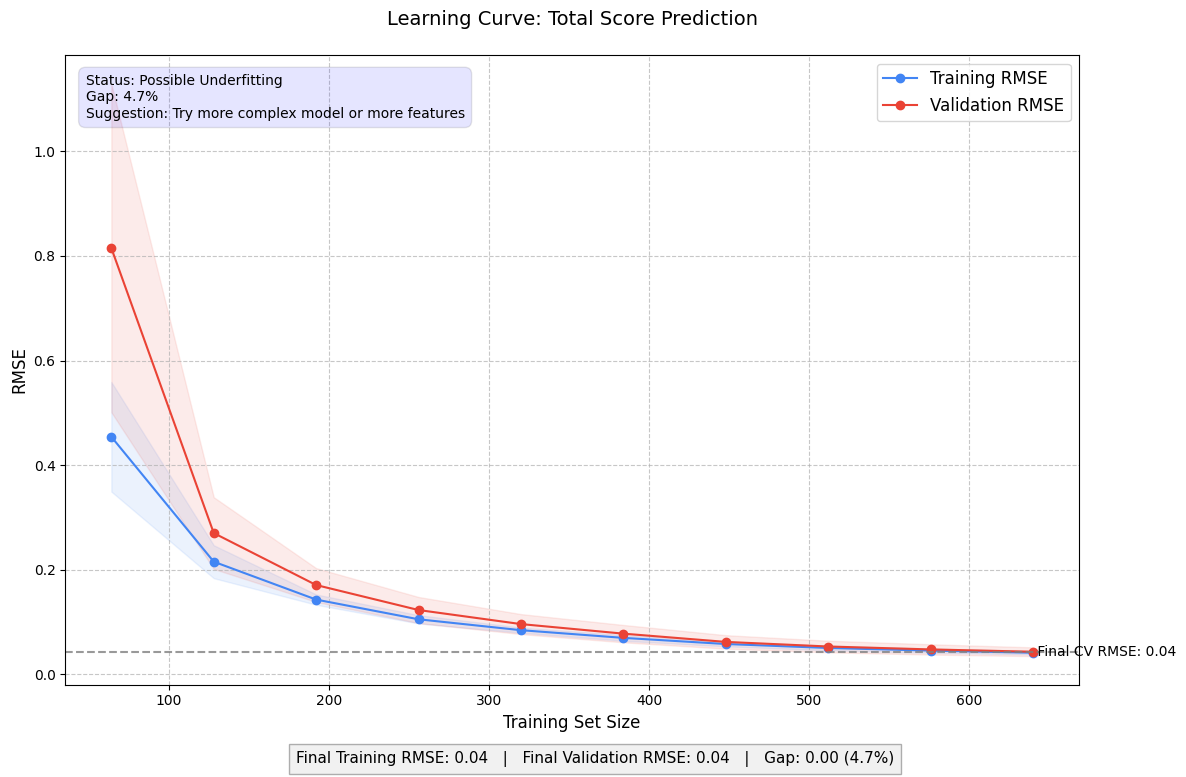

In [31]:
# Cell 15: Enhanced Learning Curve Analysis for Overfitting Diagnostic
from sklearn.model_selection import learning_curve, KFold, validation_curve
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_learning_curve(model, X, y, cv, title="Learning Curve", 
                        scoring='neg_mean_squared_error', 
                        train_sizes=np.linspace(0.1, 1.0, 10),
                        figsize=(12, 8)):
    """
    Plots an enhanced learning curve with standard deviation bands for better overfitting diagnosis.
    
    Args:
        model: Trained model to evaluate
        X: Feature matrix
        y: Target vector
        cv: Cross-validation strategy
        title: Plot title
        scoring: Metric to evaluate (default: neg_mean_squared_error)
        train_sizes: Array of training set sizes to evaluate
        figsize: Figure dimensions
    """
    plt.figure(figsize=figsize)
    
    # Calculate learning curves with cross-validation
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=cv, scoring=scoring, 
        train_sizes=train_sizes, n_jobs=-1
    )
    
    # Calculate mean and std for training scores
    train_scores_mean = np.mean(-train_scores, axis=1)
    train_scores_std = np.std(-train_scores, axis=1)
    
    # Calculate mean and std for test scores
    test_scores_mean = np.mean(-test_scores, axis=1)
    test_scores_std = np.std(-test_scores, axis=1)
    
    # Convert to RMSE if using MSE
    if scoring == 'neg_mean_squared_error':
        train_scores_mean = np.sqrt(train_scores_mean)
        train_scores_std = np.sqrt(train_scores_std) / 2  # Adjust std for better visualization
        test_scores_mean = np.sqrt(test_scores_mean)
        test_scores_std = np.sqrt(test_scores_std) / 2
        metric_label = "RMSE"
    else:
        metric_label = scoring.replace('neg_', '').replace('_', ' ').title()
    
    # Plot mean training and test scores
    plt.plot(train_sizes, train_scores_mean, 'o-', color='#4285F4', label=f'Training {metric_label}')
    plt.plot(train_sizes, test_scores_mean, 'o-', color='#EA4335', label=f'Validation {metric_label}')
    
    # Plot std deviation bands
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color='#4285F4')
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color='#EA4335')
    
    # Calculate overfitting ratio (validation error / training error)
    overfitting_ratio = test_scores_mean / train_scores_mean
    
    # Add annotations
    plt.axhline(y=test_scores_mean[-1], color='gray', linestyle='--', alpha=0.8)
    plt.text(train_sizes[-1], test_scores_mean[-1], f' Final CV {metric_label}: {test_scores_mean[-1]:.2f}', 
             verticalalignment='center')
    
    # Add overfitting assessment
    gap_pct = ((test_scores_mean[-1] - train_scores_mean[-1]) / train_scores_mean[-1]) * 100
    
    if gap_pct > 30:
        overfitting_status = "Severe Overfitting"
        suggestion = "Try stronger regularization, feature reduction, or simpler model"
        status_color = 'red'
    elif gap_pct > 15:
        overfitting_status = "Moderate Overfitting"
        suggestion = "Consider mild regularization or feature selection"
        status_color = 'orange'
    elif gap_pct < 5:
        overfitting_status = "Possible Underfitting"
        suggestion = "Try more complex model or more features"
        status_color = 'blue'
    else:
        overfitting_status = "Good Fit"
        suggestion = "Model complexity seems appropriate"
        status_color = 'green'
    
    plt.annotate(f"Status: {overfitting_status}\nGap: {gap_pct:.1f}%\nSuggestion: {suggestion}",
                xy=(0.02, 0.97), xycoords='axes fraction',
                bbox=dict(boxstyle="round,pad=0.5", fc=f"{status_color}", alpha=0.1),
                fontsize=10, ha='left', va='top')
    
    # Plot styling
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xlabel('Training Set Size', fontsize=12)
    plt.ylabel(metric_label, fontsize=12)
    plt.title(f'{title}\n', fontsize=14)
    plt.legend(loc='upper right', fontsize=12)
    
    # Add score metrics
    train_final = train_scores_mean[-1]
    test_final = test_scores_mean[-1]
    plt.figtext(0.5, 0.01, 
                f"Final Training {metric_label}: {train_final:.2f}   |   "
                f"Final Validation {metric_label}: {test_final:.2f}   |   "
                f"Gap: {test_final-train_final:.2f} ({gap_pct:.1f}%)",
                ha="center", fontsize=11, bbox={"facecolor":"lightgray", "alpha":0.3, "pad":5})
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.show()
    
    return {
        'training_final': train_final,
        'validation_final': test_final,
        'gap_percent': gap_pct,
        'status': overfitting_status,
        'suggestion': suggestion
    }

def plot_validation_curve(model, X, y, param_name, param_range, cv=5, 
                          scoring='neg_mean_squared_error', figsize=(12, 6)):
    """
    Plots a validation curve for a specific hyperparameter to find optimal values.
    
    Args:
        model: Model to evaluate
        X: Feature matrix
        y: Target vector
        param_name: Parameter name to vary
        param_range: List of parameter values to try
        cv: Cross-validation strategy
        scoring: Metric to evaluate (default: neg_mean_squared_error)
        figsize: Figure dimensions
    """
    plt.figure(figsize=figsize)
    
    train_scores, test_scores = validation_curve(
        model, X, y, param_name=param_name, param_range=param_range,
        cv=cv, scoring=scoring, n_jobs=-1
    )
    
    # Calculate means and standard deviations
    train_scores_mean = -np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = -np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    # Convert to RMSE if using MSE
    if scoring == 'neg_mean_squared_error':
        train_scores_mean = np.sqrt(train_scores_mean)
        train_scores_std = np.sqrt(train_scores_std) / 2
        test_scores_mean = np.sqrt(test_scores_mean)
        test_scores_std = np.sqrt(test_scores_std) / 2
        metric_label = "RMSE"
    else:
        metric_label = scoring.replace('neg_', '').replace('_', ' ').title()
    
    # Plot mean accuracy scores for training and testing
    plt.plot(param_range, train_scores_mean, 'o-', color='#4285F4', label=f'Training {metric_label}')
    plt.plot(param_range, test_scores_mean, 'o-', color='#EA4335', label=f'Validation {metric_label}')
    
    # Plot std deviation bands
    plt.fill_between(param_range, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color='#4285F4')
    plt.fill_between(param_range, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color='#EA4335')
    
    # Find optimal parameter value
    best_idx = np.argmin(test_scores_mean)
    best_param = param_range[best_idx]
    best_score = test_scores_mean[best_idx]
    
    # Add annotation for best value
    plt.axvline(x=best_param, color='green', linestyle='--', alpha=0.8)
    plt.text(best_param, plt.ylim()[0] * 1.1, f' Best {param_name}={best_param}\n {metric_label}={best_score:.2f}', 
             rotation=90, verticalalignment='bottom')
    
    # Plot styling
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xlabel(param_name, fontsize=12)
    plt.ylabel(metric_label, fontsize=12)
    plt.title(f'Validation Curve: {param_name}\n', fontsize=14)
    plt.legend(loc='best', fontsize=12)
    
    # If param_range spans several orders of magnitude, use log scale
    if max(param_range) / min(param_range) > 100:
        plt.xscale('log')
    
    plt.tight_layout()
    plt.show()
    
    return {
        'best_param': best_param,
        'best_score': best_score
    }

def evaluate_overfitting(model_dict, train_df, target='total_score', pregame_features=None):
    """
    Comprehensive model evaluation to detect and prevent overfitting.
    
    Args:
        model_dict: Dictionary of trained models
        train_df: Training dataframe
        target: Target metric to evaluate
        pregame_features: List of feature columns (if None, will be detected automatically)
    """
    try:
        # Get model from dictionary
        if target not in model_dict:
            print(f"Model for '{target}' not found in model dictionary. Available targets: {list(model_dict.keys())}")
            return
            
        if isinstance(model_dict[target], dict) and 'model' in model_dict[target]:
            model = model_dict[target]['model']
        else:
            model = model_dict[target]
        
        # Auto-detect features if not provided
        if pregame_features is None:
            print("Auto-detecting feature columns...")
            non_feature_cols = ['game_id', 'game_date', 'home_team', 'away_team', 
                               'home_score', 'away_score', 'point_diff', 'total_score',
                               'home_form', 'away_form', 'id']
            pregame_features = [col for col in train_df.select_dtypes(include=np.number).columns 
                               if col not in non_feature_cols]
            print(f"Detected {len(pregame_features)} feature columns")
        
        # Prepare data
        X_train_lc = train_df[pregame_features]
        y_train_lc = train_df[target]
        
        # Set up cross-validation
        cv = KFold(n_splits=5, shuffle=True, random_state=42)
        
        print(f"Running learning curve analysis for '{target}' prediction...")
        results = plot_learning_curve(model, X_train_lc, y_train_lc, cv=cv, 
                               title=f"Learning Curve: {target.replace('_', ' ').title()} Prediction")
        
        # For GradientBoosting models, analyze key hyperparameters
        if hasattr(model, 'estimators_') and hasattr(model, 'learning_rate'):
            print("\nAnalyzing optimal model complexity...")
            
            # Test different max_depth values
            plot_validation_curve(
                model.__class__(), X_train_lc, y_train_lc,
                param_name="max_depth",
                param_range=np.array([2, 3, 4, 5, 6, 7]),
                cv=cv
            )
            
            # Test different n_estimators values
            plot_validation_curve(
                model.__class__(), X_train_lc, y_train_lc,
                param_name="n_estimators",
                param_range=np.array([50, 100, 150, 200, 250, 300]),
                cv=cv
            )
            
            # Test different learning_rate values
            plot_validation_curve(
                model.__class__(), X_train_lc, y_train_lc,
                param_name="learning_rate",
                param_range=np.array([0.01, 0.05, 0.1, 0.2, 0.3]),
                cv=cv
            )
        
        return results
        
    except Exception as e:
        import traceback
        print(f"Error during overfitting analysis: {str(e)}")
        traceback.print_exc()
        return None

# Example usage (uncomment to run):
# Try to run only if models and train_df variables exist
if 'models' in globals() and 'train_df' in globals():
    print("Evaluating model for overfitting...")
    evaluate_overfitting(models, train_df, target='total_score')
else:
    print("Skipping overfitting analysis - required variables not found in notebook context")
    print("To run analysis, ensure 'models' dictionary and 'train_df' dataframe are available")

In [32]:
# CELL 15A: Scaled Predictions + Feature Checking

import os
import sys
import joblib
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# --- PART 0: Ensure 'backend' module is in the path ---
# Adjust if your repo structure is different
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(repo_root)

# --- PART 1: Load the Target Scaler (consistent with Cell 11E) ---
scaler_path = os.path.join(repo_root, 'models', 'target_scaler.pkl')
if os.path.exists(scaler_path):
    try:
        target_scaler = joblib.load(scaler_path)
        scaled_prediction = 0.7
        original_prediction = target_scaler.inverse_transform([[scaled_prediction]])[0][0]
        print(f"Scaled prediction: {scaled_prediction} converts to original score: {original_prediction:.2f}")
    except Exception as e:
        print("Error loading scaler:", e)
else:
    print(f"Scaler file not found at: {scaler_path}")

# --- PART 2: Import your custom Feature Generator ---
# The new class name is NBAFeatureEngine (not NBAFeatureGenerator)
try:
    from backend.models.features import NBAFeatureEngine
except ImportError as imp_err:
    print("Could not import NBAFeatureEngine. Check that 'backend' is a valid module and that the path is correct.")
    raise imp_err

# --- PART 3: Feature Consistency Check ---
# Create a dummy test sample. Adjust or add fields as required by your feature generator.
test_data = pd.DataFrame({
    'home_team': ['Lakers'],
    'away_team': ['Warriors'],
    'game_date': [pd.Timestamp('2025-03-23')],
    'home_score': [0],   # Dummy score
    'away_score': [0],
    'current_quarter': [1]
    # Add any additional columns needed by your feature engineering process.
})

# Initialize the feature engine
feature_gen = NBAFeatureEngine(debug=True)

# Generate features from the test sample
features_df = feature_gen.generate_all_features(test_data)

# Get the expected feature set for quarter 1 using the new method
expected_features = feature_gen.get_features_for_quarter(features_df, quarter=1).columns.tolist()

print("Expected features for Q1:", expected_features)
print("All generated features columns:", features_df.columns.tolist())

# Optional: Check for missing features
missing_features = set(expected_features) - set(features_df.columns.tolist())
if missing_features:
    print("WARNING: The following expected features are missing:", missing_features)
else:
    print("All expected features are present.")


Scaled prediction: 0.7 converts to original score: 259.00
[FeatureEngine] Generating all features (skip_rest_calc=False)...
[FeatureEngine] Adding time features...
[FeatureEngine] Adding team history features...
[FeatureEngine] Adding rest features...
[FeatureEngine] Adding score features...
[FeatureEngine] Adding momentum features...
[FeatureEngine] Adding interaction features...
[FeatureEngine] Generated 50 new features
Expected features for Q1: ['rolling_home_score', 'rolling_away_score', 'prev_matchup_diff', 'rest_days_home', 'rest_days_away', 'rest_advantage', 'is_back_to_back_home', 'is_back_to_back_away', 'score_time_impact']
All generated features columns: ['home_team', 'away_team', 'game_date', 'home_score', 'away_score', 'current_quarter', 'time_remaining_mins', 'time_remaining_norm', 'time_exp', 'time_pressure', 'is_q1', 'is_q2', 'is_q3', 'is_q4', 'is_first_half', 'is_second_half', 'is_clutch_time', 'rolling_home_score', 'rolling_away_score', 'prev_matchup_diff', 'rest_days_

Evaluating trained models with real data...
Loaded model for home_score
Loaded model for away_score
Loaded model for point_diff
Loaded model for total_score
Loading historical games from the past 180 days...
Loading historical game data since 2024-09-25 from Supabase...
Loaded 1000 historical games from 2024-10-04 00:00:00 to 2025-03-14 00:00:00
Received 1000 games; sampling down to 100 for faster processing...
Fetched 100 historical games
Calculating team metrics...
Calculated metrics for 31 teams
Team metrics lookup keys: ['sacramento kings', 'Sacramento Kings', 'utah jazz', 'Utah Jazz', 'portland trail blazers', 'Portland Trail Blazers', 'charlotte hornets', 'Charlotte Hornets', 'boston celtics', 'Boston Celtics', 'miami heat', 'Miami Heat', 'new york knicks', 'New York Knicks', 'new orleans pelicans', 'New Orleans Pelicans', 'los angeles lakers', 'Los Angeles Lakers', 'minnesota timberwolves', 'Minnesota Timberwolves', 'brooklyn nets', 'Brooklyn Nets', 'chicago bulls', 'Chicago Bul

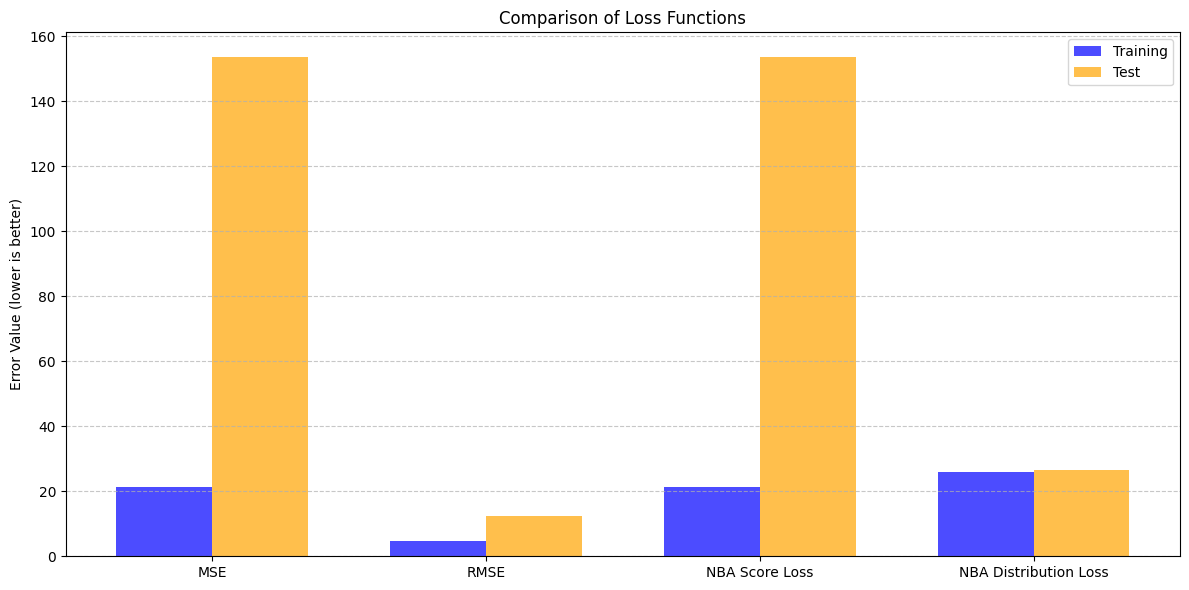

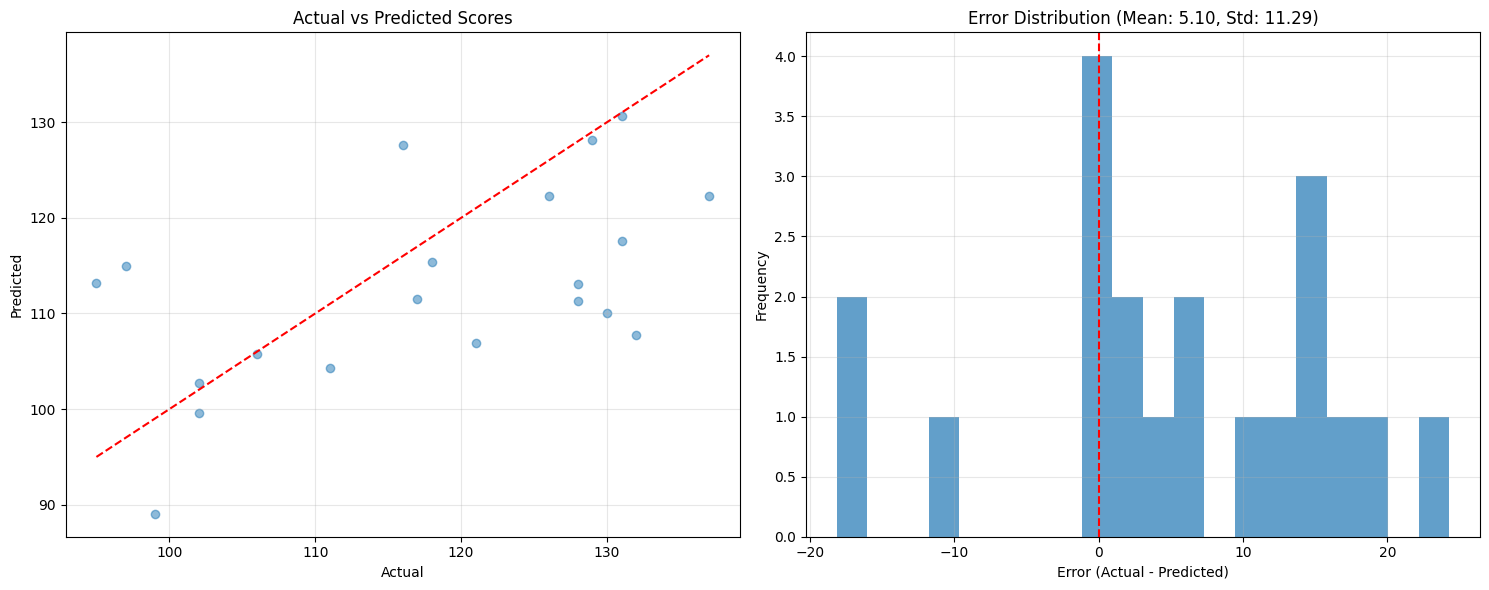

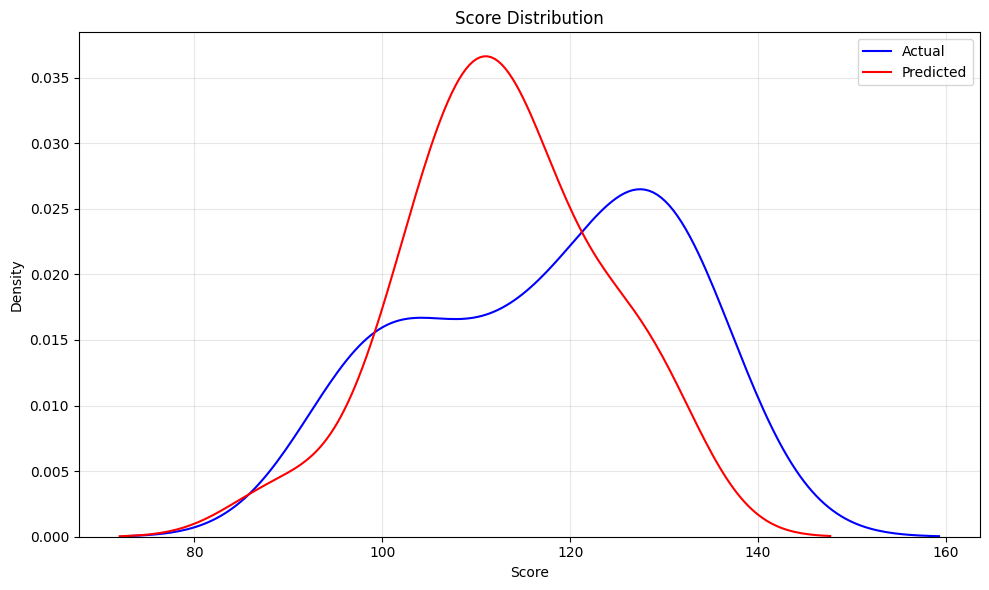


Evaluating away_score model

=== EVALUATING MODEL FOR AWAY_SCORE ===
Model requires 104 features; 11 available.
Found 11 overlapping features (10.6% overlap)
⚠️ Overlap below threshold (90%). Retraining simplified model...

Top 10 features in simplified model:
away_offensive_rating: 0.3986
home_defensive_rating: 0.2311
home_rest_days: 0.1187
home_offensive_rating: 0.0925
net_rating_diff: 0.0540
home_win_pct: 0.0507
away_rest_days: 0.0211
away_win_pct: 0.0161
away_net_rating: 0.0104
home_net_rating: 0.0045

Simplified (retrained) Model Metrics:
Training RMSE: 4.88
Test RMSE: 11.94
Training MAE: 3.62
Test MAE: 10.00
R² Score: 0.0672


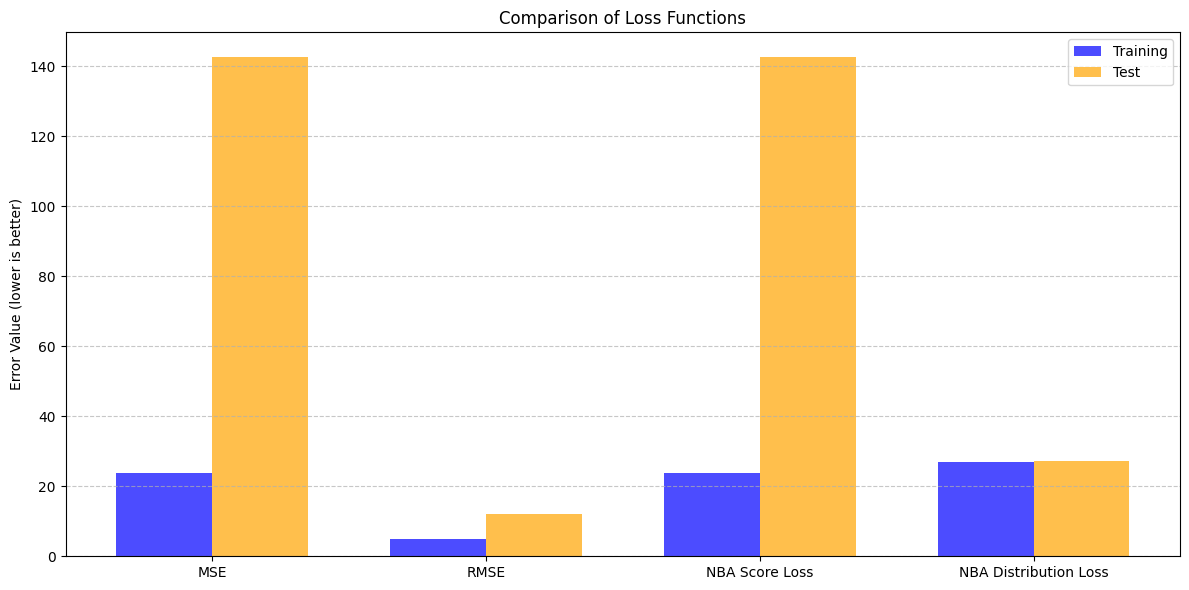

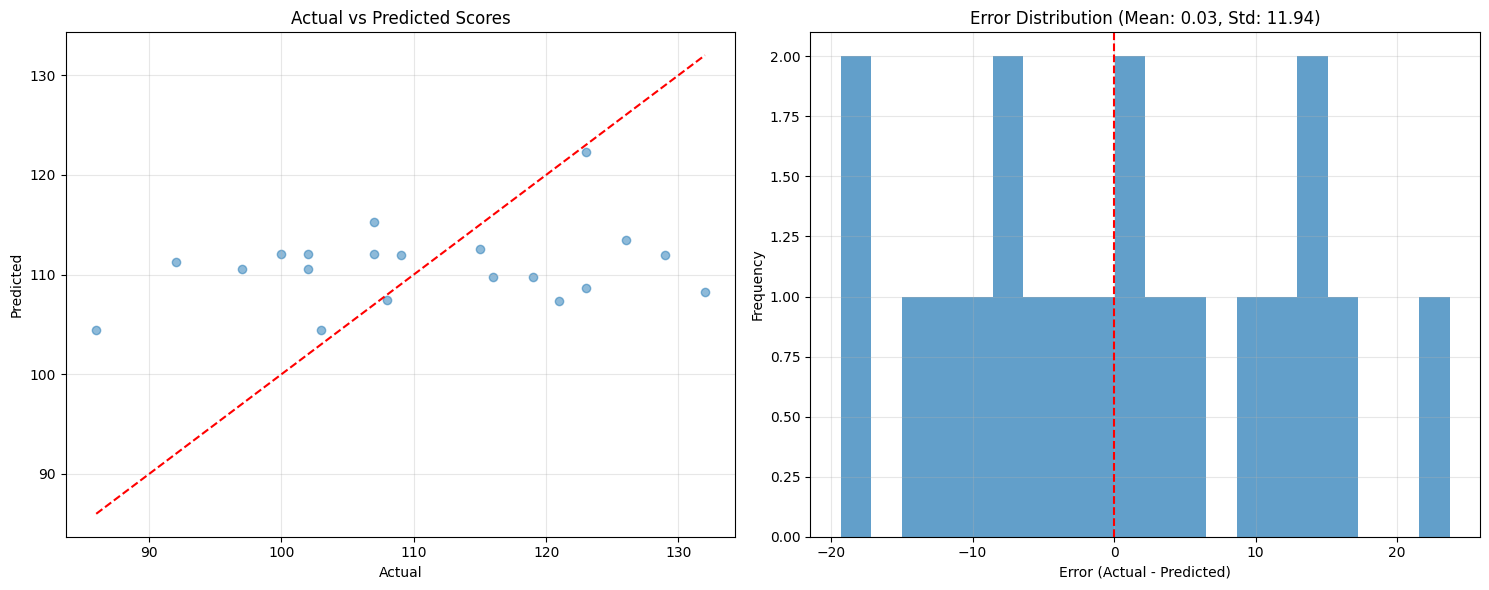

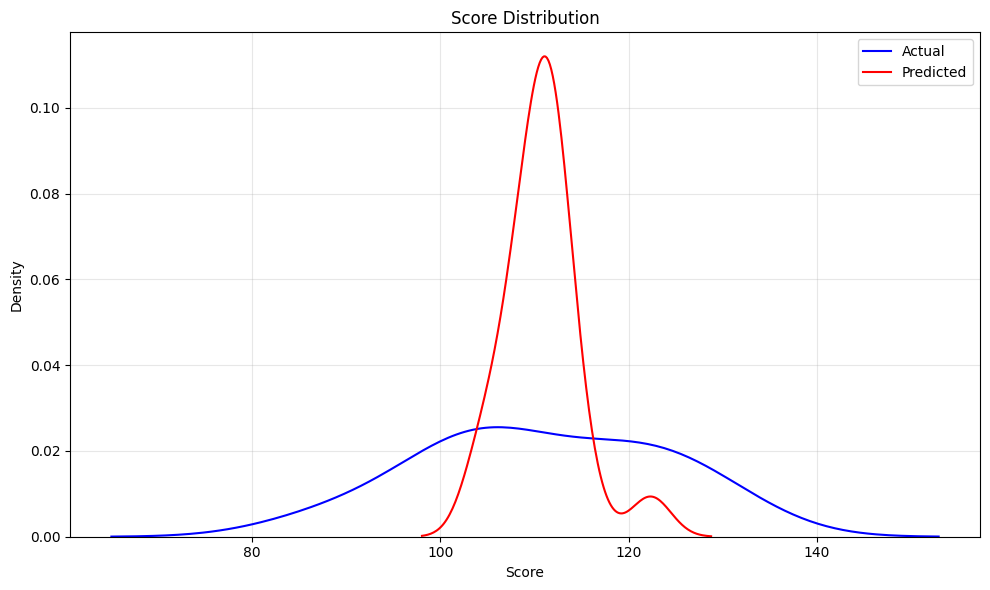


Evaluating point_diff model

=== EVALUATING MODEL FOR POINT_DIFF ===
Model requires 104 features; 11 available.
Found 11 overlapping features (10.6% overlap)
⚠️ Overlap below threshold (90%). Retraining simplified model...

Top 10 features in simplified model:
net_rating_diff: 0.3785
away_rest_days: 0.1066
home_net_rating: 0.1047
home_rest_days: 0.0991
away_defensive_rating: 0.0694
away_net_rating: 0.0689
away_win_pct: 0.0475
home_win_pct: 0.0446
away_offensive_rating: 0.0323
home_offensive_rating: 0.0302

Simplified (retrained) Model Metrics:
Training RMSE: 6.13
Test RMSE: 14.30
Training MAE: 4.52
Test MAE: 12.08
R² Score: -0.0468


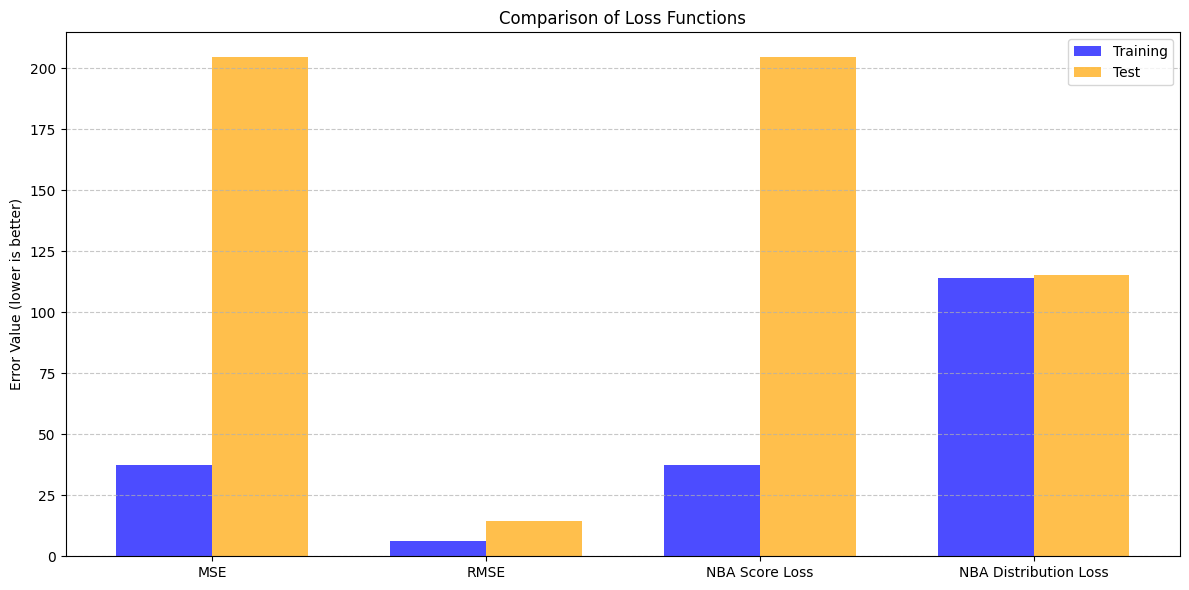

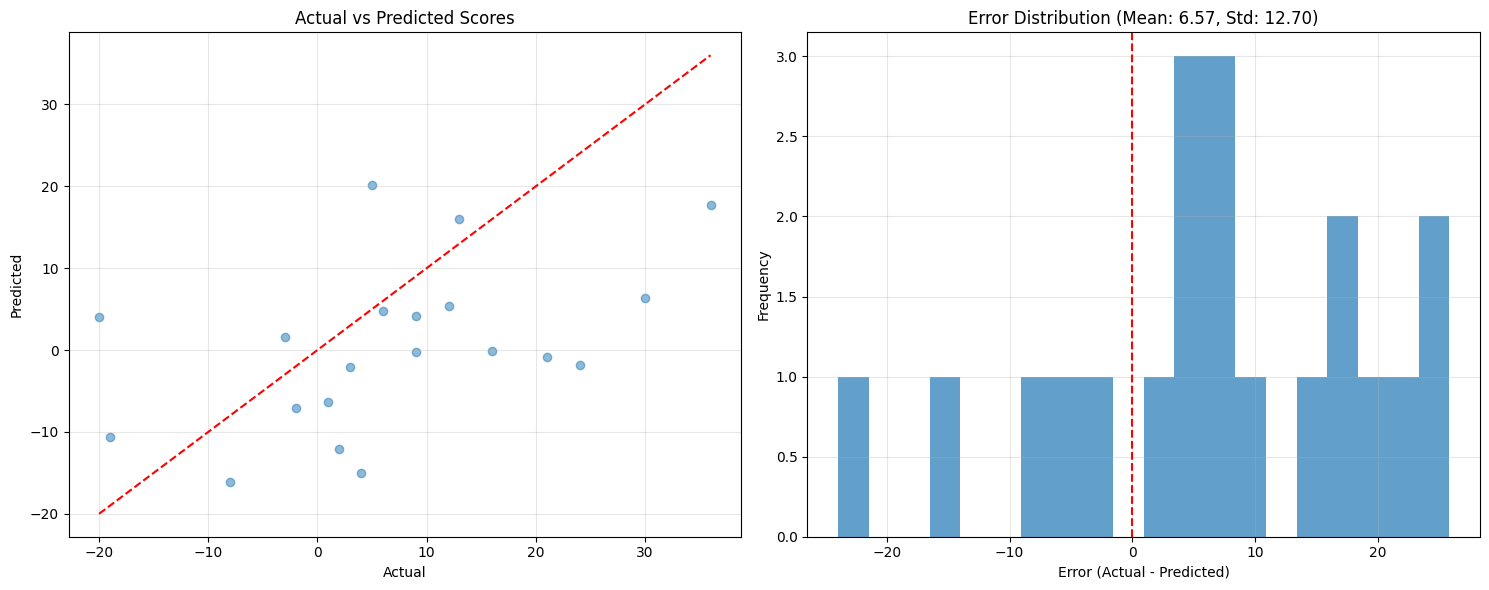

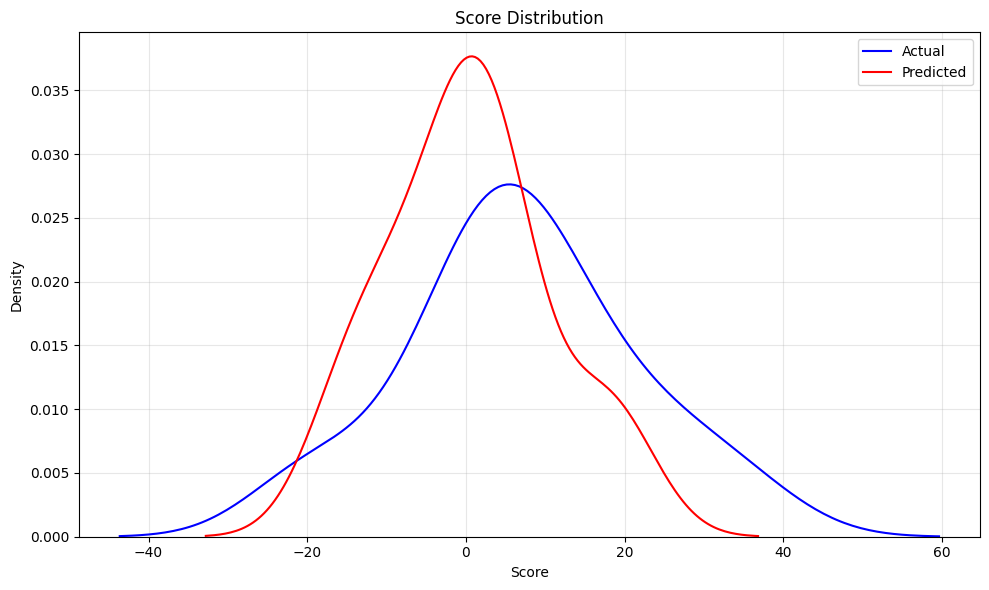


Evaluating total_score model

=== EVALUATING MODEL FOR TOTAL_SCORE ===
Model requires 104 features; 11 available.
Found 11 overlapping features (10.6% overlap)
⚠️ Overlap below threshold (90%). Retraining simplified model...

Top 10 features in simplified model:
home_offensive_rating: 0.2659
away_offensive_rating: 0.1850
home_defensive_rating: 0.1361
away_defensive_rating: 0.0921
home_rest_days: 0.0907
net_rating_diff: 0.0706
away_net_rating: 0.0504
away_rest_days: 0.0453
home_net_rating: 0.0313
home_win_pct: 0.0180

Simplified (retrained) Model Metrics:
Training RMSE: 6.46
Test RMSE: 19.46
Training MAE: 5.14
Test MAE: 16.13
R² Score: 0.1728


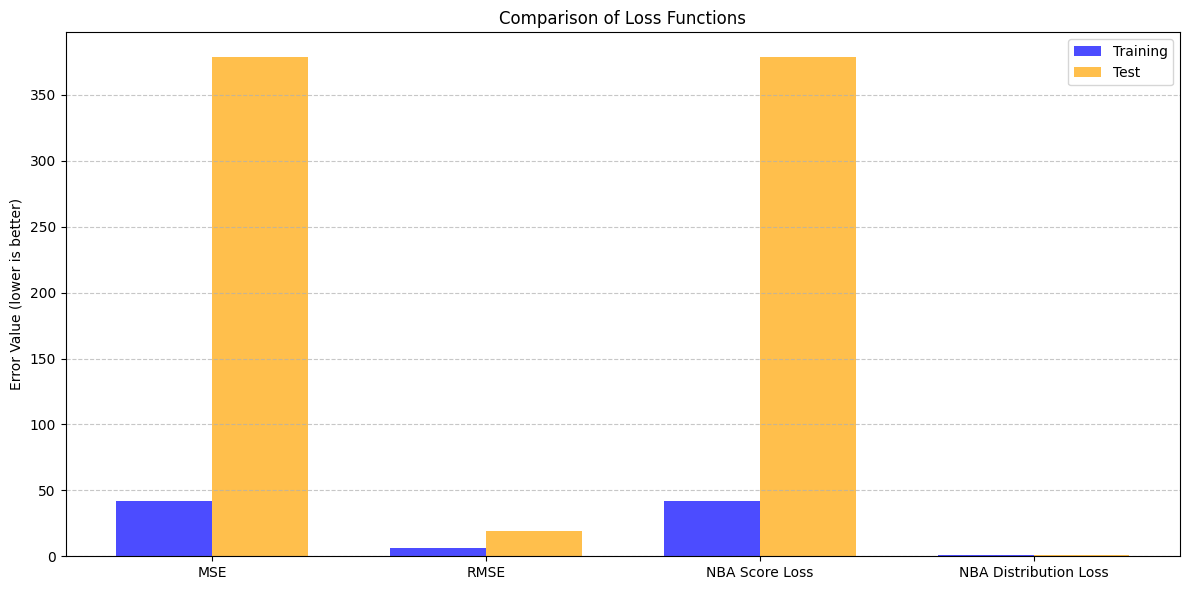

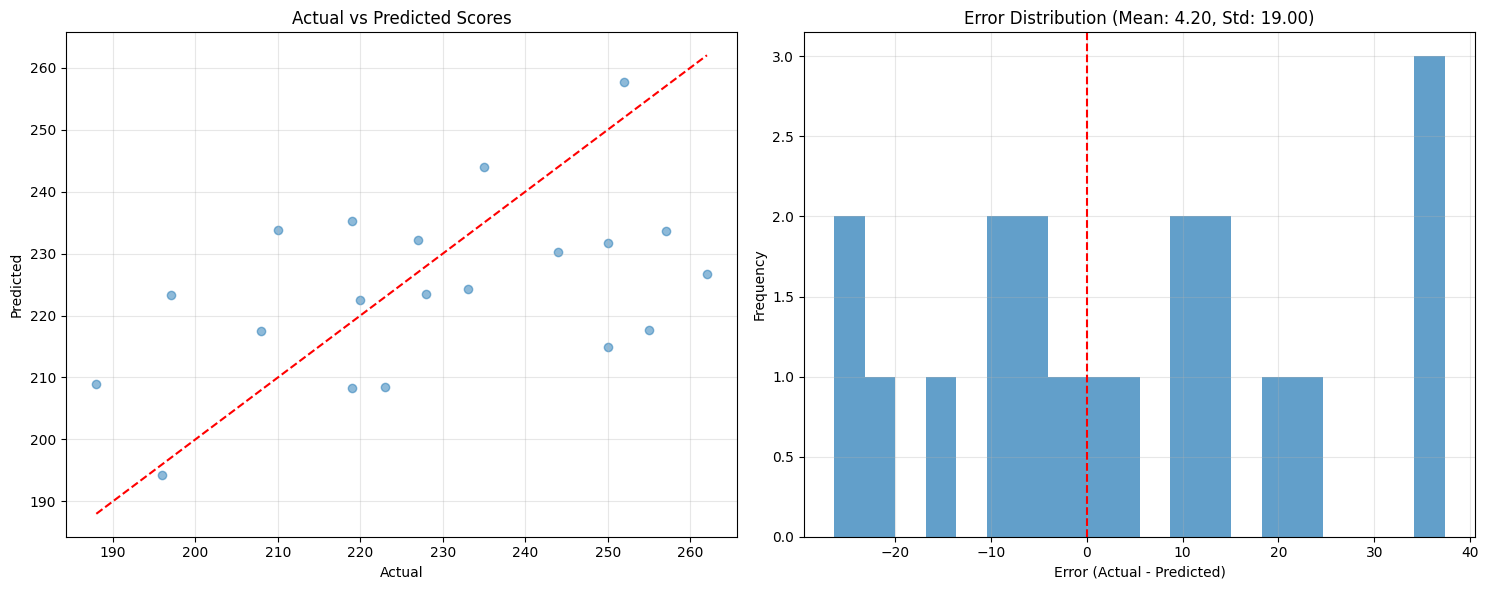

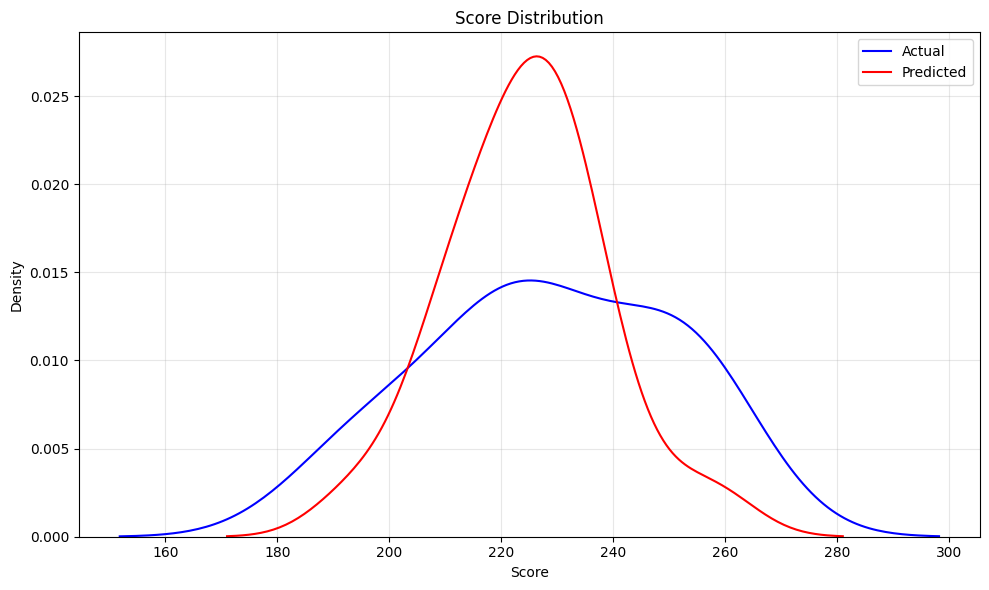

{'home_score': {'train_mse': 21.176871475943074,
  'test_mse': 153.5873524099221,
  'train_rmse': 4.6018334906798914,
  'test_rmse': 12.393036448341547,
  'train_mae': 3.6755215341298255,
  'test_mae': 9.938569095207132,
  'r2': 0.11558590112909084,
  'train_nba_loss': 21.176871475943074,
  'test_nba_loss': 153.5873524099221,
  'train_dist_loss': 25.969375756682506,
  'test_dist_loss': 26.417588385177716},
 'away_score': {'train_mse': 23.823846944583863,
  'test_mse': 142.55370098253167,
  'train_rmse': 4.880967828677409,
  'test_rmse': 11.939585461084135,
  'train_mae': 3.6214355731834216,
  'test_mae': 9.999623736507461,
  'r2': 0.06722480585934032,
  'train_nba_loss': 23.823846944583863,
  'test_nba_loss': 142.55370098253167,
  'train_dist_loss': 26.87885374858888,
  'test_dist_loss': 27.1688704177511},
 'point_diff': {'train_mse': 37.606489979251236,
  'test_mse': 204.49047038251254,
  'train_rmse': 6.132413063325989,
  'test_rmse': 14.30001644693154,
  'train_mae': 4.5209144310301

In [33]:
# Cell 15B -- Run Model Evaluations

# Run evaluations
run_model_evaluations()

Successfully imported NBAFeatureEngine

                    NBA PREGAME PREDICTION WITH BETTING ODDS INTEGRATION (Cell 16)

Loaded home_score model from /Users/mattb/Desktop/Projects/score-genius/notebooks/models/pregame_home_score_model.pkl
Loaded away_score model from /Users/mattb/Desktop/Projects/score-genius/notebooks/models/pregame_away_score_model.pkl
Loaded point_diff model from /Users/mattb/Desktop/Projects/score-genius/notebooks/models/pregame_point_diff_model.pkl
Loaded total_score model from /Users/mattb/Desktop/Projects/score-genius/notebooks/models/pregame_total_score_model.pkl
Loading historical game data since 2024-09-25 from Supabase...
Loaded 1000 historical games from 2024-10-04 00:00:00 to 2025-03-14 00:00:00
Loaded historical data with shape: (1000, 46)
Calculating team metrics...
Calculated metrics for 35 teams
Patching team metrics to add form_win_pct, current_streak, and momentum_score...
Calculated team metrics for 35 teams.
Teams in metrics: ['Atlanta Hawks', '

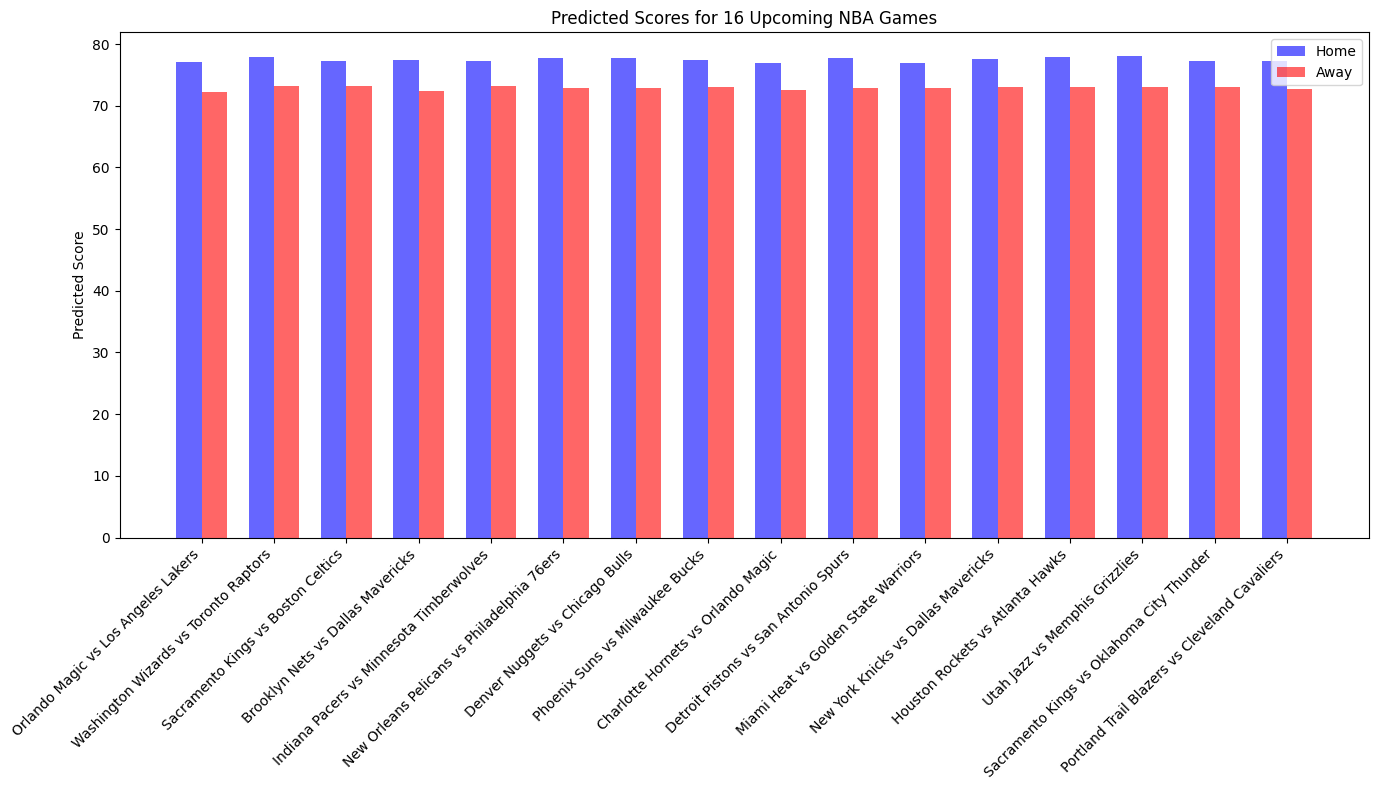

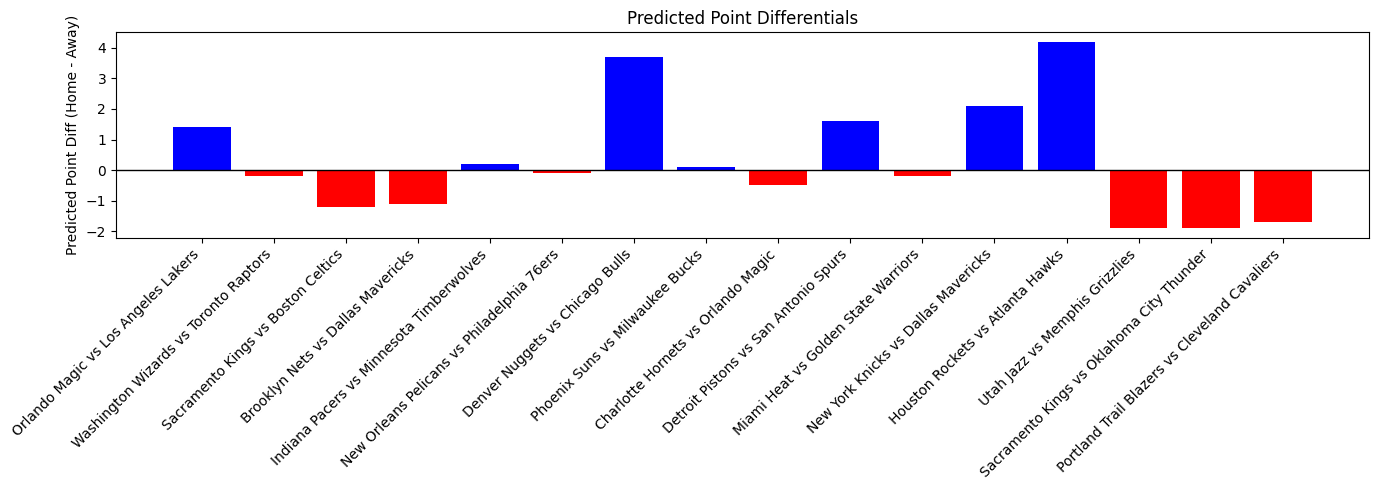


=== Visualizing Feature Importance ===


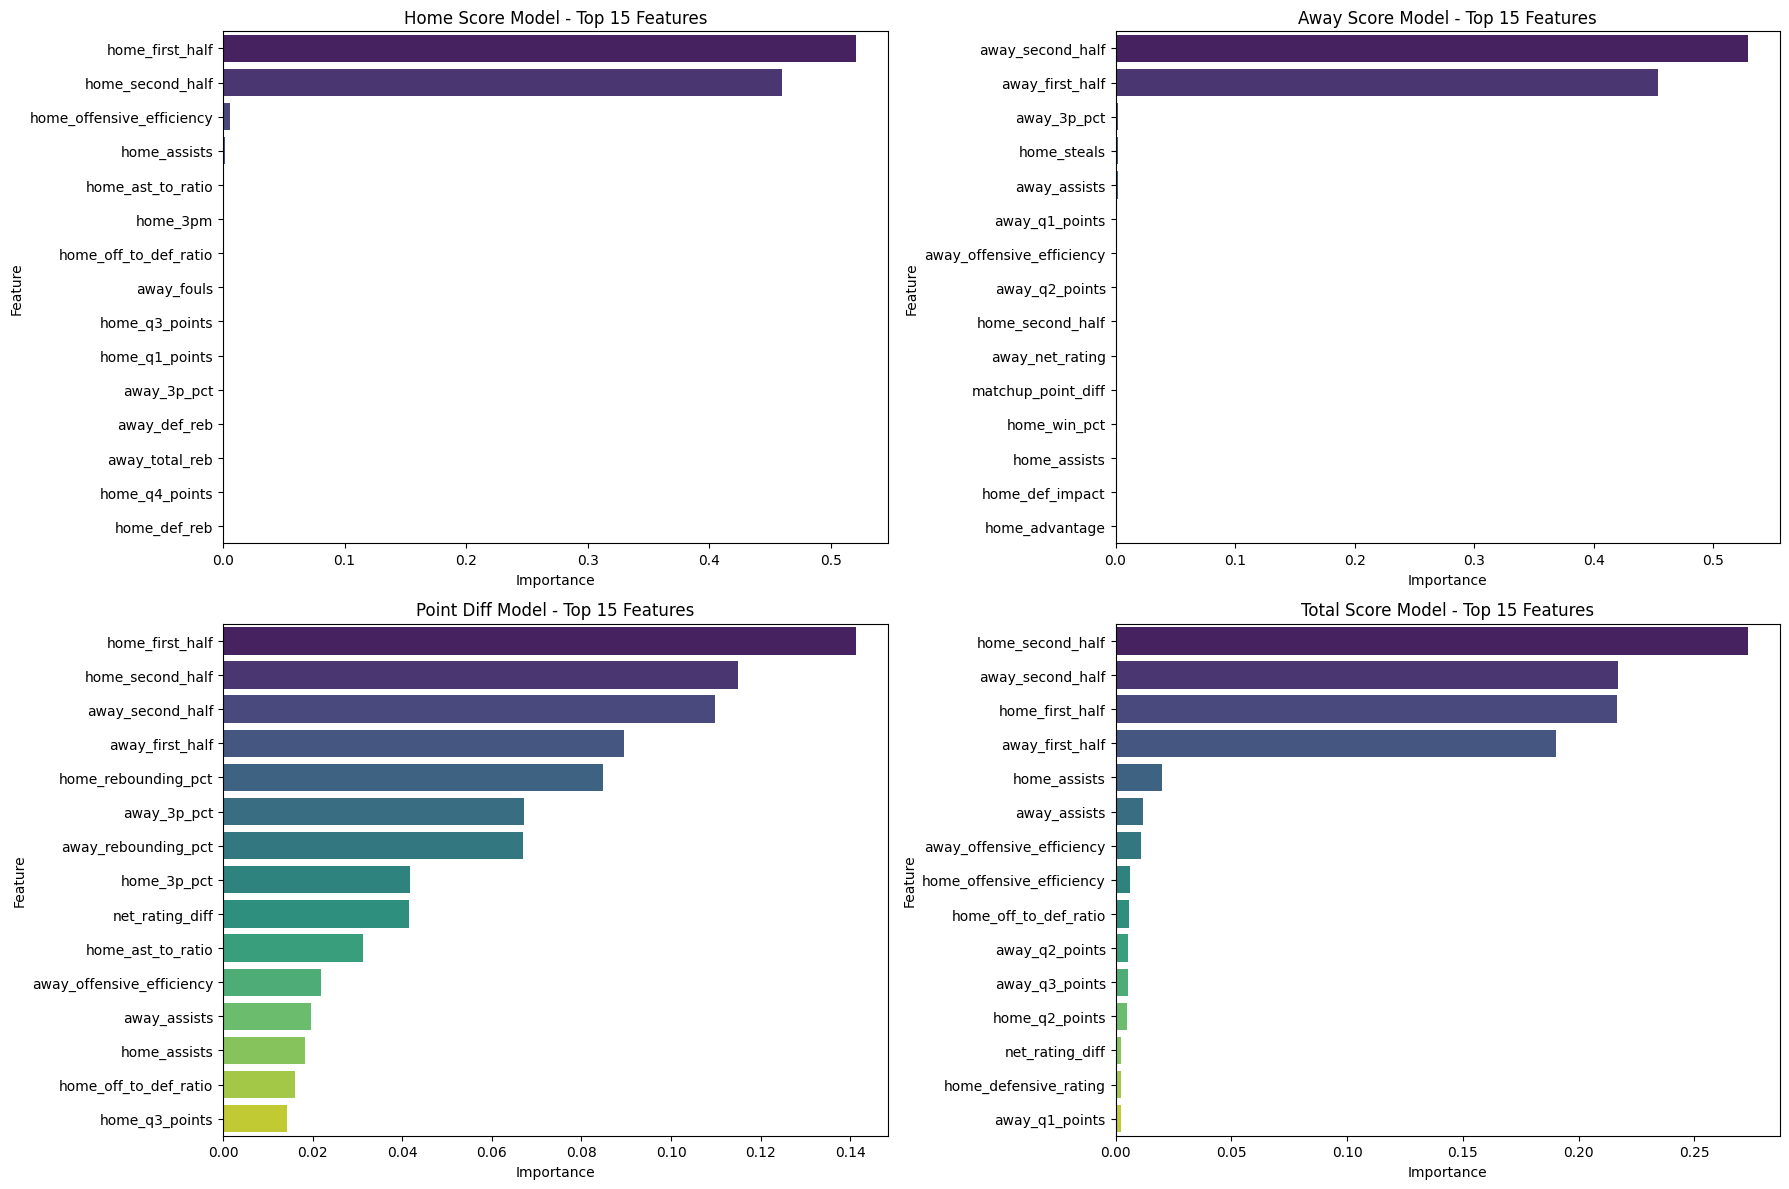


=== Visualizing Prediction Performance ===


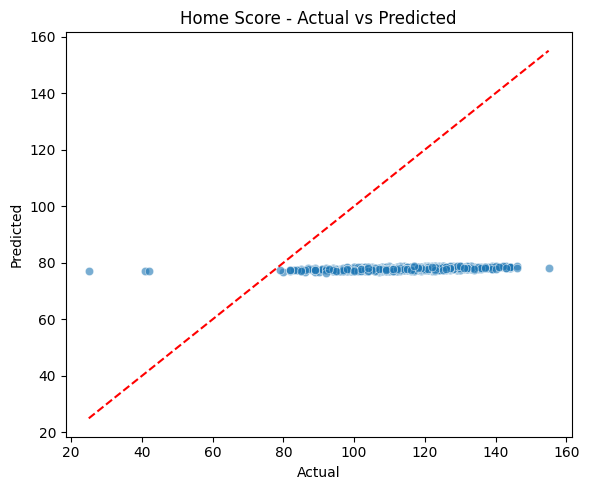

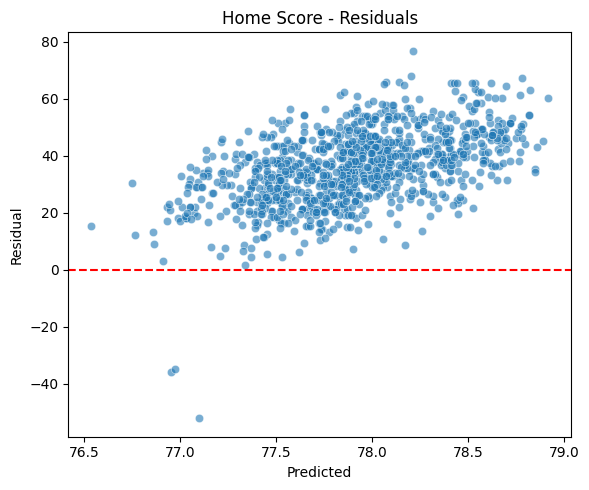

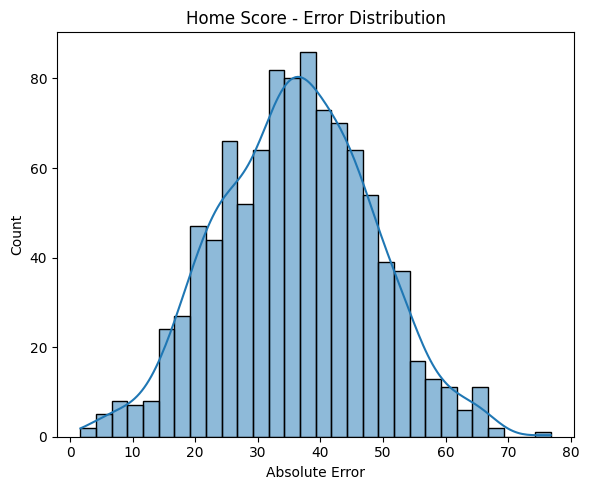

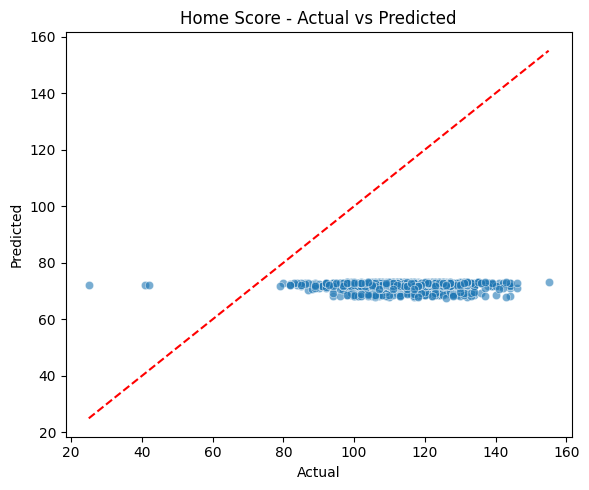

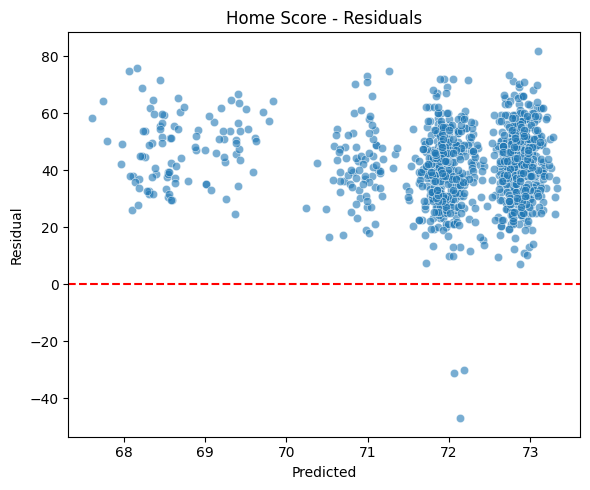

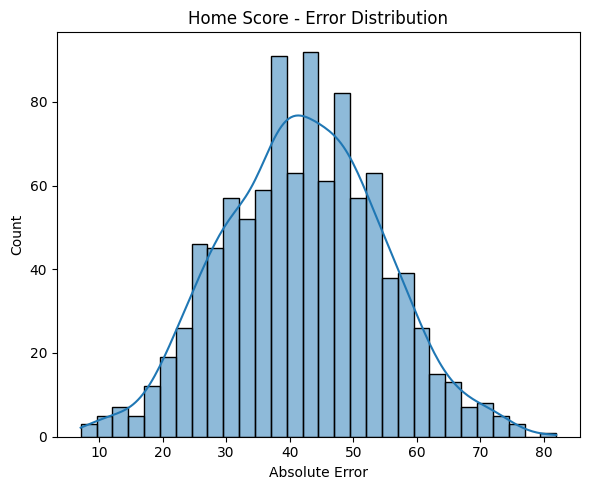

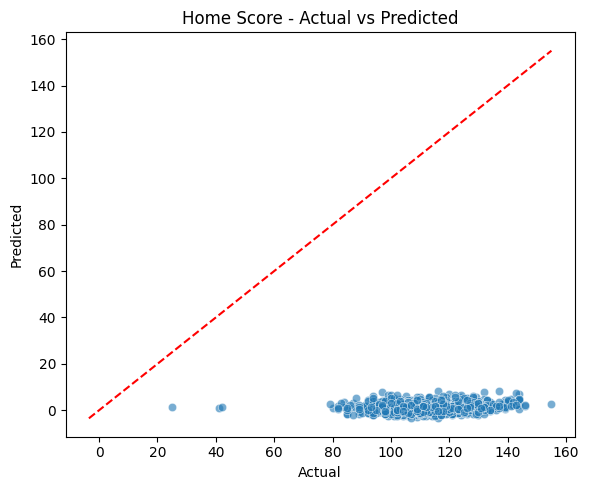

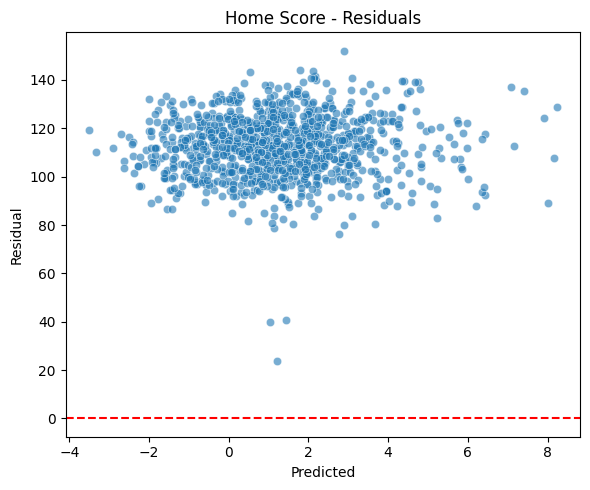

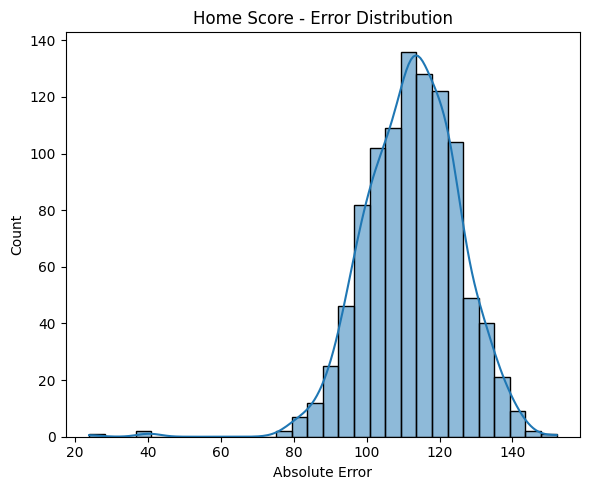

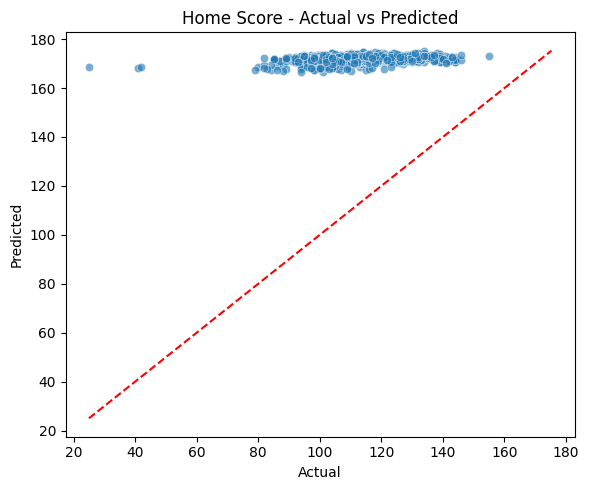

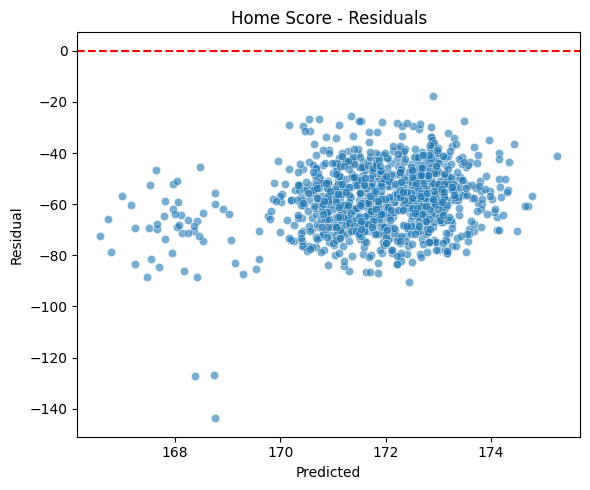

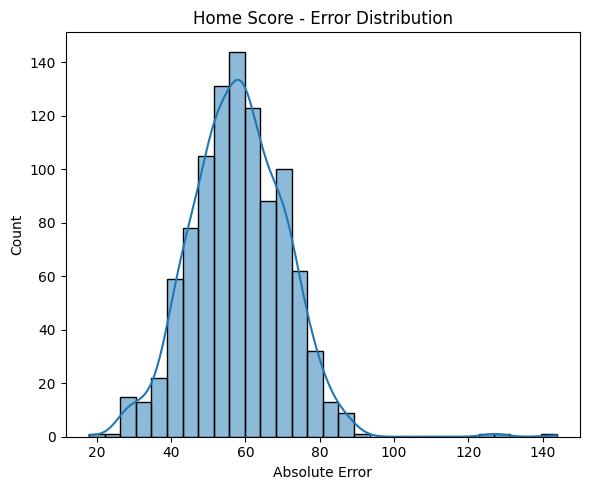

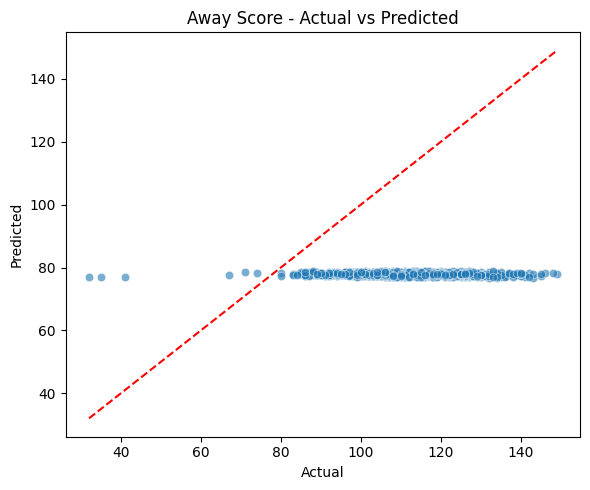

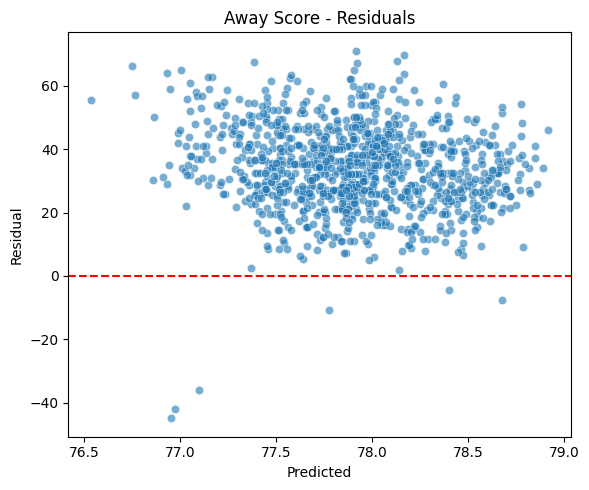

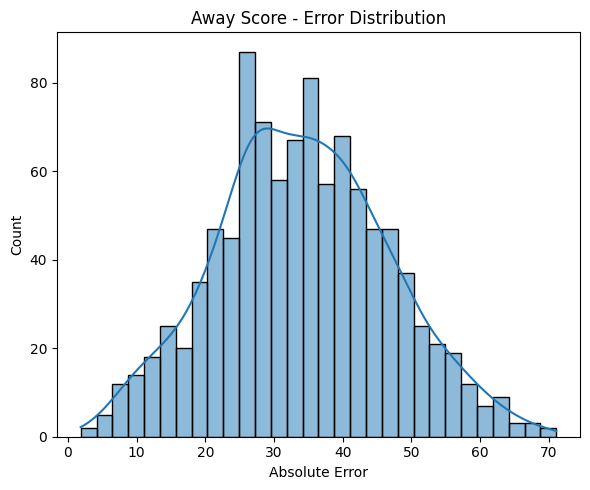

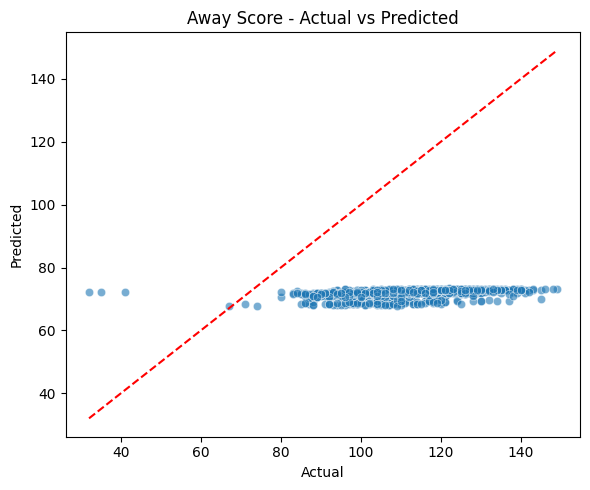

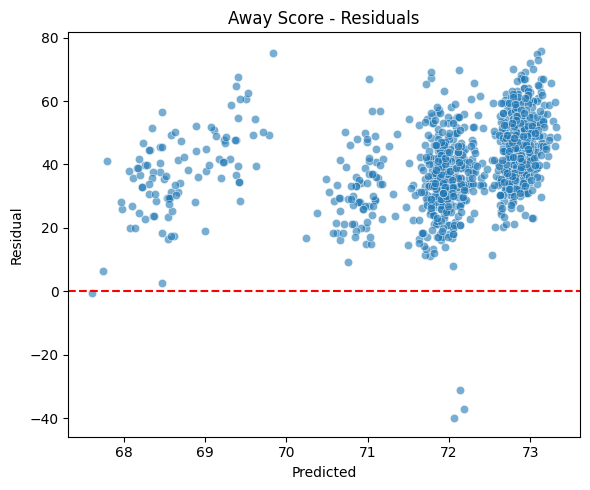

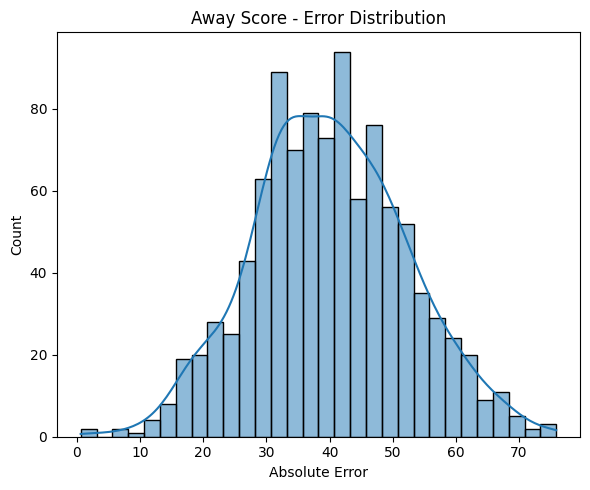

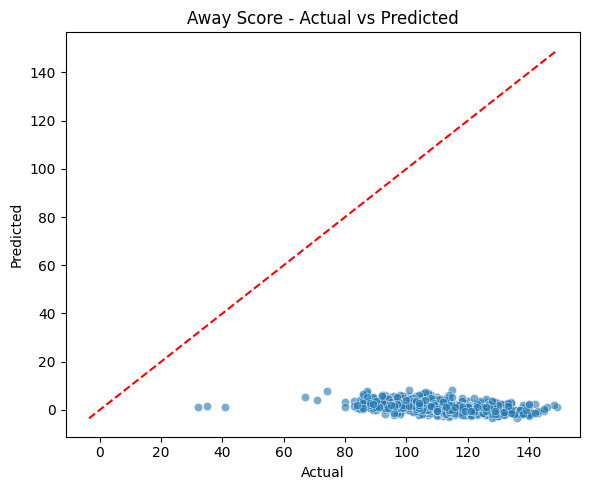

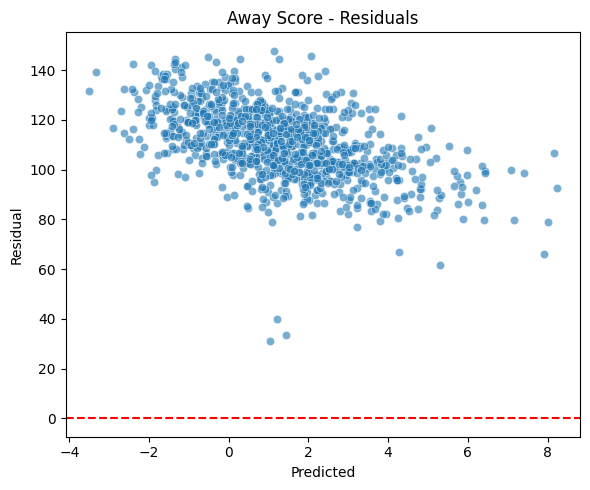

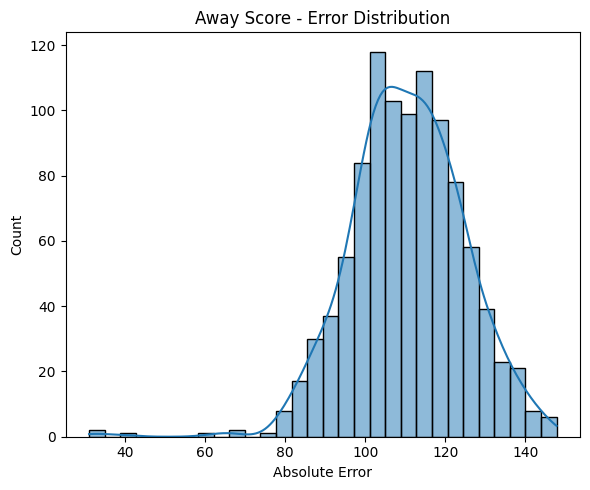

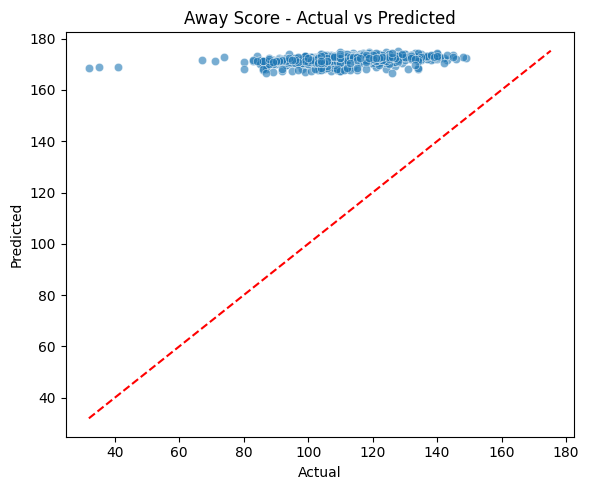

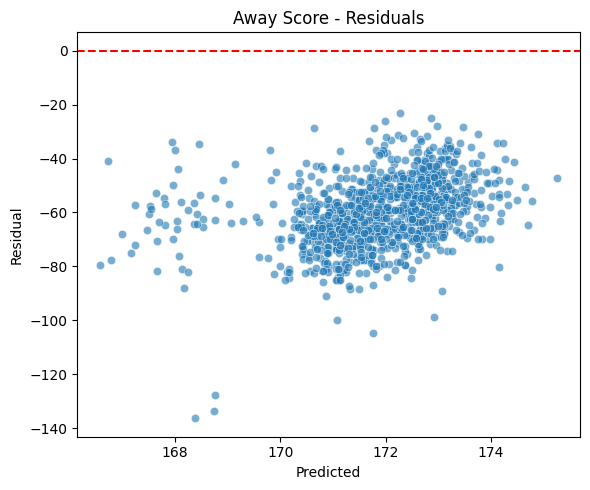

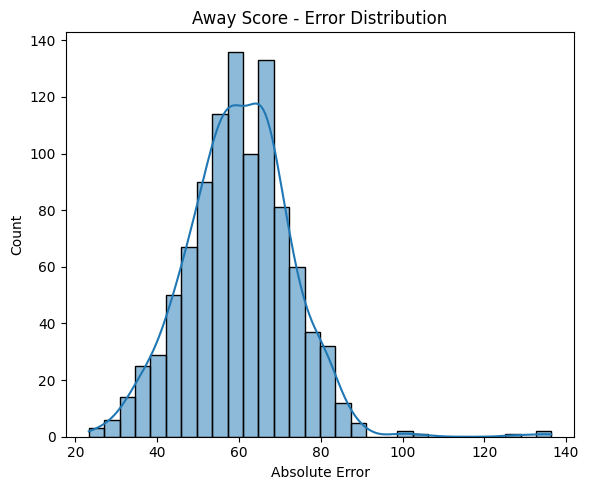


Prediction pipeline with betting odds integration completed!


In [43]:
# --------------------- CELL 16: Integrated Prediction Pipeline with Visualizations ---------------------
import os
import re
import math
import pytz
import joblib
import traceback
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from pathlib import Path
from sqlalchemy import create_engine
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Global configuration & paths
MODELS_DIR = Path(os.getcwd()) / "models"
MODELS_DIR.mkdir(exist_ok=True)
PREGAME_MODEL_PATH = MODELS_DIR / "pregame_model.pkl"

# Add backend/models to sys.path so that NBAFeatureEngine can be imported
import sys
project_root = Path().resolve().parent  # parent directory of current directory
models_path = project_root / 'backend' / 'models'
sys.path.append(str(models_path))

# Import NBAFeatureEngine from features.py (assume calculate_team_metrics and build_full_feature_set are defined in Cell 6B)
try:
    from features import NBAFeatureEngine
    feature_engine = NBAFeatureEngine(debug=True)
    print("Successfully imported NBAFeatureEngine")
except ImportError as e:
    print(f"Could not import NBAFeatureEngine: {e}. Using local functions instead.")
    feature_engine = None

# Create SQLAlchemy engine if not defined (assumes DATABASE_URL loaded in Cell 1)
if 'engine' not in globals():
    DATABASE_URL = os.getenv("DATABASE_URL")
    if DATABASE_URL:
        try:
            engine = create_engine(DATABASE_URL)
            print("Engine created successfully in Cell 16.")
        except Exception as e:
            print(f"Error creating engine: {e}")
            engine = None
    else:
        print("DATABASE_URL not found in environment variables.")
        engine = None

# --------------------- Local Helper Functions ---------------------
def fetch_upcoming_games_16(days_window=2):
    """Fetches upcoming games from Supabase (or returns sample data)."""
    pacific_tz = pytz.timezone("America/Los_Angeles")
    now_pt = datetime.now(pacific_tz)
    start_date = (now_pt - timedelta(days=1)).date()
    end_date = (now_pt + timedelta(days=days_window)).date()
    cutoff_hour = 21
    start_ts = pacific_tz.localize(datetime.combine(start_date, datetime.min.time().replace(hour=cutoff_hour))).astimezone(pytz.UTC).isoformat()
    end_ts = pacific_tz.localize(datetime.combine(end_date, datetime.min.time().replace(hour=cutoff_hour))).astimezone(pytz.UTC).isoformat()
    print(f"Fetching upcoming games from {start_date} to {end_date} (9pm PT window)...")
    try:
        response = supabase.table("nba_game_schedule")\
        .select("*")\
        .gte("scheduled_time", datetime.now().strftime('%Y-%m-%d'))\
        .execute()
        data = response.data
        if not data:
            print("No upcoming games found.")
            return pd.DataFrame()
        games_df = pd.DataFrame(data)
        if "scheduled_time" in games_df.columns:
            games_df["scheduled_time"] = pd.to_datetime(games_df["scheduled_time"])
            games_df["game_time_pt"] = games_df["scheduled_time"].dt.tz_convert(pacific_tz)
            games_df["game_date"] = games_df["game_time_pt"].dt.date
        for col in ["home_team", "away_team"]:
            games_df[col] = games_df[col].astype(str)
        print(f"Found {len(games_df)} upcoming games.")
        return games_df
    except Exception as e:
        print(f"Error fetching upcoming games: {e}")
        traceback.print_exc()
        return pd.DataFrame()
    
def parse_moneyline_16(moneyline_str):
    """
    Parse a 'moneyline_clean' string into a dict with home/away moneyline odds.
    Example format: "HOME +120 / AWAY -140"
    """
    if not moneyline_str or moneyline_str == 'EMPTY':
        return {'home': -110, 'away': -110}
    pattern = r'([^\/]+)([\+\-]\d+)[^\/]+\/[^\/]+([\+\-]\d+)'
    match = re.search(pattern, moneyline_str)
    if match:
        # The home line is in group(3), away line in group(2)
        home_line = int(match.group(3))
        away_line = int(match.group(2))
        return {'home': home_line, 'away': away_line}
    return {'home': -110, 'away': -110}

def parse_spread_16(spread_str):
    """
    Parse a 'spread_clean' string into a dict with home/away spreads and odds.
    Example format: "HOME -5.5 (-110) / AWAY +5.5 (-110)"
    """
    if not spread_str or spread_str == 'EMPTY':
        return {'home': 0, 'away': 0, 'home_odds': -110, 'away_odds': -110}
    pattern = r'([^\/]+)([\+\-]\d+\.?\d*)\s*\(([\+\-]\d+)\).*\/.*([\+\-]\d+\.?\d*)\s*\(([\+\-]\d+)\)'
    match = re.search(pattern, spread_str)
    if match:
        home_spread = float(match.group(2))
        home_odds = int(match.group(3))
        away_spread = float(match.group(4))
        away_odds = int(match.group(5))
        return {
            'home': home_spread,
            'away': away_spread,
            'home_odds': home_odds,
            'away_odds': away_odds
        }
    return {'home': 0, 'away': 0, 'home_odds': -110, 'away_odds': -110}

def parse_total_16(total_str):
    """
    Parse a 'total_clean' string into a dict with the O/U line and over/under odds.
    Example format: "Over 225.5 (-110) / Under 225.5 (-110)"
    """
    if not total_str or total_str == 'EMPTY':
        return {'line': 220, 'over_odds': -110, 'under_odds': -110}
    pattern = r'Over\s+([\d\.]+)\s*\(([\+\-]\d+)\).*\/.*Under\s+([\d\.]+)\s*\(([\+\-]\d+)\)'
    match = re.search(pattern, total_str)
    if match:
        line = float(match.group(1))
        over_odds = int(match.group(2))
        under_odds = int(match.group(4))
        return {'line': line, 'over_odds': over_odds, 'under_odds': under_odds}
    return {'line': 220, 'over_odds': -110, 'under_odds': -110}

def fetch_betting_odds_16(game_ids):
    """Fetches betting odds for given game IDs from Supabase (or returns mock data)."""
    start_date_str = (datetime.now()).strftime('%Y-%m-%d')
    end_date_str   = (datetime.now() + timedelta(days=2)).strftime('%Y-%m-%d')
    if not game_ids:
        return {}
    try:
        response = supabase.table("nba_game_schedule") \
        .select("*") \
        .gte("game_date", start_date_str) \
        .lt("game_date", end_date_str) \
        .execute()

        data = response.data
        if not data:
            print("No betting odds data available from 'nba_game_schedule'.")
            return {}

        df = pd.DataFrame(data)
        odds_dict = {}

        for _, row in df.iterrows():
            # Adjust if your unique ID column is named differently (e.g., 'id')
            # Here we assume the table has a 'game_id' column that matches your upcoming_df
            gid = str(row.get('game_id', ''))

            if gid in game_ids:
                # Parse the raw strings
                moneyline = parse_moneyline_16(row.get('moneyline_clean', 'EMPTY'))
                spread = parse_spread_16(row.get('spread_clean', 'EMPTY'))
                total = parse_total_16(row.get('total_clean', 'EMPTY'))

                # Build the odds entry
                odds_dict[gid] = {
                    'moneyline': moneyline,
                    'spread': spread,
                    'total': total
                }

        print(f"Processed betting odds for {len(odds_dict)} games from 'nba_games_preview'.")
        return odds_dict

    except Exception as e:
        print(f"Error in fetch_betting_odds_16: {e}")
        traceback.print_exc()
        return {}

def predict_games_with_betting_model(upcoming_games, team_metrics, models, historical_df, betting_threshold=2.0):
    """Predicts outcomes for all upcoming games with betting odds integration."""
    predictions_list = []
    betting_recommendations = []
    for idx, game in upcoming_games.iterrows():
        try:
            pred = predict_upcoming_game(game, historical_df, models, team_metrics)
            if not pred:
                continue
            predictions_list.append(pred)
            recs = []
            if abs(pred['predicted_point_diff']) >= betting_threshold:
                favored = pred['home_team'] if pred['predicted_point_diff'] > 0 else pred['away_team']
                recs.append(f"Bet on {favored} to cover the spread (Edge: {abs(pred['predicted_point_diff']):.1f} pts)")
            total_edge = pred['predicted_total_score'] - 220
            if abs(total_edge) >= betting_threshold:
                direction = "OVER" if total_edge > 0 else "UNDER"
                recs.append(f"Bet {direction} (Edge: {abs(total_edge):.1f} pts)")
            betting_recommendations.append({
                'game_id': pred['game_id'],
                'recommendations': recs
            })
        except Exception as e:
            print(f"Error processing game {game.get('game_id', 'unknown')}: {e}")
            traceback.print_exc()
    return predictions_list, betting_recommendations

def calibrate_prediction_with_odds_16(prediction, odds):
    """Calibrates a prediction with betting odds using a simple blend."""
    try:
        calibrated = dict(prediction)
        game_id = str(calibrated.get('game_id', ''))
        if game_id not in odds:
            print(f"No betting odds for game ID {game_id}")
            return calibrated
        o = odds[game_id]
        home_score = calibrated['predicted_home_score']
        away_score = calibrated['predicted_away_score']
        predicted_diff = calibrated['predicted_point_diff']
        predicted_total = calibrated['predicted_total_score']
        market_spread = -o.get('spread', {}).get('home', 0.0)
        market_total = o.get('total', {}).get('line', 220.0)
        if predicted_total < 180 or predicted_total > 260:
            ratio = market_total / max(predicted_total, 1)
            home_adj = home_score * ratio
            away_adj = away_score * ratio
        else:
            blend = 0.7
            new_total = blend * market_total + (1 - blend) * predicted_total
            new_diff = blend * market_spread + (1 - blend) * predicted_diff
            home_adj = (new_total + new_diff) / 2
            away_adj = (new_total - new_diff) / 2
        calibrated['predicted_home_score'] = round(home_adj, 1)
        calibrated['predicted_away_score'] = round(away_adj, 1)
        calibrated['predicted_point_diff'] = round(home_adj - away_adj, 1)
        calibrated['predicted_total_score'] = round(home_adj + away_adj, 1)
        calibrated['win_probability'] = round(1 / (1 + math.exp(-0.15 * (home_adj - away_adj))), 3)
        print(f"Calibrated prediction for game ID {game_id}: {home_score:.1f}-{away_score:.1f} → {home_adj:.1f}-{away_adj:.1f}")
        return calibrated
    except Exception as e:
        print(f"Error in calibrate_prediction_with_odds_16: {e}")
        traceback.print_exc()
        return prediction

# --------------------- Team Metrics Patching ---------------------
# Use calculate_team_metrics from Cell 6B (assumed to be defined in the global namespace)
try:
    calculate_team_metrics
except NameError:
    raise Exception("calculate_team_metrics is not defined. Please run Cell 6B first.")

def patch_team_metrics(team_metrics, historical_df):
    if 'form_win_pct' not in team_metrics.columns:
        print("Patching team metrics to add form_win_pct, current_streak, and momentum_score...")
        team_metrics['form_win_pct'] = 0.5
        team_metrics['current_streak'] = 0
        team_metrics['momentum_score'] = 0.0
        for team in team_metrics['team']:
            home_games = historical_df[historical_df['home_team'] == team]
            away_games = historical_df[historical_df['away_team'] == team]
            all_games = pd.concat([home_games, away_games]).sort_values('game_date', ascending=False).head(5)
            if not all_games.empty:
                wins = 0
                form_string = ""
                streak = 0
                current_sign = 0
                for _, game in all_games.iterrows():
                    if game['home_team'] == team:
                        is_win = game['home_score'] > game['away_score']
                    else:
                        is_win = game['away_score'] > game['home_score']
                    if is_win:
                        form_string += "W"
                        wins += 1
                        if current_sign == 1:
                            streak += 1
                        else:
                            current_sign = 1
                            streak = 1
                    else:
                        form_string += "L"
                        if current_sign == -1:
                            streak -= 1
                        else:
                            current_sign = -1
                            streak = -1
                team_metrics.loc[team_metrics['team'] == team, 'form_win_pct'] = wins / len(all_games)
                team_metrics.loc[team_metrics['team'] == team, 'current_streak'] = streak
                momentum = 0
                for i, char in enumerate(form_string):
                    weight = (5 - i) * 2
                    momentum += weight if char == 'W' else -weight
                momentum_normalized = momentum / 30 * 10  # Normalize to -10 to 10 scale
                team_metrics.loc[team_metrics['team'] == team, 'momentum_score'] = momentum_normalized
    return team_metrics

# --------------------- Feature Row and Betting Dashboard Integration ---------------------
def build_enhanced_feature_row(home_team, away_team, team_metrics_df, row):
    """
    Build a rich feature row for a given matchup.
    Returns the feature row dictionary.
    """
    # Initialize with default values
    feature_row = {
        'home_pts_per_game': 110.0,
        'away_pts_per_game': 108.0,
        'home_rest_days': row.get('home_rest_days', 2.0),
        'away_rest_days': row.get('away_rest_days', 2.0),
        'home_win_pct': 0.5,
        'away_win_pct': 0.5,
        'home_offensive_rating': 110.0,
        'away_offensive_rating': 108.0,
        'home_defensive_rating': 110.0,
        'away_defensive_rating': 110.0,
        'home_net_rating': 0.0,
        'away_net_rating': 0.0,
        'net_rating_diff': 0.0
    }
    # Use case-insensitive matching for team names
    home_rec = team_metrics_df[team_metrics_df['team'].str.lower() == home_team.lower()]
    away_rec = team_metrics_df[team_metrics_df['team'].str.lower() == away_team.lower()]
    if not home_rec.empty:
        rec = home_rec.iloc[0]
        feature_row['home_pts_per_game'] = rec.get('pts_per_game', 110.0)
        feature_row['home_win_pct'] = rec.get('win_pct', 0.5)
        feature_row['home_offensive_rating'] = rec.get('offensive_rating', 110.0)
        feature_row['home_defensive_rating'] = rec.get('defensive_rating', 110.0)
        feature_row['home_net_rating'] = rec.get('net_rating', 0.0)
    if not away_rec.empty:
        rec = away_rec.iloc[0]
        feature_row['away_pts_per_game'] = rec.get('pts_per_game', 108.0)
        feature_row['away_win_pct'] = rec.get('win_pct', 0.5)
        feature_row['away_offensive_rating'] = rec.get('offensive_rating', 108.0)
        feature_row['away_defensive_rating'] = rec.get('defensive_rating', 110.0)
        feature_row['away_net_rating'] = rec.get('net_rating', 0.0)
    feature_row['net_rating_diff'] = feature_row['home_net_rating'] - feature_row['away_net_rating']
    return feature_row

# --------------------- Updated predict_upcoming_game ---------------------
def predict_upcoming_game(game, historical_df, models, team_metrics_df=None):
    """
    Predicts scores and win probability for a single upcoming game.
    Uses NBAFeatureEngine and patched team metrics.
    """
    try:
        if isinstance(game, pd.Series):
            game = game.to_dict()
        
        # Ensure game_id exists
        if not game.get('game_id'):
            game['game_id'] = f"{game['home_team'].replace(' ', '')}_vs_{game['away_team'].replace(' ', '')}_{pd.to_datetime(game['game_date']).strftime('%Y%m%d')}"
        
        home_team = game['home_team']
        away_team = game['away_team']
        game_date = pd.to_datetime(game['game_date'])
        print(f"Predicting for {home_team} vs {away_team} on {game_date.date()}...")
        
        # Create upcoming DataFrame for the game
        upcoming_df = pd.DataFrame([{
            'game_id': game['game_id'],
            'game_date': game_date,
            'home_team': home_team,
            'away_team': away_team
        }])
        
        # Calculate team metrics using calculate_team_metrics and patch missing fields
        if team_metrics_df is None or team_metrics_df.empty:
            print("Calculating team metrics using calculate_team_metrics")
            team_metrics_df = calculate_team_metrics(historical_df)
            team_metrics_df = patch_team_metrics(team_metrics_df, historical_df)
        
        # Generate features using NBAFeatureEngine if available
        try:
            if feature_engine is not None:
                print("Using NBAFeatureEngine to generate features")
                pregame_df = feature_engine.generate_pregame_features(upcoming_df, historical_df, team_metrics_df)
            else:
                raise Exception("NBAFeatureEngine not available")
        except Exception as e:
            print(f"Error in feature generation: {e}")
            traceback.print_exc()
            pregame_df = pd.DataFrame([{
                'game_id': game['game_id'],
                'game_date': game_date,
                'home_team': home_team,
                'away_team': away_team,
                'home_rest_days': 2.0,
                'away_rest_days': 2.0,
                'home_offensive_rating': 110.0,
                'away_offensive_rating': 110.0,
                'home_defensive_rating': 110.0,
                'away_defensive_rating': 110.0,
                'home_form_win_pct': 0.5,
                'away_form_win_pct': 0.5,
                'home_current_streak': 0,
                'away_current_streak': 0,
                'home_momentum_score': 0.0,
                'away_momentum_score': 0.0
            }])
            expected_feature_count = 104
            for i in range(expected_feature_count):
                feature_name = f"placeholder_feature_{i}"
                if feature_name not in pregame_df.columns:
                    pregame_df[feature_name] = 0.0
        
        # Finalize features using NBAFeatureEngine if available
        if feature_engine is not None and hasattr(feature_engine, 'finalize_features_for_prediction'):
            expected_feature_count = 104
            pregame_df = feature_engine.finalize_features_for_prediction(pregame_df, expected_feature_count)
        
        # Extract feature columns for prediction
        exclude_cols = ['game_id', 'game_date', 'home_team', 'away_team', 
                        'home_score', 'away_score', 'point_diff', 'total_score', 
                        'win_probability']
        feature_cols = [col for col in pregame_df.columns if col not in exclude_cols]
        
        # Convert feature matrix to numeric (replace empty strings with NaN)
        X_pred = pregame_df[feature_cols].copy()
        X_pred = X_pred.apply(pd.to_numeric, errors='coerce').replace("", np.nan)
        imputer = SimpleImputer(strategy='median')
        X_transformed = imputer.fit_transform(X_pred)
        # Use the columns from X_pred up to the number of columns returned
        X_pred_imputed = pd.DataFrame(X_transformed, columns=X_pred.columns[:X_transformed.shape[1]])
        
        predictions = {}
        for target in ['home_score', 'away_score', 'point_diff', 'total_score']:
            if target not in models:
                print(f"Model for {target} not available.")
                predictions[target] = 100.0 if target in ['home_score', 'away_score', 'total_score'] else 0.0
                continue
            model = models[target]['model'] if isinstance(models[target], dict) else models[target]
            try:
                if hasattr(model, 'feature_names_in_'):
                    model_features = list(model.feature_names_in_)
                    for feat in model_features:
                        if feat not in X_pred_imputed.columns:
                            X_pred_imputed[feat] = 0.0
                    X_model = X_pred_imputed[model_features].copy()
                else:
                    X_model = X_pred_imputed.copy()
                y_pred = model.predict(X_model)[0]
                predictions[target] = float(y_pred)
                print(f"Predicted {target}: {y_pred:.1f}")
            except Exception as e:
                print(f"Error predicting {target}: {e}")
                traceback.print_exc()
                predictions[target] = 100.0 if target in ['home_score', 'away_score', 'total_score'] else 0.0
        
        if predictions.get('home_score') is not None and predictions.get('away_score') is not None:
            home_score = predictions['home_score']
            away_score = predictions['away_score']
            predictions['point_diff'] = predictions.get('point_diff') or (home_score - away_score)
            predictions['total_score'] = predictions.get('total_score') or (home_score + away_score)
        
        diff = predictions.get('point_diff', 0)
        win_prob = 1 / (1 + np.exp(-0.15 * diff))
        
        result = {
            'game_id': game.get('game_id'),
            'game_date': game_date,
            'home_team': home_team,
            'away_team': away_team,
            'predicted_home_score': round(float(predictions.get('home_score') or 0), 1),
            'predicted_away_score': round(float(predictions.get('away_score') or 0), 1),
            'predicted_point_diff': round(float(predictions.get('point_diff') or 0), 1),
            'predicted_total_score': round(float(predictions.get('total_score') or 0), 1),
            'win_probability': round(float(win_prob or 0.5), 3),
            'home_rest_days': 2.0,
            'away_rest_days': 2.0
        }
        if 'home_rest_days' in pregame_df.columns:
            result['home_rest_days'] = float(pregame_df['home_rest_days'].iloc[0])
        if 'away_rest_days' in pregame_df.columns:
            result['away_rest_days'] = float(pregame_df['away_rest_days'].iloc[0])
        
        print(f"Prediction: {home_team} {result['predicted_home_score']} - {result['predicted_away_score']} {away_team} (Win Prob: {win_prob*100:.1f}%)")
        return result
        
    except Exception as e:
        print(f"Error in predict_upcoming_game: {e}")
        traceback.print_exc()
        return {
            'game_id': game.get('game_id', 'unknown'),
            'game_date': pd.to_datetime(game.get('game_date', datetime.now())),
            'home_team': game.get('home_team', ''),
            'away_team': game.get('away_team', ''),
            'predicted_home_score': 100.0,
            'predicted_away_score': 100.0,
            'predicted_point_diff': 0.0,
            'predicted_total_score': 200.0,
            'win_probability': 0.5
        }

# --------------------- Visualization Functions ---------------------
def generate_enhanced_dashboard(predictions_df, recommendations, betting_odds):
    """Displays an enhanced dashboard with prediction results and betting recommendations."""
    print("\n" + "="*80)
    print(" " * 20 + "NBA GAME PREDICTIONS DASHBOARD")
    print("=" * 80)
    if betting_odds:
        print(f"Betting odds available for {len(betting_odds)} games")
    if predictions_df.empty:
        print("No predictions available.")
        return
    predictions_df['game_date'] = pd.to_datetime(predictions_df['game_date']).dt.strftime('%Y-%m-%d')
    unique_dates = predictions_df['game_date'].unique()
    for date in sorted(unique_dates):
        date_games = predictions_df[predictions_df['game_date'] == date]
        print(f"\n{'-'*30} GAMES FOR {date} {'-'*30}")
        print(f"{'HOME TEAM':<20} {'SCORE':<10} {'AWAY TEAM':<20} {'PT DIFF':<12} {'TOTAL':<8} {'WIN PROB':<8}")
        print("-"*80)
        for _, game in date_games.iterrows():
            home = game['home_team']
            away = game['away_team']
            hs = game['predicted_home_score']
            ascore = game['predicted_away_score']
            pdiff = game.get('predicted_point_diff', hs - ascore)
            total = game.get('predicted_total_score', hs + ascore)
            winp = game.get('win_probability', 0.5) * 100
            print(f"{home:<20} {hs:.1f}-{ascore:.1f} {away:<20} {pdiff:+.1f}      {total:<8.1f} {winp:<8.1f}%")
    print("\n" + "="*80)
    print(f"Generated at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("=" * 80)

def visualize_upcoming_predictions_16_all(predictions_df):
    """Visualizes upcoming game predictions as bar charts for scores and point differentials."""
    if predictions_df.empty:
        print("No predictions to visualize.")
        return
    try:
        num_games = len(predictions_df)
        print(f"Visualizing {num_games} upcoming games...")
        plt.figure(figsize=(14, max(8, num_games*0.5)))
        x = range(num_games)
        home_scores = predictions_df['predicted_home_score'].tolist()
        away_scores = predictions_df['predicted_away_score'].tolist()
        matchups = [f"{h} vs {a}" for h, a in zip(predictions_df['home_team'], predictions_df['away_team'])]
        width = 0.35
        plt.bar([i - width/2 for i in x], home_scores, width, label='Home', color='blue', alpha=0.6)
        plt.bar([i + width/2 for i in x], away_scores, width, label='Away', color='red', alpha=0.6)
        plt.xticks(x, matchups, rotation=45, ha='right')
        plt.ylabel("Predicted Score")
        plt.title(f"Predicted Scores for {num_games} Upcoming NBA Games")
        plt.legend()
        plt.tight_layout()
        plt.show()
        plt.figure(figsize=(14, 5))
        diffs = predictions_df['predicted_point_diff'].tolist()
        colors = ['blue' if d > 0 else 'red' for d in diffs]
        plt.bar(x, diffs, color=colors)
        plt.axhline(0, color='k', lw=1)
        plt.xticks(x, matchups, rotation=45, ha='right')
        plt.ylabel("Predicted Point Diff (Home - Away)")
        plt.title("Predicted Point Differentials")
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Error visualizing predictions: {e}")
        traceback.print_exc()

def visualize_feature_importance_16(models):
    """Visualizes feature importance for each model (if available)."""
    plt.figure(figsize=(18, 12))
    for i, (target, model_info) in enumerate(models.items(), 1):
        model = model_info.get('model')
        if hasattr(model, 'feature_importances_'):
            importances = model.feature_importances_
            if hasattr(model, 'feature_names_in_'):
                feat_names = model.feature_names_in_
            else:
                feat_names = [f"Feature {j}" for j in range(len(importances))]
            imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances}).sort_values('Importance', ascending=False)
            plt.subplot(2, 2, i)
            sns.barplot(x='Importance', y='Feature', data=imp_df.head(15), palette="viridis")
            plt.title(f"{target.replace('_',' ').title()} Model - Top 15 Features")
            plt.tight_layout()
        else:
            plt.subplot(2, 2, i)
            plt.text(0.5, 0.5, f"No feature importance available for {target} model", ha='center', va='center', fontsize=12)
    plt.tight_layout()
    plt.show()

def visualize_prediction_performance_16(models, features_df):
    """Visualizes prediction performance for each model with scatter plots and error distributions.
       Missing values are imputed using median imputation before predictions.
    """
    targets = ['home_score', 'away_score', 'point_diff', 'total_score']
    imputer = SimpleImputer(strategy='median')
    for target in targets:
        if target not in features_df.columns:
            continue
        for model_key, model_info in models.items():
            try:
                model = model_info.get('model')
                if hasattr(model, 'feature_names_in_'):
                    req_feats = list(model.feature_names_in_)
                    for f in req_feats:
                        if f not in features_df.columns:
                            features_df[f] = 0.0
                    X = features_df[req_feats]
                else:
                    X = features_df.select_dtypes(include=np.number)
                X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
                y_pred = model.predict(X_imputed)
                y_true = features_df[target]
                plt.figure(figsize=(6,5))
                sns.scatterplot(x=y_true, y=y_pred, alpha=0.6)
                min_val = min(y_true.min(), y_pred.min())
                max_val = max(y_true.max(), y_pred.max())
                plt.plot([min_val, max_val], [min_val, max_val], 'r--')
                plt.xlabel("Actual")
                plt.ylabel("Predicted")
                plt.title(f"{target.replace('_',' ').title()} - Actual vs Predicted")
                plt.tight_layout()
                plt.show()
                residuals = y_true - y_pred
                plt.figure(figsize=(6,5))
                sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
                plt.axhline(0, color='r', linestyle='--')
                plt.xlabel("Predicted")
                plt.ylabel("Residual")
                plt.title(f"{target.replace('_',' ').title()} - Residuals")
                plt.tight_layout()
                plt.show()
                plt.figure(figsize=(6,5))
                sns.histplot(np.abs(residuals), bins=30, kde=True)
                plt.xlabel("Absolute Error")
                plt.title(f"{target.replace('_',' ').title()} - Error Distribution")
                plt.tight_layout()
                plt.show()
            except Exception as e:
                print(f"Error visualizing performance for {target}: {e}")
                traceback.print_exc()

# --------------------- Main Pipeline Function ---------------------
def run_betting_odds_integrated_predictions_16():
    print("\n" + "="*80)
    print(" " * 20 + "NBA PREGAME PREDICTION WITH BETTING ODDS INTEGRATION (Cell 16)")
    print("=" * 80 + "\n")
    
    # Load trained models
    models = {}
    for tgt in ['home_score', 'away_score', 'point_diff', 'total_score']:
        model_path = MODELS_DIR / f"pregame_{tgt}_model.pkl"
        try:
            if model_path.exists():
                m = joblib.load(model_path)
                models[tgt] = {'model': m}
                print(f"Loaded {tgt} model from {model_path}")
            else:
                print(f"Model file not found: {model_path}")
        except Exception as e:
            print(f"Error loading {tgt} model: {e}")
    if not models:
        print("No models available. Please train models first.")
        return
    
    # Load historical data using load_historical_games from Cell 7
    historical_df = load_historical_games(days_lookback=180)
    if historical_df.empty:
        print("Historical data not found – falling back to CSV sample.")
        try:
            historical_df = pd.read_csv("nba_historical_game_stats.csv", parse_dates=['game_date'])
        except Exception as e:
            print(f"Error loading CSV fallback: {e}")
            return
    else:
        print(f"Loaded historical data with shape: {historical_df.shape}")
    
    # Calculate team metrics using calculate_team_metrics from Cell 6B and patch missing fields
    team_metrics = calculate_team_metrics(historical_df)
    team_metrics = patch_team_metrics(team_metrics, historical_df)
    
    if team_metrics.empty:
        print("Warning: Team metrics DataFrame is empty. Fallback defaults will be used.")
    else:
        print(f"Calculated team metrics for {len(team_metrics)} teams.")
        if 'team' in team_metrics.columns:
            print(f"Teams in metrics: {sorted(team_metrics['team'].unique().tolist())}")
    
    # Fetch upcoming games
    upcoming_df = fetch_upcoming_games_16(days_window=2)
    if upcoming_df.empty:
        print("No upcoming games found in the next 48 hours.")
        return
    else:
        if 'game_id' not in upcoming_df.columns:
            upcoming_df['game_id'] = [
                f"{row['home_team'].replace(' ', '')}_vs_{row['away_team'].replace(' ', '')}_{i}"
                for i, row in upcoming_df.iterrows()
            ]
        print("\n--- Upcoming Games ---")
        for idx, row in upcoming_df.iterrows():
            print(f"{idx+1}. {row['home_team']} vs {row['away_team']} (ID: {row['game_id']})")
    
    # Build betting odds dictionary
    game_ids = upcoming_df['game_id'].astype(str).tolist()
    betting_odds = fetch_betting_odds_16(game_ids)
    
    # Predict each upcoming game with betting odds integration.
    predictions_list, betting_recommendations = predict_games_with_betting_model(upcoming_df, team_metrics, models, historical_df, betting_threshold=2.0)
    if not predictions_list:
        print("No predictions generated.")
        return
    predictions_df = pd.DataFrame(predictions_list).sort_values('game_date')
    
    if 'game_id' not in predictions_df.columns:
        predictions_df['game_id'] = [
            f"{row['home_team'].replace(' ', '')}_vs_{row['away_team'].replace(' ', '')}_{i}"
            for i, row in predictions_df.iterrows()
        ]
    
    print("\n=== Raw Predictions ===")
    print(predictions_df)
    
    # Calibrate predictions with betting odds
    calibrated_predictions = []
    for idx, pred in predictions_df.iterrows():
        try:
            game_id = str(pred.get('game_id', f"game_{idx}"))
            if betting_odds and game_id in betting_odds:
                cal_pred = calibrate_prediction_with_odds_16(pred.to_dict(), betting_odds[game_id])
                calibrated_predictions.append(cal_pred)
            else:
                calibrated_predictions.append(pred.to_dict())
        except Exception as e:
            print(f"Error calibrating prediction at index {idx}: {e}")
            traceback.print_exc()
            calibrated_predictions.append(pred.to_dict())
    try:
        calibrated_df = pd.DataFrame(calibrated_predictions)
    except Exception as e:
        print(f"Error creating calibrated DataFrame: {e}")
        calibrated_df = predictions_df.copy()
    
    # Generate enhanced dashboard (existing function)
    generate_enhanced_dashboard(calibrated_df, betting_recommendations, betting_odds)
    
    # ----------------- Additional Integration: Betting Dashboard & Feature Row -----------------
    print("\n=== BETTING DASHBOARD & FEATURE ROW ===")
    for idx, row in predictions_df.iterrows():
        game_id = row['game_id']
        home_team = row['home_team']
        away_team = row['away_team']
        home_score = row['predicted_home_score']
        away_score = row['predicted_away_score']
        point_diff = row.get('predicted_point_diff', home_score - away_score)
        total_score = row.get('predicted_total_score', home_score + away_score)
        win_prob = row.get('win_probability', 0.5) * 100
        print(f"\n{home_team} vs {away_team} (ID={game_id})")
        print(f" Predicted Score: {home_score:.1f}-{away_score:.1f} (Win Prob: {win_prob:.1f}%)")
        if game_id in betting_odds:
            odds = betting_odds[game_id]
            market_spread = -odds['spread'].get('home', 0) if 'spread' in odds else 'N/A'
            market_total = odds['total'].get('line', 0) if 'total' in odds else 'N/A'
            spread_edge = point_diff - market_spread if isinstance(market_spread, (int, float)) else 'N/A'
            total_edge = total_score - market_total if isinstance(market_total, (int, float)) else 'N/A'
            print(f" Market Spread: {market_spread:+.1f} (Edge: {spread_edge:+.1f})")
            print(f" Market Total: {market_total:.1f} (Edge: {total_edge:+.1f})")
        else:
            print(" No betting odds available for this game")
        # Build and print feature row
        feat_row = build_enhanced_feature_row(home_team, away_team, team_metrics, row)
        print("\n Feature Row:")
        for key, value in feat_row.items():
            print(f"  {key}: {value}")
    # ----------------- End of Additional Integration -----------------
    
    # VISUALIZATIONS
    print("\n=== Visualizing Upcoming Predictions ===")
    visualize_upcoming_predictions_16_all(calibrated_df)
    print("\n=== Visualizing Feature Importance ===")
    visualize_feature_importance_16(models)
    print("\n=== Visualizing Prediction Performance ===")
    visualize_prediction_performance_16(models, historical_df)
    
    print("\nPrediction pipeline with betting odds integration completed!")
    return calibrated_df

# --------------------- Run the Integrated Pipeline ---------------------
if __name__ == "__main__" or 'get_ipython' in globals():
    run_betting_odds_integrated_predictions_16()

In [44]:
# Cell 16A: Test Raw Pregame Model Prediction (No Blending) - With Dummy Missing Features

import os
import pathlib
import joblib
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Use the same models directory as defined in Cell 1
MODELS_DIR = pathlib.Path(os.getcwd()) / "models"
pregame_model_path = MODELS_DIR / "pregame_model.pkl"

# Debug: list files in the models directory
print("Files in models directory:", os.listdir(MODELS_DIR))

# Load the pregame model object
loaded_object = joblib.load(pregame_model_path)
print("Type of loaded object:", type(loaded_object))

if isinstance(loaded_object, dict):
    keys = list(loaded_object.keys())
    print("Keys in loaded object:", keys)
    if 'home_score' in loaded_object:
        main_model = loaded_object['home_score']
    else:
        raise Exception("The loaded dictionary does not contain a 'home_score' key. Keys found: " + str(keys))
else:
    main_model = loaded_object

print("Using model of type:", type(main_model))
if main_model is None:
    raise Exception("Main model is not loaded. Please check the saved model file.")

# Load historical data using our unified loader (this should work as in Cell 4A)
historical_df = load_historical_games(days_lookback=365)
if historical_df.empty:
    raise Exception("Historical data is not available.")

# Compute rolling features on historical data (using the same function as training)
historical_df = add_rolling_features(historical_df)

# Define helper functions to extract the most recent rolling features for a given team.
def get_recent_rolling_features_home(team, df):
    # Filter records where the team is home; if none, return defaults.
    team_df = df[df['home_team'] == team]
    if not team_df.empty:
        # Return the last row's home rolling features
        return team_df.iloc[-1][['home_last5_avg', 'home_last5_allowed']]
    else:
        return pd.Series({'home_last5_avg': 0.0, 'home_last5_allowed': 0.0})

def get_recent_rolling_features_away(team, df):
    team_df = df[df['away_team'] == team]
    if not team_df.empty:
        return team_df.iloc[-1][['away_last5_avg', 'away_last5_allowed']]
    else:
        return pd.Series({'away_last5_avg': 0.0, 'away_last5_allowed': 0.0})

# Create a dummy upcoming game sample (update as needed)
dummy_game = {
    'home_team': 'Lakers',
    'away_team': 'Warriors',
    'game_date': pd.Timestamp('2025-03-23')
}

# Extract rolling features for the home and away teams from historical data
home_features = get_recent_rolling_features_home(dummy_game['home_team'], historical_df)
away_features = get_recent_rolling_features_away(dummy_game['away_team'], historical_df)

# Create a DataFrame with exactly the features the model expects
dummy_features = pd.DataFrame([{
    'home_last5_avg': home_features.get('home_last5_avg', 0.0),
    'home_last5_allowed': home_features.get('home_last5_allowed', 0.0),
    'away_last5_avg': away_features.get('away_last5_avg', 0.0),
    'away_last5_allowed': away_features.get('away_last5_allowed', 0.0)
}])

print("Using features for prediction:", dummy_features.columns.tolist())

# Compute the raw prediction from the home_score model (without blending)
try:
    raw_prediction = main_model.predict(dummy_features)
    print("Raw pregame model prediction (no blend):", raw_prediction[0])
except Exception as e:
    print("Error during prediction:", e)


Files in models directory: ['api_predictions_20250319.json', 'pregame_away_score_model.pkl', 'api_predictions_20250315.json', 'api_predictions_20250314.json', 'pregame_total_score_model.pkl', 'pregame_home_score_model.pkl', 'target_scaler.pkl', 'state', 'pregame_point_diff_model.pkl', 'pregame_model.pkl', 'api_predictions_20250320.json']
Type of loaded object: <class 'dict'>
Keys in loaded object: ['home_score', 'away_score', 'point_diff', 'total_score']
Using model of type: <class 'sklearn.pipeline.Pipeline'>
Loading historical game data since 2024-03-24 from Supabase...
Loaded 1000 historical games from 2024-03-24 00:00:00 to 2025-02-02 00:00:00
Using features for prediction: ['home_last5_avg', 'home_last5_allowed', 'away_last5_avg', 'away_last5_allowed']
Raw pregame model prediction (no blend): 84.31657270842376


In [45]:
# --- Cell 16B: Test Raw Pregame Model Prediction Using Unified Features ---
import os
import pathlib
import joblib
import pandas as pd
import numpy as np

# Define the models directory and load the pregame model dictionary
MODELS_DIR = pathlib.Path(os.getcwd()) / "models"
pregame_model_path = MODELS_DIR / "pregame_model.pkl"

print("Files in models directory:", os.listdir(MODELS_DIR))

# Load the model dictionary
loaded_object = joblib.load(pregame_model_path)
print("Type of loaded object:", type(loaded_object))
if isinstance(loaded_object, dict):
    if 'home_score' in loaded_object:
        main_model = loaded_object['home_score']
    else:
        raise Exception("No 'home_score' key found. Available keys: " + str(list(loaded_object.keys())))
else:
    main_model = loaded_object

print("Using model type:", type(main_model))
if main_model is None:
    raise Exception("Main model is not loaded.")

# Simulate upcoming game data (replace with live data as needed)
upcoming_games = pd.DataFrame({
    'game_id': [12345],
    'game_date': [pd.Timestamp('2025-03-23')],
    'home_team': ['Lakers'],
    'away_team': ['Warriors']
})

# Simulate historical games data (replace with actual historical records)
hist_games = pd.DataFrame({
    'game_id': [111, 112, 113, 114, 115, 116],
    'game_date': pd.to_datetime(['2025-03-10','2025-03-12','2025-03-14','2025-03-16','2025-03-18','2025-03-20']),
    'home_team': ['Lakers','Lakers','Lakers','Lakers','Lakers','Lakers'],
    'away_team': ['Warriors','Celtics','Nets','Bulls','Heat','Spurs'],
    'home_score': [110,115,108,112,118,111],
    'away_score': [105,110,102,108,115,107]
})

# Generate unified pregame features using the generator from Cell 5A.
# If your function is in the same notebook, just call it directly.
pregame_features_df = generate_pregame_features(upcoming_games, hist_games)

print("Unified features for prediction:")
print(pregame_features_df)

# Extract only the features that the model was trained on
expected_features = ['home_last5_avg', 'home_last5_allowed', 'away_last5_avg', 'away_last5_allowed']
# Add any missing features with default 0.0 (should not be needed if unified generator is working)
for feat in expected_features:
    if feat not in pregame_features_df.columns:
        pregame_features_df[feat] = 0.0

# Ensure the order of columns matches the model's expectation
X_pred = pregame_features_df[expected_features]
print("Using features for prediction:", expected_features)

# Compute the raw prediction using the home_score model
try:
    raw_prediction = main_model.predict(X_pred)
    print("Raw pregame model prediction:", raw_prediction[0])
except Exception as e:
    print("Error during prediction:", e)


Files in models directory: ['api_predictions_20250319.json', 'pregame_away_score_model.pkl', 'api_predictions_20250315.json', 'api_predictions_20250314.json', 'pregame_total_score_model.pkl', 'pregame_home_score_model.pkl', 'target_scaler.pkl', 'state', 'pregame_point_diff_model.pkl', 'pregame_model.pkl', 'api_predictions_20250320.json']
Type of loaded object: <class 'dict'>
Using model type: <class 'sklearn.pipeline.Pipeline'>
Unified features for prediction:
   game_id  game_date home_team away_team  home_score  away_score  \
6    12345 2025-03-23    Lakers  Warriors         NaN         NaN   

   home_last5_avg  home_last5_allowed  away_last5_avg  away_last5_allowed  \
6           112.8               108.4           105.0               110.0   

   home_pace  away_pace  efficiency_diff  
6        NaN        NaN              NaN  
Using features for prediction: ['home_last5_avg', 'home_last5_allowed', 'away_last5_avg', 'away_last5_allowed']
Raw pregame model prediction: 114.188011504